[Data] N=100, T=60, D=5
[Data] states: (100, 60, 5), controls: (100, 60, 2), goals: (100, 2)
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Batch] x: torch.Size([64, 5, 60]), cond: torch.Size([64, 5])
[Model] 从头初始化 (随机权重)
[Model] Parameters: 2,904,965
[History] Previous epochs: 0

开始继续训练: 4000 epochs, LR=0.0005

  Epoch 50/4000 | loss=0.408259 | best=0.369508 | step=50
  Epoch 100/4000 | loss=0.350858 | best=0.322441 | step=100
  Epoch 150/4000 | loss=0.336024 | best=0.259908 | step=150
  Epoch 200/4000 | loss=0.237740 | best=0.232241 | step=200
  Epoch 250/4000 | loss=0.271216 | best=0.195971 | step=250
  Epoch 300/4000 | loss=0.195224 | best=0.194706 | step=300
  Epoch 350/4000 | loss=0.199939 | best=0.170119 | step=350
  Epoch 400/4000 | loss=0.204796 | best=0.148877 | step=400
  Epoch 450/4000 | loss=0.158081 | best=0.142801 | step=450
  Epoch 500/4000 | loss=0.155632 | best=0.124985 | step=500
  💾 Saved checkpoint: step=500, best_loss=0.124985
  Epoch 550/4000 | loss=0.159205 | bes

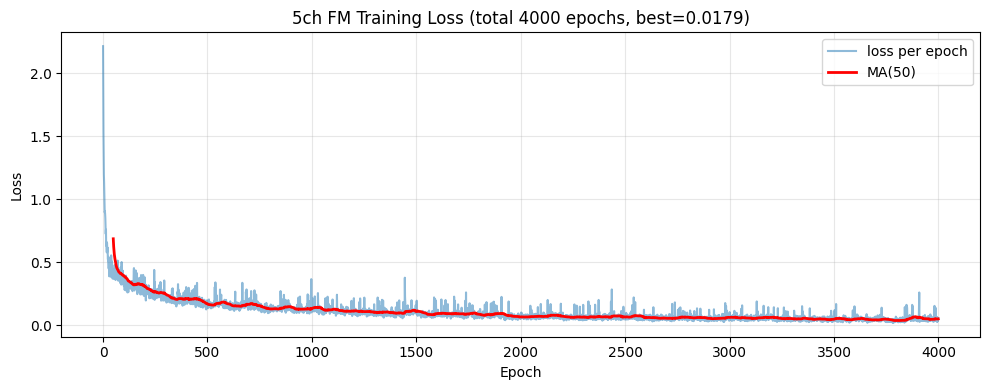

In [ ]:
# ===============================================================
# 继续训练 model_5ch (Flow Matching 5-channel)
# ===============================================================
# 必须先运行 Cell 5 加载 model_5ch

import numpy as np
import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

torch.set_grad_enabled(True)  # 确保梯度开启

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']      # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']    # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")
print(f"[Data] states: {states.shape}, controls: {controls.shape}, goals: {goals.shape if goals is not None else None}")

# 构建 5-channel: [x, y, theta, a, delta_rate]
traj_5ch = np.stack([
    states[:, :, 0],       # x
    states[:, :, 1],       # y
    states[:, :, 2], 
    controls[:, :, 0],     # a
    controls[:, :, 1],     # delta_rate
], axis=1)  # (N, 5, T)

# Canonical frame: 每条轨迹以 start->goal 为 x 轴
def canonicalize_batch(trajs, goals_xy=None):
    """trajs: (N,5,T), goals_xy: (N,2) or None"""
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        # Rotate XY
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        # Rotate theta
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        # cond: [dist, v0, cos(th0_can), sin(th0_can), delta0]
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

X1_t = torch.tensor(X1, dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_all, dtype=torch.float32, device=device)

ds = TensorDataset(X1_t, cond_t)
dl = DataLoader(ds, batch_size=64, shuffle=True, drop_last=True)

# 测试 batch
for xb, cb in dl:
    print(f"[Batch] x: {xb.shape}, cond: {cb.shape}")
    break

# ---------------------------------------------------------------
# 2) 从头初始化模型 & optimizer (不加载 checkpoint)
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_canonical_r.pt")

# 重新初始化模型 (随机权重)
model_5ch = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_loss   = float('inf')
history     = []

print(f"[Model] 从头初始化 (随机权重)")
print(f"[Model] Parameters: {sum(p.numel() for p in model_5ch.parameters()):,}")

LR = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=1e-5)

print(f"[History] Previous epochs: {len(history)}")

# ---------------------------------------------------------------
# 3) Training loop
# ---------------------------------------------------------------
EPOCHS = 4000
SAVE_EVERY = 500

print(f"\n{'='*60}")
print(f"开始继续训练: {EPOCHS} epochs, LR={LR}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_loss = epoch_loss / max(n_batch, 1)
    history.append(avg_loss)
    global_step += 1

    if avg_loss < best_loss:
        best_loss = avg_loss

    if epoch % 50 == 0:
        print(f"  Epoch {epoch}/{EPOCHS} | loss={avg_loss:.6f} | best={best_loss:.6f} | step={global_step}")

    if epoch % SAVE_EVERY == 0:
        torch.save({
            'model_state_dict': model_5ch.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'global_step': global_step,
            'best_loss': best_loss,
            'history': history,
        }, str(ckpt_path))
        print(f"  💾 Saved checkpoint: step={global_step}, best_loss={best_loss:.6f}")

# Final save
torch.save({
    'model_state_dict': model_5ch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'global_step': global_step,
    'best_loss': best_loss,
    'history': history,
}, str(ckpt_path))

print(f"\n✅ 训练完成! 总 epochs: {global_step}, best_loss: {best_loss:.6f}")

# ---------------------------------------------------------------
# 4) Plot training curve
# ---------------------------------------------------------------
model_5ch.eval()

plt.figure(figsize=(10, 4))
plt.plot(history, alpha=0.5, label='loss per epoch')
if len(history) > 20:
    window = min(50, len(history) // 5)
    smooth = np.convolve(np.array(history, dtype=np.float64), np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(history)), smooth, 'r-', lw=2, label=f'MA({window})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'5ch FM Training Loss (total {global_step} epochs, best={best_loss:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[Data] N=100, T=60, D=5
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Split] Train: 80, Val: 20
[Model] Parameters: 2,904,965

Training: 4000 epochs, LR=0.0005
Train: 80, Val: 20

  Epoch    1 | train=2.369664 | val=1.781698 * (best)
  Epoch   50 | train=0.456482 | val=0.599788 * (best)
  Epoch  100 | train=0.293754 | val=0.420579 * (best)
  Epoch  150 | train=0.270199 | val=0.393799 * (best)
  Epoch  200 | train=0.230915 | val=0.389634 * (best)
  Epoch  250 | train=0.230300 | val=0.476563
  Epoch  300 | train=0.178178 | val=0.437105
  Epoch  350 | train=0.172068 | val=0.409355
  Epoch  400 | train=0.192252 | val=0.725121
  Epoch  450 | train=0.158732 | val=0.502803
  Epoch  500 | train=0.163946 | val=0.395053
  Epoch  550 | train=0.155929 | val=0.357813 * (best)
  Epoch  600 | train=0.125715 | val=0.366060
  Epoch  650 | train=0.146123 | val=0.360205
  Epoch  700 | train=0.115641 | val=0.412500
  Epoch  750 | train=0.117007 | val=0.509194
  Epoch  800 | train=0.133554 | val=0.330864 *

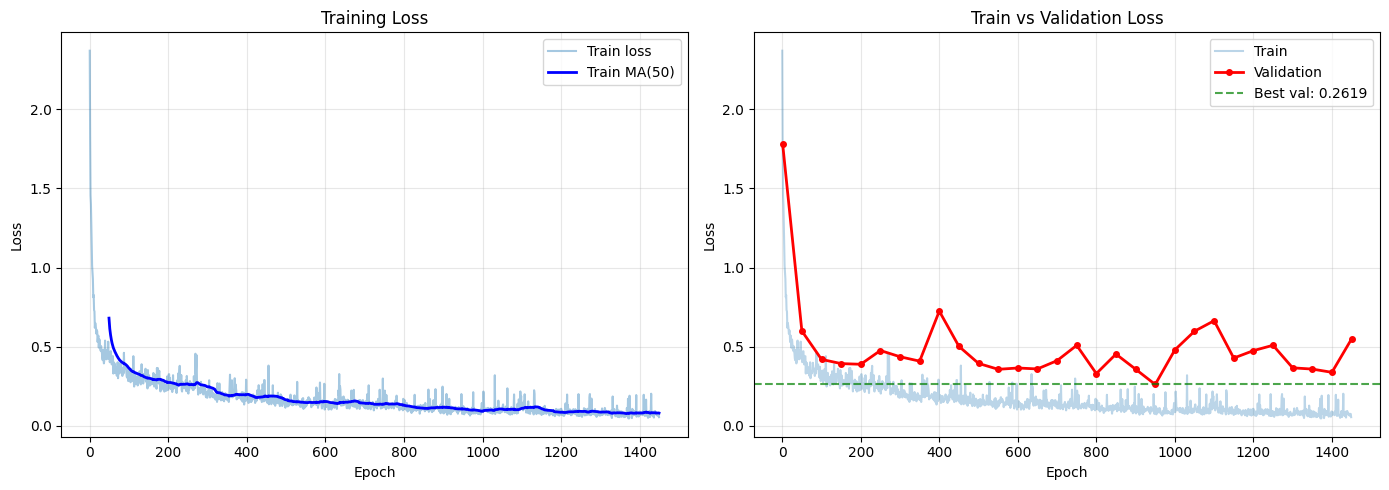


[Overfitting Check]
  Final train loss: 0.055821
  Final val loss:   0.548966
  Gap (val - train): 0.493146


In [ ]:
# ===============================================================
# 训练 model_5ch (Flow Matching 5-channel) - 带 Validation
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

torch.set_grad_enabled(True)

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

def canonicalize_batch(trajs, goals_xy=None):
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

X1_t = torch.tensor(X1, dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_all, dtype=torch.float32, device=device)

# ---------------------------------------------------------------
# 2) Train/Val Split (80/20)
# ---------------------------------------------------------------
full_ds = TensorDataset(X1_t, cond_t)

train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size], 
                                 generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 3) 模型初始化
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_canonical_val.pt")

model_5ch = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_val_loss = float('inf')
train_history = []
val_history = []

print(f"[Model] Parameters: {sum(p.numel() for p in model_5ch.parameters()):,}")

LR = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=1e-5)

# ---------------------------------------------------------------
# 4) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total_loss = 0.0
    n_batch = 0
    
    for x_1, cond_b in val_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        
        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)
        
        total_loss += loss.item()
        n_batch += 1
    
    model.train()
    return total_loss / max(n_batch, 1)

# ---------------------------------------------------------------
# 5) Training loop with validation
# ---------------------------------------------------------------
EPOCHS = 4000
SAVE_EVERY = 500
VAL_EVERY = 50
PATIENCE = 500

no_improve_count = 0

print(f"\n{'='*60}")
print(f"Training: {EPOCHS} epochs, LR={LR}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    # ----- Training -----
    model_5ch.train()
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in train_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_train_loss = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train_loss)
    global_step += 1

    # ----- Validation -----
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_5ch, val_dl)
        val_history.append((epoch, val_loss))
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict': model_5ch.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step': global_step,
                'best_val_loss': best_val_loss,
                'train_history': train_history,
                'val_history': val_history,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f} | val={val_loss:.6f} * (best)")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f} | val={val_loss:.6f}")
        
        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] epoch {epoch}, no improvement for {PATIENCE} epochs")
            break
    
    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f}")

print(f"\nDone! Epochs: {global_step}, Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 6) Plot training curves
# ---------------------------------------------------------------
model_5ch.eval()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_history, alpha=0.4, label='Train loss')
if len(train_history) > 50:
    window = 50
    smooth = np.convolve(np.array(train_history), np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(train_history)), smooth, 'b-', lw=2, label=f'Train MA({window})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
val_epochs = [v[0] for v in val_history]
val_losses = [v[1] for v in val_history]
ax2.plot(train_history, alpha=0.3, label='Train')
ax2.plot(val_epochs, val_losses, 'ro-', lw=2, markersize=4, label='Validation')
ax2.axhline(best_val_loss, color='g', ls='--', alpha=0.7, label=f'Best val: {best_val_loss:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Train vs Validation Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 7) Overfitting check
# ---------------------------------------------------------------
if len(val_history) >= 2:
    final_train = train_history[-1]
    final_val = val_history[-1][1]
    gap = final_val - final_train
    
    print(f"\n[Overfitting Check]")
    print(f"  Final train loss: {final_train:.6f}")
    print(f"  Final val loss:   {final_val:.6f}")
    print(f"  Gap (val - train): {gap:.6f}")
    
    if gap > 0.01:
        print("  Warning: possible overfitting")
    else:
        print("  OK: no obvious overfitting")

[device] cuda
[Data] N=100, T=60, D=5
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Curvature Aug]
  Curvature bin [0.00, 0.25]: 50 samples → +0
  Curvature bin [0.25, 0.50]: 9 samples → +21
  Curvature bin [0.50, 0.75]: 15 samples → +15
  Curvature bin [0.75, 1.00]: 3 samples → +27
  Curvature bin [1.00, 1.26]: 0 samples → +30
  Curvature bin [1.26, 1.51]: 7 samples → +23
  Curvature bin [1.51, 1.76]: 8 samples → +22
  Curvature bin [1.76, 2.01]: 8 samples → +22
  After curvature aug: 230 samples

[Noise/Mirror Aug]
[Augmented] X1: (3450, 5, 60), cond: (3450, 5)
[Split] Train: 2760, Val: 690
[Model] Parameters: 731,589 (small model)
[Model] Data/Param ratio: 0.0038

Training: 3000 epochs, LR=0.0003, weight_decay=0.0005
Train: 2760, Val: 690
Input noise: 0.02, Patience: 300

  Epoch    1 | train=0.8556 | val=0.5361 | gap=-0.3195 * (best)
  Epoch   50 | train=0.1676 | val=0.1576 | gap=-0.0100 * (best)
  Epoch  100 | train=0.1374 | val=0.1100 | gap=-0.0274 * (best)
  Epoch  150 | train=0

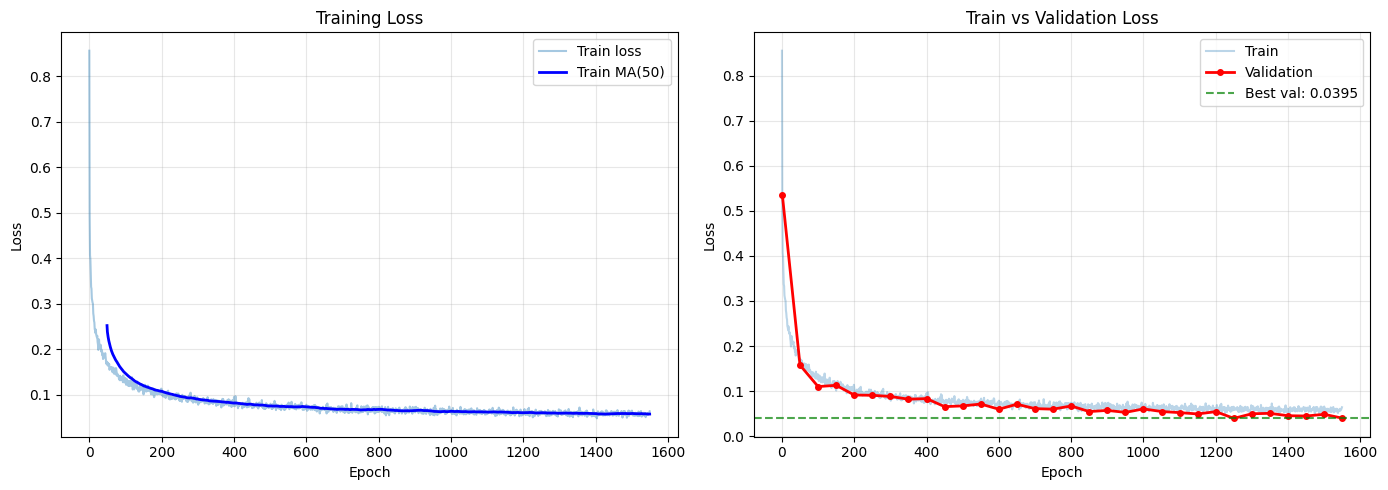


[Overfitting Check]
  Final train loss: 0.064112
  Final val loss:   0.039868
  Gap (val - train): -0.024244
  OK: no obvious overfitting

[Load Best] Loading from cache\model_vel_5ch_small.pt
[Load Best] Done, best_val_loss=0.039486


In [ ]:
# ===============================================================
# 训练 model_5ch (Flow Matching 5-channel) - 小模型 + 抗过拟合
# ===============================================================

import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

# 确保 fmtorch 包可被导入
repo_root = str(Path(os.getcwd()).parent)  # notebooks/../ = dmpc_fm_cbf/
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

torch.set_grad_enabled(True)

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

def canonicalize_batch(trajs, goals_xy=None):
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

# ---------------------------------------------------------------
# 2) 数据增强 (解决数据量不足)
# ---------------------------------------------------------------
def augment_data(X1, cond_all, aug_factor=10):
    N, C, T = X1.shape
    augmented_X = [X1]
    augmented_cond = [cond_all]
    
    np.random.seed(42)
    
    for i in range(aug_factor - 1):
        # 添加小噪声
        noise_X = X1.copy()
        noise_X[:, 0:2, :] += np.random.randn(N, 2, T) * 0.02
        noise_X[:, 2, :] += np.random.randn(N, T) * 0.03
        noise_X[:, 3:5, :] += np.random.randn(N, 2, T) * 0.01
        
        noise_cond = cond_all.copy()
        noise_cond[:, 0] *= (1 + np.random.randn(N) * 0.02)
        noise_cond[:, 1] += np.random.randn(N) * 0.02
        
        augmented_X.append(noise_X)
        augmented_cond.append(noise_cond)
        
        # Y轴镜像 (每隔一次)
        if i % 2 == 0:
            mirror_X = X1.copy()
            mirror_X[:, 1, :] *= -1
            mirror_X[:, 2, :] *= -1
            mirror_X[:, 1, :] += np.random.randn(N, T) * 0.01
            
            mirror_cond = cond_all.copy()
            mirror_cond[:, 3] *= -1
            
            augmented_X.append(mirror_X)
            augmented_cond.append(mirror_cond)
    
    return (np.concatenate(augmented_X, axis=0).astype(np.float32),
            np.concatenate(augmented_cond, axis=0).astype(np.float32))
    
def augment_by_curvature(X1, cond_all, target_per_bin=30, n_bins=8):
    """对高曲率稀疏区间做插值过采样"""
    max_ys = np.max(np.abs(X1[:, 1, :]), axis=1)  # (N,) 每条轨迹的 max|y|
    bins = np.linspace(0, max_ys.max() + 0.01, n_bins + 1)

    aug_X    = [X1]
    aug_cond = [cond_all]
    np.random.seed(99)

    for b in range(n_bins):
        mask    = (max_ys >= bins[b]) & (max_ys < bins[b+1])
        indices = np.where(mask)[0]
        count   = len(indices)
        needed  = max(0, target_per_bin - count)

        print(f"  Curvature bin [{bins[b]:.2f}, {bins[b+1]:.2f}]: "
              f"{count} samples → +{needed}")

        if count == 0 or needed == 0:
            continue

        for _ in range(needed):
            i1, i2 = np.random.choice(indices, 2, replace=(count < 2))
            alpha  = np.random.uniform(0.3, 0.7)

            new_X    = alpha * X1[i1] + (1 - alpha) * X1[i2]
            new_X    += np.random.randn(*new_X.shape).astype(np.float32) * 0.005
            new_cond = alpha * cond_all[i1] + (1 - alpha) * cond_all[i2]

            aug_X.append(new_X[None])       # (1, 5, T)
            aug_cond.append(new_cond[None]) # (1, 5)

    return (np.concatenate(aug_X,    axis=0).astype(np.float32),
            np.concatenate(aug_cond, axis=0).astype(np.float32))

# === 执行顺序：先曲率均衡，再做原有增强 ===
print("[Curvature Aug]")
X1_balanced, cond_balanced = augment_by_curvature(X1, cond_all,
                                                    target_per_bin=30, n_bins=8)
print(f"  After curvature aug: {len(X1_balanced)} samples")

print("\n[Noise/Mirror Aug]")
X1_aug, cond_aug = augment_data(X1_balanced, cond_balanced, aug_factor=10)
print(f"[Augmented] X1: {X1_aug.shape}, cond: {cond_aug.shape}")   


X1_t   = torch.tensor(X1_aug,  dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_aug, dtype=torch.float32, device=device)




# ---------------------------------------------------------------
# 3) Train/Val Split (80/20)
# ---------------------------------------------------------------
full_ds = TensorDataset(X1_t, cond_t)

train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size], 
                                 generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 4) 小模型初始化 (防止过拟合)
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_small.pt")

# 小模型: hidden_dim 128 -> 64
model_5ch = SimpleUNet1D(
    time_emb_dim=64,    # 128 -> 64
    hidden_dim=64,      # 128 -> 64
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_val_loss = float('inf')
train_history = []
val_history = []

n_params = sum(p.numel() for p in model_5ch.parameters())
print(f"[Model] Parameters: {n_params:,} (small model)")
print(f"[Model] Data/Param ratio: {len(train_ds) / n_params:.4f}")

# 强正则化
LR = 3e-4
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ---------------------------------------------------------------
# 5) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total_loss = 0.0
    n_batch = 0
    
    for x_1, cond_b in val_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        
        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)
        
        total_loss += loss.item()
        n_batch += 1
    
    model.train()
    return total_loss / max(n_batch, 1)

# ---------------------------------------------------------------
# 6) Training loop
# ---------------------------------------------------------------
EPOCHS = 3000
VAL_EVERY = 50
PATIENCE = 300
INPUT_NOISE = 0.02

no_improve_count = 0

print(f"\n{'='*60}")
print(f"Training: {EPOCHS} epochs, LR={LR}, weight_decay={WEIGHT_DECAY}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"Input noise: {INPUT_NOISE}, Patience: {PATIENCE}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    model_5ch.train()
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in train_dl:
        B = x_1.shape[0]
        
        # 训练时添加输入噪声 (额外正则化)
        x_1_noisy = x_1 + torch.randn_like(x_1) * INPUT_NOISE
        
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1_noisy
        v_target = x_1_noisy - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_train_loss = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train_loss)
    global_step += 1

    # Validation
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_5ch, val_dl)
        val_history.append((epoch, val_loss))
        
        gap = val_loss - avg_train_loss
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict': model_5ch.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step': global_step,
                'best_val_loss': best_val_loss,
                'train_history': train_history,
                'val_history': val_history,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f} | val={val_loss:.4f} | gap={gap:.4f} * (best)")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f} | val={val_loss:.4f} | gap={gap:.4f}")
        
        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] epoch {epoch}, no improvement for {PATIENCE} epochs")
            break
    
    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f}")

print(f"\nDone! Epochs: {global_step}, Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 7) Plot training curves
# ---------------------------------------------------------------
model_5ch.eval()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_history, alpha=0.4, label='Train loss')
if len(train_history) > 50:
    window = 50
    smooth = np.convolve(np.array(train_history), np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(train_history)), smooth, 'b-', lw=2, label=f'Train MA({window})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
val_epochs = [v[0] for v in val_history]
val_losses = [v[1] for v in val_history]
ax2.plot(train_history, alpha=0.3, label='Train')
ax2.plot(val_epochs, val_losses, 'ro-', lw=2, markersize=4, label='Validation')
ax2.axhline(best_val_loss, color='g', ls='--', alpha=0.7, label=f'Best val: {best_val_loss:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Train vs Validation Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 8) Overfitting check
# ---------------------------------------------------------------
if len(val_history) >= 2:
    final_train = train_history[-1]
    final_val = val_history[-1][1]
    gap = final_val - final_train
    
    print(f"\n[Overfitting Check]")
    print(f"  Final train loss: {final_train:.6f}")
    print(f"  Final val loss:   {final_val:.6f}")
    print(f"  Gap (val - train): {gap:.6f}")
    
    if gap > 0.05:
        print("  Warning: still overfitting, consider more data or smaller model")
    elif gap > 0.02:
        print("  Mild overfitting, but acceptable")
    else:
        print("  OK: no obvious overfitting")

# ---------------------------------------------------------------
# 9) 加载最佳模型用于后续使用
# ---------------------------------------------------------------
print(f"\n[Load Best] Loading from {ckpt_path}")
ckpt = torch.load(str(ckpt_path), map_location=device)
model_5ch.load_state_dict(ckpt['model_state_dict'])
model_5ch.eval()
print(f"[Load Best] Done, best_val_loss={ckpt['best_val_loss']:.6f}")

In [3]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fix:
#   ✅ remove CPU<->GPU ping-pong inside ODE rhs
#   ✅ canonicalize/uncanonicalize in TORCH (on device)
#   ✅ pre-create tensors used by CBF (no torch.tensor(...) in rhs)
# ===============================================================

import sys
from pathlib import Path

sys.path.insert(0, "..")

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
# NOTE: this notebook runs in a separate kernel from demo.ipynb.
# If you trained in demo, save/load the checkpoint here.
MODEL_CKPT = "cache/model_vel.pt"  # change if you saved elsewhere

# Try a few common locations
ckpt_candidates = [
    Path(MODEL_CKPT),
    Path("..") / "cache" / "model_vel.pt",
    Path.cwd() / "cache" / "model_vel.pt",
    Path.cwd().parent / "cache" / "model_vel.pt",
]
ckpt_path = next((p for p in ckpt_candidates if p.exists()), None)

if "model_vel" not in globals():
    if "trainer" in globals():
        model_vel = trainer.model
    else:
        if ckpt_path is not None:
            from fmtorch.models.simple1d_unet import SimpleUNet1D
            ckpt = torch.load(str(ckpt_path), map_location=device)
            model_vel = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=5).to(device)
            model_vel.load_state_dict(ckpt["model_state_dict"])
            print("Loaded model checkpoint:", ckpt_path)
        else:
            raise RuntimeError(
                "model_vel not found. Train in this notebook or set MODEL_CKPT to a saved model."
            )
if "cbf_project_velocity_world" not in globals():
    import importlib.util
    cbf_path = Path.cwd().parent / "dmpc_fm_cbf" / "cbf.py"
    if cbf_path.exists():
        spec = importlib.util.spec_from_file_location("dmpc_fm_cbf.cbf", str(cbf_path))
        cbf_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(cbf_mod)
        cbf_project_velocity_world = cbf_mod.cbf_project_velocity_world
    else:
        raise RuntimeError(f"cbf.py not found at {cbf_path}")

model_vel = model_vel.to(device).eval()

Loaded model checkpoint: cache\model_vel.pt


In [4]:
import sys, importlib.util
from pathlib import Path

def find_file_upwards(filename: str, start: Path, max_up: int = 12):
    """
    Search 'filename' by walking upwards; at each level, also try a few common subpaths.
    Returns Path or None.
    """
    p = start.resolve()

    common_subs = [
        Path("."),  # current
        Path("dmpc_fm_cbf"),
        Path("dmpc_fm_cbf") / "dmpc_fm_cbf",
        Path("src"),
        Path("src") / "dmpc_fm_cbf",
    ]

    for _ in range(max_up):
        # quick checks on common layouts
        for sub in common_subs:
            cand = (p / sub / filename).resolve()
            if cand.exists():
                return cand

        # fallback: shallow recursive search (limited)
        try:
            hits = list(p.rglob(filename))
            if len(hits) > 0:
                # prefer the one inside ".../dmpc_fm_cbf/..." if multiple
                hits_sorted = sorted(hits, key=lambda x: ("dmpc_fm_cbf" not in str(x), len(str(x))))
                return hits_sorted[0].resolve()
        except Exception:
            pass

        p = p.parent

    return None

def load_module_from_abs_path(mod_name: str, abs_path: Path):
    abs_path = abs_path.resolve()
    assert abs_path.exists(), f"Missing file: {abs_path}"
    spec = importlib.util.spec_from_file_location(mod_name, str(abs_path))
    mod = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = mod
    spec.loader.exec_module(mod)  # type: ignore
    return mod

# ---- locate files robustly ----
here = Path.cwd()
sampler_path = find_file_upwards("sampler_5h.py", here)
cbf_path     = find_file_upwards("cbf_project_velocity_sgfm.py", here)

print("[cwd]", here.resolve())
print("[sampler_path]", sampler_path)
print("[cbf_path    ]", cbf_path)

assert sampler_path is not None, "Cannot find sampler_5h.py from current notebook location."
assert cbf_path is not None, "Cannot find cbf_project_velocity_sgfm.py from current notebook location."

sampler_mod = load_module_from_abs_path("sampler_5h_abs", sampler_path)
cbf_mod     = load_module_from_abs_path("cbf_sgfm_abs",  cbf_path)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

print("[USING sampler]", sampler_mod.__file__)
print("[USING cbf    ]", cbf_mod.__file__)


[cwd] D:\projects\lab2025\dmpc_fm_cbf\notebooks
[sampler_path] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[cbf_path    ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[USING sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[USING cbf    ] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py


In [4]:
# Force-reload sampler_5h with cond-support, then rebind global function
import inspect
import importlib
import dmpc_fm_cbf.sampler_5h as sampler_mod

sampler_mod = importlib.reload(sampler_mod)
piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler file]", sampler_mod.__file__)
print("[sampler sig ]", sig)

required = ["cond", "start_xy_norm", "goal_xy_norm", "goal_guidance_weight", "lock_start"]
missing = [k for k in required if k not in sig.parameters]
assert len(missing) == 0, f"Loaded sampler still missing params: {missing}"

print("✅ sampler function rebound with cond/start-goal guidance support")


[sampler file] d:\projects\lab2025\dmpc_fm_cbf\notebooks\..\dmpc_fm_cbf\sampler_5h.py
[sampler sig ] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0: 'float' = 0.5, tau1: 'float' = 0.9, prox_k: 'float' = 3.0, cbf_kwargs: 'dict | None' = None)
✅ sampler function rebound with cond/start-goal guidance support


In [11]:
# ===============================================================
# 1) Load model_5ch automatically (5-channel FM model)
# ===============================================================

if "model_5ch" not in globals():

    # ★ 优先加载 small 模型，找不到再 fallback 到其他版本
    preferred = list(Path.cwd().rglob("model_vel_5ch_small.pt"))
    fallback  = [p for p in Path.cwd().rglob("model_vel_5ch*.pt")
                 if "small" not in p.name]

    if preferred:
        ckpt_path  = preferred[0]
        hidden_dim = 64
        time_emb   = 64
    elif fallback:
        ckpt_path  = fallback[0]
        hidden_dim = 128
        time_emb   = 128
    else:
        raise RuntimeError("Cannot find 5ch checkpoint (model_vel_5ch*.pt)")

    print("[Found checkpoint]", ckpt_path)
    print(f"[Model config]  hidden_dim={hidden_dim}, time_emb_dim={time_emb}")

    # ensure repo root in sys.path
    repo_root = sampler_path.parents[2]
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    from fmtorch.models.simple1d_unet import SimpleUNet1D

    model_5ch = SimpleUNet1D(
        time_emb_dim=time_emb,
        hidden_dim=hidden_dim,
        cond_dim=5,
        in_channels=5,
        out_channels=5,
    ).to(device)

    ckpt = torch.load(str(ckpt_path), map_location=device)

    if "model_state_dict" in ckpt:
        model_5ch.load_state_dict(ckpt["model_state_dict"])
        if "best_val_loss" in ckpt:
            print(f"[Best val loss] {ckpt['best_val_loss']:.6f}")
    else:
        model_5ch.load_state_dict(ckpt)

    model_5ch.eval()
    print(f"[Params] {sum(p.numel() for p in model_5ch.parameters()):,}")
    print("✅ model_5ch loaded successfully.")

[Found checkpoint] d:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\model_vel_5ch_small.pt
[Model config]  hidden_dim=64, time_emb_dim=64
[Best val loss] 0.039486
[Params] 731,589
✅ model_5ch loaded successfully.


[Base cond] dist=3.000  v0=0.270  cos_th=0.528  sin_th=-0.849  delta0=0.000
[Sweep] dist ...
[Sweep] v0 ...
[Sweep] theta0 ...
[Sweep] delta0 ...

=================================================================  sweep=dist
    t    ‖v‖ mean       std        XY         θ      ctrl    target
-----------------------------------------------------------------
  0.00      1.2835    0.0867    1.4324    1.1701    1.1683    1.2354
  0.05      1.2898    0.0907    1.4395    1.1753    1.1739    1.2354
  0.11      1.2962    0.0952    1.4468    1.1800    1.1800    1.2354
  0.16      1.3029    0.1001    1.4543    1.1841    1.1868    1.2354
  0.21      1.3099    0.1056    1.4621    1.1876    1.1945    1.2354
  0.26      1.3173    0.1116    1.4701    1.1906    1.2033    1.2354
  0.32      1.3252    0.1183    1.4784    1.1930    1.2135    1.2354
  0.37      1.3339    0.1257    1.4868    1.1951    1.2256    1.2354
  0.42      1.3433    0.1335    1.4953    1.1967    1.2400    1.2354
  0.47      1.3535  

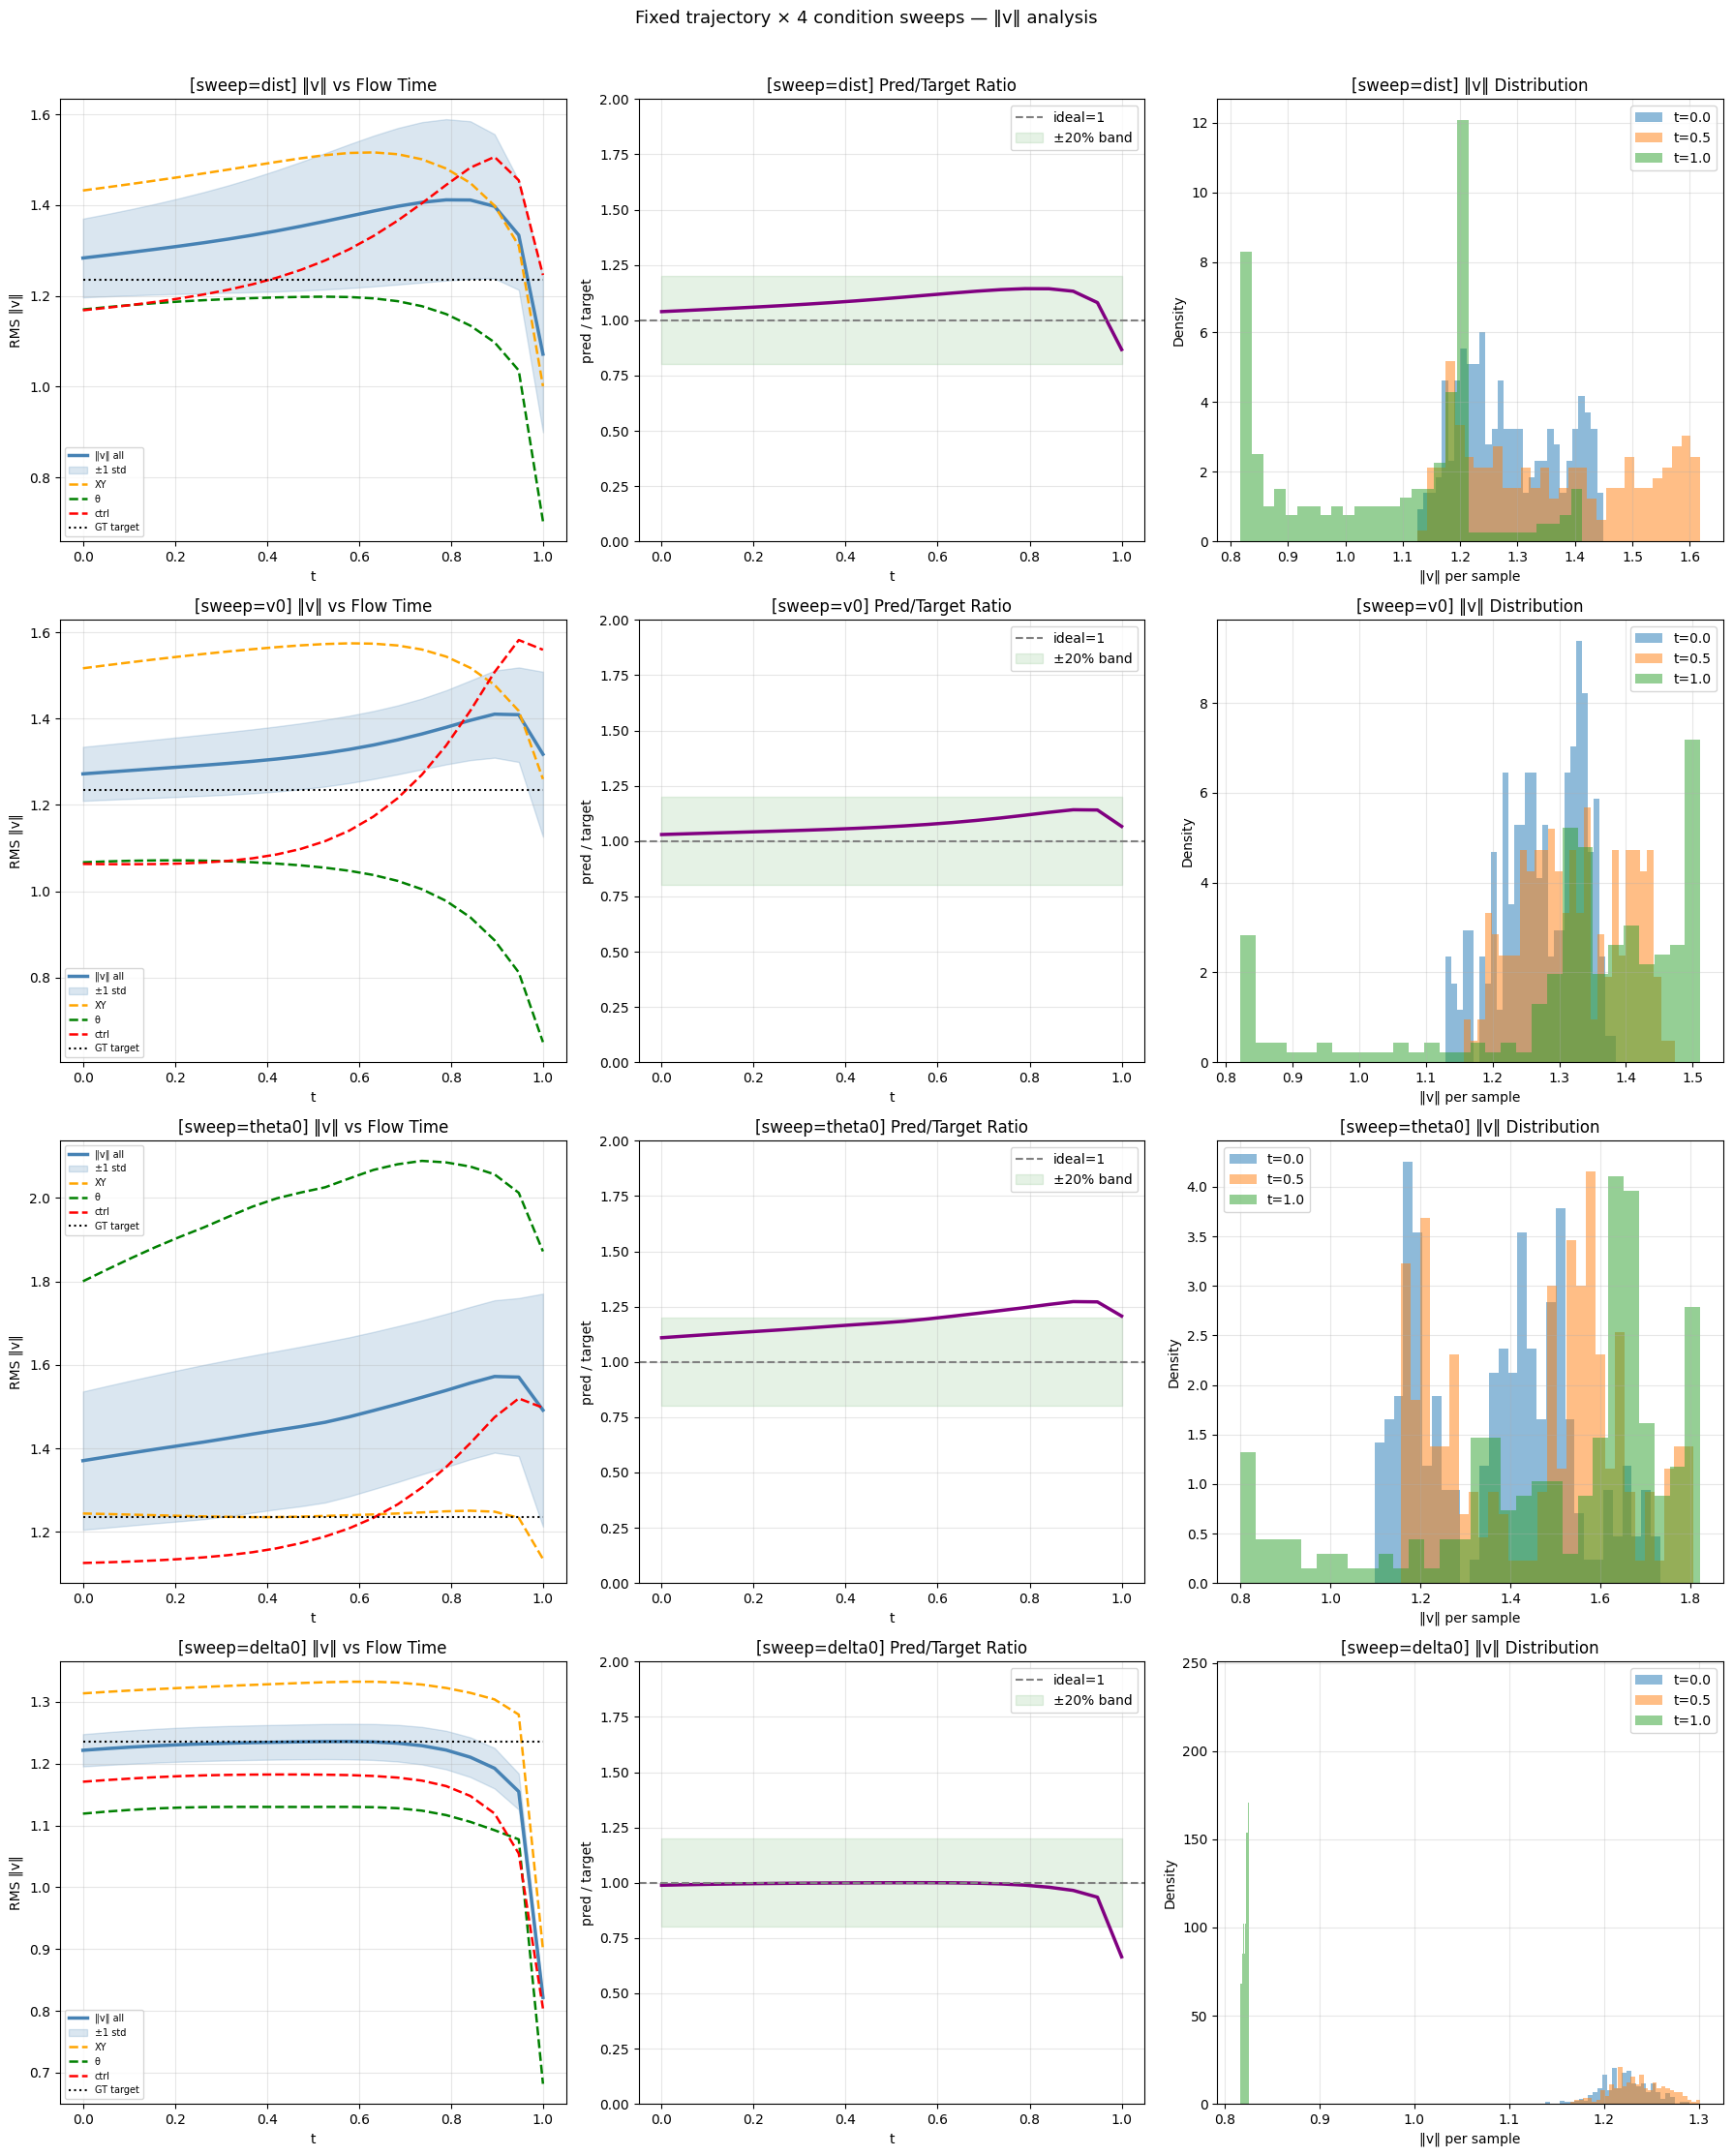

In [38]:
# ===============================================================
# 速度场 v 的模长分析 - 固定轨迹，扫描不同 condition
# 输出格式与原始 cell 一致：折线图 + ratio + 分布直方图
# ===============================================================

model_5ch.eval()
torch.set_grad_enabled(False)

from torch.utils.data import DataLoader, TensorDataset, random_split

# ---------------------------------------------------------------
# 0) 确保 val_dl 存在
# ---------------------------------------------------------------
if 'val_dl' not in dir():
    print("[Rebuild] rebuilding val_dl ...")
    full_ds    = TensorDataset(X1_t, cond_t)
    train_size = int(0.8 * len(full_ds))
    val_size   = len(full_ds) - train_size
    _, val_ds  = random_split(full_ds, [train_size, val_size],
                               generator=torch.Generator().manual_seed(42))
    val_dl     = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

# ---------------------------------------------------------------
# 1) 取第一条轨迹，复制 200 份
# ---------------------------------------------------------------
N_SAMPLES  = 200
N_T_POINTS = 20
t_grid     = np.linspace(0.0, 1.0, N_T_POINTS)

x1_single, cond_single = next(iter(val_dl))
x1_one   = x1_single[0:1]
cond_ref = cond_single[0].cpu().numpy()

print(f"[Base cond] dist={cond_ref[0]:.3f}  v0={cond_ref[1]:.3f}  "
      f"cos_th={cond_ref[2]:.3f}  sin_th={cond_ref[3]:.3f}  delta0={cond_ref[4]:.3f}")

x1_rep = x1_one.expand(N_SAMPLES, -1, -1).clone()
x_0    = torch.randn_like(x1_rep)

# target vnorm（与 cond 无关，只和轨迹有关）
v_target_np  = (x1_rep - x_0).cpu().numpy()
target_vnorm = np.array([
    float(np.sqrt(np.mean(v_target_np ** 2)))
    for _ in t_grid
])

# ---------------------------------------------------------------
# 2) 定义四组 condition 扫描
# ---------------------------------------------------------------
sweep_configs = {
    "dist":   {
        "vals": np.linspace(0.5, 4.0, N_SAMPLES),
        "label": "dist",
        "build_cond": lambda v: _set_cond(cond_ref, 0, v),
    },
    "v0":     {
        "vals": np.linspace(0.0, 1.2, N_SAMPLES),
        "label": "v0",
        "build_cond": lambda v: _set_cond(cond_ref, 1, v),
    },
    "theta0": {
        "vals": np.linspace(-np.pi, np.pi, N_SAMPLES),
        "label": "theta0",
        "build_cond": lambda v: _set_cond_theta(cond_ref, v),
    },
    "delta0": {
        "vals": np.linspace(-np.deg2rad(35), np.deg2rad(35), N_SAMPLES),
        "label": "delta0",
        "build_cond": lambda v: _set_cond(cond_ref, 4, v),
    },
}

def _set_cond(ref, idx, vals):
    c = np.tile(ref, (N_SAMPLES, 1)).astype(np.float32)
    c[:, idx] = np.asarray(vals, np.float32)
    return c

def _set_cond_theta(ref, angles):
    c = np.tile(ref, (N_SAMPLES, 1)).astype(np.float32)
    c[:, 2] = np.cos(angles).astype(np.float32)
    c[:, 3] = np.sin(angles).astype(np.float32)
    return c

# ---------------------------------------------------------------
# 3) 计算每个 sweep 的 vnorm
# ---------------------------------------------------------------
def compute_vnorms(cond_np):
    """给定 (N, 5) 的 cond，返回 (N, N_T_POINTS) 的 vnorm 矩阵"""
    cond_t_sw = torch.tensor(cond_np, dtype=torch.float32, device=x1_rep.device)
    vnorms    = np.zeros((N_SAMPLES, N_T_POINTS))
    all_vxy   = np.zeros_like(vnorms)
    all_vth   = np.zeros_like(vnorms)
    all_vctrl = np.zeros_like(vnorms)

    for j, t_val in enumerate(t_grid):
        t_tensor = torch.full((N_SAMPLES,), t_val, device=x1_rep.device)
        t_exp    = t_tensor.view(-1, 1, 1)
        x_t      = (1 - t_exp) * x_0 + t_exp * x1_rep
        v_pred   = model_5ch(x_t, t_tensor, cond=cond_t_sw)
        v_np     = v_pred.cpu().numpy()

        vnorms[:, j]   = np.sqrt(np.mean(v_np ** 2,            axis=(1, 2)))
        all_vxy[:, j]  = np.sqrt(np.mean(v_np[:, 0:2, :] ** 2, axis=(1, 2)))
        all_vth[:, j]  = np.sqrt(np.mean(v_np[:, 2:3, :] ** 2, axis=(1, 2)))
        all_vctrl[:, j]= np.sqrt(np.mean(v_np[:, 3:5, :] ** 2, axis=(1, 2)))

    return vnorms, all_vxy, all_vth, all_vctrl

results = {}
for name, cfg in sweep_configs.items():
    print(f"[Sweep] {name} ...")
    cond_np = cfg["build_cond"](cfg["vals"])
    vnorms, vxy, vth, vctrl = compute_vnorms(cond_np)
    results[name] = dict(vnorms=vnorms, vxy=vxy, vth=vth, vctrl=vctrl,
                         label=cfg["label"])

# ---------------------------------------------------------------
# 4) 打印数值表（与原 cell 格式一致）
# ---------------------------------------------------------------
for name, R in results.items():
    vnorm_mean = R["vnorms"].mean(axis=0)
    vnorm_std  = R["vnorms"].std(axis=0)
    print(f"\n{'='*65}  sweep={name}")
    print(f"{'t':>5}  {'‖v‖ mean':>10}  {'std':>8}  {'XY':>8}  {'θ':>8}  {'ctrl':>8}  {'target':>8}")
    print(f"{'-'*65}")
    for j, t_val in enumerate(t_grid):
        print(f"  {t_val:.2f}  {vnorm_mean[j]:>10.4f}  {vnorm_std[j]:>8.4f}"
              f"  {R['vxy'][:,j].mean():>8.4f}  {R['vth'][:,j].mean():>8.4f}"
              f"  {R['vctrl'][:,j].mean():>8.4f}  {target_vnorm[j]:>8.4f}")
    ratio = vnorm_mean.mean() / target_vnorm.mean()
    print(f"  Overall mean ‖v‖={vnorm_mean.mean():.4f}  "
          f"Target={target_vnorm.mean():.4f}  Ratio={ratio:.4f}")

# ---------------------------------------------------------------
# 5) 可视化：4 个 sweep × 3 列（与原 cell 完全一致的图形格式）
# ---------------------------------------------------------------
fig, axes = plt.subplots(4, 3, figsize=(18, 22))

for row_i, (name, R) in enumerate(results.items()):
    vnorms     = R["vnorms"]
    vnorm_mean = vnorms.mean(axis=0)
    vnorm_std  = vnorms.std(axis=0)
    ratio      = vnorm_mean / (target_vnorm + 1e-9)

    # ---- 图1：各通道模长随 t 变化（与原 cell 图1 一致）----
    ax = axes[row_i, 0]
    ax.plot(t_grid, vnorm_mean, lw=2.5, label="‖v‖ all", color="steelblue")
    ax.fill_between(t_grid, vnorm_mean - vnorm_std, vnorm_mean + vnorm_std,
                    alpha=0.2, color="steelblue", label="±1 std")
    ax.plot(t_grid, R["vxy"].mean(axis=0),   lw=1.8, ls="--", label="XY",   color="orange")
    ax.plot(t_grid, R["vth"].mean(axis=0),   lw=1.8, ls="--", label="θ",    color="green")
    ax.plot(t_grid, R["vctrl"].mean(axis=0), lw=1.8, ls="--", label="ctrl", color="red")
    ax.plot(t_grid, target_vnorm,            lw=1.5, ls=":",  label="GT target", color="black")
    ax.set_xlabel("t"); ax.set_ylabel("RMS ‖v‖")
    ax.set_title(f"[sweep={name}] ‖v‖ vs Flow Time")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # ---- 图2：pred/target ratio（与原 cell 图2 一致）----
    ax2 = axes[row_i, 1]
    ax2.plot(t_grid, ratio, lw=2.5, color="purple")
    ax2.axhline(1.0, ls="--", color="gray", label="ideal=1")
    ax2.fill_between(t_grid, 0.8, 1.2, alpha=0.1, color="green", label="±20% band")
    ax2.set_xlabel("t"); ax2.set_ylabel("pred / target")
    ax2.set_title(f"[sweep={name}] Pred/Target Ratio")
    ax2.set_ylim(0, 2.0); ax2.legend(); ax2.grid(alpha=0.3)

    # ---- 图3：t=0 / t=0.5 / t=1.0 分布直方图（与原 cell 图3 一致）----
    ax3 = axes[row_i, 2]
    for t_idx, lbl in [(0, "t=0.0"), (N_T_POINTS//2, "t=0.5"), (-1, "t=1.0")]:
        ax3.hist(vnorms[:, t_idx], bins=30, alpha=0.5, label=lbl, density=True)
    ax3.set_xlabel("‖v‖ per sample"); ax3.set_ylabel("Density")
    ax3.set_title(f"[sweep={name}] ‖v‖ Distribution")
    ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle("Fixed trajectory × 4 condition sweeps — ‖v‖ analysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

[cond] dist=3.000  v0=0.270  cos_th=0.528  sin_th=-0.849  delta0=0.000
[shapes] x1=(200, 5, 60)  x0=(200, 5, 60)  cond=(200, 5)
[Assert] 全部一致 ✓

    t    ‖v‖ mean       std        XY         θ      ctrl    target
-----------------------------------------------------------------
  0.00    1.225585  0.000000    1.2903    1.2529    1.1425    1.2269
  0.05    1.228286  0.000000    1.2910    1.2589    1.1457    1.2269
  0.11    1.230482  0.000000    1.2912    1.2639    1.1486    1.2269
  0.16    1.232096  0.000000    1.2910    1.2677    1.1510    1.2269
  0.21    1.233177  0.000000    1.2906    1.2702    1.1530    1.2269
  0.26    1.233806  0.000000    1.2901    1.2717    1.1545    1.2269
  0.32    1.234110  0.000000    1.2897    1.2721    1.1556    1.2269
  0.37    1.234264  0.000000    1.2896    1.2718    1.1562    1.2269
  0.42    1.234330  0.000000    1.2899    1.2712    1.1564    1.2269
  0.47    1.234304  0.000000    1.2905    1.2702    1.1561    1.2269
  0.53    1.234011  0.000000   

C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 24212 (\N{CJK UNIFIED IDEOGRAPH-5E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 35813 (\N{CJK UNIFIED IDEOGRAPH-8BE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 26497 (\N{CJK 

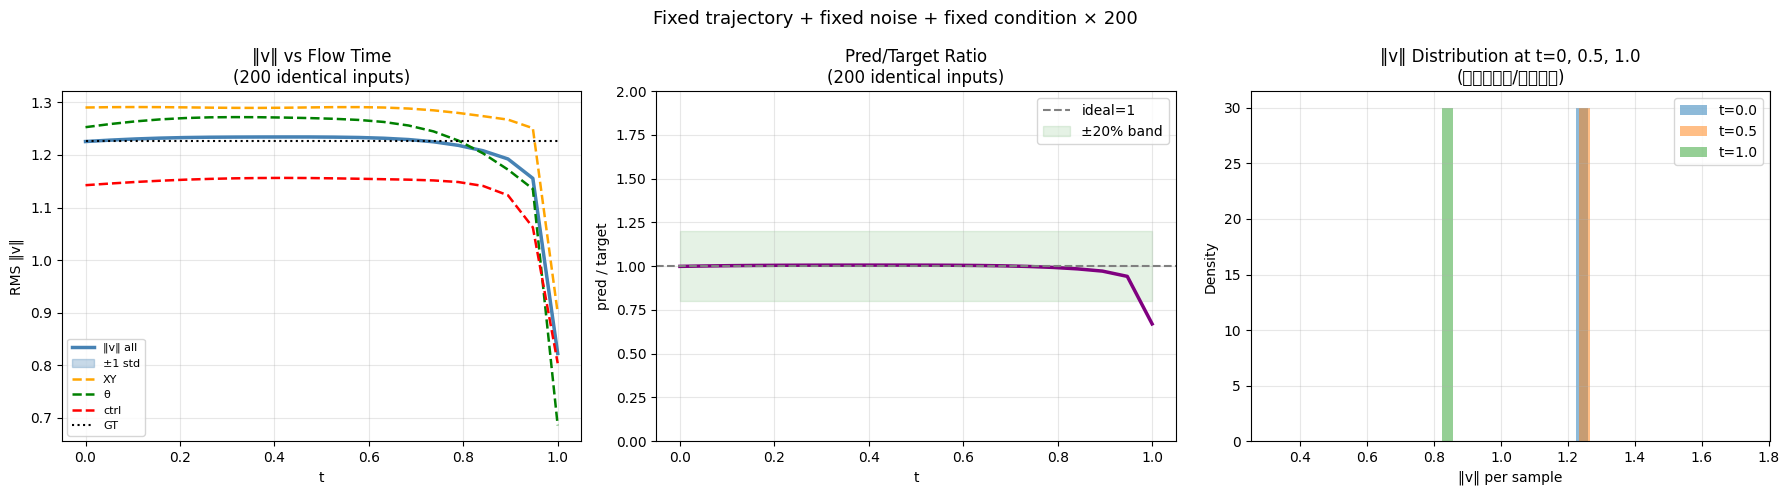

In [41]:
# ===============================================================
# 速度场 v 的模长分析 - 固定轨迹 + 固定noise + 固定condition
# 200条完全一样的输入，验证模型输出是否一致
# ===============================================================

model_5ch.eval()
torch.set_grad_enabled(False)

from torch.utils.data import DataLoader, TensorDataset, random_split

# ---------------------------------------------------------------
# 0) 确保 val_dl 存在
# ---------------------------------------------------------------
if 'val_dl' not in dir():
    print("[Rebuild] rebuilding val_dl ...")
    full_ds    = TensorDataset(X1_t, cond_t)
    train_size = int(0.8 * len(full_ds))
    val_size   = len(full_ds) - train_size
    _, val_ds  = random_split(full_ds, [train_size, val_size],
                               generator=torch.Generator().manual_seed(42))
    val_dl     = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

# ---------------------------------------------------------------
# 1) 取第一条，三样东西全部复制200份且完全一样
# ---------------------------------------------------------------
N_SAMPLES  = 200
N_T_POINTS = 20
t_grid     = np.linspace(0.0, 1.0, N_T_POINTS)

x1_single, cond_single = next(iter(val_dl))

# 轨迹：复制200份
x1_rep = x1_single[0:1].repeat(N_SAMPLES, 1, 1)   # (200, 5, T)

# noise：固定seed，复制200份
torch.manual_seed(42)
x_0 = torch.randn(1, x1_rep.shape[1], x1_rep.shape[2],
                   device=x1_rep.device).repeat(N_SAMPLES, 1, 1)  # (200, 5, T)

# condition：同一个，复制200份
cond_ref = cond_single[0:1].repeat(N_SAMPLES, 1)   # (200, 5)

print(f"[cond] dist={cond_ref[0,0]:.3f}  v0={cond_ref[0,1]:.3f}  "
      f"cos_th={cond_ref[0,2]:.3f}  sin_th={cond_ref[0,3]:.3f}  delta0={cond_ref[0,4]:.3f}")
print(f"[shapes] x1={tuple(x1_rep.shape)}  x0={tuple(x_0.shape)}  cond={tuple(cond_ref.shape)}")

# 验证三者完全一致
assert torch.all(x1_rep[0] == x1_rep[99]).item(),   "x1_rep 不一致！"
assert torch.all(x_0[0]    == x_0[99]   ).item(),   "x_0 不一致！"
assert torch.all(cond_ref[0] == cond_ref[99]).item(),"cond 不一致！"
print("[Assert] 全部一致 ✓")

# ---------------------------------------------------------------
# 2) 计算每个 t 上的 vnorm
# ---------------------------------------------------------------
all_vnorms = np.zeros((N_SAMPLES, N_T_POINTS))
all_vxy    = np.zeros_like(all_vnorms)
all_vth    = np.zeros_like(all_vnorms)
all_vctrl  = np.zeros_like(all_vnorms)

v_target_np  = (x1_rep - x_0).cpu().numpy()
target_vnorm = np.full(N_T_POINTS, float(np.sqrt(np.mean(v_target_np[0] ** 2))))

for j, t_val in enumerate(t_grid):
    t_tensor = torch.full((N_SAMPLES,), t_val, device=x1_rep.device)
    t_exp    = t_tensor.view(-1, 1, 1)
    x_t      = (1 - t_exp) * x_0 + t_exp * x1_rep

    v_pred          = model_5ch(x_t, t_tensor, cond=cond_ref)
    v_np            = v_pred.cpu().numpy()
    all_vnorms[:, j]= np.sqrt(np.mean(v_np ** 2,             axis=(1, 2)))
    all_vxy[:, j]   = np.sqrt(np.mean(v_np[:, 0:2, :] ** 2, axis=(1, 2)))
    all_vth[:, j]   = np.sqrt(np.mean(v_np[:, 2:3, :] ** 2, axis=(1, 2)))
    all_vctrl[:, j] = np.sqrt(np.mean(v_np[:, 3:5, :] ** 2, axis=(1, 2)))

vnorm_mean = all_vnorms.mean(axis=0)
vnorm_std  = all_vnorms.std(axis=0)

# ---------------------------------------------------------------
# 3) 打印 - 如果模型确定性，std 应该全为 0
# ---------------------------------------------------------------
print(f"\n{'='*65}")
print(f"{'t':>5}  {'‖v‖ mean':>10}  {'std':>8}  {'XY':>8}  {'θ':>8}  {'ctrl':>8}  {'target':>8}")
print(f"{'-'*65}")
for j, t_val in enumerate(t_grid):
    print(f"  {t_val:.2f}  {vnorm_mean[j]:>10.6f}  {vnorm_std[j]:>8.6f}"
          f"  {all_vxy[:,j].mean():>8.4f}  {all_vth[:,j].mean():>8.4f}"
          f"  {all_vctrl[:,j].mean():>8.4f}  {target_vnorm[j]:>8.4f}")
print(f"{'='*65}")
print(f"\n[Summary]")
print(f"  max std across all t : {vnorm_std.max():.8f}")
print(f"  → 如果接近 0，模型是确定性的；如果 > 0，模型有随机性")

# ---------------------------------------------------------------
# 4) 可视化（原始格式：3列）
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1：各通道模长随 t
ax = axes[0]
ax.plot(t_grid, vnorm_mean, lw=2.5, label="‖v‖ all", color="steelblue")
ax.fill_between(t_grid, vnorm_mean - vnorm_std, vnorm_mean + vnorm_std,
                alpha=0.3, color="steelblue", label="±1 std")
ax.plot(t_grid, all_vxy.mean(axis=0),   lw=1.8, ls="--", label="XY",   color="orange")
ax.plot(t_grid, all_vth.mean(axis=0),   lw=1.8, ls="--", label="θ",    color="green")
ax.plot(t_grid, all_vctrl.mean(axis=0), lw=1.8, ls="--", label="ctrl", color="red")
ax.plot(t_grid, target_vnorm,           lw=1.5, ls=":",  label="GT",   color="black")
ax.set_xlabel("t"); ax.set_ylabel("RMS ‖v‖")
ax.set_title("‖v‖ vs Flow Time\n(200 identical inputs)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 图2：pred/target ratio
ax2 = axes[1]
ratio = vnorm_mean / (target_vnorm + 1e-9)
ax2.plot(t_grid, ratio, lw=2.5, color="purple")
ax2.axhline(1.0, ls="--", color="gray", label="ideal=1")
ax2.fill_between(t_grid, 0.8, 1.2, alpha=0.1, color="green", label="±20% band")
ax2.set_xlabel("t"); ax2.set_ylabel("pred / target")
ax2.set_title("Pred/Target Ratio\n(200 identical inputs)")
ax2.set_ylim(0, 2.0); ax2.legend(); ax2.grid(alpha=0.3)

# 图3：t=0 / t=0.5 / t=1.0 分布直方图
ax3 = axes[2]
for t_idx, lbl in [(0, "t=0.0"), (N_T_POINTS//2, "t=0.5"), (-1, "t=1.0")]:
    ax3.hist(all_vnorms[:, t_idx], bins=30, alpha=0.5, label=lbl, density=True)
ax3.set_xlabel("‖v‖ per sample"); ax3.set_ylabel("Density")
ax3.set_title("‖v‖ Distribution at t=0, 0.5, 1.0\n(应该是单点/极窄分布)")
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle("Fixed trajectory + fixed noise + fixed condition × 200", fontsize=13)
plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0_hf: 'float' = 0.7, p_hf: 'float' = 2.0, lf_on: 'float' = 1.0, hf_max: 'float' = 1.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - 后期直接朝目标走
DIRECT_TO_GOAL_DIST=1.5, BLEND_DIST=0.7
[  0] dA=3.39 dB=3.39 dist=2.40 vA=0.00 vB=0.00
[  1] dA=3.38 dB=3.38 dist=2.38 vA=0.15 vB=0.15
[  2] dA=3.35 dB=3.35 dist=2.34 vA=0.30 vB=0.30
[  3] dA=3.30 dB=3.30 dist=2.

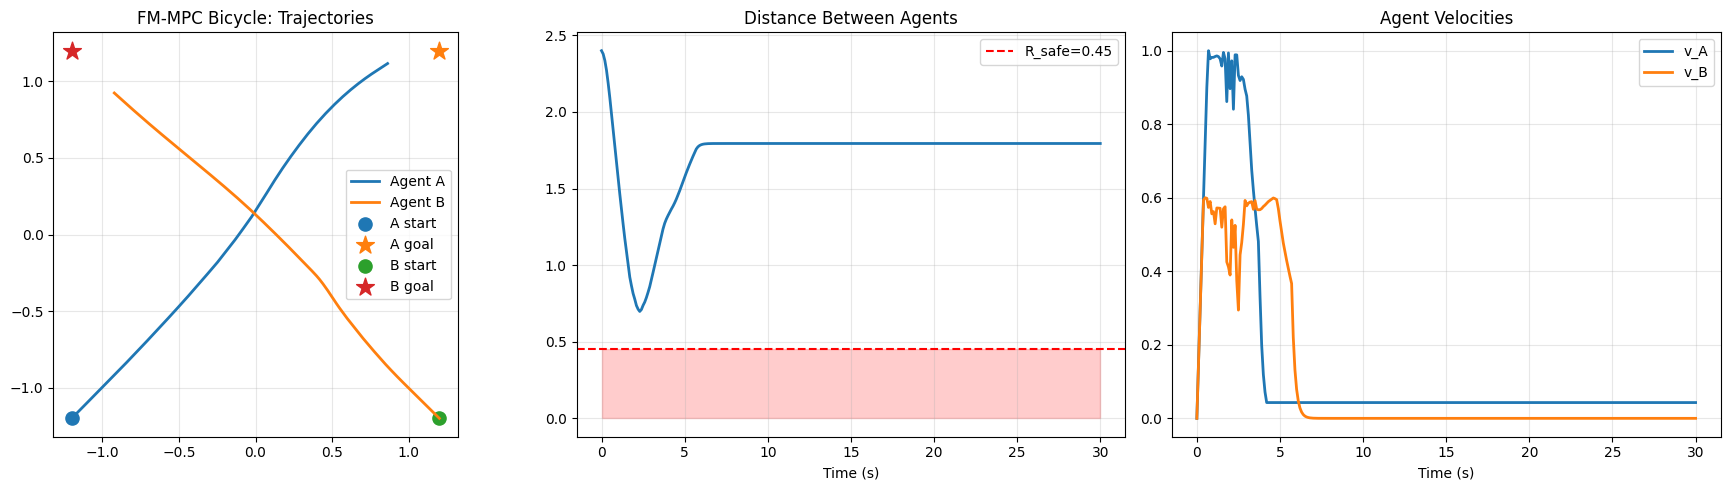

In [61]:
# ============================================================
# FM-MPC Bicycle - 修复版：后期直接朝目标走
# 保留 CBF 强度，只修改 Pure Pursuit 后期行为
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 5
REPLAN_EVERY = 1
MAX_STEPS = 300

# Goal / stopping
goal_tol      = 0.35
stop_radius   = 0.45
creep_radius  = 0.90
v_creep       = 0.12

# Safety
R_SAFE = 0.45

# ★ 后期直接朝目标走的参数
DIRECT_TO_GOAL_DIST = 1.5  # 开始混合的距离
BLEND_DIST = 0.7           # 完全朝目标走的距离

# ===============================================================
# 3) Bicycle dynamics
# ===============================================================
v_max_A   = 1.0
v_max_B   = 0.6
v_min     = 0.0
a_max     = 1.5
L         = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor   = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c = float(d[0] / dist)
    s = float(d[1] / dist)
    R_wc = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings - 保持原参数
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38

SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0

CBF_LIGHT  = dict(passes=2,  extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3, alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1,2), (H,1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1,2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ===============================================================
def make_x0_noise(T, seed):
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf = build_canonical_frame(self_xy, goal_xy)

    if other_pred_pos is None or len(other_pred_pos) == 0:
        other_now = self_xy
    else:
        other_now = other_pred_pos[0]
    dist_AB = float(np.linalg.norm(self_xy - other_now))

    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    x0_noise = make_x0_noise(T_steps, seed)

    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=num_segments,
        ode_method=ode_method,
        atol=1e-4, rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45,
        goal_guidance_weight=0.90,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf),
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )

    xy_can = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# 8) Pure Pursuit - ★ 后期直接朝目标走
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    """
    修改版 Pure Pursuit:
    - 远离目标时：跟随 FM 路径
    - 接近目标时：逐渐切换到直接朝目标走
    """
    s = s0.copy()
    U = np.zeros((H, 2), dtype=np.float32)

    Ld_min = 0.35
    Ld_max = 1.10
    k_brake = 4.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)

    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        # --- 停车逻辑 ---
        if d_goal <= stop_radius:
            a = float(np.clip(-k_brake * v, -a_max, 0.0))
            delta_des = 0.0
            dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        # --- Lookahead 距离 ---
        Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))

        # --- 找路径上的 target ---
        near_idx = _closest_index(path_xy, pos)
        near_idx = max(near_idx, last_path_idx)
        path_target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)

        # ★★★ 后期阶段：混合 path_target 和 goal ★★★
        if d_goal < DIRECT_TO_GOAL_DIST:
            if d_goal < BLEND_DIST:
                blend = 1.0  # 完全朝目标
            else:
                # 线性插值
                blend = (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
                blend = float(np.clip(blend, 0.0, 1.0))
            
            # 混合目标点
            target = (1.0 - blend) * path_target + blend * goal_xy
        else:
            target = path_target

        # --- 计算转向 ---
        dx = float(target[0] - x)
        dy = float(target[1] - y)
        ang = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))

        kappa = 2.0 * math.sin(alpha) / max(1e-3, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        # --- 速度 ---
        v_des = v_max
        if d_goal < creep_radius:
            v_des = float(np.clip(v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        turn_pen = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des *= turn_pen

        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost
# ===============================================================
W_END   = 18.0
W_PATH  = 1.5
W_COLL  = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))

    M = min(len(pos_self), len(pos_other_pred))
    if M <= 1:
        min_d = float("inf")
    else:
        d = np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1)
        min_d = float(d.min())

    viol = max(0.0, R_SAFE - min_d)
    coll = float(viol * viol)

    dU = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))

    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)

    best = None
    cbf_count = 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy, other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue

        cbf_count += int(used_cbf)

        U = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, st_self = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)

        J = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0 = U[0].copy()

        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)

    if best is None:
        return np.zeros(2, np.float32), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA = np.zeros(2, np.float32)
uB = np.zeros(2, np.float32)

cbf_total = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 后期直接朝目标走")
print(f"DIRECT_TO_GOAL_DIST={DIRECT_TO_GOAL_DIST}, BLEND_DIST={BLEND_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = (dA < goal_tol and sA[3] < 0.08)
    doneB = (dB < goal_tol and sB[3] < 0.08)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B, seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A, seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.2f} dB={dB:.2f} dist={dist_AB:.2f} vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)

print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots
# ===============================================================
dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter([xA0[0]], [xA0[1]], s=90, marker="o", label="A start")
ax.scatter([gA[0]],  [gA[1]],  s=180, marker="*", label="A goal")
ax.scatter([xB0[0]], [xB0[1]], s=90, marker="o", label="B start")
ax.scatter([gB[0]],  [gB[1]],  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1], s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents")
ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities")
ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0: 'float' = 0.5, tau1: 'float' = 0.9, prox_k: 'float' = 3.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - Pure Pursuit 修复版（正确到达终点）
goal_tol=0.2  ARRIVAL_DIST=0.15  APPROACH_DIST=0.6
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15
[  2] dA=3.349 dB=3.349 dist=2.336 vA=0.30 vB=0.30
[  3] dA=3.304 dB=

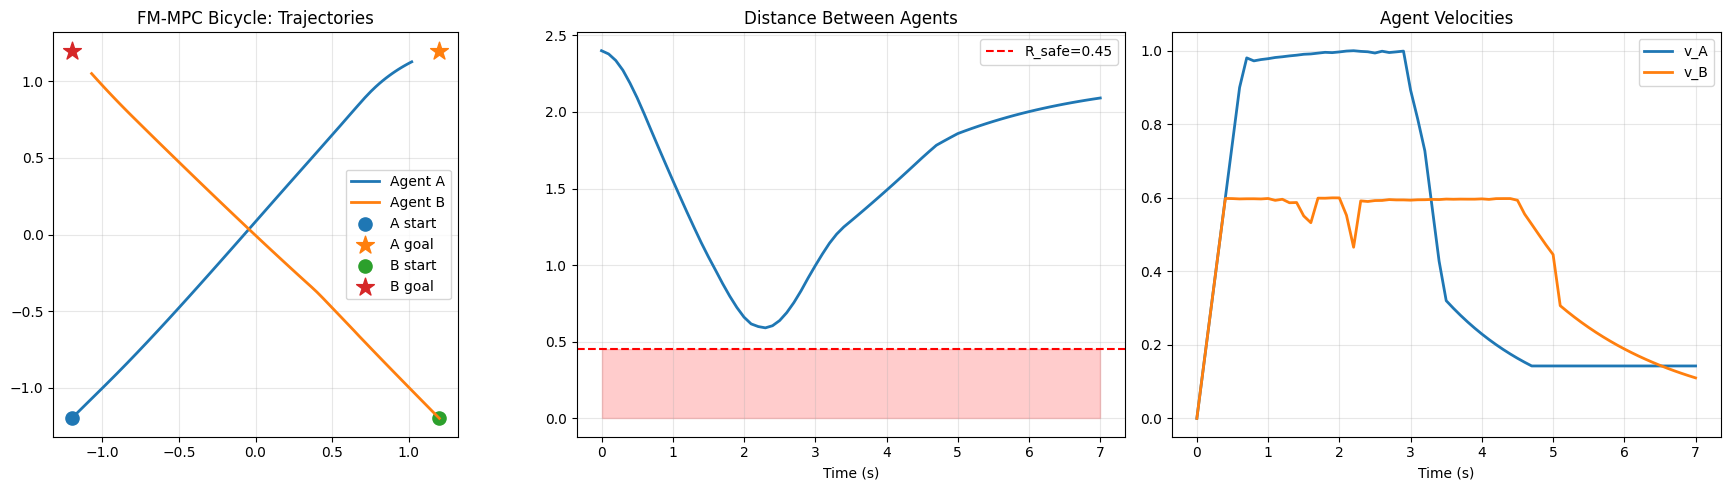

In [13]:
# ============================================================
# FM-MPC Bicycle - 修复版：Pure Pursuit 正确到达终点
# 修改点：
#   1. Ld = min(Ld, d_goal * 0.85)  → 消除绕圈根源
#   2. d_goal < APPROACH_DIST 时 target 直接指向 goal
#   3. ARRIVAL_DIST 改小，消除停车死锁
#   4. done 判定去掉速度条件
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 5
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping  ★ 全部修改
goal_tol      = 0.20   # 原 0.35
ARRIVAL_DIST  = 0.15   # ★ 新增：真正刹车距离
APPROACH_DIST = 0.60   # ★ 新增：进入直接指向goal模式的距离
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# ===============================================================
# 3) Bicycle dynamics  （不变）
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    # 初始化st，Hh+1行5列，用于存储状态
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st
    #用bicycle_step函数，根据当前状态s0和控制u，计算下一个状态st[i+1]

# ===============================================================
# 4) Canonical frame  （不变）
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings  （不变）
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction  （不变）
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st
    # 用rollout_bicycle函数，根据other_state和other_u_last，计算other_state的预测轨迹pos和状态st constant control prediction

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    #tf：canonical frame
    #other_pred_pos：other_state的预测轨迹
    #dist_AB：other_state和self_state的距离
    # 用build_time_expanded_ellipses函数，根据tf、other_pred_pos和dist_AB，计算other_pred_pos的预测轨迹的椭圆
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    #idxs：other_pred_pos的预测轨迹的椭圆的索引 减少计算量
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    # 用r_obs_near if dist_AB < 1.2 else r_obs_far计算椭圆的半径
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling  （不变）
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []
    x0_noise = make_x0_noise(T_steps, seed)
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec, start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45, goal_guidance_weight=0.90,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None, ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# 8) Pure Pursuit — ★ 修复版（框架不变，三处关键修改）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))
    # 找“离我最近的轨迹点索引” 

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    Ld_min  = 0.20
    Ld_max  = 1.10
    k_brake = 5.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        # ★ 修改1：真正很近才停车，消除死锁
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        # ★ 修改2：接近终点时 target 直接指向 goal（纯 Pure Pursuit，只换目标点）
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            # 正常 Pure Pursuit
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            # ★ 修改3：Ld 不超过 d_goal * 0.85，防止 lookahead 越过终点绕圈
            Ld = min(Ld, d_goal * 0.85)

            near_idx = _closest_index(path_xy, pos)
            near_idx = max(near_idx, last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)

            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        # 转向（与原版完全相同）
        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))

        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target  # 曲率
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max)) # 期望转向角
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        turn_pen = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des   *= turn_pen

        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost  （不变）
# ===============================================================
W_END    = 18.0
W_PATH   = 1.5
W_COLL   = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0]**2 + 0.4*dU[:, 1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan  （不变）
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)
    best      = None
    cbf_count = 0
    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy,
                other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue
        cbf_count += int(used_cbf)
        U        = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J        = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0       = U[0].copy()
        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)
    if best is None:
        return np.zeros(2, np.float32), float("inf"), None, 0
    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup  （不变）
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0]))
thB0 = float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - Pure Pursuit 修复版（正确到达终点）")
print(f"goal_tol={goal_tol}  ARRIVAL_DIST={ARRIVAL_DIST}  APPROACH_DIST={APPROACH_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))

    # ★ done 判定：只看位置，不要求速度
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)
        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)
        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots  （不变）
# ===============================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[依赖检查] ✓
[Data] N=100  T=60  D=5
[Params] T_steps=40  num_segments=5  total_time=1.0  ode_method=euler
[注意] T_steps(40) != 数据T(60)，pred 会插值对齐

验证中... (N=50 samples)
  [10/50]  ADE=0.1993  FDE=0.2708  HDG=6.60°
  [20/50]  ADE=0.1888  FDE=0.2709  HDG=5.73°
  [30/50]  ADE=0.2205  FDE=0.2641  HDG=6.95°
  [40/50]  ADE=0.2386  FDE=0.2509  HDG=7.80°
  [50/50]  ADE=0.2352  FDE=0.2292  HDG=7.49°

  ADE  : 0.2352  ±0.2218
  FDE  : 0.2292  ±0.1838
  HDG  : 7.49°  ±11.73°

判断标准（canonical frame）：
  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题
  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题
  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题


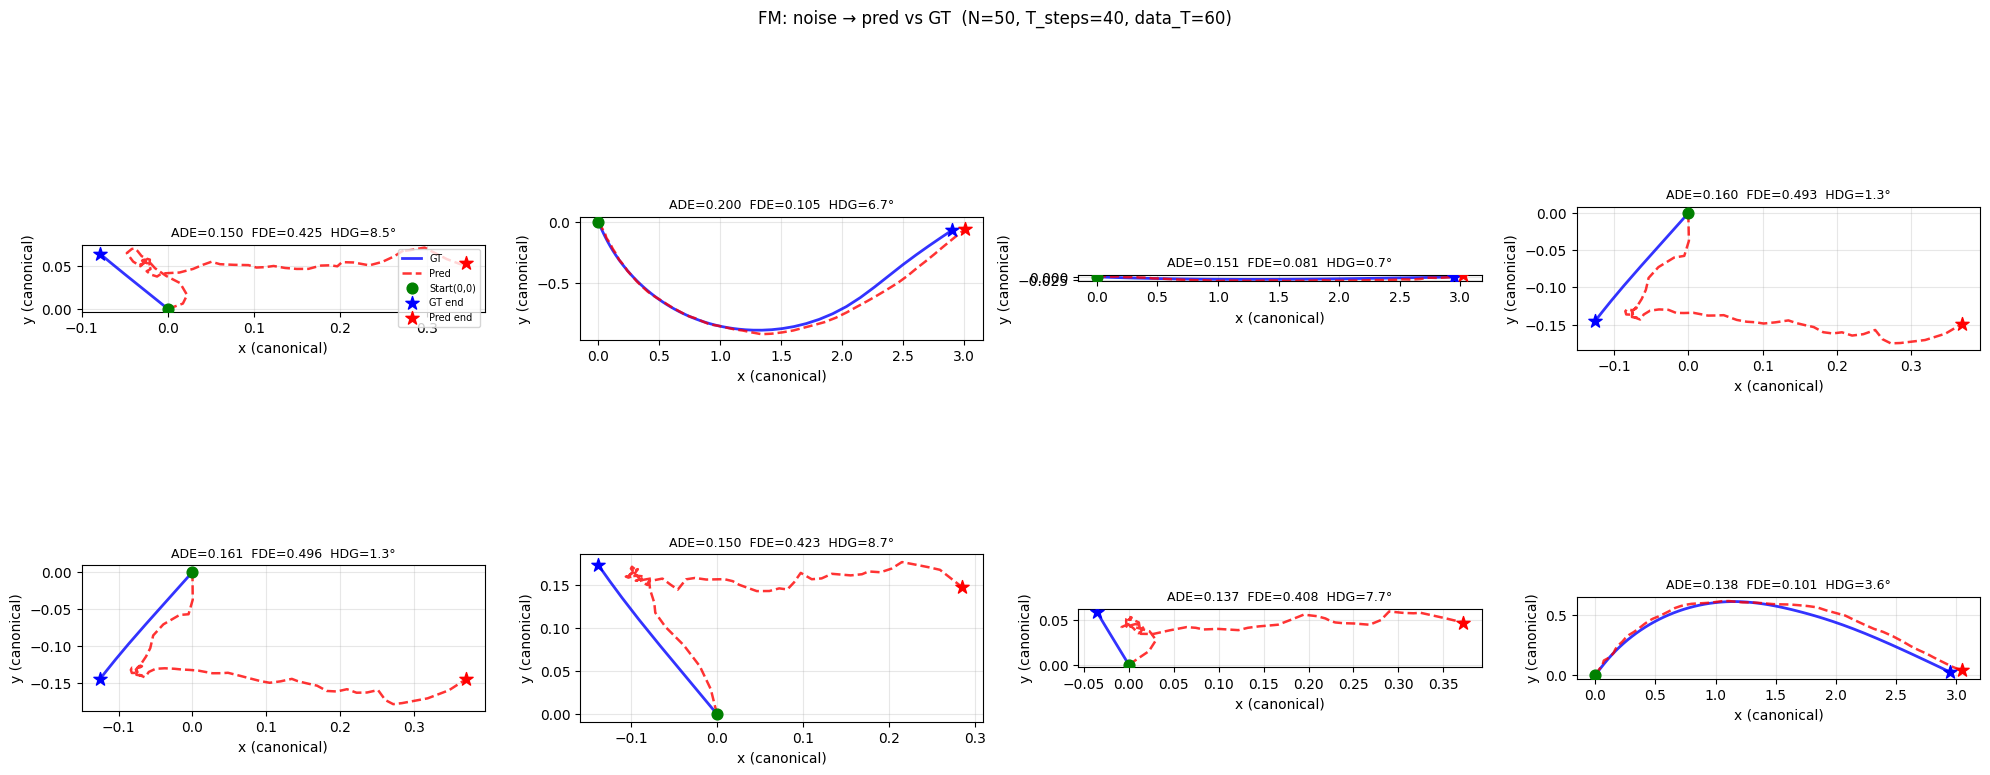

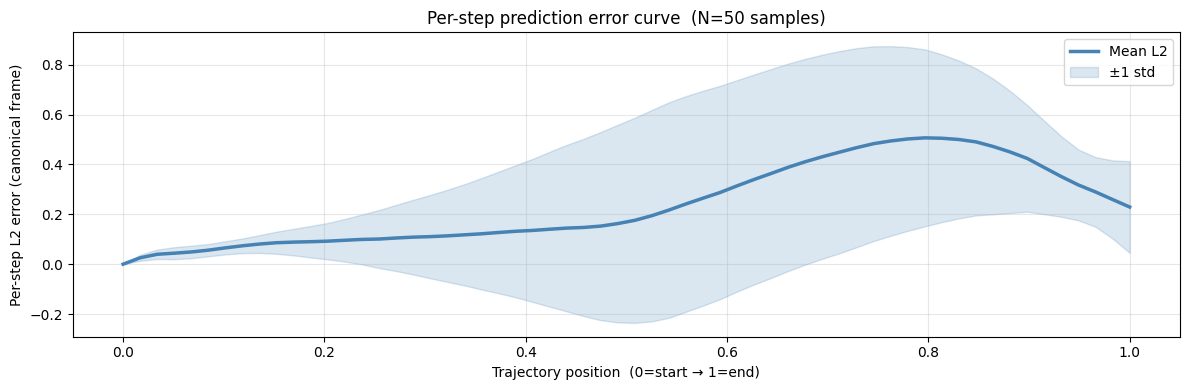

In [14]:
# ============================================================
# FM Validation — noise → piecewise_sample_fm_5ch_with_cbf → pred vs GT
#
# 数据集里的 canonical ground truth
# 你训练时想拟合的目标分布
#
#FM 生成得像不像训练数据。
#生成模型层 (generative model fidelity)

# pred_can vs traj_can 
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf（来自 sampler_5h.py）
#   - build_canonical_frame（两车实验 Section 4）
#   - make_x0_noise（两车实验 Section 7）
#   - T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
assert 'build_canonical_frame'            in dir(), "请先运行两车实验 cell"
assert 'make_x0_noise'                    in dir(), "请先运行两车实验 cell"
assert 'piecewise_sample_fm_5ch_with_cbf' in dir(), "请先运行两车实验 cell"
assert 'T_steps'                          in dir(), "请先运行两车实验 cell"
print("[依赖检查] ✓")


# ================================================================
# 0) 加载数据
# ================================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(
        r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache"
        r"\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
    )

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']  # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}  T={T}  D={D}")
print(f"[Params] T_steps={T_steps}  num_segments={num_segments}  "
      f"total_time={total_time}  ode_method={ode_method}")
if T_steps != T:
    print(f"[注意] T_steps({T_steps}) != 数据T({T})，pred 会插值对齐")

# 构建 5-channel（channel 定义与训练完全一致）
# ch0=x, ch1=y, ch2=theta, ch3=a, ch4=delta_rate
traj_5ch = np.stack([
    states[:, :, 0],    # x
    states[:, :, 1],    # y
    states[:, :, 2],    # theta
    controls[:, :, 0],  # a
    controls[:, :, 1],  # delta_rate
], axis=1).astype(np.float32)  # (N, 5, T)


# ================================================================
# 1) canonical frame 转换
#
# ★ cond 修复：
#   v0     来自 states[idx, 0, 3]  （速度，不是加速度）
#   delta0 来自 states[idx, 0, 4]  （转向角，不是转向角速度）
#   不能从 traj_5ch[idx, 3, 0] / traj_5ch[idx, 4, 0] 取，
#   因为那两个是 a0 和 delta_rate0
# ================================================================
def canonicalize_single(traj_i, states_i, goal_xy=None):
    """
    traj_i:   (5, T)  [x, y, theta, a, delta_rate]
    states_i: (T, 5)  [x, y, theta, v, delta]  ← 用于取 v0, delta0
    goal_xy:  (2,) or None

    返回:
      traj_can : (5, T)  canonical frame 轨迹
      cond     : (5,)    [dist, v0, cos(th0_can), sin(th0_can), delta0]
      tf       : 变换字典
    """
    x0 = float(traj_i[0, 0]);  y0 = float(traj_i[1, 0])
    gx = float(goal_xy[0]) if goal_xy is not None else float(traj_i[0, -1])
    gy = float(goal_xy[1]) if goal_xy is not None else float(traj_i[1, -1])

    # ★ 直接调用前面已定义的 build_canonical_frame
    tf = build_canonical_frame(
        np.array([x0, y0], np.float32),
        np.array([gx, gy], np.float32)
    )

    out    = traj_i.copy()
    xy_can = tf["w2c"](traj_i[0:2, :].T)  # (T, 2)
    out[0] = xy_can[:, 0]
    out[1] = xy_can[:, 1]
    out[2] = np.array([tf["w2c_angle"](float(th)) for th in traj_i[2]])

    th0_can = tf["w2c_angle"](float(traj_i[2, 0]))

    # ★ 修复：v0 和 delta0 从 states_i 取，而不是从 traj_i[3,0]/traj_i[4,0]
    v0     = float(states_i[0, 3])  # states 第3列 = v（速度）
    delta0 = float(states_i[0, 4])  # states 第4列 = delta（转向角）

    cond = np.array([
        tf["dist"],
        v0,
        float(np.cos(th0_can)),
        float(np.sin(th0_can)),
        delta0,
    ], dtype=np.float32)

    return out, cond, tf


# ================================================================
# 2) FM 预测：直接调用 piecewise_sample_fm_5ch_with_cbf
#    use_cbf=False，参数与两车实验完全一致
# ================================================================
def fm_predict_full(cond, tf, seed=0):
    """
    noise → piecewise_sample_fm_5ch_with_cbf(use_cbf=False) → pred (5, T)
    参数与两车实验 mpc_replan 里的调用完全一致。
    """
    # ★ 直接调用前面已定义的 make_x0_noise
    x0_noise = make_x0_noise(T_steps, seed)

    # ★ 直接调用前面已加载的 piecewise_sample_fm_5ch_with_cbf
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )  # x_can: (5, T_steps)

    # 插值对齐到数据长度 T
    if x_can.shape[1] != T:
        t_old  = np.linspace(0.0, 1.0, x_can.shape[1])
        t_new  = np.linspace(0.0, 1.0, T)
        x_can  = np.stack([
            interp1d(t_old, x_can[ch], kind='linear')(t_new)
            for ch in range(5)
        ], axis=0).astype(np.float32)

    return x_can  # (5, T)


# ================================================================
# 3) 指标
# ================================================================
def compute_metrics(pred_can, traj_can):
    pred_xy  = pred_can[0:2, :].T          # (T, 2)
    true_xy  = traj_can[0:2, :].T
    per_step = np.linalg.norm(pred_xy - true_xy, axis=1)  # (T,)

    ade = float(per_step.mean())
    fde = float(np.linalg.norm(pred_xy[-1] - true_xy[-1]))

    hdg_diff = (pred_can[2] - traj_can[2] + np.pi) % (2 * np.pi) - np.pi
    hdg      = float(np.mean(np.abs(hdg_diff)))

    return ade, fde, hdg, per_step


# ================================================================
# 4) 主验证循环
# ================================================================
N_SAMPLES = 50
np.random.seed(42)

ades, fdes, hdgs = [], [], []
all_per_step     = []

print(f"\n验证中... (N={N_SAMPLES} samples)")

for i in range(N_SAMPLES):
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]          # (5, T)
    states_i = states[idx]            # (T, 5)  ← 传给 canonicalize_single
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=i)

    ade, fde, hdg, per_step = compute_metrics(pred_can, traj_can)

    ades.append(ade);  fdes.append(fde)
    hdgs.append(hdg);  all_per_step.append(per_step)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{N_SAMPLES}]  "
              f"ADE={np.mean(ades):.4f}  "
              f"FDE={np.mean(fdes):.4f}  "
              f"HDG={np.rad2deg(np.mean(hdgs)):.2f}°")


# ================================================================
# 5) 结果打印
# ================================================================
print(f"\n{'='*50}")
print(f"  ADE  : {np.mean(ades):.4f}  ±{np.std(ades):.4f}")
print(f"  FDE  : {np.mean(fdes):.4f}  ±{np.std(fdes):.4f}")
print(f"  HDG  : {np.rad2deg(np.mean(hdgs)):.2f}°  "
      f"±{np.rad2deg(np.std(hdgs)):.2f}°")
print(f"{'='*50}")
print()
print("判断标准（canonical frame）：")
print("  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题")
print("  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题")
print("  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题")


# ================================================================
# 6) 图1：8 条代表性轨迹对比
# ================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
np.random.seed(0)

for pi in range(8):
    ax       = axes[pi]
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]
    states_i = states[idx]
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=pi * 13)
    a, f, h, _         = compute_metrics(pred_can, traj_can)

    ax.plot(traj_can[0], traj_can[1],
            'b-',  lw=2.0, alpha=0.8, label="GT")
    ax.plot(pred_can[0], pred_can[1],
            'r--', lw=1.8, alpha=0.8, label="Pred")
    ax.scatter([0], [0],
               c='green', s=60, zorder=6, label="Start(0,0)")
    ax.scatter([traj_can[0, -1]], [traj_can[1, -1]],
               c='blue', s=100, marker='*', zorder=6, label="GT end")
    ax.scatter([pred_can[0, -1]], [pred_can[1, -1]],
               c='red',  s=100, marker='*', zorder=6, label="Pred end")

    ax.set_title(
        f"ADE={a:.3f}  FDE={f:.3f}  HDG={np.rad2deg(h):.1f}°",
        fontsize=9
    )
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")
    if pi == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    f"FM: noise → pred vs GT  "
    f"(N={N_SAMPLES}, T_steps={T_steps}, data_T={T})",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 7) 图2：逐步误差曲线
# ================================================================
mean_curve = np.mean(all_per_step, axis=0)
std_curve  = np.std(all_per_step,  axis=0)
t_axis     = np.linspace(0.0, 1.0, T)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_axis, mean_curve, lw=2.5, color='steelblue', label="Mean L2")
ax.fill_between(t_axis,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.2, color='steelblue', label="±1 std")
ax.set_xlabel("Trajectory position  (0=start → 1=end)")
ax.set_ylabel("Per-step L2 error (canonical frame)")
ax.set_title(f"Per-step prediction error curve  (N={N_SAMPLES} samples)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[依赖检查] ✓
FM Trackability Validation
  每个 seed 独立：fm_path → PP rollout → compare

[Scene] Agent A (diagonal)
  seed=0  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1460  FDE_fm=0.6383
  seed=1  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1474  FDE_fm=0.6373
  seed=2  n_pp= 47  n_fm= 40  ADE=1.0084  FDE_pp=0.1470  FDE_fm=0.6373

[Scene] Agent B (diagonal)
  seed=0  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1461  FDE_fm=0.6381
  seed=1  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1474  FDE_fm=0.6373
  seed=2  n_pp= 47  n_fm= 40  ADE=1.0084  FDE_pp=0.1471  FDE_fm=0.6372

[Scene] Horizontal
  seed=0  n_pp= 43  n_fm= 40  ADE=0.8234  FDE_pp=0.1475  FDE_fm=0.3132
  seed=1  n_pp= 43  n_fm= 40  ADE=0.8229  FDE_pp=0.1486  FDE_fm=0.3127
  seed=2  n_pp= 43  n_fm= 40  ADE=0.8240  FDE_pp=0.1474  FDE_fm=0.3123

[Scene] Angled start
  seed=0  n_pp= 41  n_fm= 40  ADE=0.6944  FDE_pp=0.1413  FDE_fm=0.0381
  seed=1  n_pp= 41  n_fm= 40  ADE=0.6941  FDE_pp=0.1418  FDE_fm=0.0386
  seed=2  n_pp= 41  n_fm= 40  ADE=0.6955 

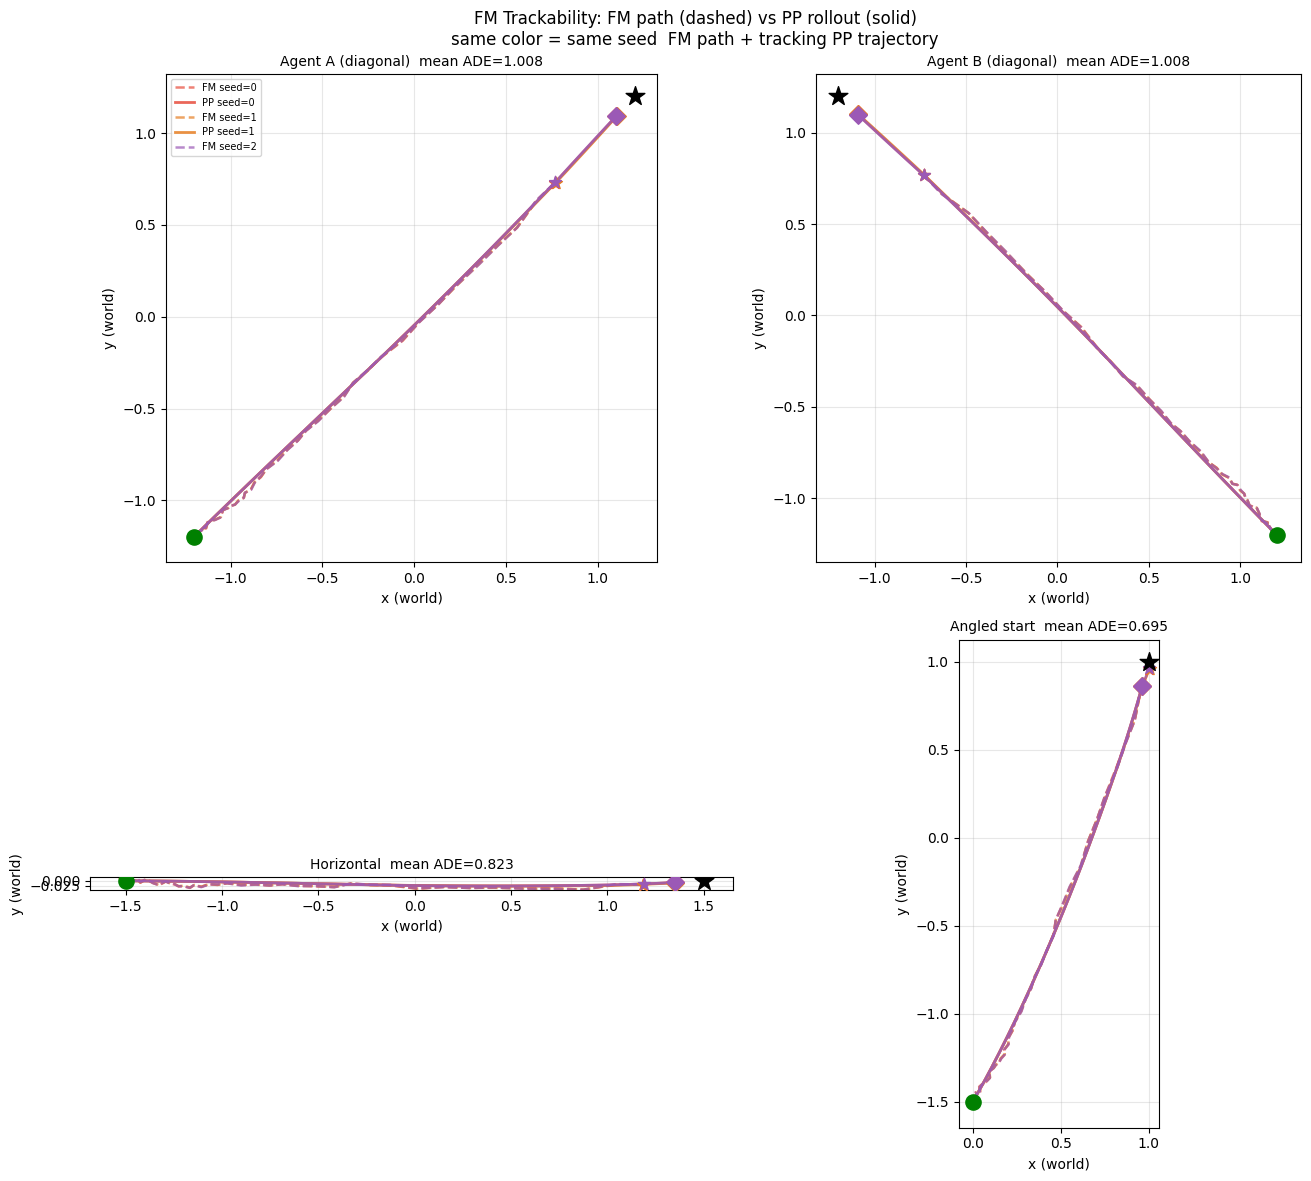

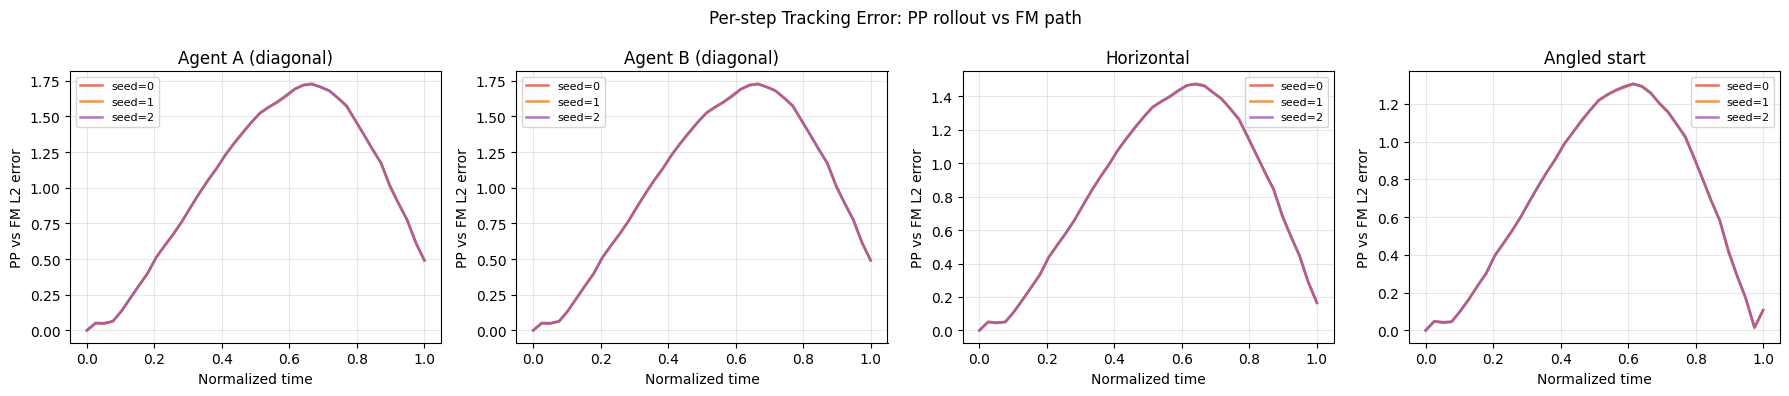

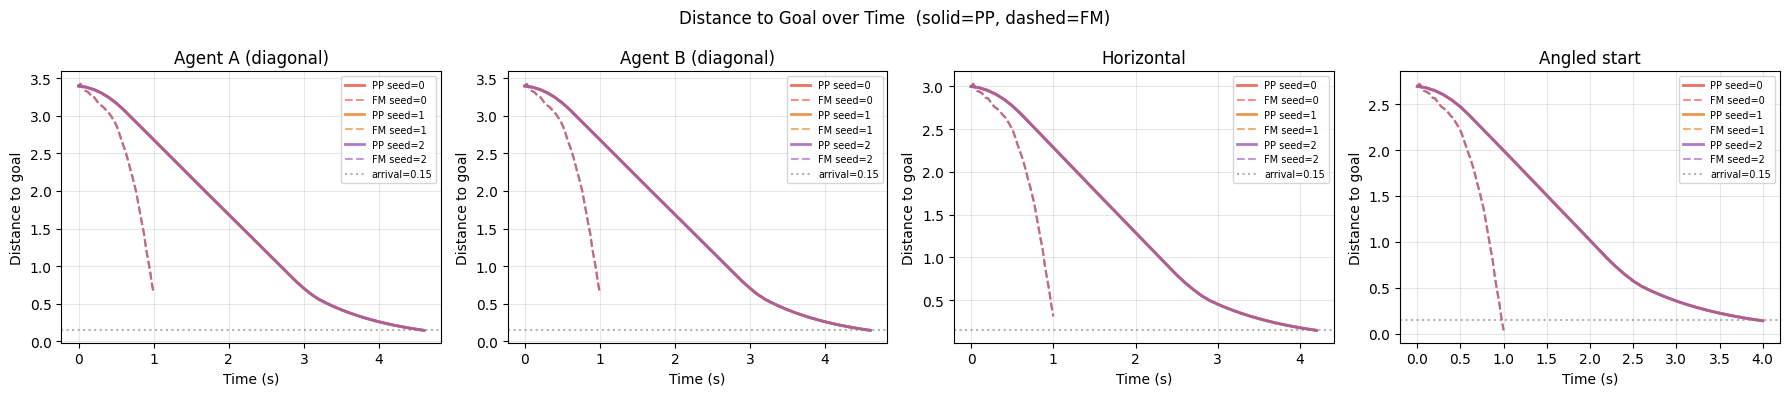

In [24]:
# ============================================================
# FM Validation — Trackability
#
# 验证：FM 生成的路径是否可以被 Pure Pursuit 稳定跟踪
#
# 结构（每个 seed 独立一对）：
#   fm_path  = rollout_fm(start, goal, seed)
#   traj_pp  = rollout_pure_pursuit(start, goal, ref=fm_path)
#   compare(traj_pp, fm_path)
#
# 指标：
#   ADE  小 → FM path 动力学可行，PP 能跟上
#   ADE  大 → FM path 动力学不可行，PP 跟不上
#   FDE_pp  → PP 实际执行后距终点多远
#   FDE_fm  → FM path 终点距目标多远
#
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf
#   - build_canonical_frame, make_x0_noise
#   - bicycle_step, pure_pursuit_controls
#   - wrap_pi, T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
for _name in ['build_canonical_frame', 'make_x0_noise',
              'piecewise_sample_fm_5ch_with_cbf',
              'bicycle_step', 'pure_pursuit_controls',
              'T_steps', 'noise_scale']:
    assert _name in dir(), f"请先运行两车实验 cell：{_name} 未定义"
print("[依赖检查] ✓")


# ================================================================
# 1) FM path generation
# ================================================================
def rollout_fm(start_state, goal_xy, seed=0):
    """
    noise → piecewise_sample（无CBF）→ FM path（world frame）
    返回:
      path_world: (T_steps, 2)  world frame XY
      x_can:      (5, T_steps)  canonical frame 完整轨迹
      tf:         canonical frame 变换字典
    """
    tf = build_canonical_frame(start_state[:2], goal_xy)

    v0     = float(start_state[3])
    delta0 = float(start_state[4])
    th_can = tf["w2c_angle"](float(start_state[2]))
    cond   = np.array([
        tf["dist"],
        v0,
        float(np.cos(th_can)),
        float(np.sin(th_can)),
        delta0,
    ], dtype=np.float32)

    x0_noise = make_x0_noise(T_steps, seed)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,   # ★ 无CBF
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )

    path_world = tf["c2w"](x_can[0:2, :].T)  # (T_steps, 2)
    return path_world, x_can, tf


# ================================================================
# 2) Pure Pursuit rollout
#    ★ ref_path 就是对应 seed 的 FM path，一对一
# ================================================================
def rollout_pure_pursuit(start_state, goal_xy, ref_path_xy,
                         *, max_steps=300, dt=0.1, v_max=1.0):
    """
    start_state:  (5,) [x, y, theta, v, delta]
    goal_xy:      (2,)
    ref_path_xy:  (T, 2) world frame，来自同一个 seed 的 FM path
    返回:
      traj: (steps+1, 5)
    """
    s    = start_state.copy()
    traj = [s.copy()]
    goal = np.asarray(goal_xy, np.float32)

    for _ in range(max_steps):
        if float(np.linalg.norm(s[:2] - goal)) < 0.15:
            break
        U = pure_pursuit_controls(s, ref_path_xy, goal,
                                  H=1, dt=dt, v_max=v_max)
        s = bicycle_step(s, U[0], dt=dt, v_max=v_max)
        traj.append(s.copy())

    return np.array(traj, dtype=np.float32)  # (steps+1, 5)


# ================================================================
# 3) 指标
# ================================================================
def align_xy(arr, target_len):
    """(M, 2) → (target_len, 2) 线性插值"""
    M = len(arr)
    if M == target_len:
        return arr
    t_old = np.linspace(0.0, 1.0, M)
    t_new = np.linspace(0.0, 1.0, target_len)
    return np.stack([
        interp1d(t_old, arr[:, d])(t_new) for d in range(2)
    ], axis=1).astype(np.float32)


def compute_metrics(traj_pp, fm_path, goal_xy):
    """
    traj_pp:  (N, 5)  PP 执行轨迹
    fm_path:  (M, 2)  FM 生成路径
    goal_xy:  (2,)
    """
    pp_xy = traj_pp[:, 0:2]
    fm_xy = fm_path
    goal  = np.asarray(goal_xy, np.float32)

    n    = min(len(pp_xy), len(fm_xy))
    pp_a = align_xy(pp_xy, n)
    fm_a = align_xy(fm_xy, n)

    per_step = np.linalg.norm(pp_a - fm_a, axis=1)  # (n,)

    return {
        "ADE":    float(per_step.mean()),
        "FDE_pp": float(np.linalg.norm(pp_xy[-1] - goal)),
        "FDE_fm": float(np.linalg.norm(fm_xy[-1] - goal)),
        "per_step": per_step,
        "n_pp":   len(pp_xy),
        "n_fm":   len(fm_xy),
    }


# ================================================================
# 4) 场景定义
# ================================================================
SCENARIOS = [
    {"name": "Agent A (diagonal)",
     "start": np.array([-1.2, -1.2, float(np.arctan2(2.4, 2.4)), 0., 0.], np.float32),
     "goal":  np.array([1.2, 1.2], np.float32)},

    {"name": "Agent B (diagonal)",
     "start": np.array([1.2, -1.2, float(np.arctan2(2.4, -2.4)), 0., 0.], np.float32),
     "goal":  np.array([-1.2, 1.2], np.float32)},

    {"name": "Horizontal",
     "start": np.array([-1.5, 0., 0., 0., 0.], np.float32),
     "goal":  np.array([1.5, 0.], np.float32)},

    {"name": "Angled start",
     "start": np.array([0., -1.5, float(np.deg2rad(60)), 0., 0.], np.float32),
     "goal":  np.array([1.0, 1.0], np.float32)},
]

N_SEEDS  = 3
DT       = 0.1
V_MAX    = 1.0

# ================================================================
# 5) 主循环：每个 seed 独立一对 (fm_path, traj_pp)
# ================================================================
print("=" * 60)
print("FM Trackability Validation")
print("  每个 seed 独立：fm_path → PP rollout → compare")
print("=" * 60)

all_results = []   # list of dict

for sc in SCENARIOS:
    sc_metrics = []
    print(f"\n[Scene] {sc['name']}")

    for seed in range(N_SEEDS):
        # ★ 核心：每个 seed 各自生成 fm_path，再用该 path 作 PP 参考
        fm_path, x_can, tf = rollout_fm(sc["start"], sc["goal"], seed=seed)
        traj_pp             = rollout_pure_pursuit(
            sc["start"], sc["goal"], fm_path,
            max_steps=300, dt=DT, v_max=V_MAX
        )
        m = compute_metrics(traj_pp, fm_path, sc["goal"])
        sc_metrics.append({
            "seed":    seed,
            "fm_path": fm_path,
            "traj_pp": traj_pp,
            **m,
        })
        print(f"  seed={seed}  n_pp={m['n_pp']:3d}  n_fm={m['n_fm']:3d}  "
              f"ADE={m['ADE']:.4f}  FDE_pp={m['FDE_pp']:.4f}  "
              f"FDE_fm={m['FDE_fm']:.4f}")

    all_results.append({"scene": sc, "metrics": sc_metrics})

# ================================================================
# 6) 汇总
# ================================================================
flat = [m for r in all_results for m in r["metrics"]]
print(f"\n{'='*60}")
print(f"汇总（{len(flat)} 对）：")
print(f"  Mean ADE         : {np.mean([m['ADE']    for m in flat]):.4f}"
      f"  ← PP 跟踪 FM path 的平均偏差")
print(f"  Mean FDE_pp→goal : {np.mean([m['FDE_pp'] for m in flat]):.4f}"
      f"  ← PP 执行后距终点距离")
print(f"  Mean FDE_fm→goal : {np.mean([m['FDE_fm'] for m in flat]):.4f}"
      f"  ← FM path 终点距目标距离")
print(f"{'='*60}")
print()
print("解读：")
print("  ADE 小 → FM path 动力学可行，PP 能稳定跟踪")
print("  ADE 大 → FM path 动力学不可行，PP 跟不上")
print("  FDE_fm 小 → FM 能正确生成朝向目标的路径")


# ================================================================
# 7) 图1：XY 轨迹对比（4 场景 × 3 seed）
# ================================================================
colors_seed = ['#e74c3c', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for sc_i, res in enumerate(all_results):
    ax   = axes[sc_i]
    sc   = res["scene"]
    goal = sc["goal"]

    for m in res["metrics"]:
        seed    = m["seed"]
        fm_path = m["fm_path"]
        traj_pp = m["traj_pp"]
        c       = colors_seed[seed]

        # FM path
        ax.plot(fm_path[:, 0], fm_path[:, 1],
                '--', lw=1.8, alpha=0.7, color=c,
                label=f"FM seed={seed}")
        # PP rollout（跟踪同一条 FM path）
        ax.plot(traj_pp[:, 0], traj_pp[:, 1],
                '-', lw=2.0, alpha=0.85, color=c,
                label=f"PP seed={seed}")
        # PP 终点
        ax.scatter(traj_pp[-1, 0], traj_pp[-1, 1],
                   c=c, s=80, marker='D', zorder=6)
        # FM 终点
        ax.scatter(fm_path[-1, 0], fm_path[-1, 1],
                   c=c, s=80, marker='*', zorder=6)

    # 起点 / 目标
    ax.scatter(*sc["start"][:2], c='green', s=120,
               marker='o', zorder=7, label="Start")
    ax.scatter(*goal, c='black', s=200,
               marker='*', zorder=7, label="Goal")

    mean_ade = np.mean([m['ADE'] for m in res["metrics"]])
    ax.set_title(f"{sc['name']}  mean ADE={mean_ade:.3f}", fontsize=10)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (world)"); ax.set_ylabel("y (world)")
    if sc_i == 0:
        # 简化图例：只显示一组
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:5], labels[:5], fontsize=7)

plt.suptitle(
    "FM Trackability: FM path (dashed) vs PP rollout (solid)\n"
    "same color = same seed  FM path + tracking PP trajectory",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 8) 图2：每步跟踪误差曲线
# ================================================================
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(18, 4))

for sc_i, res in enumerate(all_results):
    ax = axes[sc_i]
    for m in res["metrics"]:
        t = np.linspace(0.0, 1.0, len(m["per_step"]))
        ax.plot(t, m["per_step"], lw=1.8, alpha=0.8,
                color=colors_seed[m["seed"]],
                label=f"seed={m['seed']}")
    ax.set_title(res["scene"]["name"])
    ax.set_xlabel("Normalized time")
    ax.set_ylabel("PP vs FM L2 error")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-step Tracking Error: PP rollout vs FM path", fontsize=12)
plt.tight_layout()
plt.show()


# ================================================================
# 9) 图3：距终点距离曲线
# ================================================================
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(18, 4))

for sc_i, res in enumerate(all_results):
    ax   = axes[sc_i]
    goal = res["scene"]["goal"]

    for m in res["metrics"]:
        c       = colors_seed[m["seed"]]
        traj_pp = m["traj_pp"]
        fm_path = m["fm_path"]

        # PP 距终点
        pp_dist = np.linalg.norm(traj_pp[:, 0:2] - goal, axis=1)
        t_pp    = np.arange(len(pp_dist)) * DT
        ax.plot(t_pp, pp_dist, '-', lw=2.0, alpha=0.8, color=c,
                label=f"PP seed={m['seed']}")

        # FM 距终点
        fm_dist = np.linalg.norm(fm_path - goal, axis=1)
        t_fm    = np.linspace(0, total_time, len(fm_dist))
        ax.plot(t_fm, fm_dist, '--', lw=1.5, alpha=0.6, color=c,
                label=f"FM seed={m['seed']}")

    ax.axhline(0.15, ls=':', color='gray', alpha=0.6, label="arrival=0.15")
    ax.set_title(res["scene"]["name"])
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Distance to goal")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("Distance to Goal over Time  (solid=PP, dashed=FM)", fontsize=12)
plt.tight_layout()
plt.show()

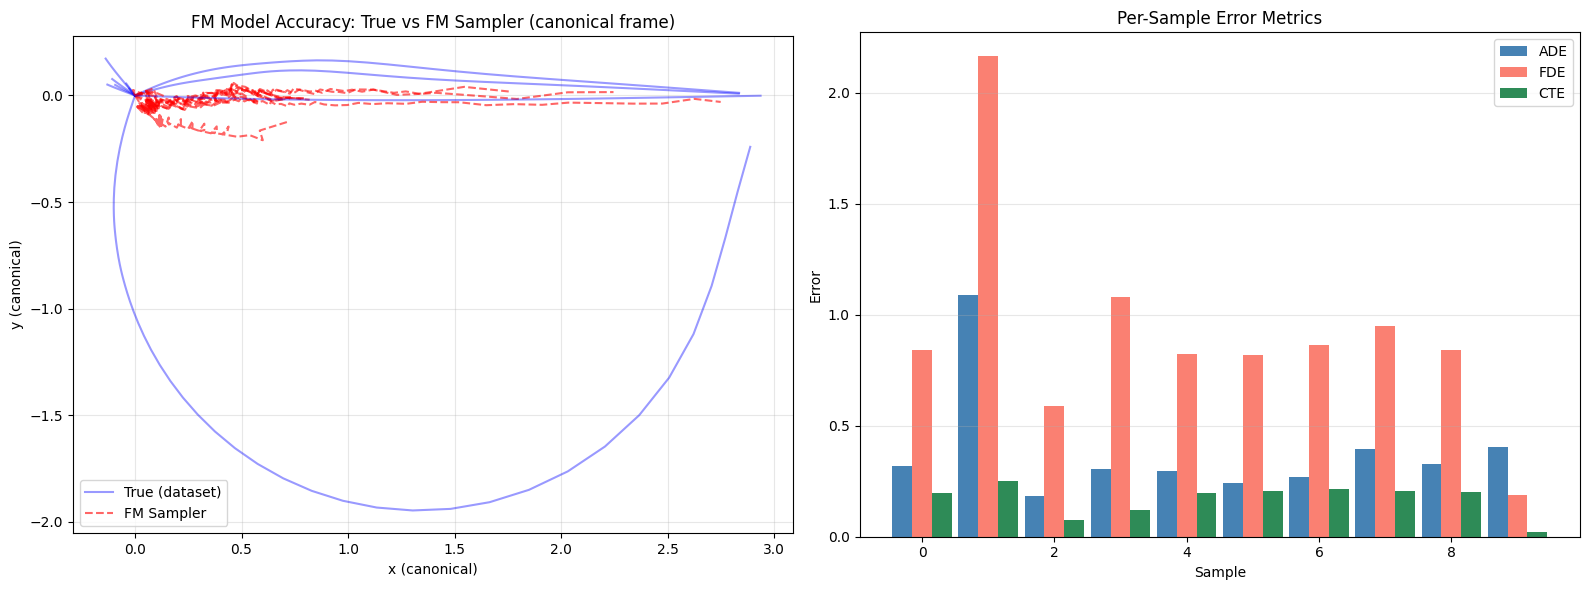


FM Model Validation (10 samples)
  ADE (Average Displacement Error): 0.3823 +/- 0.2436
  FDE (Final Displacement Error):   0.9163 +/- 0.4745
  CTE (Cross-Track Error):          0.1693 +/- 0.0691

  Result: FM model has significant deviation (ADE > 0.15), check model/training


In [16]:
# ===============================================================
# FM Model Validation: True Canonical Trajectory vs FM Sampler Output
# 使用 piecewise_sample_fm_5ch_with_cbf (sampler_5h.py) 生成轨迹
#Q：给定相同的初始条件，FM 模型能不能生成和真实数据类似的轨迹？
# ===============================================================

import matplotlib.pyplot as plt

model_5ch.eval()
torch.set_grad_enabled(False)

N_CHECK = 10
FM_NOISE_SCALE = 0.08   # 和 MPC 部署时一致
FM_NUM_SEG     = 10
FM_ODE_METHOD  = "euler"

rng = np.random.default_rng(42)
selected_idx = rng.choice(len(traj_5ch), size=N_CHECK, replace=False)

# ---------------------------------------------------------------
# FM 模型精度: FM canonical path vs true canonical path
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1, ax2 = axes

ade_list = []   # Average Displacement Error
fde_list = []   # Final Displacement Error
cte_list = []   # Cross-Track Error

for i, idx in enumerate(selected_idx):
    traj_true = traj_5ch[idx]  # (5, T)
    goal_xy = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj_true, goal_xy=goal_xy)
    T_len = traj_can.shape[1]

    # --- FM 采样 (CBF off, 纯模型能力测试) ---
    x0_noise = torch.randn((1, 5, T_len), device=device) * FM_NOISE_SCALE
    x0_noise[:, :, 0] = 0.0   # lock start

    x_fm, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch    = model_5ch,
        T_steps      = T_len,
        device       = str(device),
        cond         = cond,
        use_cbf      = False,          # 纯 FM, 不加 CBF
        noise_scale  = FM_NOISE_SCALE,
        x0_noise     = x0_noise,
        lock_start   = True,
        start_xy_norm = np.array([0.0, 0.0], dtype=np.float32),
        goal_xy_norm  = np.array([cond[0], 0.0], dtype=np.float32),
        start_guidance_weight = 0.45,
        goal_guidance_weight  = 0.90,
        goal_guidance_mode    = "tail",
        num_segments = FM_NUM_SEG,
        ode_method   = FM_ODE_METHOD,
    )  # x_fm: (5, T)

    # --- 计算指标 ---
    true_xy = traj_can[0:2, :].T   # (T, 2)
    fm_xy   = x_fm[0:2, :].T       # (T, 2)

    pos_err = np.linalg.norm(fm_xy - true_xy, axis=1)  # (T,)
    ade = float(np.mean(pos_err))
    fde = float(pos_err[-1])
    # cross-track: 每个 FM 点到 true 路径最近点的距离
    cte_vals = []
    for j in range(len(fm_xy)):
        dists = np.linalg.norm(true_xy - fm_xy[j], axis=1)
        cte_vals.append(float(np.min(dists)))
    cte = float(np.mean(cte_vals))

    ade_list.append(ade)
    fde_list.append(fde)
    cte_list.append(cte)

    # --- 绘图 ---
    ax1.plot(traj_can[0], traj_can[1], 'b-', alpha=0.4,
             label="True (dataset)" if i == 0 else "")
    ax1.plot(x_fm[0], x_fm[1], 'r--', alpha=0.6,
             label="FM Sampler" if i == 0 else "")

ax1.set_title("FM Model Accuracy: True vs FM Sampler (canonical frame)")
ax1.set_xlabel("x (canonical)")
ax1.set_ylabel("y (canonical)")
ax1.legend()
ax1.set_aspect("equal")
ax1.grid(alpha=0.3)

# --- 误差柱状图 ---
x_pos = np.arange(N_CHECK)
width = 0.3
ax2.bar(x_pos - width, ade_list, width, label='ADE', color='steelblue')
ax2.bar(x_pos,         fde_list, width, label='FDE', color='salmon')
ax2.bar(x_pos + width, cte_list, width, label='CTE', color='seagreen')
ax2.set_xlabel("Sample")
ax2.set_ylabel("Error")
ax2.set_title("Per-Sample Error Metrics")
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- 汇总 ---
print(f"\n{'='*60}")
print(f"FM Model Validation ({N_CHECK} samples)")
print(f"{'='*60}")
print(f"  ADE (Average Displacement Error): {np.mean(ade_list):.4f} +/- {np.std(ade_list):.4f}")
print(f"  FDE (Final Displacement Error):   {np.mean(fde_list):.4f} +/- {np.std(fde_list):.4f}")
print(f"  CTE (Cross-Track Error):          {np.mean(cte_list):.4f} +/- {np.std(cte_list):.4f}")

mean_ade = np.mean(ade_list)
if mean_ade < 0.05:
    print("\n  Result: FM model accuracy is very good (ADE < 0.05)")
elif mean_ade < 0.15:
    print("\n  Result: FM model accuracy is acceptable (0.05 < ADE < 0.15)")
else:
    print("\n  Result: FM model has significant deviation (ADE > 0.15), check model/training")


[device] cuda
[Data] N=100, T=60, D=5
[Data] ctrl_2ch: (100, 2, 60), cond: (100, 6)
[Cond] dx_can mean=3.000 std=0.000
[Cond] dy_can mean=0.000 std=0.000  (should be ≈0)

[Norm] ctrl_mean = [-0.07357636  0.05364437]
[Norm] ctrl_std  = [0.54194385 0.64408153]
[Norm] cond_mean = [3.        0.        0.3754593 0.        0.        0.       ]
[Norm] cond_scale= [1.0000000e-06 1.0000000e-06 1.3071911e-01 1.0000000e+00 1.0000000e+00
 1.0000000e-06]

[Augmentation]
[Augmented] X1: (2200, 2, 60), cond: (2200, 6)
[Split] Train: 1760, Val: 440
[Model] Parameters: 730,690
[Model] Data/Param ratio: 0.0024

SafeFM Training: 2ch ctrl, 6dim cond, noise+mirror aug
Epochs=3000, LR=3e-4, Patience=300

  Epoch    1 | train=1.2301 | val=1.0402 | gap=-0.1899 ★ best
  Epoch   50 | train=0.2919 | val=0.3027 | gap=0.0108 ★ best
  Epoch  100 | train=0.1827 | val=0.2186 | gap=0.0359 ★ best
  Epoch  150 | train=0.1351 | val=0.1573 | gap=0.0222 ★ best
  Epoch  200 | train=0.1159 | val=0.1256 | gap=0.0096 ★ best
  

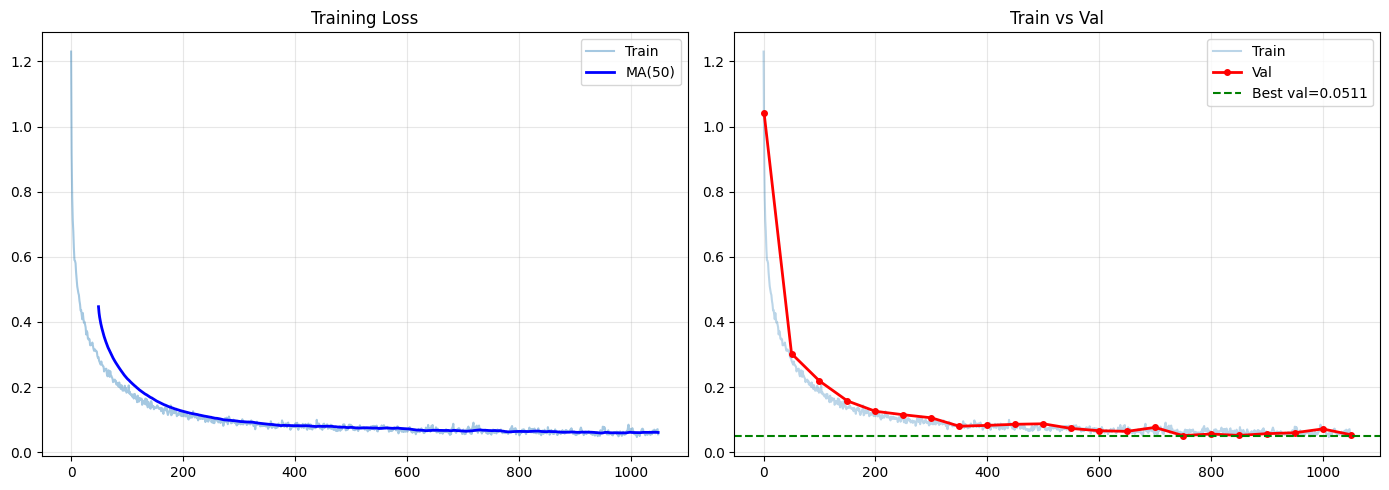

In [1]:
# ===============================================================
# 训练 SafeFM: 只预测 2维控制量 [a, delta_rate]
# cond 升级为 6维: [dx_can, dy_can, v0, cos(th0_can), sin(th0_can), delta0]
# 有 augmentation + validation + early stopping
# ===============================================================

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path
import matplotlib.pyplot as plt
import sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

torch.set_grad_enabled(True)

fmtorch_root = Path.cwd().parent.resolve()
if str(fmtorch_root) not in sys.path:
    sys.path.insert(0, str(fmtorch_root))

# ---------------------------------------------------------------
# 1) 加载数据
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# ---------------------------------------------------------------
# 2) 构建控制量 + cond
# ---------------------------------------------------------------
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

ctrl_2ch = np.stack([
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1).astype(np.float32)  # (N, 2, T)


def canonicalize_batch_cond_only(trajs, states_raw, goals_xy=None):
    """
    6维 cond: [dx_can, dy_can, v0, cos(th0_can), sin(th0_can), delta0]

    dx_can, dy_can: goal 在 canonical frame 里的相对坐标
      - canonical frame: 以 start 为原点，goal 方向为 +x 轴
      - 理论上 dy_can ≈ 0，但保留让模型学习残差，比强制截断更鲁棒
      - dist = sqrt(dx_can² + dy_can²) 隐含在向量里，不再单独编码
    """
    N2 = trajs.shape[0]
    cond_list = []
    for i in range(N2):
        x0, y0 = float(trajs[i, 0, 0]), float(trajs[i, 1, 0])
        th0     = float(trajs[i, 2, 0])

        if goals_xy is not None:
            gx, gy = float(goals_xy[i, 0]), float(goals_xy[i, 1])
        else:
            gx, gy = float(trajs[i, 0, -1]), float(trajs[i, 1, -1])

        # world frame 里的 goal offset
        dx_w = gx - x0
        dy_w = gy - y0

        # canonical frame 旋转角：让 goal 对齐 +x 轴
        angle_off = float(np.arctan2(dy_w, dx_w))

        # goal 在 canonical frame 里的坐标
        cos_a  =  np.cos(angle_off)
        sin_a  =  np.sin(angle_off)
        dx_can =  cos_a * dx_w + sin_a * dy_w   # ≈ dist (正值)
        dy_can = -sin_a * dx_w + cos_a * dy_w   # ≈ 0，保留残差信息

        # 初始朝向在 canonical frame 里
        th0_can = float((th0 - angle_off + np.pi) % (2 * np.pi) - np.pi)

        cond_list.append([
            dx_can,                           # goal x (canonical) ≈ dist
            dy_can,                           # goal y (canonical) ≈ 0
            float(states_raw[i, 0, 3]),       # v0
            float(np.cos(th0_can)),           # cos(初始朝向)
            float(np.sin(th0_can)),           # sin(初始朝向)
            float(states_raw[i, 0, 4]),       # delta0
        ])
    return np.array(cond_list, dtype=np.float32)  # (N, 6)


cond_all = canonicalize_batch_cond_only(traj_5ch, states, goals)
print(f"[Data] ctrl_2ch: {ctrl_2ch.shape}, cond: {cond_all.shape}")
print(f"[Cond] dx_can mean={cond_all[:,0].mean():.3f} std={cond_all[:,0].std():.3f}")
print(f"[Cond] dy_can mean={cond_all[:,1].mean():.3f} std={cond_all[:,1].std():.3f}  (should be ≈0)")

# ---------------------------------------------------------------
# 3) 归一化 (6维)
# ---------------------------------------------------------------
ctrl_mean = ctrl_2ch.mean(axis=(0, 2), keepdims=True)
ctrl_std  = ctrl_2ch.std(axis=(0, 2),  keepdims=True).clip(min=1e-6)
ctrl_2ch_norm = (ctrl_2ch - ctrl_mean) / ctrl_std

cond_norm = cond_all.copy()

cond_mean_arr = np.array([
    cond_all[:, 0].mean(),   # dx_can
    cond_all[:, 1].mean(),   # dy_can (≈ 0)
    cond_all[:, 2].mean(),   # v0
    0.0,                     # cos — 不偏移
    0.0,                     # sin — 不偏移
    cond_all[:, 5].mean(),   # delta0
], dtype=np.float32)

cond_scale = np.array([
    cond_all[:, 0].std() + 1e-6,   # dx_can
    cond_all[:, 1].std() + 1e-6,   # dy_can
    cond_all[:, 2].std() + 1e-6,   # v0
    1.0,                            # cos
    1.0,                            # sin
    cond_all[:, 5].std() + 1e-6,   # delta0
], dtype=np.float32)

# dy_can 的 std 可能极小 → 归一化后方差爆炸，clip 保护
cond_scale[1] = max(float(cond_scale[1]), float(cond_scale[0]) * 0.1)

for i in [0, 1, 2, 5]:
    cond_norm[:, i] = (cond_all[:, i] - cond_mean_arr[i]) / cond_scale[i]
# cos/sin (index 3, 4) 保持原样，范围已在 [-1, 1]

norm_params = {
    "ctrl_mean":  ctrl_mean,
    "ctrl_std":   ctrl_std,
    "cond_mean":  cond_mean_arr,
    "cond_scale": cond_scale,
}
np.save("cache/safefm_norm_params.npy", norm_params)

print(f"\n[Norm] ctrl_mean = {ctrl_mean.squeeze()}")
print(f"[Norm] ctrl_std  = {ctrl_std.squeeze()}")
print(f"[Norm] cond_mean = {cond_mean_arr}")
print(f"[Norm] cond_scale= {cond_scale}")

# ---------------------------------------------------------------
# 4) 数据增强
# ---------------------------------------------------------------
def augment_data_2ch(X1, cond_all, aug_factor=15):
    """
    物理一致的增强：
    - 噪声：微扰 control 和 cond，保持 cond-control 关系
    - 镜像：Y轴翻转，同步取反 delta_rate / dy_can / sin(th0_can) / delta0
    """
    N2, C, T2 = X1.shape
    aug_X    = [X1]
    aug_cond = [cond_all]
    np.random.seed(42)

    for i in range(aug_factor - 1):
        # --- 噪声增强 ---
        noise_X = X1.copy()
        noise_X[:, 0, :] += np.random.randn(N2, T2) * 0.02   # a 噪声
        noise_X[:, 1, :] += np.random.randn(N2, T2) * 0.03   # delta_rate 噪声

        noise_cond = cond_all.copy()
        noise_cond[:, 0] += np.random.randn(N2) * 0.02        # dx_can
        noise_cond[:, 2] += np.random.randn(N2) * 0.02        # v0

        aug_X.append(noise_X)
        aug_cond.append(noise_cond)

        # --- 镜像增强（Y轴翻转，每隔一次）---
        # 控制量：delta_rate 取反
        # cond：dy_can 取反，sin(th0_can) 取反，delta0 取反
        # dx_can, v0, cos(th0_can) 不变（镜像不影响距离、速度、cos）
        if i % 2 == 0:
            mirror_X = X1.copy()
            mirror_X[:, 1, :] *= -1    # delta_rate 取反

            mirror_cond = cond_all.copy()
            mirror_cond[:, 1] *= -1    # dy_can 取反      ← 新增
            mirror_cond[:, 4] *= -1    # sin(th0_can) 取反
            mirror_cond[:, 5] *= -1    # delta0 取反

            aug_X.append(mirror_X)
            aug_cond.append(mirror_cond)

    return (np.concatenate(aug_X,    axis=0).astype(np.float32),
            np.concatenate(aug_cond, axis=0).astype(np.float32))


print("\n[Augmentation]")
X1_aug, cond_aug = augment_data_2ch(ctrl_2ch_norm, cond_norm, aug_factor=15)
print(f"[Augmented] X1: {X1_aug.shape}, cond: {cond_aug.shape}")

# ---------------------------------------------------------------
# 5) Train/Val Split
# ---------------------------------------------------------------
X1_t   = torch.tensor(X1_aug,   dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_aug, dtype=torch.float32, device=device)

full_ds    = TensorDataset(X1_t, cond_t)
train_size = int(0.8 * len(full_ds))
val_size   = len(full_ds) - train_size
train_ds, val_ds = random_split(
    full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, drop_last=False)
print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 6) 模型 (cond_dim: 5 → 6)
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_safefm_2ch.pt")

model_safefm = SimpleUNet1D(
    time_emb_dim = 64,
    hidden_dim   = 64,
    cond_dim     = 6,    # ← 5 → 6: 新增 dy_can
    in_channels  = 2,
    out_channels = 2,
).to(device)

n_params = sum(p.numel() for p in model_safefm.parameters())
print(f"[Model] Parameters: {n_params:,}")
print(f"[Model] Data/Param ratio: {len(train_ds)/n_params:.4f}")

optimizer = torch.optim.AdamW(
    model_safefm.parameters(), lr=3e-4, weight_decay=5e-4
)

# ---------------------------------------------------------------
# 7) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total, n = 0.0, 0
    for x_1, cond_b in val_dl:
        B     = x_1.shape[0]
        x_0   = torch.randn_like(x_1)
        t     = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        x_t      = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred   = model(x_t, t, cond=cond_b)
        total   += F.mse_loss(v_pred, v_target).item()
        n       += 1
    model.train()
    return total / max(n, 1)

# ---------------------------------------------------------------
# 8) Training loop
# ---------------------------------------------------------------
EPOCHS      = 3000
VAL_EVERY   = 50
PATIENCE    = 300
INPUT_NOISE = 0.01

best_val_loss    = float('inf')
no_improve_count = 0
train_history    = []
val_history      = []
global_step      = 0

print(f"\n{'='*60}")
print(f"SafeFM Training: 2ch ctrl, 6dim cond, noise+mirror aug")
print(f"Epochs={EPOCHS}, LR=3e-4, Patience={PATIENCE}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    model_safefm.train()
    epoch_loss, n_batch = 0.0, 0

    for x_1, cond_b in train_dl:
        B         = x_1.shape[0]
        x_1_noisy = x_1 + torch.randn_like(x_1) * INPUT_NOISE
        x_0       = torch.randn_like(x_1)
        t         = torch.rand(B, device=device)
        t_exp     = t.view(B, 1, 1)

        x_t      = (1 - t_exp) * x_0 + t_exp * x_1_noisy
        v_target = x_1_noisy - x_0
        v_pred   = model_safefm(x_t, t, cond=cond_b)
        loss     = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_safefm.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch    += 1

    avg_train = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train)
    global_step += 1

    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_safefm, val_dl)
        val_history.append((epoch, val_loss))
        gap = val_loss - avg_train

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict':     model_safefm.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step':          global_step,
                'best_val_loss':        best_val_loss,
                'train_history':        train_history,
                'val_history':          val_history,
                'norm_params':          norm_params,
                'cond_dim':             6,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train:.4f} | "
                  f"val={val_loss:.4f} | gap={gap:.4f} ★ best")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train:.4f} | "
                  f"val={val_loss:.4f} | gap={gap:.4f}")

        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] no improvement for {PATIENCE} epochs")
            break

    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train:.4f}")

print(f"\nDone! Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 9) 加载最佳模型
# ---------------------------------------------------------------
ckpt = torch.load(str(ckpt_path), map_location=device, weights_only=False)
model_safefm.load_state_dict(ckpt['model_state_dict'])
model_safefm.eval()
norm_params = ckpt['norm_params']
print(f"[Load Best] best_val_loss={ckpt['best_val_loss']:.6f}")

# ---------------------------------------------------------------
# 10) 训练曲线
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_history, alpha=0.4, label='Train')
if len(train_history) > 50:
    w  = 50
    sm = np.convolve(np.array(train_history), np.ones(w)/w, mode='valid')
    axes[0].plot(range(w-1, len(train_history)), sm, 'b-', lw=2, label=f'MA({w})')
axes[0].set_title('Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

val_ep  = [v[0] for v in val_history]
val_los = [v[1] for v in val_history]
axes[1].plot(train_history, alpha=0.3, label='Train')
axes[1].plot(val_ep, val_los, 'ro-', lw=2, markersize=4, label='Val')
axes[1].axhline(best_val_loss, color='g', ls='--',
                label=f'Best val={best_val_loss:.4f}')
axes[1].set_title('Train vs Val')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# FM Validation — noise → piecewise_sample_fm_5ch_with_cbf → pred vs GT
#
# 数据集里的 canonical ground truth
# 你训练时想拟合的目标分布
#
#FM 生成得像不像训练数据。
#生成模型层 (generative model fidelity)

# pred_can vs traj_can 
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf（来自 sampler_5h.py）
#   - build_canonical_frame（两车实验 Section 4）
#   - make_x0_noise（两车实验 Section 7）
#   - T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
assert 'build_canonical_frame'            in dir(), "请先运行两车实验 cell"
assert 'make_x0_noise'                    in dir(), "请先运行两车实验 cell"
assert 'piecewise_sample_fm_5ch_with_cbf' in dir(), "请先运行两车实验 cell"
assert 'T_steps'                          in dir(), "请先运行两车实验 cell"
print("[依赖检查] ✓")


# ================================================================
# 0) 加载数据
# ================================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(
        r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache"
        r"\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
    )

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']  # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}  T={T}  D={D}")
print(f"[Params] T_steps={T_steps}  num_segments={num_segments}  "
      f"total_time={total_time}  ode_method={ode_method}")
if T_steps != T:
    print(f"[注意] T_steps({T_steps}) != 数据T({T})，pred 会插值对齐")

# 构建 5-channel（channel 定义与训练完全一致）
# ch0=x, ch1=y, ch2=theta, ch3=a, ch4=delta_rate
traj_5ch = np.stack([
    states[:, :, 0],    # x
    states[:, :, 1],    # y
    states[:, :, 2],    # theta
    controls[:, :, 0],  # a
    controls[:, :, 1],  # delta_rate
], axis=1).astype(np.float32)  # (N, 5, T)


# ================================================================
# 1) canonical frame 转换
#
# ★ cond 修复：
#   v0     来自 states[idx, 0, 3]  （速度，不是加速度）
#   delta0 来自 states[idx, 0, 4]  （转向角，不是转向角速度）
#   不能从 traj_5ch[idx, 3, 0] / traj_5ch[idx, 4, 0] 取，
#   因为那两个是 a0 和 delta_rate0
# ================================================================
def canonicalize_single(traj_i, states_i, goal_xy=None):
    """
    traj_i:   (5, T)  [x, y, theta, a, delta_rate]
    states_i: (T, 5)  [x, y, theta, v, delta]  ← 用于取 v0, delta0
    goal_xy:  (2,) or None

    返回:
      traj_can : (5, T)  canonical frame 轨迹
      cond     : (5,)    [dist, v0, cos(th0_can), sin(th0_can), delta0]
      tf       : 变换字典
    """
    x0 = float(traj_i[0, 0]);  y0 = float(traj_i[1, 0])
    gx = float(goal_xy[0]) if goal_xy is not None else float(traj_i[0, -1])
    gy = float(goal_xy[1]) if goal_xy is not None else float(traj_i[1, -1])

    # ★ 直接调用前面已定义的 build_canonical_frame
    tf = build_canonical_frame(
        np.array([x0, y0], np.float32),
        np.array([gx, gy], np.float32)
    )

    out    = traj_i.copy()
    xy_can = tf["w2c"](traj_i[0:2, :].T)  # (T, 2)
    out[0] = xy_can[:, 0]
    out[1] = xy_can[:, 1]
    out[2] = np.array([tf["w2c_angle"](float(th)) for th in traj_i[2]])

    th0_can = tf["w2c_angle"](float(traj_i[2, 0]))

    # ★ 修复：v0 和 delta0 从 states_i 取，而不是从 traj_i[3,0]/traj_i[4,0]
    v0     = float(states_i[0, 3])  # states 第3列 = v（速度）
    delta0 = float(states_i[0, 4])  # states 第4列 = delta（转向角）

    cond = np.array([
        tf["dist"],
        v0,
        float(np.cos(th0_can)),
        float(np.sin(th0_can)),
        delta0,
    ], dtype=np.float32)

    return out, cond, tf


# ================================================================
# 2) FM 预测：直接调用 piecewise_sample_fm_5ch_with_cbf
#    use_cbf=False，参数与两车实验完全一致
# ================================================================
def fm_predict_full(cond, tf, seed=0):
    """
    noise → piecewise_sample_fm_5ch_with_cbf(use_cbf=False) → pred (5, T)
    参数与两车实验 mpc_replan 里的调用完全一致。
    """
    # ★ 直接调用前面已定义的 make_x0_noise
    x0_noise = make_x0_noise(T_steps, seed)

    # ★ 直接调用前面已加载的 piecewise_sample_fm_5ch_with_cbf
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )  # x_can: (5, T_steps)

    # 插值对齐到数据长度 T
    if x_can.shape[1] != T:
        t_old  = np.linspace(0.0, 1.0, x_can.shape[1])
        t_new  = np.linspace(0.0, 1.0, T)
        x_can  = np.stack([
            interp1d(t_old, x_can[ch], kind='linear')(t_new)
            for ch in range(5)
        ], axis=0).astype(np.float32)

    return x_can  # (5, T)


# ================================================================
# 3) 指标
# ================================================================
def compute_metrics(pred_can, traj_can):
    pred_xy  = pred_can[0:2, :].T          # (T, 2)
    true_xy  = traj_can[0:2, :].T
    per_step = np.linalg.norm(pred_xy - true_xy, axis=1)  # (T,)

    ade = float(per_step.mean())
    fde = float(np.linalg.norm(pred_xy[-1] - true_xy[-1]))

    hdg_diff = (pred_can[2] - traj_can[2] + np.pi) % (2 * np.pi) - np.pi
    hdg      = float(np.mean(np.abs(hdg_diff)))

    return ade, fde, hdg, per_step


# ================================================================
# 4) 主验证循环
# ================================================================
N_SAMPLES = 50
np.random.seed(42)

ades, fdes, hdgs = [], [], []
all_per_step     = []

print(f"\n验证中... (N={N_SAMPLES} samples)")

for i in range(N_SAMPLES):
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]          # (5, T)
    states_i = states[idx]            # (T, 5)  ← 传给 canonicalize_single
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=i)

    ade, fde, hdg, per_step = compute_metrics(pred_can, traj_can)

    ades.append(ade);  fdes.append(fde)
    hdgs.append(hdg);  all_per_step.append(per_step)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{N_SAMPLES}]  "
              f"ADE={np.mean(ades):.4f}  "
              f"FDE={np.mean(fdes):.4f}  "
              f"HDG={np.rad2deg(np.mean(hdgs)):.2f}°")


# ================================================================
# 5) 结果打印
# ================================================================
print(f"\n{'='*50}")
print(f"  ADE  : {np.mean(ades):.4f}  ±{np.std(ades):.4f}")
print(f"  FDE  : {np.mean(fdes):.4f}  ±{np.std(fdes):.4f}")
print(f"  HDG  : {np.rad2deg(np.mean(hdgs)):.2f}°  "
      f"±{np.rad2deg(np.std(hdgs)):.2f}°")
print(f"{'='*50}")
print()
print("判断标准（canonical frame）：")
print("  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题")
print("  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题")
print("  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题")


# ================================================================
# 6) 图1：8 条代表性轨迹对比
# ================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
np.random.seed(0)

for pi in range(8):
    ax       = axes[pi]
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]
    states_i = states[idx]
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=pi * 13)
    a, f, h, _         = compute_metrics(pred_can, traj_can)

    ax.plot(traj_can[0], traj_can[1],
            'b-',  lw=2.0, alpha=0.8, label="GT")
    ax.plot(pred_can[0], pred_can[1],
            'r--', lw=1.8, alpha=0.8, label="Pred")
    ax.scatter([0], [0],
               c='green', s=60, zorder=6, label="Start(0,0)")
    ax.scatter([traj_can[0, -1]], [traj_can[1, -1]],
               c='blue', s=100, marker='*', zorder=6, label="GT end")
    ax.scatter([pred_can[0, -1]], [pred_can[1, -1]],
               c='red',  s=100, marker='*', zorder=6, label="Pred end")

    ax.set_title(
        f"ADE={a:.3f}  FDE={f:.3f}  HDG={np.rad2deg(h):.1f}°",
        fontsize=9
    )
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")
    if pi == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    f"FM: noise → pred vs GT  "
    f"(N={N_SAMPLES}, T_steps={T_steps}, data_T={T})",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 7) 图2：逐步误差曲线
# ================================================================
mean_curve = np.mean(all_per_step, axis=0)
std_curve  = np.std(all_per_step,  axis=0)
t_axis     = np.linspace(0.0, 1.0, T)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_axis, mean_curve, lw=2.5, color='steelblue', label="Mean L2")
ax.fill_between(t_axis,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.2, color='steelblue', label="±1 std")
ax.set_xlabel("Trajectory position  (0=start → 1=end)")
ax.set_ylabel("Per-step L2 error (canonical frame)")
ax.set_title(f"Per-step prediction error curve  (N={N_SAMPLES} samples)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'model_5ch' is not defined

In [9]:
# ===============================================================
# Tracking Fidelity: FM Prediction vs Pure Pursuit Bicycle Rollout
# FM 采样路径 → Pure Pursuit 生成控制 → Bicycle 动力学执行
# 比较: FM 规划的 XY 路径  vs  实际 bicycle rollout 的 XY 轨迹
# ===============================================================
# ★ 依赖: 需要先运行 Cell 10 (FM-MPC Bicycle simulation cell)
#   → 使用其中的: build_canonical_frame, wrap_pi, bicycle_step,
#     rollout_bicycle, pure_pursuit_controls, make_x0_noise,
#     piecewise_sample_fm_5ch_with_cbf, 以及所有参数定义
# ★ 不重新定义任何函数，直接复用 simulation cell 的函数和 sampler_5h.py

import numpy as np, torch, math, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
model_5ch.eval()
print(f"[device] {device}")

# ---------------------------------------------------------------
# 验证依赖是否已加载
# ---------------------------------------------------------------
for _fn_name in ["build_canonical_frame", "wrap_pi", "bicycle_step",
                  "rollout_bicycle", "pure_pursuit_controls",
                  "piecewise_sample_fm_5ch_with_cbf", "make_x0_noise"]:
    assert _fn_name in dir() or _fn_name in globals(), \
        f"Missing '{_fn_name}' — 请先运行 Cell 10 (FM-MPC Bicycle simulation)"

# 复用 simulation cell 的参数
print(f"[params] dt_exec={dt_exec}, T_steps={T_steps}, H={H}")
print(f"[params] v_max_A={v_max_A}, L={L}, noise_scale={noise_scale}")

# ---------------------------------------------------------------
# FM path generation — 复用 simulation cell 的 sample_fm_path 逻辑
# 唯一区别: use_cbf=False (单 agent 验证，无障碍物)
# ---------------------------------------------------------------
def _gen_fm_path_for_validation(s0, goal_xy, seed=42):
    """和 sample_fm_path 完全相同的 canonical frame + sampler 调用，
    只是 use_cbf=False（无其他 agent）"""
    self_xy = s0[:2]
    tf = build_canonical_frame(self_xy, goal_xy)         # ★ 复用 simulation cell
    x0_noise = make_x0_noise(T_steps, seed)              # ★ 复用 simulation cell
    v0     = float(s0[3])
    th_can = tf["w2c_angle"](float(s0[2]))
    delta0 = float(s0[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can),
                         np.sin(th_can), delta0], dtype=np.float32)
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45, goal_guidance_weight=0.90,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=False, scaler=None, ellipses=[],  # 单 agent, 无 CBF
    )
    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy  # (T, 2)

# ===============================================================
# Test scenarios — dataset (real heading) + synthetic (forced curves)
# ===============================================================
N_TEST = 10
rng = np.random.default_rng(2024)

scenarios = []

# (A) Dataset samples — 用真实初始朝向（通常不指向 goal → 产生曲线）
for _ in range(4):
    idx = rng.integers(0, N)
    sxy = states[idx, 0, :2].astype(np.float32)
    gxy = (goals[idx] if goals is not None else states[idx, -1, :2]).astype(np.float32)
    th0 = float(states[idx, 0, 2])          # ★ 真实朝向，不强制对准 goal
    v0  = max(float(states[idx, 0, 3]), 0.3)
    d0  = float(states[idx, 0, 4])
    scenarios.append((np.array([sxy[0], sxy[1], th0, v0, d0], np.float32), gxy, f"data#{idx}"))

# (B) 45-degree cross (MPC 部署场景)
scenarios.append((
    np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], np.float32),
    np.array([1.2, 1.2], np.float32), "cross-45"))

# (C) Heading offset 90° — goal在右前方，但车头朝上 → 必须右转
scenarios.append((
    np.array([0.0, 0.0, np.pi/2, 0.6, 0.0], np.float32),
    np.array([2.0, 0.5], np.float32), "turn-R-90"))

# (D) Heading offset -90° — goal在左前方，但车头朝下 → 必须左转
scenarios.append((
    np.array([0.0, 0.0, -np.pi/2, 0.6, 0.0], np.float32),
    np.array([-2.0, 0.5], np.float32), "turn-L-90"))

# (E) U-turn — 车头背对 goal → 大幅转弯
scenarios.append((
    np.array([0.0, 0.0, np.pi, 0.4, 0.0], np.float32),
    np.array([2.5, 0.0], np.float32), "u-turn"))

# (F) 带初始转向角 — 车已在转弯中, delta = 20deg
scenarios.append((
    np.array([0.0, 0.0, np.pi/6, 0.7, np.deg2rad(20.0)], np.float32),
    np.array([2.0, 1.5], np.float32), "steer-20"))

# (G) 斜向接近 — 30度偏差
scenarios.append((
    np.array([-1.0, -0.5, 0.0, 0.5, 0.0], np.float32),
    np.array([1.5, 1.0], np.float32), "oblique-30"))

N_TEST = len(scenarios)
print(f"[scenarios] {N_TEST} total: {[s[2] for s in scenarios]}")

# ===============================================================
# Run validation
# ===============================================================
H_rollout = T_steps  # rollout horizon = FM path length (复用 simulation cell 参数)

ncols = 5; nrows = (N_TEST + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes_flat = axes.flatten()

t_ade, t_fde, t_cte = [], [], []
goal_errs = []

for i, (s0, gxy, tag) in enumerate(scenarios):
    # 1) FM planned path — 复用 sample_fm_path 的逻辑 (use_cbf=False)
    fm_path = _gen_fm_path_for_validation(s0, gxy, seed=5000 + i * 137)

    # 2) Pure pursuit → bicycle rollout — ★ 复用 simulation cell 的函数
    U = pure_pursuit_controls(s0, fm_path, gxy, H=H_rollout,
                              dt=dt_exec, v_max=v_max_A)
    ro_xy, ro_st = rollout_bicycle(s0, U, dt=dt_exec, v_max=v_max_A)

    # 3) Metrics
    Lm = min(len(fm_path), len(ro_xy))
    fm_xy = fm_path[:Lm]; rx = ro_xy[:Lm]
    perr = np.linalg.norm(fm_xy - rx, axis=1)
    ade  = float(np.mean(perr))
    fde  = float(perr[-1])
    # Cross-track: each rollout point → nearest FM path point
    ct = [float(np.min(np.linalg.norm(fm_xy - rx[j], axis=1))) for j in range(len(rx))]
    cte = float(np.mean(ct))
    # Goal error: rollout final point → goal
    ge = float(np.linalg.norm(ro_xy[-1] - gxy))

    t_ade.append(ade); t_fde.append(fde); t_cte.append(cte); goal_errs.append(ge)

    # 4) Plot
    ax = axes_flat[i]
    ax.plot(fm_path[:, 0], fm_path[:, 1], 'r--', lw=2, alpha=0.8, label='FM Plan')
    ax.plot(ro_xy[:, 0],   ro_xy[:, 1],   'b-',  lw=2, alpha=0.7, label='Bicycle Rollout')
    ax.scatter([s0[0]], [s0[1]], c='green', s=80, marker='o', zorder=5)
    ax.scatter([gxy[0]], [gxy[1]], c='red', s=120, marker='*', zorder=5)
    ax.set_title(f'{tag}\nADE={ade:.3f}  CTE={cte:.3f}  goal_err={ge:.3f}', fontsize=8)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=7)

for k in range(N_TEST, len(axes_flat)):
    axes_flat[k].set_visible(False)
plt.suptitle('Tracking Fidelity: FM Prediction vs Bicycle Pure-Pursuit Rollout', fontsize=13)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Error bar chart
# ---------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 4))
x_pos = np.arange(N_TEST)
w = 0.22
ax2.bar(x_pos - w, t_ade,     w, label='ADE (plan↔rollout)', color='steelblue')
ax2.bar(x_pos,     t_cte,     w, label='CTE (cross-track)',   color='seagreen')
ax2.bar(x_pos + w, goal_errs, w, label='Goal Error (rollout→goal)', color='salmon')
labels = [s[2] for s in scenarios]
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels, fontsize=7, rotation=30)
ax2.set_ylabel('Error'); ax2.set_title('Per-Scenario Error Metrics')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# Summary
# ---------------------------------------------------------------
print(f"\n{'='*65}")
print(f"Tracking Fidelity Validation ({N_TEST} scenarios)")
print(f"{'='*65}")
print(f"  ADE (FM plan ↔ rollout):   {np.mean(t_ade):.4f} ± {np.std(t_ade):.4f}")
print(f"  FDE (final point):         {np.mean(t_fde):.4f} ± {np.std(t_fde):.4f}")
print(f"  CTE (cross-track):         {np.mean(t_cte):.4f} ± {np.std(t_cte):.4f}")
print(f"  Goal Error (rollout→goal): {np.mean(goal_errs):.4f} ± {np.std(goal_errs):.4f}")

mcte = np.mean(t_cte)
mge  = np.mean(goal_errs)
print(f"\n  Tracking quality:  ", end="")
if mcte < 0.05:
    print("✅ Excellent — bicycle closely tracks FM plan (CTE < 0.05)")
elif mcte < 0.15:
    print("⚠️  Acceptable — moderate tracking gap (0.05 < CTE < 0.15)")
else:
    print("❌ Poor tracking — CTE > 0.15, pure pursuit or FM paths need tuning")

print(f"  Goal convergence: ", end="")
if mge < 0.20:
    print("✅ Good — rollout reaches near goal (err < 0.20)")
elif mge < 0.50:
    print("⚠️  Marginal — rollout stops short (0.20 < err < 0.50)")
else:
    print("❌ Poor — rollout far from goal (err > 0.50), check speed/braking")

# Per-scenario detail
print(f"\n  {'Scenario':<12s} {'ADE':>6s} {'CTE':>6s} {'FDE':>6s} {'GoalErr':>8s}")
print(f"  {'-'*40}")
for i, (_, _, tag) in enumerate(scenarios):
    print(f"  {tag:<12s} {t_ade[i]:6.3f} {t_cte[i]:6.3f} {t_fde[i]:6.3f} {goal_errs[i]:8.3f}")


NameError: name 'model_5ch' is not defined

In [ ]:
# ===============================================================
# Tracking Fidelity: FM Prediction vs Pure Pursuit Bicycle Rollout
# FM 采样路径 → Pure Pursuit 生成控制 → Bicycle 动力学执行
# 比较: FM 规划的 XY 路径  vs  实际 bicycle rollout 的 XY 轨迹
# ===============================================================
# 需要先运行: Cell 0-4 (数据/模型/sampler 加载)

import numpy as np, torch, math, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
model_5ch.eval()
print(f"[device] {device}")

# ---------------------------------------------------------------
# Parameters (与 MPC 部署一致)
# ---------------------------------------------------------------
dt_val       = 0.10
T_steps_val  = 40       # FM 输出时间步
noise_scale_val = 0.08
num_seg_val  = 10
ode_method_val = "euler"
total_time_val = 1.0

# Bicycle dynamics
v_max_val      = 1.0
v_min_val      = 0.0
a_max_val      = 1.5
L_val          = 0.30
delta_max_val  = np.deg2rad(35.0)
drate_max_val  = np.deg2rad(90.0)
v_floor_val    = 0.05

# Pure pursuit
APPROACH_DIST = 0.60
ARRIVAL_DIST  = 0.15
creep_radius  = 0.90
v_creep       = 0.10
Ld_min_val    = 0.20
Ld_max_val    = 1.10
k_brake_val   = 5.0

# ---------------------------------------------------------------
# Helper functions (self-contained, 不依赖 simulation cell)
# ---------------------------------------------------------------
def _wrap(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def _bstep(s, u, dt, vmax):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -a_max_val, a_max_val))
    dr = float(np.clip(u[1], -drate_max_val, drate_max_val))
    v2 = float(np.clip(v + dt * a, v_min_val, vmax))
    if v2 < v_floor_val and a > 0.02:
        v2 = v_floor_val
    d2 = float(np.clip(delta + dt * dr, -delta_max_val, delta_max_val))
    th2 = _wrap(th + dt * (v2 / L_val) * math.tan(d2))
    x2  = x + dt * v2 * math.cos(th2)
    y2  = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, d2], dtype=np.float32)

def _rollout(s0, U, dt, vmax):
    H = U.shape[0]
    st = np.zeros((H+1, 5), dtype=np.float32); st[0] = s0
    for i in range(H):
        st[i+1] = _bstep(st[i], U[i], dt, vmax)
    return st[:, :2], st

def _canon(start_xy, goal_xy):
    s = np.asarray(start_xy, np.float32).reshape(2)
    g = np.asarray(goal_xy,  np.float32).reshape(2)
    d = g - s; dist = float(np.linalg.norm(d) + 1e-9)
    c, sn = float(d[0]/dist), float(d[1]/dist)
    Rwc = np.array([[c, sn], [-sn, c]], np.float32)
    Rcw = Rwc.T
    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - s) @ Rwc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ Rcw.T + s).astype(np.float32)
    def w2c_a(th):
        return _wrap(th - math.atan2(sn, c))
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_a,
            "start_can": np.zeros(2, np.float32),
            "goal_can": np.array([dist, 0.0], np.float32), "dist": dist}

# ---------------------------------------------------------------
# FM path generation (single agent, no CBF)
# ---------------------------------------------------------------
def gen_fm_path(s0, goal_xy, seed=42):
    tf = _canon(s0[:2], goal_xy)
    g = torch.Generator(device=device); g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T_steps_val), device=device, generator=g) * noise_scale_val
    x0[:, :, 0] = 0.0
    v0 = float(s0[3]); th_c = tf["w2c_angle"](float(s0[2])); d0 = float(s0[4])
    cond = np.array([tf["dist"], v0, np.cos(th_c), np.sin(th_c), d0], np.float32)
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps_val, device=str(device),
        total_time=total_time_val, num_segments=num_seg_val, ode_method=ode_method_val,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale_val, x0_noise=x0,
        cond=cond, start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45, goal_guidance_weight=0.90,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=False, scaler=None, ellipses=[],
    )
    return tf["c2w"](x_can[0:2, :].T.astype(np.float32))  # (T, 2)

# ---------------------------------------------------------------
# Pure Pursuit → bicycle control sequence
# ---------------------------------------------------------------
def pp_track(s0, path_xy, goal_xy, H, dt, vmax):
    s = s0.copy(); U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_idx = 0
    for i in range(H):
        x, y, th, v, delta = s; pos = s[:2]
        dg = float(np.linalg.norm(pos - goal_xy))
        if dg <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake_val * v, -a_max_val, 0.0))
            dr = float(np.clip(-delta / dt, -drate_max_val, drate_max_val))
            U[i] = [a, dr]; s = _bstep(s, U[i], dt, vmax); continue
        if dg < APPROACH_DIST:
            tgt = goal_xy; vd = vmax * max(0.12, dg / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65*v, Ld_min_val, Ld_max_val))
            Ld = min(Ld, dg * 0.85)
            dists = np.linalg.norm(path_xy - pos.reshape(1,2), axis=1)
            ni = max(int(np.argmin(dists)), last_idx)
            tgt = path_xy[-1]
            for j in range(ni, len(path_xy)):
                if float(np.linalg.norm(path_xy[j] - pos)) >= Ld:
                    tgt = path_xy[j]; last_idx = j; break
            vd = vmax
            if dg < creep_radius:
                vd = float(np.clip(v_creep + (vmax-v_creep)*(dg/creep_radius), v_creep, vmax))
        dx = float(tgt[0]-x); dy = float(tgt[1]-y)
        alpha = float(_wrap(math.atan2(dy, dx) - th))
        dtgt = max(1e-3, float(np.linalg.norm(tgt - pos)))
        kappa = 2.0 * math.sin(alpha) / dtgt
        dd = float(np.clip(math.atan(L_val * kappa), -delta_max_val, delta_max_val))
        dr = float(np.clip((dd - delta)/dt, -drate_max_val, drate_max_val))
        tp = max(0.35, 1.0 - 0.55*abs(dd)/delta_max_val); vd *= tp
        a = float(np.clip((vd - v)/dt, -a_max_val, a_max_val))
        U[i] = [a, dr]; s = _bstep(s, U[i], dt, vmax)
    return U

# ===============================================================
# Test scenarios — dataset (real heading) + synthetic (forced curves)
# ===============================================================
N_TEST = 10
rng = np.random.default_rng(2024)

scenarios = []

# (A) Dataset samples — 用真实初始朝向（通常不指向 goal → 产生曲线）
for _ in range(4):
    idx = rng.integers(0, N)
    sxy = states[idx, 0, :2].astype(np.float32)
    gxy = (goals[idx] if goals is not None else states[idx, -1, :2]).astype(np.float32)
    th0 = float(states[idx, 0, 2])          # ★ 真实朝向，不强制对准 goal
    v0  = max(float(states[idx, 0, 3]), 0.3)
    d0  = float(states[idx, 0, 4])
    scenarios.append((np.array([sxy[0], sxy[1], th0, v0, d0], np.float32), gxy, f"data#{idx}"))

# (B) 45-degree cross (MPC 部署场景)
scenarios.append((
    np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], np.float32),
    np.array([1.2, 1.2], np.float32), "cross-45"))

# (C) Heading offset 90° — goal在右前方，但车头朝上 → 必须右转
scenarios.append((
    np.array([0.0, 0.0, np.pi/2, 0.6, 0.0], np.float32),
    np.array([2.0, 0.5], np.float32), "turn-R-90"))

# (D) Heading offset -90° — goal在左前方，但车头朝下 → 必须左转
scenarios.append((
    np.array([0.0, 0.0, -np.pi/2, 0.6, 0.0], np.float32),
    np.array([-2.0, 0.5], np.float32), "turn-L-90"))

# (E) U-turn — 车头背对 goal → 大幅转弯
scenarios.append((
    np.array([0.0, 0.0, np.pi, 0.4, 0.0], np.float32),
    np.array([2.5, 0.0], np.float32), "u-turn"))

# (F) 带初始转向角 — 车已在转弯中, delta = 20deg
scenarios.append((
    np.array([0.0, 0.0, np.pi/6, 0.7, np.deg2rad(20.0)], np.float32),
    np.array([2.0, 1.5], np.float32), "steer-20"))

# (G) 斜向接近 — 30度偏差
scenarios.append((
    np.array([-1.0, -0.5, 0.0, 0.5, 0.0], np.float32),
    np.array([1.5, 1.0], np.float32), "oblique-30"))

N_TEST = len(scenarios)
print(f"[scenarios] {N_TEST} total: {[s[2] for s in scenarios]}")

# ===============================================================
# Run validation
# ===============================================================
H_rollout = T_steps_val  # rollout horizon = FM path length

ncols = 5; nrows = (N_TEST + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes_flat = axes.flatten()

t_ade, t_fde, t_cte = [], [], []
goal_errs = []

for i, (s0, gxy, tag) in enumerate(scenarios):
    # 1) FM planned path
    fm_path = gen_fm_path(s0, gxy, seed=5000 + i * 137)

    # 2) Pure pursuit → bicycle rollout
    U = pp_track(s0, fm_path, gxy, H=H_rollout, dt=dt_val, vmax=v_max_val)
    ro_xy, ro_st = _rollout(s0, U, dt_val, v_max_val)

    # 3) Metrics
    Lm = min(len(fm_path), len(ro_xy))
    fm_xy = fm_path[:Lm]; rx = ro_xy[:Lm]
    perr = np.linalg.norm(fm_xy - rx, axis=1)
    ade  = float(np.mean(perr))
    fde  = float(perr[-1])
    # Cross-track: each rollout point → nearest FM path point
    ct = [float(np.min(np.linalg.norm(fm_xy - rx[j], axis=1))) for j in range(len(rx))]
    cte = float(np.mean(ct))
    # Goal error: rollout final point → goal
    ge = float(np.linalg.norm(ro_xy[-1] - gxy))

    t_ade.append(ade); t_fde.append(fde); t_cte.append(cte); goal_errs.append(ge)

    # 4) Plot
    ax = axes_flat[i]
    ax.plot(fm_path[:, 0], fm_path[:, 1], 'r--', lw=2, alpha=0.8, label='FM Plan')
    ax.plot(ro_xy[:, 0],   ro_xy[:, 1],   'b-',  lw=2, alpha=0.7, label='Bicycle Rollout')
    ax.scatter([s0[0]], [s0[1]], c='green', s=80, marker='o', zorder=5)
    ax.scatter([gxy[0]], [gxy[1]], c='red', s=120, marker='*', zorder=5)
    ax.set_title(f'{tag}\nADE={ade:.3f}  CTE={cte:.3f}  goal_err={ge:.3f}', fontsize=8)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=7)

for k in range(N_TEST, len(axes_flat)):
    axes_flat[k].set_visible(False)
plt.suptitle('Tracking Fidelity: FM Prediction vs Bicycle Pure-Pursuit Rollout', fontsize=13)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Error bar chart
# ---------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 4))
x_pos = np.arange(N_TEST)
w = 0.22
ax2.bar(x_pos - w, t_ade,     w, label='ADE (plan↔rollout)', color='steelblue')
ax2.bar(x_pos,     t_cte,     w, label='CTE (cross-track)',   color='seagreen')
ax2.bar(x_pos + w, goal_errs, w, label='Goal Error (rollout→goal)', color='salmon')
labels = [s[2] for s in scenarios]
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels, fontsize=7, rotation=30)
ax2.set_ylabel('Error'); ax2.set_title('Per-Scenario Error Metrics')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# Summary
# ---------------------------------------------------------------
print(f"\n{'='*65}")
print(f"Tracking Fidelity Validation ({N_TEST} scenarios)")
print(f"{'='*65}")
print(f"  ADE (FM plan ↔ rollout):   {np.mean(t_ade):.4f} ± {np.std(t_ade):.4f}")
print(f"  FDE (final point):         {np.mean(t_fde):.4f} ± {np.std(t_fde):.4f}")
print(f"  CTE (cross-track):         {np.mean(t_cte):.4f} ± {np.std(t_cte):.4f}")
print(f"  Goal Error (rollout→goal): {np.mean(goal_errs):.4f} ± {np.std(goal_errs):.4f}")

mcte = np.mean(t_cte)
mge  = np.mean(goal_errs)
print(f"\n  Tracking quality:  ", end="")
if mcte < 0.05:
    print("✅ Excellent — bicycle closely tracks FM plan (CTE < 0.05)")
elif mcte < 0.15:
    print("⚠️  Acceptable — moderate tracking gap (0.05 < CTE < 0.15)")
else:
    print("❌ Poor tracking — CTE > 0.15, pure pursuit or FM paths need tuning")

print(f"  Goal convergence: ", end="")
if mge < 0.20:
    print("✅ Good — rollout reaches near goal (err < 0.20)")
elif mge < 0.50:
    print("⚠️  Marginal — rollout stops short (0.20 < err < 0.50)")
else:
    print("❌ Poor — rollout far from goal (err > 0.50), check speed/braking")

# Per-scenario detail
print(f"\n  {'Scenario':<12s} {'ADE':>6s} {'CTE':>6s} {'FDE':>6s} {'GoalErr':>8s}")
print(f"  {'-'*40}")
for i, (_, _, tag) in enumerate(scenarios):
    print(f"  {tag:<12s} {t_ade[i]:6.3f} {t_cte[i]:6.3f} {t_fde[i]:6.3f} {goal_errs[i]:8.3f}")


[Data] N=100, T=60, D=5

(1) 单步/短时间预测一致性 (local rollout)
  Samples=20, rollout=3 steps
  Mean pos L2    : 0.0359
  Mean heading err: 2.39 deg
  Mean cross-track: 0.0261

(2) 随机中间点长 rollout (20%, 50%, 80%)
  Start at 20% | pos_L2=0.5295 | hdg=45.94deg | cte=0.2558
  Start at 50% | pos_L2=0.4278 | hdg=27.77deg | cte=0.2895
  Start at 80% | pos_L2=0.1715 | hdg=8.23deg | cte=0.1356

(3) 双向一致性 (noise → mid → end)
  Samples=10, mid_frac=0.5
  Mid-point pos err (pred vs true) : 0.7332
  End-point pos err (2-seg vs true) : 1.4837
  Loop consistency (2-seg vs direct): 0.2510  ← 越小越好


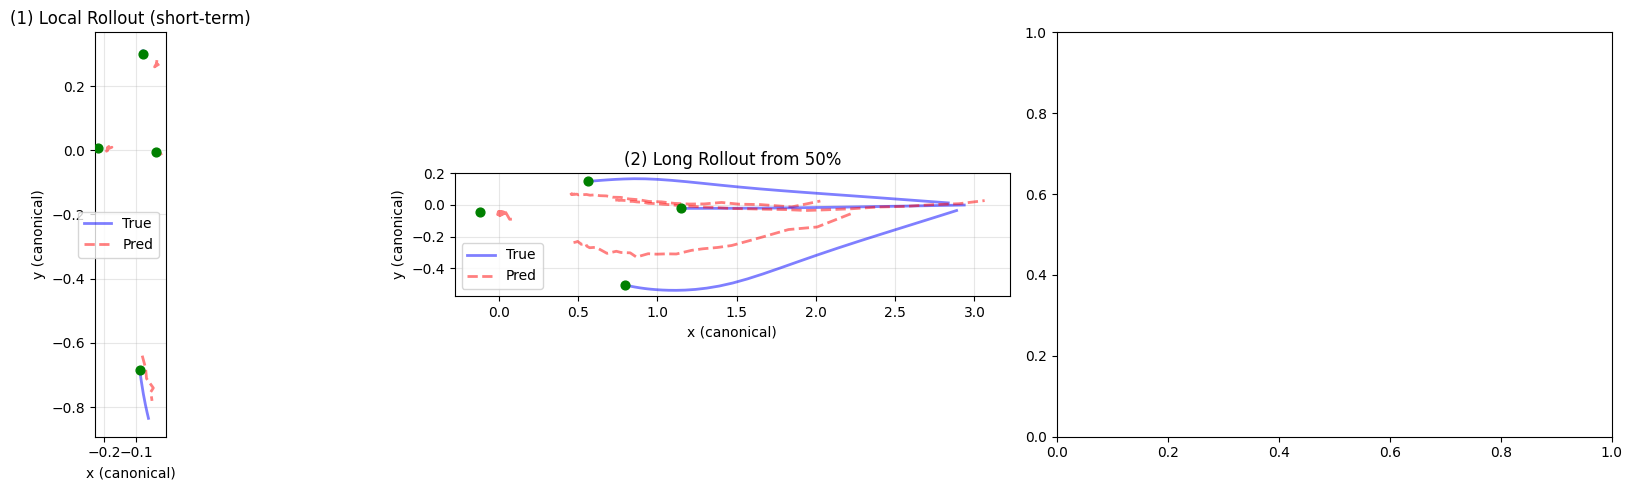


Summary
(1) Local rollout    | pos_L2=0.0359 | hdg=2.39° | cte=0.0261
(2) Long rollout 20%  | pos_L2=0.5295
(2) Long rollout 50%  | pos_L2=0.4278
(2) Long rollout 80%  | pos_L2=0.1715

判断标准（canonical frame，单位与训练数据一致）：
  pos_L2  < 0.05  → 很好 | < 0.15 → 可接受 | > 0.3 → 有问题
  hdg_err < 5°    → 很好 | < 15°  → 可接受 | > 30° → 有问题
  loop_err< 0.05  → flow 一致性好


In [35]:
# ============================================================
# FM Flow Matching - 三种一致性验证 Cell
# (1) 单步/短时间预测一致性 (local rollout)
# (2) 随机中间点长 rollout
# (3) 双向一致性 (noise→mid→end vs 真实)
# ============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
model_5ch.eval()

# ===============================================================
# 0) 加载验证数据（复用训练数据，取 val split 或全部）
# ===============================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, D)
controls = raw['controls']  # (N, T, 2)
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel traj (复用训练时的 canonicalize)
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1).astype(np.float32)  # (N, 5, T)

def canonicalize_single(traj_i, goal_xy=None):
    """将单条轨迹转换到 canonical frame，返回 (5,T) 和 cond (5,)"""
    x0, y0 = traj_i[0, 0], traj_i[1, 0]
    gx = goal_xy[0] if goal_xy is not None else traj_i[0, -1]
    gy = goal_xy[1] if goal_xy is not None else traj_i[1, -1]
    dx, dy   = gx - x0, gy - y0
    dist     = float(np.sqrt(dx**2 + dy**2) + 1e-9)
    cos_a, sin_a = dx / dist, dy / dist
    angle_off = float(np.arctan2(sin_a, cos_a))

    out = traj_i.copy()
    out[0] =  cos_a * (traj_i[0] - x0) + sin_a * (traj_i[1] - y0)
    out[1] = -sin_a * (traj_i[0] - x0) + cos_a * (traj_i[1] - y0)
    out[2] = np.array([(float(th) - angle_off + np.pi) % (2*np.pi) - np.pi
                        for th in traj_i[2]])

    th0_can = float((traj_i[2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
    v0      = float(states[0, 0, 3]) if D > 3 else 0.0
    cond    = np.array([dist, float(traj_i[3, 0]),
                        np.cos(th0_can), np.sin(th0_can),
                        float(traj_i[4, 0])], dtype=np.float32)
    return out, cond

# ===============================================================
# 辅助：用 model 做 ODE rollout，从 x_init 积分 t_start → t_end
# ===============================================================
def fm_ode_rollout(x_init_5T, cond_vec, t_start, t_end, n_out_steps=None, method="euler"):
    """
    x_init_5T : (5, T) numpy，作为 ODE 初值
    cond_vec  : (5,)  numpy
    t_start, t_end : float in [0,1]
    n_out_steps: 输出的中间时刻数量（None=只要终点）
    返回: (n_out_steps+1, 5, T) numpy，包含起点
    """
    dev  = next(model_5ch.parameters()).device
    x0_t = torch.tensor(x_init_5T, device=dev).unsqueeze(0)  # (1,5,T)
    c_t  = torch.tensor(cond_vec,   device=dev).unsqueeze(0)  # (1,5)

    if n_out_steps is None:
        t_span = torch.tensor([t_start, t_end], device=dev)
    else:
        t_span = torch.linspace(t_start, t_end, n_out_steps + 1, device=dev)

    def rhs(t, x_flat):
        xn = x_flat.view(1, 5, T)
        tt = torch.tensor([float(t)], device=dev)
        return model_5ch(xn, tt, cond=c_t).reshape(-1)

    sol = torchdiffeq.odeint(rhs, x0_t.reshape(-1), t_span,
                              method=method, atol=1e-4, rtol=1e-4)
    # sol: (n_steps, 5*T)
    return sol.reshape(-1, 5, T).cpu().numpy()  # (n_steps, 5, T)

# ===============================================================
# 指标函数
# ===============================================================
def pos_l2(pred_xy, true_xy):
    """pred_xy, true_xy: (T, 2)"""
    return float(np.mean(np.linalg.norm(pred_xy - true_xy, axis=1)))

def heading_err(pred_th, true_th):
    """角度误差（弧度），(T,)"""
    diff = (pred_th - true_th + np.pi) % (2*np.pi) - np.pi
    return float(np.mean(np.abs(diff)))

def cross_track_err(pred_xy, true_xy):
    """逐点到真实路径的垂直距离均值"""
    errs = []
    for i in range(len(pred_xy)):
        idx = np.argmin(np.linalg.norm(true_xy - pred_xy[i], axis=1))
        errs.append(float(np.linalg.norm(pred_xy[i] - true_xy[idx])))
    return float(np.mean(errs))

# ===============================================================
# (1) 单步 / 短时间预测一致性
# ===============================================================
print("\n" + "="*60)
print("(1) 单步/短时间预测一致性 (local rollout)")
print("="*60)

N_SAMPLES   = 20    # 验证样本数
M_STEPS     = 3     # 往前积分 m 步（时间步）
dt_norm     = 1.0 / (T - 1)  # 归一化时间步长

np.random.seed(0)
results_1 = []

for _ in range(N_SAMPLES):
    idx  = np.random.randint(0, N)
    traj = traj_5ch[idx]  # (5, T)
    goal = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj, goal)

    # 随机选中间帧作为起点（避开首尾）
    k = np.random.randint(T // 4, T // 2)
    t_k   = k * dt_norm
    t_km  = min((k + M_STEPS) * dt_norm, 1.0)

    x_init = traj_can[:, k]   # (5,) 某一帧
    # 扩展成 (5, T)：用真实 xk 填满（模型需要全序列，取当前帧复制）
    x_init_5T = np.tile(x_init.reshape(5, 1), (1, T)).astype(np.float32)
    # 实际上模型操作整条轨迹，所以用真实的 traj_can[:, k:] 拼起来更合理
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]  # 起点之前用 xk 填充（相当于从 xk 开始）

    sol = fm_ode_rollout(x_init_5T, cond, t_k, t_km, n_out_steps=M_STEPS)
    # sol[-1]: (5, T) 预测结果

    pred_xy  = sol[-1][0:2, k:k+M_STEPS+1].T   # (M+1, 2)
    true_xy  = traj_can[0:2, k:k+M_STEPS+1].T  # (M+1, 2)
    pred_th  = sol[-1][2, k:k+M_STEPS+1]
    true_th  = traj_can[2, k:k+M_STEPS+1]

    results_1.append({
        "pos_l2":  pos_l2(pred_xy, true_xy),
        "hdg_err": heading_err(pred_th, true_th),
        "cte":     cross_track_err(pred_xy, true_xy),
    })

r1_pos = np.mean([r["pos_l2"]  for r in results_1])
r1_hdg = np.mean([r["hdg_err"] for r in results_1])
r1_cte = np.mean([r["cte"]     for r in results_1])
print(f"  Samples={N_SAMPLES}, rollout={M_STEPS} steps")
print(f"  Mean pos L2    : {r1_pos:.4f}")
print(f"  Mean heading err: {np.rad2deg(r1_hdg):.2f} deg")
print(f"  Mean cross-track: {r1_cte:.4f}")

# ===============================================================
# (2) 随机中间点长 rollout
# ===============================================================
print("\n" + "="*60)
print("(2) 随机中间点长 rollout (20%, 50%, 80%)")
print("="*60)

START_FRACS = [0.2, 0.5, 0.8]
N_SAMPLES_2 = 10
results_2   = {f: [] for f in START_FRACS}

for frac in START_FRACS:
    for _ in range(N_SAMPLES_2):
        idx  = np.random.randint(0, N)
        traj = traj_5ch[idx]
        goal = goals[idx] if goals is not None else None
        traj_can, cond = canonicalize_single(traj, goal)

        k     = int(frac * (T - 1))
        t_k   = k * dt_norm

        # 从 xk 出发积分到末尾
        x_init_5T        = traj_can.copy()
        x_init_5T[:, :k] = traj_can[:, k:k+1]

        n_remain = T - k
        sol = fm_ode_rollout(x_init_5T, cond, t_k, 1.0,
                             n_out_steps=n_remain, method="euler")
        # sol: (n_remain+1, 5, T)
        pred_end = sol[-1]  # (5, T)

        pred_xy = pred_end[0:2, k:].T   # (T-k, 2)
        true_xy = traj_can[0:2, k:].T
        pred_th = pred_end[2, k:]
        true_th = traj_can[2, k:]

        results_2[frac].append({
            "pos_l2":  pos_l2(pred_xy, true_xy),
            "hdg_err": heading_err(pred_th, true_th),
            "cte":     cross_track_err(pred_xy, true_xy),
        })

    m_pos = np.mean([r["pos_l2"]  for r in results_2[frac]])
    m_hdg = np.mean([r["hdg_err"] for r in results_2[frac]])
    m_cte = np.mean([r["cte"]     for r in results_2[frac]])
    print(f"  Start at {int(frac*100)}% | pos_L2={m_pos:.4f} | "
          f"hdg={np.rad2deg(m_hdg):.2f}deg | cte={m_cte:.4f}")

# ===============================================================
# (3) 双向一致性（noise → xk → xT，再对比真实 xk 附近分布）
# ===============================================================
print("\n" + "="*60)
print("(3) 双向一致性 (noise → mid → end)")
print("="*60)

N_SAMPLES_3 = 10
MID_FRAC    = 0.5   # 用 50% 处作为"中间点"
results_3   = []

for _ in range(N_SAMPLES_3):
    idx  = np.random.randint(0, N)
    traj = traj_5ch[idx]
    goal = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj, goal)

    k_mid = int(MID_FRAC * (T - 1))
    t_mid = k_mid * dt_norm

    # Step A: noise → x_mid（积分 0→t_mid）
    x_noise = np.random.randn(5, T).astype(np.float32) * 0.08
    x_noise[:, 0] = 0.0  # lock start
    sol_a = fm_ode_rollout(x_noise, cond, 0.0, t_mid, n_out_steps=1)
    x_mid_pred = sol_a[-1]  # (5, T)

    # Step B: x_mid_pred → x_end（积分 t_mid→1.0）
    sol_b = fm_ode_rollout(x_mid_pred, cond, t_mid, 1.0, n_out_steps=1)
    x_end_pred = sol_b[-1]  # (5, T)

    # 对比1：x_mid_pred 和真实 x_mid 的差异（中间点一致性）
    mid_pos_err = float(np.mean(np.linalg.norm(
        x_mid_pred[0:2, :].T - traj_can[0:2, :].T, axis=1
    )))

    # 对比2：x_end_pred 和真实轨迹末尾的差异（终点一致性）
    end_pos_err = float(np.linalg.norm(
        x_end_pred[0:2, -1] - traj_can[0:2, -1]
    ))

    # 对比3：完整路径 noise→end 直接积分 vs 两段拼接的终点差异（循环一致性）
    sol_direct = fm_ode_rollout(x_noise, cond, 0.0, 1.0, n_out_steps=1)
    x_end_direct = sol_direct[-1]
    loop_err = float(np.linalg.norm(
        x_end_pred[0:2, -1] - x_end_direct[0:2, -1]
    ))

    results_3.append({
        "mid_pos_err": mid_pos_err,
        "end_pos_err": end_pos_err,
        "loop_err":    loop_err,
    })

r3_mid  = np.mean([r["mid_pos_err"] for r in results_3])
r3_end  = np.mean([r["end_pos_err"] for r in results_3])
r3_loop = np.mean([r["loop_err"]    for r in results_3])
print(f"  Samples={N_SAMPLES_3}, mid_frac={MID_FRAC}")
print(f"  Mid-point pos err (pred vs true) : {r3_mid:.4f}")
print(f"  End-point pos err (2-seg vs true) : {r3_end:.4f}")
print(f"  Loop consistency (2-seg vs direct): {r3_loop:.4f}  ← 越小越好")

# ===============================================================
# 可视化：每种检查各画 3 条代表性轨迹
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

np.random.seed(42)

# --- Plot (1): local rollout ---
ax = axes[0]
ax.set_title("(1) Local Rollout (short-term)")
for _ in range(4):
    idx  = np.random.randint(0, N)
    traj_can, cond = canonicalize_single(traj_5ch[idx],
                                          goals[idx] if goals is not None else None)
    k = T // 3
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]
    sol = fm_ode_rollout(x_init_5T, cond, k*dt_norm,
                          min((k+5)*dt_norm, 1.0), n_out_steps=5)
    ax.plot(traj_can[0, k:k+6], traj_can[1, k:k+6],
            'b-', alpha=0.5, lw=2, label="True" if _ == 0 else "")
    ax.plot(sol[-1][0, k:k+6], sol[-1][1, k:k+6],
            'r--', alpha=0.5, lw=2, label="Pred" if _ == 0 else "")
    ax.scatter([traj_can[0, k]], [traj_can[1, k]], c='g', s=40, zorder=5)
ax.legend(); ax.grid(alpha=0.3); ax.set_aspect("equal")
ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")

# --- Plot (2): long rollout ---
ax2 = axes[1]
ax2.set_title("(2) Long Rollout from 50%")
for _ in range(4):
    idx  = np.random.randint(0, N)
    traj_can, cond = canonicalize_single(traj_5ch[idx],
                                          goals[idx] if goals is not None else None)
    k = T // 2
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]
    sol = fm_ode_rollout(x_init_5T, cond, k*dt_norm, 1.0,
                          n_out_steps=T-k, method="euler")
    ax2.plot(traj_can[0, k:], traj_can[1, k:],
             'b-', alpha=0.5, lw=2, label="True" if _ == 0 else "")
    ax2.plot(sol[-1][0, k:], sol[-1][1, k:],
             'r--', alpha=0.5, lw=2, label="Pred" if _ == 0 else "")
    ax2.scatter([traj_can[0, k]], [traj_can[1, k]], c='g', s=40, zorder=5)
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_aspect("equal")
ax2.set_xlabel("x (canonical)"); ax2.set_ylabel("y (canonical)")

# --- Plot (3): bidirectional ---
# ax3 = axes[2]
# ax3.set_title("(3) Bidirectional: noise→mid→end vs direct")
# for _ in range(4):
#     idx  = np.random.randint(0, N)
#     traj_can, cond = canonicalize_single(traj_5ch[idx],
#                                           goals[idx] if goals is not None else None)
#     k_mid = T // 2
#     x_noise = np.random.randn(5, T).astype(np.float32) * 0.08
#     x_noise[:, 0] = 0.0

#     sol_a      = fm_ode_rollout(x_noise, cond, 0.0, k_mid*dt_norm, n_out_steps=1)
#     sol_b      = fm_ode_rollout(sol_a[-1], cond, k_mid*dt_norm, 1.0, n_out_steps=1)
#     sol_direct = fm_ode_rollout(x_noise, cond, 0.0, 1.0, n_out_steps=1)

#     ax3.plot(traj_can[0], traj_can[1],
#              'b-', alpha=0.3, lw=1.5, label="True" if _ == 0 else "")
#     ax3.plot(sol_b[-1][0], sol_b[-1][1],
#              'r--', alpha=0.5, lw=1.5, label="2-seg" if _ == 0 else "")
#     ax3.plot(sol_direct[-1][0], sol_direct[-1][1],
#              'g:', alpha=0.5, lw=1.5, label="Direct" if _ == 0 else "")

# ax3.legend(); ax3.grid(alpha=0.3); ax3.set_aspect("equal")
# ax3.set_xlabel("x (canonical)"); ax3.set_ylabel("y (canonical)")

plt.tight_layout()
plt.show()

# ===============================================================
# 汇总打印
# ===============================================================
print("\n" + "="*60)
print("Summary")
print("="*60)
print(f"(1) Local rollout    | pos_L2={r1_pos:.4f} | hdg={np.rad2deg(r1_hdg):.2f}° | cte={r1_cte:.4f}")
for frac in START_FRACS:
    m = np.mean([r["pos_l2"] for r in results_2[frac]])
    print(f"(2) Long rollout {int(frac*100)}%  | pos_L2={m:.4f}")
# print(f"(3) Loop consistency | mid={r3_mid:.4f} | end={r3_end:.4f} | loop={r3_loop:.4f}")
print()
print("判断标准（canonical frame，单位与训练数据一致）：")
print("  pos_L2  < 0.05  → 很好 | < 0.15 → 可接受 | > 0.3 → 有问题")
print("  hdg_err < 5°    → 很好 | < 15°  → 可接受 | > 30° → 有问题")
print("  loop_err< 0.05  → flow 一致性好")

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0_hf: 'float' = 0.7, p_hf: 'float' = 2.0, lf_on: 'float' = 1.0, hf_max: 'float' = 1.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - 验证结果改进版
K=8  PATH_HEADING_TOL=60°  PATH_START_TOL=0.3
goal_tol=0.2  ARRIVAL_DIST=0.15  APPROACH_DIST=0.6
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15
[  2] dA=3.349 

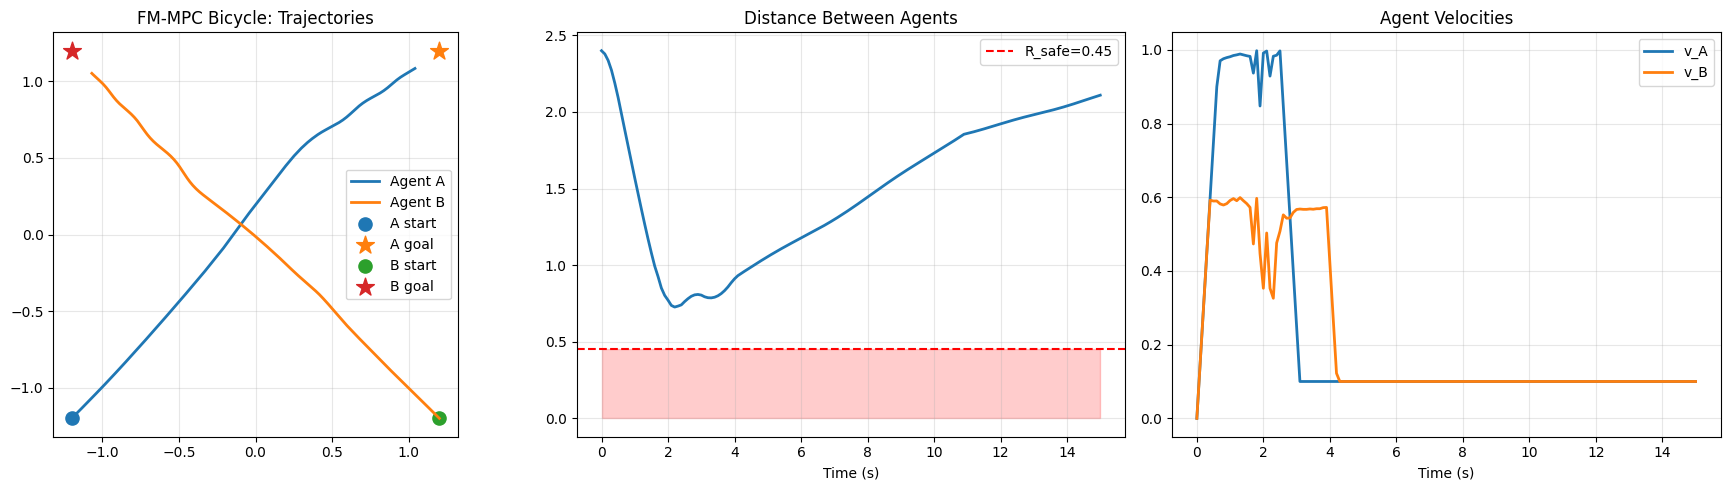

In [16]:
# ============================================================
# FM-MPC Bicycle - 根据验证结果改进版
# 针对问题：模型前半段预测差，Long rollout 误差大
# 改进策略：
#   1. 增加 K（采样数），用更多候选路径对冲模型不稳定性
#   2. 增加路径质量过滤：起始段偏差过大的路径直接丢弃
#   3. goal_guidance_weight 提高，强制路径末端拉向目标
#   4. 增加 replan 频率自适应：路径质量差时强制重采样
#   5. cost 函数增加路径起始段一致性惩罚
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 8           # ★ 原5→8：模型不稳定时多采样对冲，增加找到好路径的概率
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping
goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# ★ 路径质量过滤阈值（根据验证结果设定）
# Local rollout pos_L2=0.0325 说明单步是好的
# 但 Long rollout 20% 处 pos_L2=0.54，说明路径整体可能偏很多
# 用路径起始方向和当前heading的夹角来过滤明显错误的路径
PATH_HEADING_TOL = np.deg2rad(60.0)  # ★ 路径起始方向与当前heading偏差超过60°则丢弃
PATH_START_TOL   = 0.30              # ★ 路径第一个点离当前位置超过这个距离则丢弃（lock_start失效）

# ===============================================================
# 3) Bicycle dynamics（不变）
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame（不变）
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings（不变）
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction（不变）
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ★ 改动：goal_guidance_weight 0.90→0.95，强制末端更靠近目标
#    补偿模型前半段不准导致末端飘离的问题
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []
    x0_noise = make_x0_noise(T_steps, seed)
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55,   # ★ 0.45→0.55：加强起点锁定，对抗前半段偏差
        goal_guidance_weight=0.95,    # ★ 0.90→0.95：加强终点牵引
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf), scaler=None, ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )

    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# ★ 新增：路径质量检查
# 验证结果表明模型前半段不稳定，需要过滤明显异常的路径
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    """
    返回 (is_valid, reason)
    过滤两类明显错误：
    1. 路径起点离当前位置太远（lock_start 失效）
    2. 路径前几个点的方向和当前 heading 偏差太大（前半段跑飞）
    """
    pos = self_state[:2]
    th  = float(self_state[2])

    # 检查1：路径起点是否锁定在当前位置
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    # 检查2：路径前段方向是否合理
    # 取路径前 1/4 段，计算整体方向
    n_check = max(3, len(path_xy) // 4)
    seg = path_xy[:n_check]
    seg_dir = seg[-1] - seg[0]
    seg_len = float(np.linalg.norm(seg_dir))

    if seg_len > 0.05:  # 路径前段有足够位移才检查方向
        seg_angle = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    # 检查3：路径终点是否朝向目标（应该比起点更近）
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:  # 终点比起点离目标还远 20% 以上
        return False, f"path_goes_away d_end={d_end:.3f}>d_start={d_start:.3f}"

    return True, "ok"

# ===============================================================
# 8) Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    Ld_min  = 0.20
    Ld_max  = 1.10
    k_brake = 5.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            Ld = min(Ld, d_goal * 0.85)
            near_idx = _closest_index(path_xy, pos)
            near_idx = max(near_idx, last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))
        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        turn_pen  = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des    *= turn_pen
        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost
# ===============================================================
W_END    = 18.0
W_PATH   = 1.5
W_COLL   = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0]**2 + 0.4*dU[:, 1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan
# ★ 改动：加入路径质量过滤，过滤掉模型前半段跑飞的路径
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)
    best         = None
    cbf_count    = 0
    reject_count = 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy,
                other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue

        # ★ 路径质量过滤
        valid, reason = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        cbf_count += int(used_cbf)
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0          = U[0].copy()

        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)

    # ★ 如果所有路径都被过滤掉，降级为直接朝目标走的保底控制
    if best is None:
        if reject_count > 0:
            print(f"  [WARN] all {reject_count} paths rejected, using fallback")
        # 保底：直接朝目标方向以低速行驶
        pos    = self_state[:2]
        th     = float(self_state[2])
        goal_xy_arr = np.asarray(goal_xy, np.float32)
        d_goal = float(np.linalg.norm(pos - goal_xy_arr))
        ang    = float(math.atan2(goal_xy_arr[1]-pos[1], goal_xy_arr[0]-pos[0]))
        alpha  = float(wrap_pi(ang - th))
        kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr     = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
        a      = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
        u_fallback = np.array([a, dr], dtype=np.float32)
        return u_fallback, float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0]))
thB0 = float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 验证结果改进版")
print(f"K={K}  PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  PATH_START_TOL={PATH_START_TOL}")
print(f"goal_tol={goal_tol}  ARRIVAL_DIST={ARRIVAL_DIST}  APPROACH_DIST={APPROACH_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots（不变）
# ===============================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[device torch] cuda
[device jax  ] [CpuDevice(id=0)]
[WARN] torch2jax not found — falling back to batched numpy bridge
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[model] loaded
FM-MPC Bicycle — Batched GPU Inference
K=8  T=40  segments=5
GPU batch: 40 model calls/replan  (was 320)
PATH_HEADING_TOL=75°  PATH_START_TOL=0.5
[warmup] running first sample ... done
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00  elapsed=0.5s
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15  elapsed=1.0s
[  2] dA=3.349 dB=3.349 dist=2.336 vA=0.30 vB=0.30  elapsed=1.5s
[  3] dA=3.304 dB=3.304 dist=2.273 vA=0.45 vB=0.45  elapsed=1.9s
[  4] dA=3.244 dB=3.244 dist=2.188 vA=0.60 vB=0.60  elapsed=2.4s
[  5] dA=3.169 dB=3.184 dist=2.092 vA=0.75 vB=0.60  elapsed=2.8s
[  6] dA=3.079 dB=3.124 dist=1.987 vA=0.90 vB=0.60  elapsed=15.2s
[  7] dA=2.980 dB=3.064 dist=1.876 vA=0.99 vB=0.60  elapsed=27.7s
[  8] dA=2.881 dB=3.004 dist=1.767 vA=0.98 vB=0.60  elapsed=40.4s
[  9] dA=2.783 dB=2.944 d

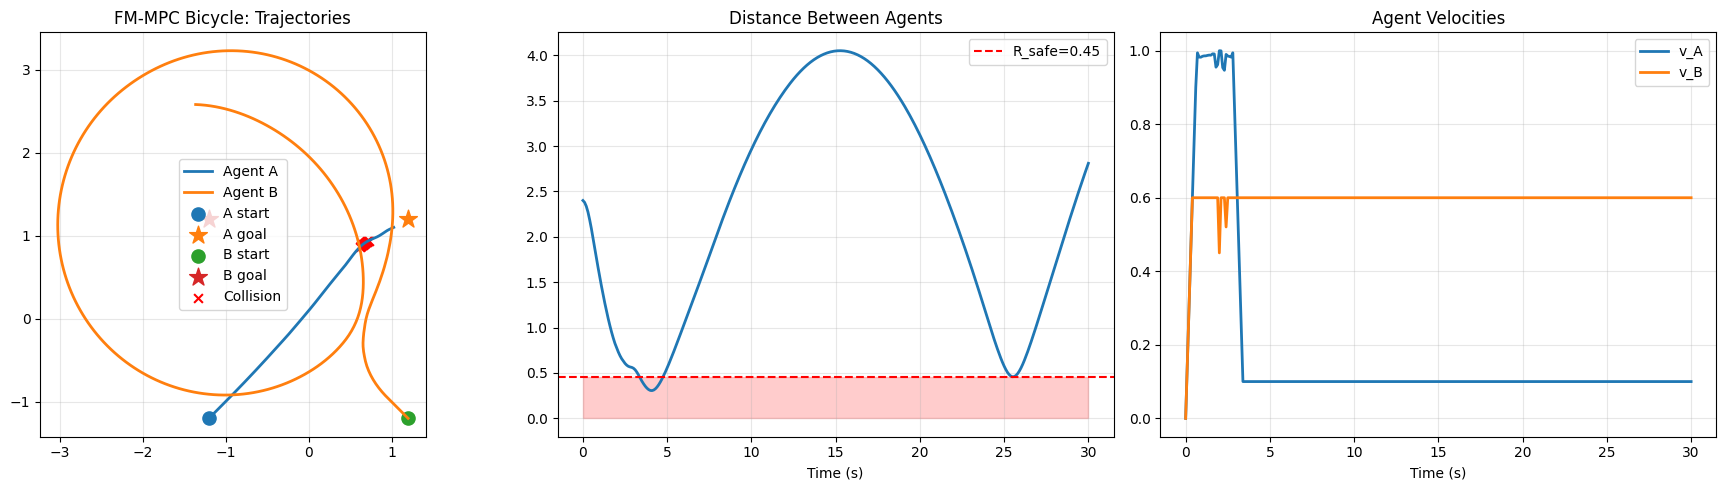

In [ ]:
# ============================================================
# FM-MPC Bicycle — JAX Fixed + GPU + Batched Inference
#
# 修复内容：
#   1. 强制 JAX 使用 GPU (CUDA)
#   2. K 条路径合并为一次 batch 推理，消除 320 次 CPU↔GPU 搬运
#   3. 放宽路径过滤，增加 fallback 容忍度
#   4. 保持 Python for loop ODE（避免 TracerArrayConversionError）
# ============================================================

from __future__ import annotations

import math
import os
import sys
from pathlib import Path

import numpy as np
import torch

# ── 1. 强制 JAX 用 GPU ──────────────────────────────────────
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # 避免 JAX 预分配全部显存
os.environ["JAX_PLATFORM_NAME"] = "gpu"                  # 强制用 GPU

import jax
import jax.numpy as jnp

print(f"[device torch] {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"[device jax  ] {jax.devices()}")   # 应该显示 CudaDevice

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── torch2jax ────────────────────────────────────────────────
try:
    from torch2jax import torch2jax as t2j
    HAS_TORCH2JAX = True
except ImportError:
    HAS_TORCH2JAX = False
    print("[WARN] torch2jax not found — falling back to batched numpy bridge")


# ================================================================
# 0) Load sampler_5h
# ================================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")
import importlib.util
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

from dmpc_fm_cbf import cbf_project_velocity_sgfm as _cbf_fn
cbf_projector_pt = _cbf_fn if callable(_cbf_fn) else getattr(_cbf_fn, "cbf_project_velocity_sgfm")


# ================================================================
# 1) Model check
# ================================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")


# ================================================================
# 2) Parameters
# ================================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
noise_scale  = 0.08

# MPC
H            = 12
K            = 8
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping
goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# Path quality filter — 放宽，减少 all-rejected
PATH_HEADING_TOL     = np.deg2rad(75.0)   # 原 60° → 75°
PATH_START_TOL       = 0.50               # 原 0.30 → 0.50
MIN_VALID_PATHS      = 2                  # 至少有这么多条合格才正常选，否则放宽再选

# Guidance weights
START_GUIDANCE_WEIGHT = 0.55
GOAL_GUIDANCE_WEIGHT  = 0.95
TAU0_HF               = 0.7


# ================================================================
# 3) Bicycle dynamics
# ================================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2 * np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh + 1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i + 1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st


# ================================================================
# 4) Canonical frame
# ================================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }


# ================================================================
# 5) CBF settings
# ================================================================
r_obs_far      = 0.32
r_obs_near     = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos) - 1]
    idxs = sorted(list(dict.fromkeys([i for i in idxs if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses


# ================================================================
# 6) ★ Batched model bridge
#
#   关键优化：把 K 条路径合并成一个 batch (K, 5, T) 一次推理，
#   而不是每条路径单独调用模型。
#   这样 320 次 CPU↔GPU 搬运 → 40 次（每个 euler step 1 次 batch）
# ================================================================

def _model_forward_batch(x_KxCxT: np.ndarray, t_scalar: float,
                          cond_KxC: np.ndarray) -> np.ndarray:
    """
    x_KxCxT  : (K, 5, T) numpy
    cond_KxC : (K, C)    numpy
    返回       : (K, 5, T) numpy — velocity field
    """
    K_batch = x_KxCxT.shape[0]
    x_pt    = torch.from_numpy(x_KxCxT).to(device)           # (K,5,T)
    t_pt    = torch.full((K_batch,), t_scalar,
                          dtype=torch.float32, device=device)  # (K,)
    c_pt    = torch.from_numpy(cond_KxC).to(device)           # (K,C)

    with torch.no_grad():
        v_pt = model_5ch(x_pt, t_pt, cond=c_pt)               # (K,5,T)

    return v_pt.cpu().numpy().astype(np.float32)


# ================================================================
# 7) Pure-JAX CBF projection  (unchanged)
# ================================================================

def _cbf_project_jax(x_1x2T, v_nom_1x2T, ellipses_jnp, *,
                      alpha=10.0, extra_margin=0.08,
                      passes=2, max_corr_norm=2.0):
    v = v_nom_1x2T
    for _ in range(passes):
        for (center, radius) in ellipses_jnp:
            r_safe = radius + extra_margin
            p      = x_1x2T[0]
            dx     = p[0] - center[0]
            dy     = p[1] - center[1]
            dist   = jnp.sqrt(dx**2 + dy**2 + 1e-8)
            h      = dist - r_safe
            grad_h = jnp.stack([dx / dist, dy / dist], axis=0)
            v_xy   = v[0]
            lf_h   = jnp.sum(grad_h * v_xy, axis=0)
            viol   = jnp.maximum(0.0, -(lf_h + alpha * h))
            corr   = grad_h * viol[None, :]
            corr_norm = jnp.linalg.norm(corr, axis=0, keepdims=True)
            corr   = corr / jnp.maximum(corr_norm, 1.0) * jnp.minimum(corr_norm, max_corr_norm)
            v      = v.at[0].add(corr)
    return v


# ================================================================
# 8) ★ Batched K-parallel FM sampling
#
#   所有 K 条路径共享同一套 ODE loop，每步做一次 (K,5,T) batch 推理。
#   CBF 仍然逐条应用（因为 ellipses 是全局共享的，可以向量化，
#   但这里先保持逐条以避免引入新 bug）。
# ================================================================

def _sample_K_batched(
    seeds: list,
    cond_vec: np.ndarray,       # (C,) numpy
    start_np: np.ndarray,       # (2,) numpy
    goal_np: np.ndarray,        # (2,) numpy
    ellipses_jnp,
    use_cbf: bool,
) -> np.ndarray:
    """
    返回 paths_can: (K, 5, T) numpy
    """
    Kb = len(seeds)

    # ── 初始化 K 条噪声轨迹 ────────────────────────────────
    x_batch = np.zeros((Kb, 5, T_steps), dtype=np.float32)
    for i, seed in enumerate(seeds):
        rng = np.random.default_rng(int(seed))
        xi  = rng.standard_normal((5, T_steps)).astype(np.float32) * noise_scale
        xi[:, 0]   = 0.0
        xi[0:2, 0] = start_np
        # Terminal safety filter
        if use_cbf and len(ellipses_jnp) > 0:
            xy = xi[0:2, :]
            for (center_jnp, radius) in ellipses_jnp:
                center = np.array(center_jnp, dtype=np.float32)
                diff   = xy - center.reshape(2, 1)
                dist_c = np.linalg.norm(diff, axis=0)
                unsafe = dist_c < radius
                if unsafe.any():
                    near_c    = dist_c < 1e-6
                    safe_diff = np.where(
                        near_c[None, :],
                        np.array([[1.0],[0.0]], dtype=np.float32) * np.ones((2, T_steps)),
                        diff
                    )
                    direction = safe_diff / (dist_c[None, :] + 1e-9)
                    xy[:, unsafe] = center.reshape(2, 1) + direction[:, unsafe] * radius
            xi[0:2, :] = xy
        x_batch[i] = xi

    # cond broadcast: (K, C)
    cond_batch = np.tile(cond_vec.reshape(1, -1), (Kb, 1)).astype(np.float32)

    # guidance ramp (numpy, shared for all K)
    idx_arr  = np.linspace(0.0, 1.0, T_steps, dtype=np.float32)
    ramp_arr = np.clip((idx_arr - 0.5) / 0.5, 0.0, 1.0).reshape(1, 1, T_steps)

    # ── Piecewise Euler — one batch call per substep ────────
    dt_seg     = total_time / num_segments
    n_substeps = 8
    dt_sub     = dt_seg / n_substeps

    for seg_i in range(num_segments):
        t0_seg = seg_i * dt_seg

        for sub_j in range(n_substeps):
            t_now = t0_seg + sub_j * dt_sub
            tau   = t_now / total_time
            w_t   = 0.25 + 0.75 * tau

            # ── Batch model forward (1 GPU call for all K) ──
            v_batch = _model_forward_batch(x_batch, t_now, cond_batch)
            # v_batch: (K, 5, T)

            # ── Guidance (vectorized over K) ─────────────────
            w_s = START_GUIDANCE_WEIGHT * w_t
            v_batch[:, 0:2, 0:1] += w_s * (start_np.reshape(1, 2, 1) - x_batch[:, 0:2, 0:1])

            w_g = GOAL_GUIDANCE_WEIGHT * w_t
            v_batch[:, 0:2, :] += w_g * ramp_arr * (goal_np.reshape(1, 2, 1) - x_batch[:, 0:2, :])

            # ── CBF (per-path, JAX) ───────────────────────────
            if use_cbf and len(ellipses_jnp) > 0:
                g_hf = float(
                    ((tau - TAU0_HF) / (1.0 - TAU0_HF + 1e-9)) ** 2.0
                    if tau >= TAU0_HF else 0.0
                )
                cbf_kwargs = dict(
                    alpha=10.0 + 10.0 * g_hf,
                    extra_margin=0.08 + 0.22 * g_hf,
                    passes=2,
                    max_corr_norm=2.0 + 1.0 * g_hf,
                )
                for k in range(Kb):
                    x_k = jnp.array(x_batch[k:k+1, 0:2, :])   # (1,2,T)
                    v_k = jnp.array(v_batch[k:k+1, 0:2, :])    # (1,2,T)
                    v_safe = _cbf_project_jax(x_k, v_k, ellipses_jnp, **cbf_kwargs)
                    v_batch[k, 0:2, :] = np.array(v_safe[0])

            # ── Euler step ────────────────────────────────────
            x_batch += dt_sub * v_batch

        # Re-lock start after each segment
        x_batch[:, 0:2, 0] = start_np[None, :]

    return x_batch  # (K, 5, T)


# ================================================================
# 9) High-level FM sampling
# ================================================================

def sample_fm_paths_jax(*, self_state, goal_xy, other_pred_pos, seed_base):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)

    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) \
                        else other_pred_pos[0]
    dist_AB = float(np.linalg.norm(self_xy - other_now))

    use_cbf, _ = get_cbf_config(dist_AB)
    ellipses_np = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    ellipses_jnp = [
        (jnp.array(e["center"], dtype=jnp.float32), float(e["radius"]))
        for e in ellipses_np
    ]

    v0      = float(self_state[3])
    th_can  = tf["w2c_angle"](float(self_state[2]))
    delta0  = float(self_state[4])
    cond_vec = np.array(
        [tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0],
        dtype=np.float32
    )

    start_np = np.array(tf["start_can"])
    goal_np  = np.array(tf["goal_can"])
    seeds    = [seed_base + 137 * k + 7919 for k in range(K)]

    paths_can = _sample_K_batched(
        seeds, cond_vec, start_np, goal_np, ellipses_jnp, use_cbf
    )  # (K, 5, T)

    paths_xy_can = paths_can[:, 0:2, :].transpose(0, 2, 1)  # (K, T, 2)
    paths_world  = np.stack([
        tf["c2w"](paths_xy_can[k]).astype(np.float32)
        for k in range(K)
    ])  # (K, T, 2)

    return paths_world, use_cbf, dist_AB


# ================================================================
# 10) Path quality filter
#     ★ 增加 relaxed 模式：全部 rejected 时放宽标准再选一次
# ================================================================

def check_path_quality(path_xy, self_state, goal_xy, *, relax=False):
    pos = self_state[:2]
    th  = float(self_state[2])
    tol_start   = PATH_START_TOL   * (2.0 if relax else 1.0)
    tol_heading = PATH_HEADING_TOL * (1.5 if relax else 1.0)

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > tol_start:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg     = path_xy[:n_check]
    seg_dir = seg[-1] - seg[0]
    seg_len = float(np.linalg.norm(seg_dir))

    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > tol_heading:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.3:   # 原 1.2 → 1.3，稍微宽松
        return False, f"path_goes_away"

    return True, "ok"


# ================================================================
# 11) Pure Pursuit  (unchanged)
# ================================================================

def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy) - 1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s        = s0.copy()
    U        = np.zeros((H, 2), dtype=np.float32)
    k_brake  = 5.0
    Ld_min, Ld_max = 0.20, 1.10
    path_xy  = np.asarray(path_xy,  np.float32)
    goal_xy  = np.asarray(goal_xy,  np.float32)
    last_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            Ld = min(Ld, d_goal * 0.85)
            near_idx  = max(_closest_index(path_xy, pos), last_idx)
            target, last_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))
        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        turn_pen  = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des    *= turn_pen
        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U


# ================================================================
# 12) Cost  (unchanged)
# ================================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M       = min(len(pos_self), len(pos_other_pred))
    min_d   = float("inf") if M <= 1 else \
              float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol    = max(0.0, R_SAFE - min_d)
    coll    = float(viol * viol)
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    smooth  = float(np.mean(dU[:, 0]**2 + 0.4 * dU[:, 1]**2))
    return W_END * d_end + W_PATH * d_path + W_COLL * coll + W_SMOOTH * smooth


# ================================================================
# 13) MPC replan
#     ★ all-rejected 时先放宽标准再选，实在不行才用 fallback
# ================================================================

def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    return rollout_bicycle(other_state, U, dt=dt, v_max=v_max)


def _fallback_control(self_state, goal_xy):
    pos      = self_state[:2]
    th       = float(self_state[2])
    goal_arr = np.asarray(goal_xy, np.float32)
    d_goal   = float(np.linalg.norm(pos - goal_arr))
    ang      = float(math.atan2(goal_arr[1] - pos[1], goal_arr[0] - pos[0]))
    alpha    = float(wrap_pi(ang - th))
    kappa    = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr       = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
    a        = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
    return np.array([a, dr], np.float32)


def _select_best_path(paths_world, self_state, goal_xy, other_pred_pos, *, relax=False):
    """从 K 条路径里选最优，返回 (best_u, best_J, best_path) 或 None"""
    best = None
    for k in range(K):
        path_xy = paths_world[k]
        valid, _ = check_path_quality(path_xy, self_state, goal_xy, relax=relax)
        if not valid:
            continue
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                            H=H, dt=dt_exec, v_max=v_max_A)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_A)
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    return best


def mpc_replan(self_state, goal_xy, other_state, other_u_last, *,
               v_max_self, v_max_other, seed_base):

    other_pred_pos, _ = predict_other_traj(
        other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other
    )

    try:
        paths_world, used_cbf_any, dist_AB = sample_fm_paths_jax(
            self_state=self_state,
            goal_xy=goal_xy,
            other_pred_pos=other_pred_pos,
            seed_base=seed_base,
        )
    except Exception as e:
        print(f"  [WARN] JAX FM sample failed: {e}")
        return _fallback_control(self_state, goal_xy), float("inf"), None, 0

    cbf_count = int(used_cbf_any) * K

    # 先正常过滤
    best = _select_best_path(paths_world, self_state, goal_xy, other_pred_pos, relax=False)

    # 全 rejected → 放宽标准再试一次
    if best is None:
        best = _select_best_path(paths_world, self_state, goal_xy, other_pred_pos, relax=True)
        if best is not None:
            pass  # 放宽后选到了，静默处理
        else:
            return _fallback_control(self_state, goal_xy), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count


# ================================================================
# 14) Scenario setup & main loop
# ================================================================
import matplotlib.pyplot as plt
import time

xA0 = np.array([-1.2, -1.2], np.float32);  gA = np.array([ 1.2,  1.2], np.float32)
xB0 = np.array([ 1.2, -1.2], np.float32);  gB = np.array([-1.2,  1.2], np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("=" * 60)
print("FM-MPC Bicycle — Batched GPU Inference")
print(f"K={K}  T={T_steps}  segments={num_segments}")
print(f"GPU batch: {num_segments * 8} model calls/replan  (was {num_segments * 8 * K})")
print(f"PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  "
      f"PATH_START_TOL={PATH_START_TOL}")
print("=" * 60)

# Warm-up
print("[warmup] running first sample ... ", end="", flush=True)
_ = sample_fm_paths_jax(
    self_state=sA, goal_xy=gA, other_pred_pos=None, seed_base=0
)
print("done")

t_start = time.perf_counter()

for step in range(MAX_STEPS):
    dA    = float(np.linalg.norm(sA[:2] - gA))
    dB    = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  "
              f"(t={step * dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB,
                v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step * 31,
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA,
                v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step * 37,
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            elapsed = time.perf_counter() - t_start
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}  elapsed={elapsed:.1f}s")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

t_total = time.perf_counter() - t_start
trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total} | "
      f"wall_time={t_total:.1f}s")


# ================================================================
# 15) Analysis & plots
# ================================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | "
      f"collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]}  dist_to_goal="
      f"{float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]}  dist_to_goal="
      f"{float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t_axis = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:, 0], trajA[:, 1], lw=2, label="Agent A")
ax.plot(trajB[:, 0], trajB[:, 1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t_axis, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t_axis, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t_axis, trajA[:, 3], lw=2, label="v_A")
ax3.plot(t_axis, trajB[:, 3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[device torch] cuda
[device jax  ] [CpuDevice(id=0)]
[WARN] torch2jax not found — falling back to batched numpy bridge
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[model] loaded
FM-MPC Bicycle — Batched GPU Inference
K=8  T=40  segments=5
GPU batch: 40 model calls/replan  (was 320)
PATH_HEADING_TOL=75°  PATH_START_TOL=0.5
[warmup] running first sample ... done
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00  elapsed=0.5s
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15  elapsed=0.9s
[  2] dA=3.349 dB=3.349 dist=2.336 vA=0.30 vB=0.30  elapsed=1.4s
[  3] dA=3.304 dB=3.304 dist=2.273 vA=0.45 vB=0.45  elapsed=1.8s
[  4] dA=3.244 dB=3.244 dist=2.188 vA=0.60 vB=0.60  elapsed=2.3s
[  5] dA=3.169 dB=3.184 dist=2.092 vA=0.75 vB=0.60  elapsed=2.7s
[  6] dA=3.079 dB=3.124 dist=1.987 vA=0.90 vB=0.60  elapsed=14.9s
[  7] dA=2.980 dB=3.068 dist=1.878 vA=0.99 vB=0.57  elapsed=27.6s
[  8] dA=2.881 dB=3.011 dist=1.771 vA=0.98 vB=0.57  elapsed=40.0s
[  9] dA=2.783 dB=2.960 d

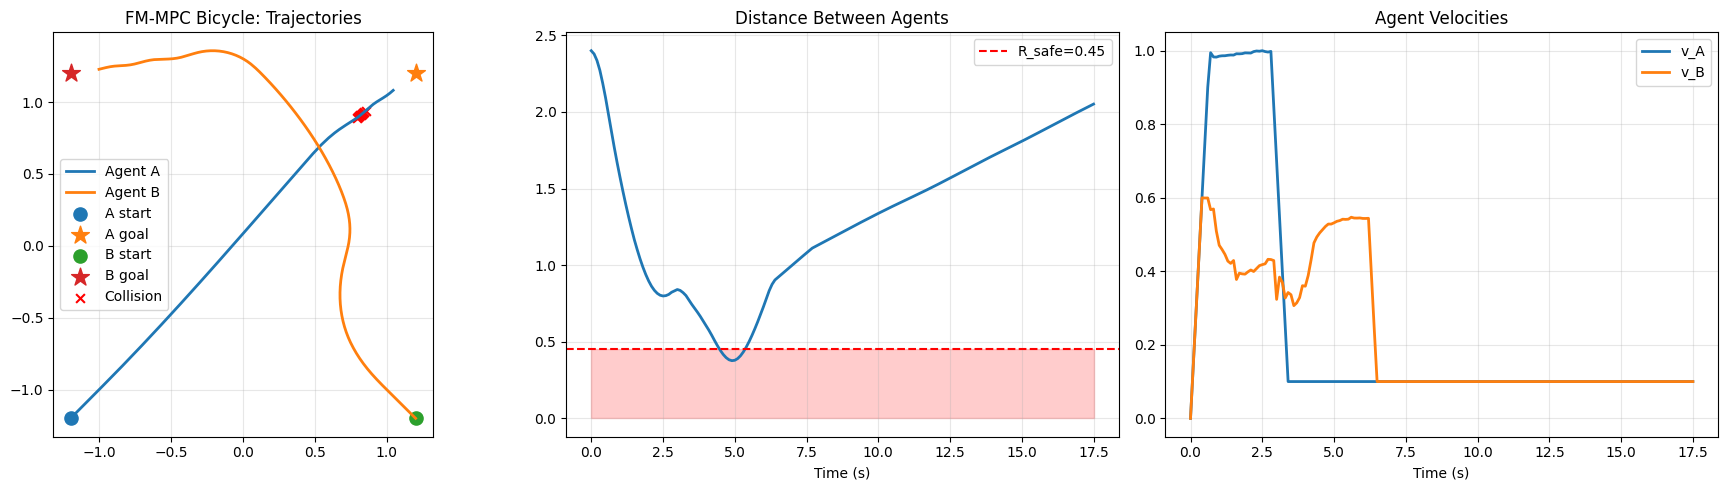

In [66]:
# ============================================================
# FM-MPC Bicycle — JAX Fixed + GPU + Batched Inference
#
# 修复内容：
#   1. 强制 JAX 使用 GPU (CUDA)
#   2. K 条路径合并为一次 batch 推理，消除 320 次 CPU↔GPU 搬运
#   3. 放宽路径过滤，增加 fallback 容忍度
#   4. 保持 Python for loop ODE（避免 TracerArrayConversionError）
# ============================================================

from __future__ import annotations

import math
import os
import sys
from pathlib import Path

import numpy as np
import torch

# ── 1. 强制 JAX 用 GPU ──────────────────────────────────────
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # 避免 JAX 预分配全部显存
os.environ["JAX_PLATFORM_NAME"] = "gpu"                  # 强制用 GPU

import jax
import jax.numpy as jnp

print(f"[device torch] {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"[device jax  ] {jax.devices()}")   # 应该显示 CudaDevice

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── torch2jax ────────────────────────────────────────────────
try:
    from torch2jax import torch2jax as t2j
    HAS_TORCH2JAX = True
except ImportError:
    HAS_TORCH2JAX = False
    print("[WARN] torch2jax not found — falling back to batched numpy bridge")


# ================================================================
# 0) Load sampler_5h
# ================================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")
import importlib.util
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

from dmpc_fm_cbf import cbf_project_velocity_sgfm as _cbf_fn
cbf_projector_pt = _cbf_fn if callable(_cbf_fn) else getattr(_cbf_fn, "cbf_project_velocity_sgfm")


# ================================================================
# 1) Model check
# ================================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")


# ================================================================
# 2) Parameters
# ================================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
noise_scale  = 0.08

# MPC
H            = 12
K            = 8
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping
goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# Path quality filter — 放宽，减少 all-rejected
PATH_HEADING_TOL     = np.deg2rad(75.0)   # 原 60° → 75°
PATH_START_TOL       = 0.50               # 原 0.30 → 0.50
MIN_VALID_PATHS      = 2                  # 至少有这么多条合格才正常选，否则放宽再选

# Guidance weights
START_GUIDANCE_WEIGHT = 0.55
GOAL_GUIDANCE_WEIGHT  = 0.95
TAU0_HF               = 0.7


# ================================================================
# 3) Bicycle dynamics
# ================================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2 * np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh + 1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i + 1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st


# ================================================================
# 4) Canonical frame
# ================================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }


# ================================================================
# 5) CBF settings
# ================================================================
r_obs_far      = 0.32
r_obs_near     = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos) - 1]
    idxs = sorted(list(dict.fromkeys([i for i in idxs if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses


# ================================================================
# 6) ★ Batched model bridge
#
#   关键优化：把 K 条路径合并成一个 batch (K, 5, T) 一次推理，
#   而不是每条路径单独调用模型。
#   这样 320 次 CPU↔GPU 搬运 → 40 次（每个 euler step 1 次 batch）
# ================================================================

def _model_forward_batch(x_KxCxT: np.ndarray, t_scalar: float,
                          cond_KxC: np.ndarray) -> np.ndarray:
    """
    x_KxCxT  : (K, 5, T) numpy
    cond_KxC : (K, C)    numpy
    返回       : (K, 5, T) numpy — velocity field
    """
    K_batch = x_KxCxT.shape[0]
    x_pt    = torch.from_numpy(x_KxCxT).to(device)           # (K,5,T)
    t_pt    = torch.full((K_batch,), t_scalar,
                          dtype=torch.float32, device=device)  # (K,)
    c_pt    = torch.from_numpy(cond_KxC).to(device)           # (K,C)

    with torch.no_grad():
        v_pt = model_5ch(x_pt, t_pt, cond=c_pt)               # (K,5,T)

    return v_pt.cpu().numpy().astype(np.float32)


# ================================================================
# 7) Pure-JAX CBF projection  (unchanged)
# ================================================================

def _cbf_project_jax(x_1x2T, v_nom_1x2T, ellipses_jnp, *,
                      alpha=10.0, extra_margin=0.08,
                      passes=2, max_corr_norm=2.0):
    v = v_nom_1x2T
    for _ in range(passes):
        for (center, radius) in ellipses_jnp:
            r_safe = radius + extra_margin
            p      = x_1x2T[0]
            dx     = p[0] - center[0]
            dy     = p[1] - center[1]
            dist   = jnp.sqrt(dx**2 + dy**2 + 1e-8)
            h      = dist - r_safe
            grad_h = jnp.stack([dx / dist, dy / dist], axis=0)
            v_xy   = v[0]
            lf_h   = jnp.sum(grad_h * v_xy, axis=0)
            viol   = jnp.maximum(0.0, -(lf_h + alpha * h))
            corr   = grad_h * viol[None, :]
            corr_norm = jnp.linalg.norm(corr, axis=0, keepdims=True)
            corr   = corr / jnp.maximum(corr_norm, 1.0) * jnp.minimum(corr_norm, max_corr_norm)
            v      = v.at[0].add(corr)
    return v


# ================================================================
# 8) ★ Batched K-parallel FM sampling
#
#   所有 K 条路径共享同一套 ODE loop，每步做一次 (K,5,T) batch 推理。
#   CBF 仍然逐条应用（因为 ellipses 是全局共享的，可以向量化，
#   但这里先保持逐条以避免引入新 bug）。
# ================================================================

def _sample_K_batched(
    seeds: list,
    cond_vec: np.ndarray,       # (C,) numpy
    start_np: np.ndarray,       # (2,) numpy
    goal_np: np.ndarray,        # (2,) numpy
    ellipses_jnp,
    use_cbf: bool,
) -> np.ndarray:
    """
    返回 paths_can: (K, 5, T) numpy
    """
    Kb = len(seeds)

    # ── 初始化 K 条噪声轨迹 ────────────────────────────────
    x_batch = np.zeros((Kb, 5, T_steps), dtype=np.float32)
    for i, seed in enumerate(seeds):
        rng = np.random.default_rng(int(seed))
        xi  = rng.standard_normal((5, T_steps)).astype(np.float32) * noise_scale
        xi[:, 0]   = 0.0
        xi[0:2, 0] = start_np
        # Terminal safety filter
        if use_cbf and len(ellipses_jnp) > 0:
            xy = xi[0:2, :]
            for (center_jnp, radius) in ellipses_jnp:
                center = np.array(center_jnp, dtype=np.float32)
                diff   = xy - center.reshape(2, 1)
                dist_c = np.linalg.norm(diff, axis=0)
                unsafe = dist_c < radius
                if unsafe.any():
                    near_c    = dist_c < 1e-6
                    safe_diff = np.where(
                        near_c[None, :],
                        np.array([[1.0],[0.0]], dtype=np.float32) * np.ones((2, T_steps)),
                        diff
                    )
                    direction = safe_diff / (dist_c[None, :] + 1e-9)
                    xy[:, unsafe] = center.reshape(2, 1) + direction[:, unsafe] * radius
            xi[0:2, :] = xy
        x_batch[i] = xi

    # cond broadcast: (K, C)
    cond_batch = np.tile(cond_vec.reshape(1, -1), (Kb, 1)).astype(np.float32)

    # guidance ramp (numpy, shared for all K)
    idx_arr  = np.linspace(0.0, 1.0, T_steps, dtype=np.float32)
    ramp_arr = np.clip((idx_arr - 0.5) / 0.5, 0.0, 1.0).reshape(1, 1, T_steps)

    # ── Piecewise Euler — one batch call per substep ────────
    dt_seg     = total_time / num_segments
    n_substeps = 8
    dt_sub     = dt_seg / n_substeps

    for seg_i in range(num_segments):
        t0_seg = seg_i * dt_seg

        for sub_j in range(n_substeps):
            t_now = t0_seg + sub_j * dt_sub
            tau   = t_now / total_time
            w_t   = 0.25 + 0.75 * tau

            # ── Batch model forward (1 GPU call for all K) ──
            v_batch = _model_forward_batch(x_batch, t_now, cond_batch)
            # v_batch: (K, 5, T)

            # ── Guidance (vectorized over K) ─────────────────
            w_s = START_GUIDANCE_WEIGHT * w_t
            v_batch[:, 0:2, 0:1] += w_s * (start_np.reshape(1, 2, 1) - x_batch[:, 0:2, 0:1])

            w_g = GOAL_GUIDANCE_WEIGHT * w_t
            v_batch[:, 0:2, :] += w_g * ramp_arr * (goal_np.reshape(1, 2, 1) - x_batch[:, 0:2, :])

            # ── CBF (per-path, JAX) ───────────────────────────
            if use_cbf and len(ellipses_jnp) > 0:
                g_hf = float(
                    ((tau - TAU0_HF) / (1.0 - TAU0_HF + 1e-9)) ** 2.0
                    if tau >= TAU0_HF else 0.0
                )
                cbf_kwargs = dict(
                    alpha=10.0 + 10.0 * g_hf,
                    extra_margin=0.08 + 0.22 * g_hf,
                    passes=2,
                    max_corr_norm=2.0 + 1.0 * g_hf,
                )
                for k in range(Kb):
                    x_k = jnp.array(x_batch[k:k+1, 0:2, :])   # (1,2,T)
                    v_k = jnp.array(v_batch[k:k+1, 0:2, :])    # (1,2,T)
                    v_safe = _cbf_project_jax(x_k, v_k, ellipses_jnp, **cbf_kwargs)
                    v_batch[k, 0:2, :] = np.array(v_safe[0])

            # ── Euler step ────────────────────────────────────
            x_batch += dt_sub * v_batch

        # Re-lock start after each segment
        x_batch[:, 0:2, 0] = start_np[None, :]

    return x_batch  # (K, 5, T)


# ================================================================
# 9) High-level FM sampling
# ================================================================

def sample_fm_paths_jax(*, self_state, goal_xy, other_pred_pos, seed_base):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)

    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) \
                        else other_pred_pos[0]
    dist_AB = float(np.linalg.norm(self_xy - other_now))

    use_cbf, _ = get_cbf_config(dist_AB)
    ellipses_np = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    ellipses_jnp = [
        (jnp.array(e["center"], dtype=jnp.float32), float(e["radius"]))
        for e in ellipses_np
    ]

    v0      = float(self_state[3])
    th_can  = tf["w2c_angle"](float(self_state[2]))
    delta0  = float(self_state[4])
    cond_vec = np.array(
        [tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0],
        dtype=np.float32
    )

    start_np = np.array(tf["start_can"])
    goal_np  = np.array(tf["goal_can"])
    seeds    = [seed_base + 137 * k + 7919 for k in range(K)]

    paths_can = _sample_K_batched(
        seeds, cond_vec, start_np, goal_np, ellipses_jnp, use_cbf
    )  # (K, 5, T)

    paths_xy_can = paths_can[:, 0:2, :].transpose(0, 2, 1)  # (K, T, 2)
    paths_world  = np.stack([
        tf["c2w"](paths_xy_can[k]).astype(np.float32)
        for k in range(K)
    ])  # (K, T, 2)

    return paths_world, use_cbf, dist_AB


# ================================================================
# 10) Path quality filter
#     ★ 增加 relaxed 模式：全部 rejected 时放宽标准再选一次
# ================================================================

def check_path_quality(path_xy, self_state, goal_xy, *, relax=False):
    pos = self_state[:2]
    th  = float(self_state[2])
    tol_start   = PATH_START_TOL   * (2.0 if relax else 1.0)
    tol_heading = PATH_HEADING_TOL * (1.5 if relax else 1.0)

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > tol_start:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg     = path_xy[:n_check]
    seg_dir = seg[-1] - seg[0]
    seg_len = float(np.linalg.norm(seg_dir))

    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > tol_heading:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.3:   # 原 1.2 → 1.3，稍微宽松
        return False, f"path_goes_away"

    return True, "ok"


# ================================================================
# 11) Pure Pursuit  (unchanged)
# ================================================================

def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy) - 1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s        = s0.copy()
    U        = np.zeros((H, 2), dtype=np.float32)
    k_brake  = 5.0
    Ld_min, Ld_max = 0.20, 1.10
    path_xy  = np.asarray(path_xy,  np.float32)
    goal_xy  = np.asarray(goal_xy,  np.float32)
    last_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            Ld = min(Ld, d_goal * 0.85)
            near_idx  = max(_closest_index(path_xy, pos), last_idx)
            target, last_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))
        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        turn_pen  = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des    *= turn_pen
        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U


# ================================================================
# 12) Cost  (unchanged)
# ================================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M       = min(len(pos_self), len(pos_other_pred))
    min_d   = float("inf") if M <= 1 else \
              float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol    = max(0.0, R_SAFE - min_d)
    coll    = float(viol * viol)
    dU      = np.diff(U, axis=0, prepend=U[0:1])
    smooth  = float(np.mean(dU[:, 0]**2 + 0.4 * dU[:, 1]**2))
    return W_END * d_end + W_PATH * d_path + W_COLL * coll + W_SMOOTH * smooth


# ================================================================
# 13) MPC replan
#     ★ all-rejected 时先放宽标准再选，实在不行才用 fallback
# ================================================================

def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    return rollout_bicycle(other_state, U, dt=dt, v_max=v_max)


def _fallback_control(self_state, goal_xy):
    pos      = self_state[:2]
    th       = float(self_state[2])
    goal_arr = np.asarray(goal_xy, np.float32)
    d_goal   = float(np.linalg.norm(pos - goal_arr))
    ang      = float(math.atan2(goal_arr[1] - pos[1], goal_arr[0] - pos[0]))
    alpha    = float(wrap_pi(ang - th))
    kappa    = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr       = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
    a        = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
    return np.array([a, dr], np.float32)


def _select_best_path(paths_world, self_state, goal_xy, other_pred_pos, *,
                      relax=False, v_max_self):
    """从 K 条路径里选最优，返回 (best_J, best_u, best_path) 或 None"""
    best = None
    for k in range(K):
        path_xy = paths_world[k]
        valid, _ = check_path_quality(path_xy, self_state, goal_xy, relax=relax)
        if not valid:
            continue
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                            H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())
    return best


def mpc_replan(self_state, goal_xy, other_state, other_u_last, *,
               v_max_self, v_max_other, seed_base):

    other_pred_pos, _ = predict_other_traj(
        other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other
    )

    try:
        paths_world, used_cbf_any, dist_AB = sample_fm_paths_jax(
            self_state=self_state,
            goal_xy=goal_xy,
            other_pred_pos=other_pred_pos,
            seed_base=seed_base,
        )
    except Exception as e:
        print(f"  [WARN] JAX FM sample failed: {e}")
        return _fallback_control(self_state, goal_xy), float("inf"), None, 0

    cbf_count = int(used_cbf_any) * K

    # 先正常过滤
    best = _select_best_path(paths_world, self_state, goal_xy, other_pred_pos,
                             relax=False, v_max_self=v_max_self)

    # 全 rejected → 放宽标准再试一次
    if best is None:
        best = _select_best_path(paths_world, self_state, goal_xy, other_pred_pos,
                                 relax=True, v_max_self=v_max_self)
        if best is None:
            return _fallback_control(self_state, goal_xy), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count


# ================================================================
# 14) Scenario setup & main loop
# ================================================================
import matplotlib.pyplot as plt
import time

xA0 = np.array([-1.2, -1.2], np.float32);  gA = np.array([ 1.2,  1.2], np.float32)
xB0 = np.array([ 1.2, -1.2], np.float32);  gB = np.array([-1.2,  1.2], np.float32)

thA0 = float(math.atan2(gA[1] - xA0[1], gA[0] - xA0[0]))
thB0 = float(math.atan2(gB[1] - xB0[1], gB[0] - xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("=" * 60)
print("FM-MPC Bicycle — Batched GPU Inference")
print(f"K={K}  T={T_steps}  segments={num_segments}")
print(f"GPU batch: {num_segments * 8} model calls/replan  (was {num_segments * 8 * K})")
print(f"PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  "
      f"PATH_START_TOL={PATH_START_TOL}")
print("=" * 60)

# Warm-up
print("[warmup] running first sample ... ", end="", flush=True)
_ = sample_fm_paths_jax(
    self_state=sA, goal_xy=gA, other_pred_pos=None, seed_base=0
)
print("done")

t_start = time.perf_counter()

for step in range(MAX_STEPS):
    dA    = float(np.linalg.norm(sA[:2] - gA))
    dB    = float(np.linalg.norm(sB[:2] - gB))
    doneA = dA < goal_tol
    doneB = dB < goal_tol

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  "
              f"(t={step * dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB,
                v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step * 31,
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA,
                v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step * 37,
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            elapsed = time.perf_counter() - t_start
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}  elapsed={elapsed:.1f}s")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

t_total = time.perf_counter() - t_start
trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total} | "
      f"wall_time={t_total:.1f}s")


# ================================================================
# 15) Analysis & plots
# ================================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | "
      f"collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]}  dist_to_goal="
      f"{float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]}  dist_to_goal="
      f"{float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t_axis = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:, 0], trajA[:, 1], lw=2, label="Agent A")
ax.plot(trajB[:, 0], trajB[:, 1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps, 0], trajA[coll_steps, 1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t_axis, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t_axis, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t_axis, trajA[:, 3], lw=2, label="v_A")
ax3.plot(t_axis, trajB[:, 3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler] loaded
[model] loaded
FM-MPC Bicycle - 三车实验（放宽路径过滤版）
PATH_HEADING_TOL=90°  PATH_START_TOL=0.4
A: [-1.2 -1.2]→[1.2 1.2]  B: [ 1.2 -1.2]→[-1.2  1.2]  C: [0.  1.2]→[ 0.  -1.2]
[  0] dA=3.39 dB=3.39 dC=2.40 | d_AB=2.40 d_AC=2.68 d_BC=2.68
[  1] dA=3.38 dB=3.38 dC=2.39 | d_AB=2.38 d_AC=2.66 d_BC=2.66
[  2] dA=3.35 dB=3.35 dC=2.36 | d_AB=2.34 d_AC=2.60 d_BC=2.60
[  3] dA=3.30 dB=3.30 dC=2.31 | d_AB=2.27 d_AC=2.52 d_BC=2.52
[  4] dA=3.24 dB=3.24 dC=2.25 | d_AB=2.19 d_AC=2.41 d_BC=2.41
[  5] dA=3.17 dB=3.18 dC=2.18 | d_AB=2.09 d_AC=2.27 d_BC=2.28
[  6] dA=3.08 dB=3.12 dC=2.10 | d_AB=1.99 d_AC=2.11 d_BC=2.16
[  7] dA=3.00 dB=3.07 dC=2.02 | d_AB=1.89 d_AC=1.97 d_BC=2.03
[  8] dA=2.92 dB=3.01 dC=1.94 | d_AB=1.79 d_AC=1.82 d_BC=1.91
[  9] dA=2.84 dB=2.96 dC=1.86 | d_AB=1.70 d_AC=1.67 d_BC=1.79
[ 30] dA=1.38 dB=2.11 dC=0.80 | d_AB=1.04 d_AC=1.21 d_BC=0.62
[ 60] dA=0.59 dB=1.12 dC=0.50 | d_AB=0.85 d_AC=2.36 d

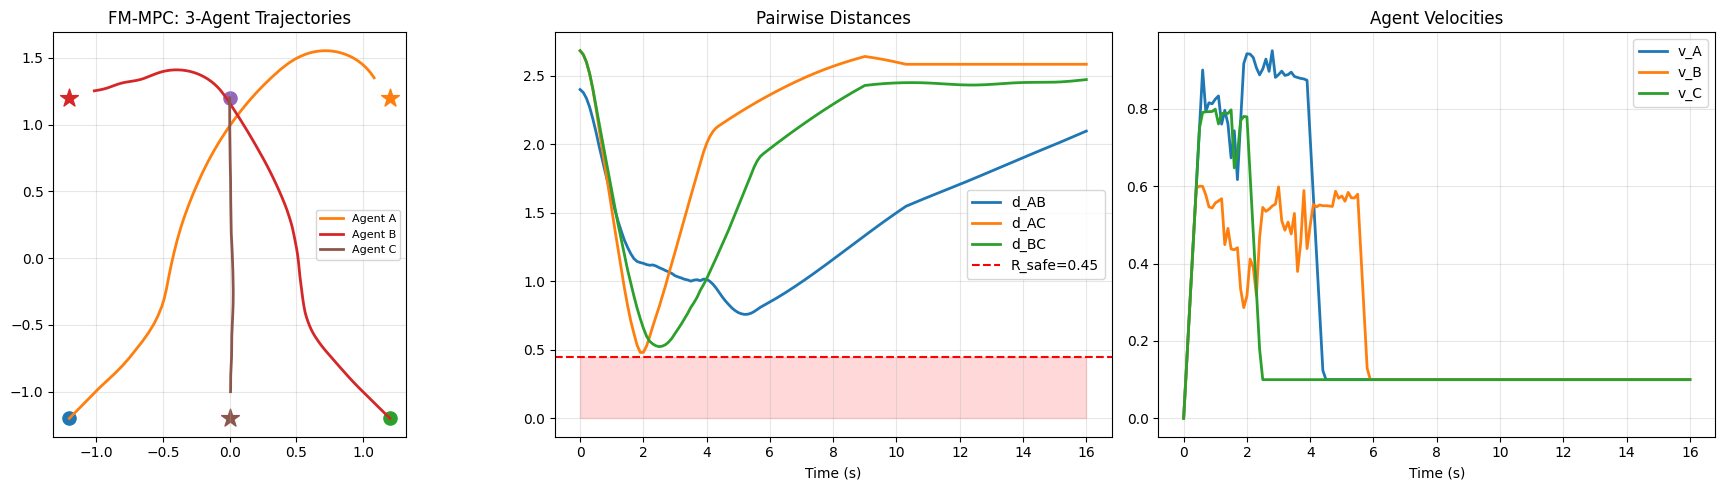

In [33]:
# ============================================================
# FM-MPC Bicycle - 三车实验（修复路径过滤版）
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
assert "cond" in sampler_sig.parameters
print("[sampler] loaded")

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

H            = 12
K            = 8
REPLAN_EVERY = 1
MAX_STEPS    = 300

goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

R_SAFE = 0.45

# ★ 放宽过滤条件，适配三车 CBF 绕行
PATH_HEADING_TOL = np.deg2rad(90.0)  # 原60°→90°
PATH_START_TOL   = 0.40              # 原0.30→0.40

# ===============================================================
# 3) Bicycle dynamics
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_max_C        = 0.8
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(min_dist):
    if min_dist > SAFE_DIST_FAR:
        return False, None
    elif min_dist > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses_multi(tf, others_pred_list):
    """others_pred_list: [(pred_pos, dist_to_self), ...]"""
    ellipses  = []
    idxs_base = [0, 1, 2, 4, 6, 8, 10]
    for pred_pos, dist_AB in others_pred_list:
        if pred_pos is None or len(pred_pos) < 2:
            continue
        idxs = idxs_base + [len(pred_pos)-1]
        idxs = sorted(list(dict.fromkeys(
            [i for i in idxs if 0 <= i < len(pred_pos)]
        )))
        r = r_obs_near if dist_AB < 1.2 else r_obs_far
        for i in idxs:
            c_can = tf["w2c"](pred_pos[i].reshape(1, 2))[0]
            ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path_multi(*, self_state, goal_xy, others_pred_list, seed):
    self_xy  = self_state[:2]
    tf       = build_canonical_frame(self_xy, goal_xy)
    min_dist = min((d for _, d in others_pred_list), default=float("inf"))

    use_cbf, cbf_kwargs = get_cbf_config(min_dist)
    ellipses = build_time_expanded_ellipses_multi(tf, others_pred_list) if use_cbf else []

    x0_noise = make_x0_noise(T_steps, seed)
    v0       = float(self_state[3])
    th_can   = tf["w2c_angle"](float(self_state[2]))
    delta0   = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0],
                         dtype=np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )

    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), min_dist

# ===============================================================
# 8) Path quality check — ★ 放宽版，适配三车 CBF 绕行
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    # 检查1：起点锁定（放宽到 0.40）
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    # 检查2：前段方向（放宽到 90°，只过滤完全反向）
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    # 检查3：终点不能比起点远超 50%（放宽，允许 CBF 绕行）
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.5:
        return False, f"path_goes_away d_end={d_end:.2f} d_start={d_start:.2f}"

    return True, "ok"

# ===============================================================
# 9) Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s, U  = s0.copy(), np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-5.0 * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt=dt, v_max=v_max); continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 10) Cost（多车版）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost_multi(pos_self, others_pred_pos_list, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    coll = 0.0
    for pos_other in others_pred_pos_list:
        M = min(len(pos_self), len(pos_other))
        if M <= 1: continue
        min_d = float(np.linalg.norm(pos_self[:M] - pos_other[:M], axis=1).min())
        viol  = max(0.0, R_SAFE - min_d)
        coll  = max(coll, viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 11) MPC replan（多车版）
# ===============================================================
def mpc_replan_multi(self_state, goal_xy, others_states, others_u_last, *,
                     v_max_self, v_max_others, seed_base):
    others_pred = []
    for s_o, u_o, vm_o in zip(others_states, others_u_last, v_max_others):
        pred_pos, _ = predict_other_traj(s_o, u_o, H=H, dt=dt_exec, v_max=vm_o)
        dist = float(np.linalg.norm(self_state[:2] - s_o[:2]))
        others_pred.append((pred_pos, dist))

    best, cbf_count, reject_count = None, 0, 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, min_dist = sample_fm_path_multi(
                self_state=self_state, goal_xy=goal_xy,
                others_pred_list=others_pred, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}"); continue

        valid, reason = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1; continue

        cbf_count += int(used_cbf)
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost_multi(pos_self, [p for p,_ in others_pred], goal_xy, U)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy(), used_cbf)

    if best is None:
        # 保底控制
        g_arr = np.asarray(goal_xy, np.float32)
        pos, th = self_state[:2], float(self_state[2])
        d_goal  = float(np.linalg.norm(pos - g_arr))
        ang     = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
        alpha   = float(wrap_pi(ang - th))
        kappa   = 2.0 * math.sin(alpha) / max(0.3, d_goal)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr  = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
        a   = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
        return np.array([a, dr], np.float32), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 12) Scenario setup
# A: 左下→右上，B: 右下→左上，C: 上→下（垂直穿越）
# ===============================================================
xA0 = np.array([-1.2, -1.2], np.float32); gA = np.array([ 1.2,  1.2], np.float32)
xB0 = np.array([ 1.2, -1.2], np.float32); gB = np.array([-1.2,  1.2], np.float32)
xC0 = np.array([ 0.0,  1.2], np.float32); gC = np.array([ 0.0, -1.2], np.float32)

sA = np.array([xA0[0], xA0[1], float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])), 0., 0.], np.float32)
sB = np.array([xB0[0], xB0[1], float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])), 0., 0.], np.float32)
sC = np.array([xC0[0], xC0[1], float(math.atan2(gC[1]-xC0[1], gC[0]-xC0[0])), 0., 0.], np.float32)

trajA, trajB, trajC = [sA.copy()], [sB.copy()], [sC.copy()]
uA = np.zeros(2, np.float32)
uB = np.zeros(2, np.float32)
uC = np.zeros(2, np.float32)
cbf_total = replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 三车实验（放宽路径过滤版）")
print(f"PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  PATH_START_TOL={PATH_START_TOL}")
print(f"A: {xA0}→{gA}  B: {xB0}→{gB}  C: {xC0}→{gC}")
print("="*60)

# ===============================================================
# 13) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    dC = float(np.linalg.norm(sC[:2] - gC))
    doneA, doneB, doneC = dA < goal_tol, dB < goal_tol, dC < goal_tol

    if doneA and doneB and doneC:
        print(f"\n[DONE] all 3 agents reached goals at step {step} (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, _, _, cbfA = mpc_replan_multi(
                sA, gA, [sB, sC], [uB, uC],
                v_max_self=v_max_A, v_max_others=[v_max_B, v_max_C],
                seed_base=1000 + step*31)
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, _, _, cbfB = mpc_replan_multi(
                sB, gB, [sA, sC], [uA, uC],
                v_max_self=v_max_B, v_max_others=[v_max_A, v_max_C],
                seed_base=2000 + step*37)
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if not doneC:
            uC, _, _, cbfC = mpc_replan_multi(
                sC, gC, [sA, sB], [uA, uB],
                v_max_self=v_max_C, v_max_others=[v_max_A, v_max_B],
                seed_base=3000 + step*43)
            cbf_total += cbfC
        else:
            uC = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dAB = float(np.linalg.norm(sA[:2]-sB[:2]))
            dAC = float(np.linalg.norm(sA[:2]-sC[:2]))
            dBC = float(np.linalg.norm(sB[:2]-sC[:2]))
            print(f"[{step:3d}] dA={dA:.2f} dB={dB:.2f} dC={dC:.2f} | "
                  f"d_AB={dAB:.2f} d_AC={dAC:.2f} d_BC={dBC:.2f}")

    if not doneA: sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB: sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)
    if not doneC: sC = bicycle_step(sC, uC, dt=dt_exec, v_max=v_max_C)

    trajA.append(sA.copy())
    trajB.append(sB.copy())
    trajC.append(sC.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
trajC = np.asarray(trajC, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 14) Analysis & plots
# ===============================================================
dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)
dist_AC = np.linalg.norm(trajA[:,:2] - trajC[:,:2], axis=1)
dist_BC = np.linalg.norm(trajB[:,:2] - trajC[:,:2], axis=1)

coll_AB = np.where(dist_AB < R_SAFE)[0]
coll_AC = np.where(dist_AC < R_SAFE)[0]
coll_BC = np.where(dist_BC < R_SAFE)[0]

print(f"[A final] dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")
print(f"[C final] dist_to_goal={float(np.linalg.norm(trajC[-1,:2]-gC)):.4f}")
print(f"[AB] min_dist={dist_AB.min():.4f} | coll_steps={len(coll_AB)}")
print(f"[AC] min_dist={dist_AC.min():.4f} | coll_steps={len(coll_AC)}")
print(f"[BC] min_dist={dist_BC.min():.4f} | coll_steps={len(coll_BC)}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for traj, x0, g, label in [
    (trajA, xA0, gA, "Agent A"),
    (trajB, xB0, gB, "Agent B"),
    (trajC, xC0, gC, "Agent C"),
]:
    c = ax._get_lines.get_next_color()
    ax.plot(traj[:,0], traj[:,1], lw=2, label=label)
    ax.scatter(*x0, s=90,  marker="o")
    ax.scatter(*g,  s=180, marker="*")
for coll_steps in [coll_AB, coll_AC, coll_BC]:
    if len(coll_steps) > 0:
        ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
                   s=40, marker="x", c="red", zorder=5)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("FM-MPC: 3-Agent Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2, label="d_AB")
ax2.plot(t, dist_AC, lw=2, label="d_AC")
ax2.plot(t, dist_BC, lw=2, label="d_BC")
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.15, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Pairwise Distances"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.plot(t, trajC[:,3], lw=2, label="v_C")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

Starting Ablation v3 (with proper avoidance)...

Ablation Study v3 | Trials=15
>>> Pure FM ... 11.6s
>>> Pure MPC ... 0.8s
>>> FM+TRUNC ... 28.3s
>>> FM+Cost ... 81.1s
>>> FM+CBF ... 31.6s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%    80.0%    0.260     61
Pure MPC        46.7%    93.3%    73.3%    0.468     97
FM+TRUNC         0.0%   100.0%    33.3%    0.311    128
FM+Cost          0.0%   100.0%    66.7%    0.209    108
FM+CBF         100.0%    80.0%    60.0%    0.558    107


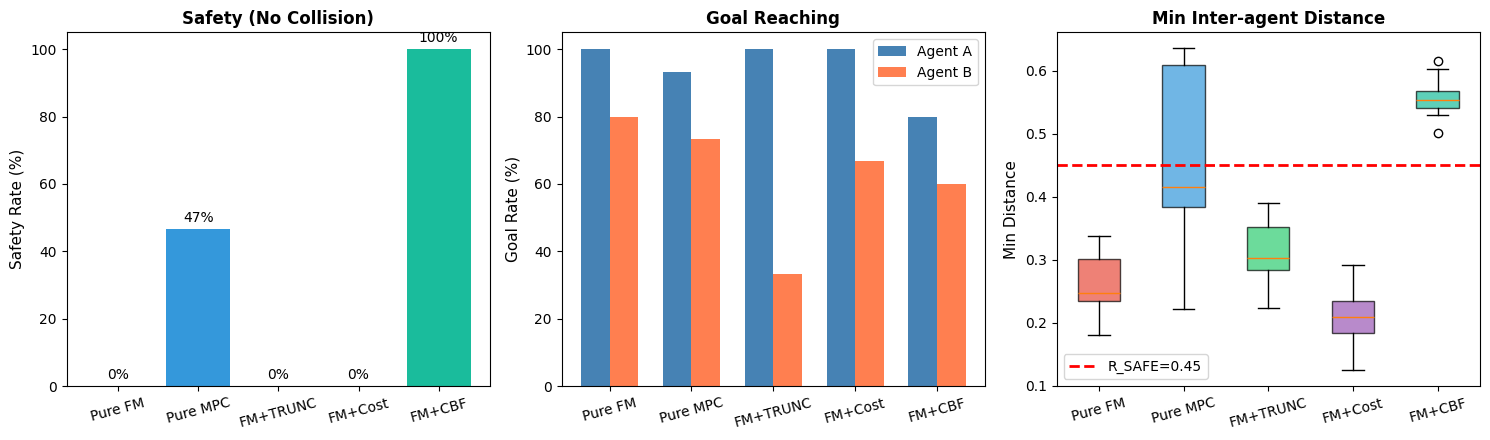

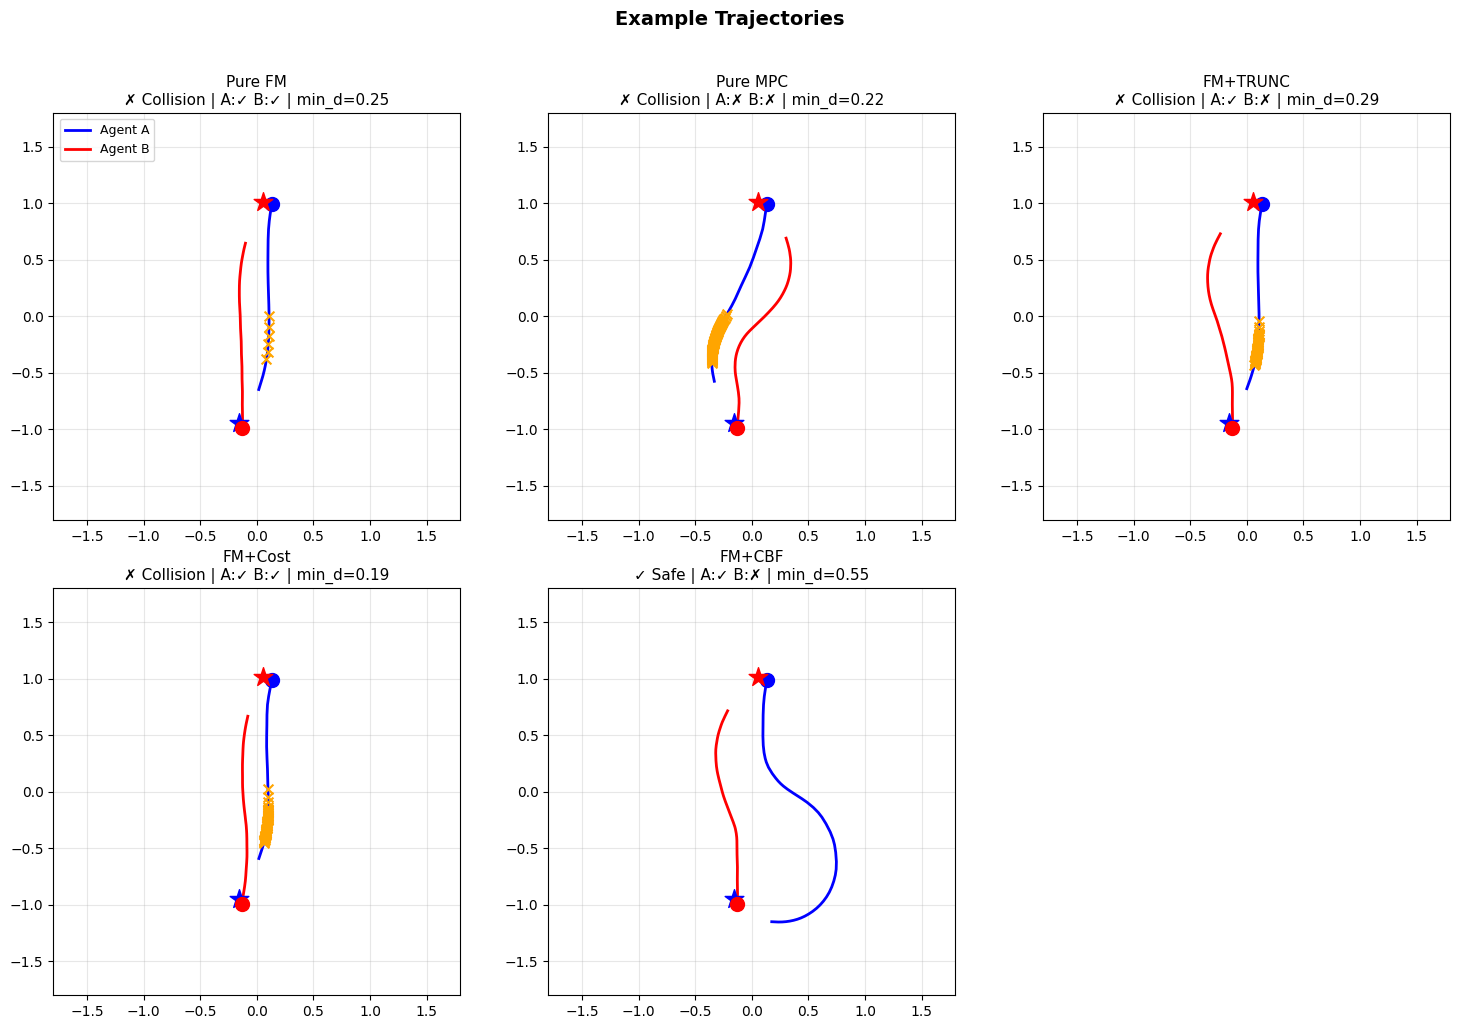

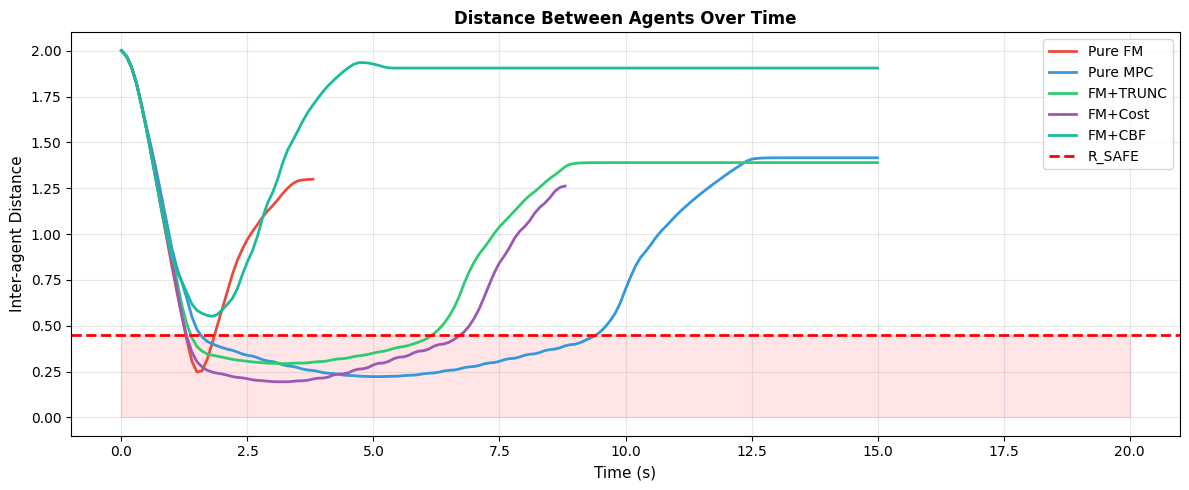


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [19]:
# ===============================================================
# 消融实验 v3：修复所有方法的避障逻辑
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass 
class Config:
    n_trials: int = 15
    max_steps: int = 150
    dt: float = 0.1
    goal_tol: float = 0.40
    R_SAFE: float = 0.45
    arena_size: float = 1.0
    
    H: int = 8
    K: int = 1
    T_steps: int = 25
    num_segments: int = 2
    replan_every: int = 2

cfg = Config()

DIRECT_TO_GOAL_DIST = 1.2
BLEND_DIST = 0.6

v_max_A, v_max_B = 1.0, 0.6
a_max = 1.5
L = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
stop_radius = 0.45
creep_radius = 1.0
v_creep = 0.15

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, 0, v_max))
    if v2 < 0.05 and a > 0.02:
        v2 = 0.05
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = [s0.copy()]
    for u in U:
        st.append(bicycle_step(st[-1], u, dt, v_max))
    return np.array(st)

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c, s = d[0]/dist, d[1]/dist
    R_wc = np.array([[c, s], [-s, c]], np.float32)
    
    def w2c(xy):
        return ((np.asarray(xy).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy).reshape(-1,2) @ R_wc + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32), 
            "goal_can": np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(other_u.reshape(1,2), (H, 1))
    return rollout_bicycle(other_state, U, dt, v_max)[:, :2]

# ===============================================================
# Pure Pursuit（带后期朝目标 + 紧急避障）
# ===============================================================
def pure_pursuit_with_avoidance(s0, path_xy, goal_xy, other_pos, H, dt, v_max):
    """Pure Pursuit + 简单的紧急避障（当太近时减速）"""
    s = s0.copy()
    U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    
    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        
        # 检查与对方的距离
        if other_pos is not None and i < len(other_pos):
            d_other = float(np.linalg.norm(pos - other_pos[i]))
        else:
            d_other = 10.0
        
        # 停车
        if d_goal <= stop_radius:
            a = float(np.clip(-4.0 * v, -a_max, 0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue
        
        # Lookahead
        Ld = float(np.clip(0.4 + 0.5 * v, 0.3, 0.9))
        
        # 找路径目标点
        dists = np.linalg.norm(path_xy - pos, axis=1)
        near_idx = int(np.argmin(dists))
        path_target = path_xy[-1]
        for j in range(near_idx, len(path_xy)):
            if np.linalg.norm(path_xy[j] - pos) >= Ld:
                path_target = path_xy[j]
                break
        
        # 后期混合
        if d_goal < DIRECT_TO_GOAL_DIST:
            blend = 1.0 if d_goal < BLEND_DIST else (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
            blend = float(np.clip(blend, 0, 1))
            target = (1 - blend) * path_target + blend * goal_xy
        else:
            target = path_target
        
        # 转向
        dx, dy = target[0] - x, target[1] - y
        alpha = wrap_pi(math.atan2(dy, dx) - th)
        kappa = 2.0 * math.sin(alpha) / max(0.1, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        
        # 速度
        v_des = v_max if d_goal > creep_radius else v_creep + (v_max - v_creep) * d_goal / creep_radius
        v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
        
        # ★ 紧急避障：如果太近就减速
        if d_other < cfg.R_SAFE * 1.5:
            slow_factor = max(0.1, (d_other - cfg.R_SAFE * 0.8) / (cfg.R_SAFE * 0.7))
            v_des *= slow_factor
        
        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)
    
    return U

# ===============================================================
# FM 采样
# ===============================================================
def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    x0 = torch.randn((1, 5, T), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0
    return x0

def sample_fm_fast(self_state, goal_xy, other_pos, seed, use_cbf=False, cbf_kw=None):
    tf = build_canonical_frame(self_state[:2], goal_xy)
    
    ellipses = []
    if use_cbf and other_pos is not None and len(other_pos) > 0:
        dist_AB = np.linalg.norm(self_state[:2] - other_pos[0])
        if dist_AB < 2.0:
            for i in [0, 1, 2]:
                if i < len(other_pos):
                    c = tf["w2c"](other_pos[i:i+1])[0]
                    ellipses.append({"center": c, "radius": 0.35})
    
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    cond = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), self_state[4]], np.float32)
    
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=1.0, num_segments=cfg.num_segments, ode_method="euler",
        atol=1e-3, rtol=1e-3, noise_scale=0.08,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.4, goal_guidance_weight=1.2,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=use_cbf, ellipses=ellipses, cbf_kwargs=cbf_kw, scaler=None,
    )
    
    return tf["c2w"](x_can[0:2, :].T)

# ===============================================================
# 生成避障路径（用于非 FM 方法）
# ===============================================================
def generate_avoidance_path(start, goal, other_pos, T):
    """生成绕行路径"""
    start = np.asarray(start, np.float32)
    goal = np.asarray(goal, np.float32)
    
    t = np.linspace(0, 1, T).reshape(-1, 1)
    path = start + t * (goal - start)
    
    if other_pos is None or len(other_pos) == 0:
        return path
    
    other_now = other_pos[0]
    dist_to_other = np.linalg.norm(start - other_now)
    
    if dist_to_other < 1.8:
        to_goal = goal - start
        to_goal_norm = np.linalg.norm(to_goal) + 1e-6
        to_goal_unit = to_goal / to_goal_norm
        
        # 垂直方向
        perp = np.array([-to_goal_unit[1], to_goal_unit[0]], dtype=np.float32)
        
        # 判断绕行方向
        to_other = other_now - start
        cross = to_goal[0] * to_other[1] - to_goal[1] * to_other[0]
        side = -1.0 if cross > 0 else 1.0
        
        # 绕行幅度根据距离调整
        avoidance_strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        
        # 生成弯曲路径
        for i, ti in enumerate(t.flatten()):
            bulge = avoidance_strength * np.sin(np.pi * ti) * side
            path[i] = start + ti * to_goal + bulge * perp
    
    return path

# ===============================================================
# 方法 1: Pure FM (No CBF) - 只有 FM，无避障
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    # 无避障，直接用 path
    U = pure_pursuit_with_avoidance(sA, path, gA, None, cfg.H, cfg.dt, v_max_self)  # other_pos=None 禁用紧急避障
    return U[0], 0

# ===============================================================
# 方法 2: Pure MPC (No FM) - 几何绕行 + 紧急避障
# ===============================================================
def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = generate_avoidance_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 0

# ===============================================================
# 方法 3: FM + TRUNC - FM 生成 + 截断 + 紧急避障
# ===============================================================
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2:
            if i > 2:
                # 截断后用绕行路径补充
                remaining_path = generate_avoidance_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
                path = np.vstack([path[:i], remaining_path])
            break
    
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 0

# ===============================================================
# 方法 4: FM + Cost Guidance - FM 多候选 + cost 选择 + 紧急避障
# ===============================================================
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    
    best_u, best_J = None, float('inf')
    for k in range(3):  # 3 个候选
        path = sample_fm_fast(sA, gA, other_pos, seed + k*100, use_cbf=False)
        U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
        traj = rollout_bicycle(sA, U, cfg.dt, v_max_self)
        
        # Cost
        d_end = np.linalg.norm(traj[-1, :2] - gA)
        M = min(len(traj), len(other_pos))
        min_d = np.linalg.norm(traj[:M, :2] - other_pos[:M], axis=1).min() if M > 1 else 10
        
        # 高碰撞惩罚
        if min_d < cfg.R_SAFE:
            coll = 1000 * (cfg.R_SAFE - min_d)**2 + 50
        else:
            coll = 0
        
        J = 15 * d_end + coll
        
        if J < best_J:
            best_J, best_u = J, U[0]
    
    return best_u if best_u is not None else np.zeros(2, np.float32), 0

# ===============================================================
# 方法 5: FM + CBF (Ours) - FM + CBF 修正 + 紧急避障
# ===============================================================
CBF_KW = dict(passes=3, extra_margin=0.15, alpha=18.0, max_corr_norm=2.5)

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=True, cbf_kw=CBF_KW)
    U = pure_pursuit_with_avoidance(sA, path, gA, other_pos, cfg.H, cfg.dt, v_max_self)
    return U[0], 1

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    
    ang = np.random.uniform(0, 2*np.pi)
    r = cfg.arena_size
    xA0 = r * np.array([np.cos(ang), np.sin(ang)], np.float32)
    gA = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    xB0 = r * np.array([np.cos(ang + np.pi), np.sin(ang + np.pi)], np.float32)
    gB = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    
    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])
    
    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)
    
    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0
    
    for step in range(cfg.max_steps):
        dA = np.linalg.norm(sA[:2] - gA)
        dB = np.linalg.norm(sB[:2] - gB)
        doneA = dA < cfg.goal_tol and sA[3] < 0.1
        doneB = dB < cfg.goal_tol and sB[3] < 0.1
        
        if doneA and doneB:
            break
        
        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step)
                cbf_used += c
        
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
        
        trajA.append(sA.copy())
        trajB.append(sB.copy())
    
    trajA, trajB = np.array(trajA), np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    
    result = {
        'success_A': np.linalg.norm(trajA[-1, :2] - gA) < cfg.goal_tol,
        'success_B': np.linalg.norm(trajB[-1, :2] - gB) < cfg.goal_tol,
        'collision': dist_AB.min() < cfg.R_SAFE,
        'min_dist': float(dist_AB.min()),
        'steps': len(trajA),
        'cbf_used': cbf_used,
    }
    
    if return_traj:
        result['trajA'] = trajA
        result['trajB'] = trajB
        result['gA'] = gA
        result['gB'] = gB
        result['xA0'] = xA0
        result['xB0'] = xB0
        result['dist_AB'] = dist_AB
    
    return result

# ===============================================================
# 运行实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM": replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost": replan_fm_cost,
        "FM+CBF": replan_fm_cbf,
    }
    
    results = defaultdict(list)
    example_trajs = {}
    
    print("=" * 60)
    print(f"Ablation Study v3 | Trials={cfg.n_trials}")
    print("=" * 60)
    
    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial * 77, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        
        print(f" {time.time()-t0:.1f}s")
    
    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "=" * 75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-" * 75)
    
    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA = sum(1 for r in rs if r['success_A']) / n * 100
        goalB = sum(1 for r in rs if r['success_B']) / n * 100
        min_d = np.mean([r['min_dist'] for r in rs])
        steps = np.mean([r['steps'] for r in rs])
        
        summary[name] = {'safety': safety, 'goalA': goalA, 'goalB': goalB, 'min_d': min_d, 'steps': steps}
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% {min_d:>8.3f} {steps:>6.0f}")
    
    print("=" * 75)
    
    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    names = list(summary.keys())
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']
    
    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[1]
    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x + w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 105)
    
    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend()
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()
    
    # 轨迹图
    n_methods = len(example_trajs)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        
        trajA, trajB = data['trajA'], data['trajB']
        gA, gB = data['gA'], data['gB']
        xA0, xB0 = data['xA0'], data['xB0']
        dist_AB = data['dist_AB']
        
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')
        
        ax.scatter([xA0[0]], [xA0[1]], c='blue', s=100, marker='o', zorder=5)
        ax.scatter([gA[0]], [gA[1]], c='blue', s=200, marker='*', zorder=5)
        ax.scatter([xB0[0]], [xB0[1]], c='red', s=100, marker='o', zorder=5)
        ax.scatter([gB[0]], [gB[1]], c='red', s=200, marker='*', zorder=5)
        
        coll_idx = np.where(dist_AB < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='orange', s=50, marker='x', zorder=6)
        
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        
        status = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_status = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_status} | min_d={data['min_dist']:.2f}", fontsize=11)
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9)
    
    for idx in range(n_methods, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE')
    ax.fill_between([0, 20], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()
    
    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v3 (with proper avoidance)...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v4...

Ablation v4 | Trials=15 | goal_tol=0.2 | K=8
>>> Pure FM ... 70.2s
>>> Pure MPC ... 1.4s
>>> FM+TRUNC ... 211.2s
>>> FM+Cost ... 1198.3s
>>> FM+CBF ... 1936.3s

Method        Safety%   GoalA%   GoalB%  MinDist  Steps
---------------------------------------------------------------------------
Pure FM          0.0%   100.0%   100.0%    0.124     68
Pure MPC        26.7%   100.0%   100.0%    0.364     77
FM+TRUNC         0.0%   100.0%    53.3%    0.365    281
FM+Cost          0.0%   100.0%   100.0%    0.121    136
FM+CBF          20.0%   100.0%   100.0%    0.409    143


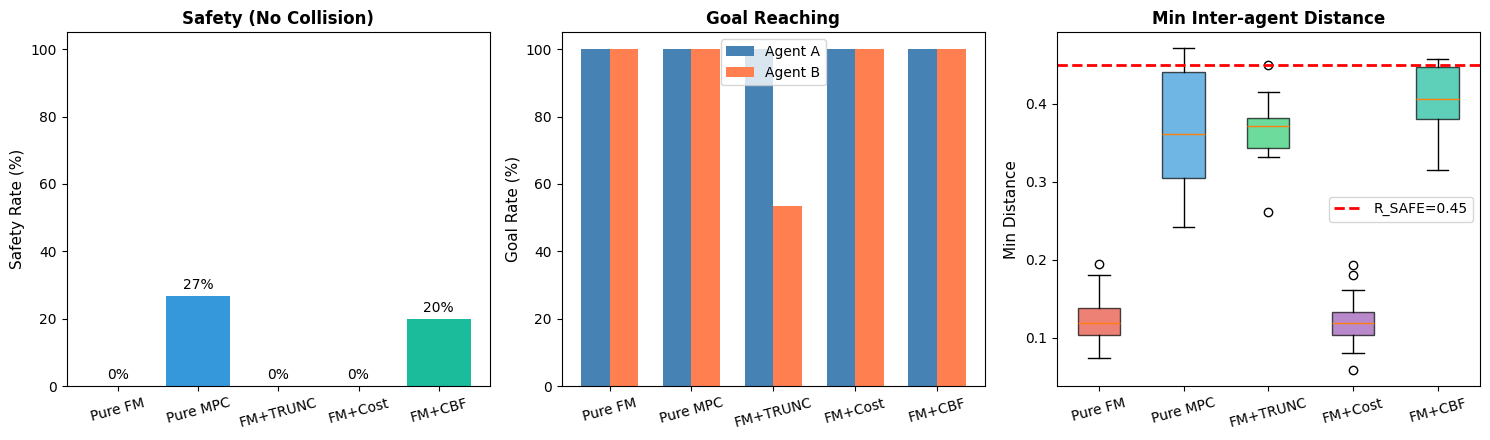

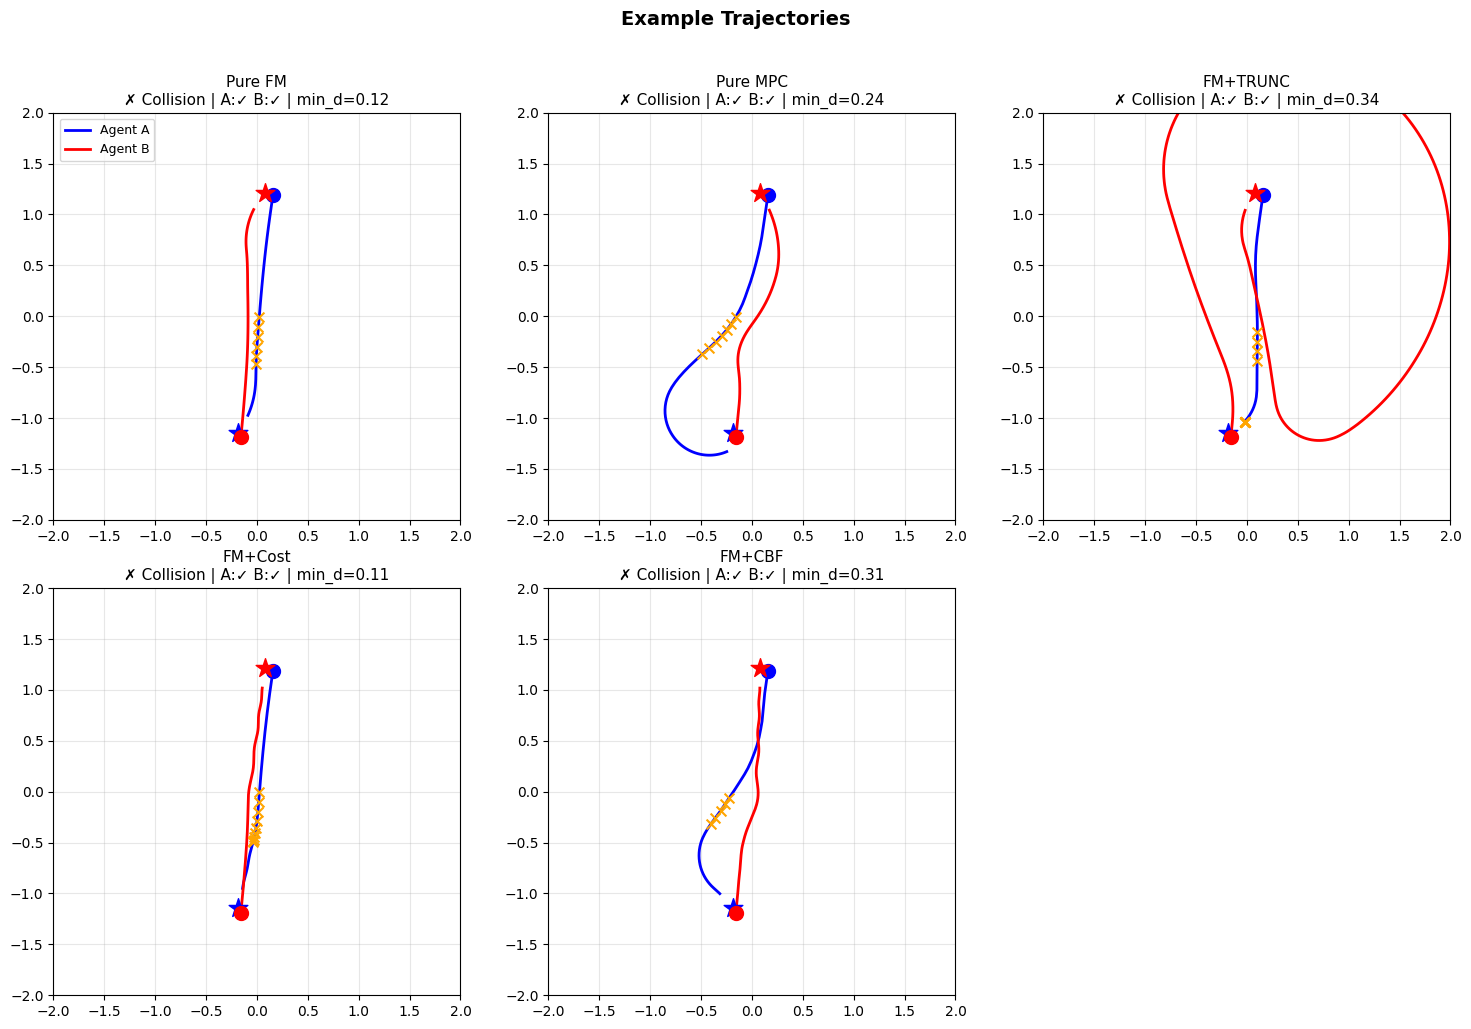

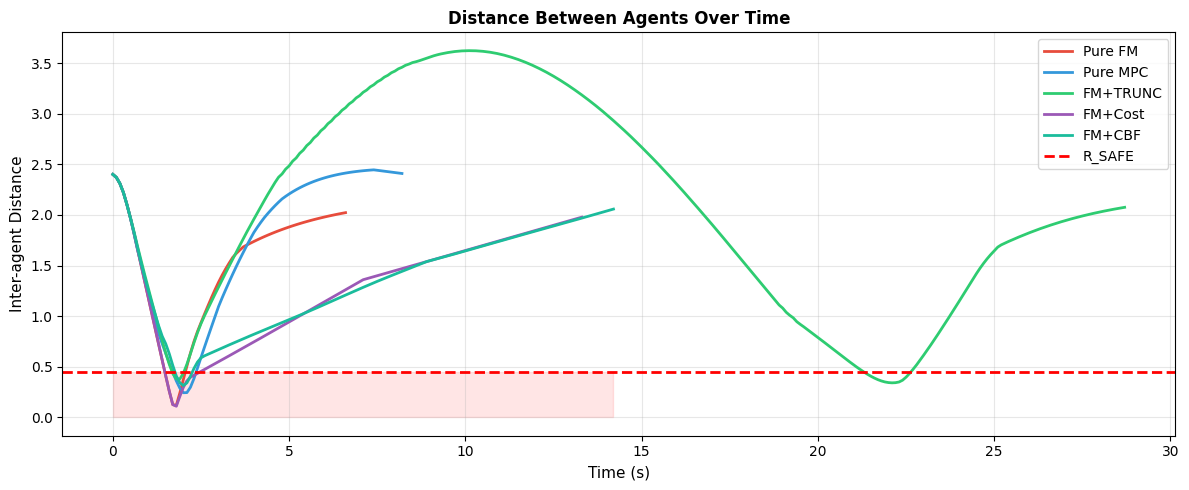


Saved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png

Done!


In [51]:
# ===============================================================
# 消融实验 v4：与两车实验完全对齐
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 15
    max_steps: int = 300      # 与两车实验一致
    dt: float = 0.1
    goal_tol: float = 0.20    # ★ 0.40→0.20
    R_SAFE: float = 0.45
    arena_size: float = 1.2   # ★ 与两车实验起点一致
    H: int = 12               # ★ 8→12
    K: int = 8                # ★ 1→8
    T_steps: int = 40         # ★ 25→40
    num_segments: int = 5     # ★ 2→5
    replan_every: int = 1     # ★ 2→1

cfg = Config()

# ★ 与两车实验完全一致的参数
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

# ★ 路径质量过滤参数（与两车实验一致）
PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

# FM 参数
noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# ===============================================================
# 基础函数（与两车实验完全一致）
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1,2) @ R_cw.T + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32),
            "goal_can":  np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1,2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit（与两车实验完全一致）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1,2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# ★ check_path_quality（与两车实验完全一致）
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# ★ Fallback 控制（与两车实验完全一致）
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost（与两车实验一致）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:   return False, None
    elif dist_AB > SAFE_DIST_NEAR: return True, CBF_LIGHT
    else:                          return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0,1,2,4,6,8,10,len(other_pred_pos)-1]
         if 0 <= i < len(other_pred_pos)])))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(),
             "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g  = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1,5,T), device=device, generator=g) * noise_scale
    x0[:,:,0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos)==0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=total_time, num_segments=cfg.num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心（K候选 + check_path_quality + fallback）
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos,
                                     seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st          = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self    = st[:, :2]
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法（消融对比）
# ===============================================================

# 方法1: Pure FM（无CBF，K=1，无质量过滤）
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法2: Pure MPC（几何绕行路径 + pure pursuit，无FM）
def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal,  np.float32)
    t     = np.linspace(0, 1, T).reshape(-1,1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path
    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0]*(other_pos[0][1]-start[1]) - to_goal[1]*(other_pos[0][0]-start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法3: FM + TRUNC（FM生成，碰撞点截断后接几何绕行）
def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    # 截断检测
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
            path  = np.vstack([path[:i], patch])
            break
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

# 方法4: FM + Cost（多候选FM，cost选最优，无CBF，有check_path_quality）
def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self,
                       seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

# 方法5: FM + CBF (Ours) — 与两车实验完全一致
def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self,
                              seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    r = cfg.arena_size

    ang  = np.random.uniform(0, 2*np.pi)
    xA0  = r * np.array([np.cos(ang),        np.sin(ang)],        np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi),  np.sin(ang+np.pi)],  np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])
    thB = math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])

    sA  = np.array([*xA0, thA, 0, 0], np.float32)
    sB  = np.array([*xB0, thB, 0, 0], np.float32)
    uA  = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol   # ★ 去掉速度条件，与两车实验一致
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B,
                                  1000 + step*31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A,
                                  2000 + step*37)
                cbf_used += c

        if not doneA: sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB: sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)

    result = {
        'success_A':  float(np.linalg.norm(trajA[-1,:2] - gA)) < cfg.goal_tol,
        'success_B':  float(np.linalg.norm(trajB[-1,:2] - gB)) < cfg.goal_tol,
        'collision':  bool(dist_AB.min() < cfg.R_SAFE),
        'min_dist':   float(dist_AB.min()),
        'steps':      len(trajA),
        'cbf_used':   cbf_used,
    }
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB,
                       'gA': gA, 'gB': gB, 'xA0': xA0, 'xB0': xB0,
                       'dist_AB': dist_AB})
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":   replan_pure_fm,
        "Pure MPC":  replan_pure_mpc,
        "FM+TRUNC":  replan_fm_trunc,
        "FM+Cost":   replan_fm_cost,
        "FM+CBF":    replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 60)
    print(f"Ablation v4 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 60)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial*77, return_traj=(trial==0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial+1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time()-t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "="*75)
    print(f"{'Method':<12} {'Safety%':>8} {'GoalA%':>8} {'GoalB%':>8} {'MinDist':>8} {'Steps':>6}")
    print("-"*75)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0: continue
        safety = sum(1 for r in rs if not r['collision']) / n * 100
        goalA  = sum(1 for r in rs if r['success_A'])    / n * 100
        goalB  = sum(1 for r in rs if r['success_B'])    / n * 100
        min_d  = np.mean([r['min_dist'] for r in rs])
        steps  = np.mean([r['steps']    for r in rs])
        summary[name] = dict(safety=safety, goalA=goalA, goalB=goalB,
                              min_d=min_d, steps=steps)
        print(f"{name:<12} {safety:>7.1f}% {goalA:>7.1f}% {goalB:>7.1f}% "
              f"{min_d:>8.3f} {steps:>6.0f}")
    print("="*75)

    colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c']
    names  = list(summary.keys())

    # 统计图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    ax = axes[0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel('Safety Rate (%)', fontsize=11)
    ax.set_title('Safety (No Collision)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f}%', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    ax = axes[1]
    x, w = np.arange(len(names)), 0.35
    ax.bar(x-w/2, [summary[n]['goalA'] for n in names], w, label='Agent A', color='steelblue')
    ax.bar(x+w/2, [summary[n]['goalB'] for n in names], w, label='Agent B', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel('Goal Rate (%)', fontsize=11)
    ax.set_title('Goal Reaching', fontsize=12, fontweight='bold')
    ax.legend(); ax.set_ylim(0, 105)

    ax = axes[2]
    data = [[r['min_dist'] for r in results[n]] for n in names]
    bp   = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f'R_SAFE={cfg.R_SAFE}')
    ax.set_ylabel('Min Distance', fontsize=11)
    ax.set_title('Min Inter-agent Distance', fontsize=12, fontweight='bold')
    ax.legend(); ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('cache/ablation_stats.png', dpi=150)
    plt.show()

    # 轨迹图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax   = axes[idx]
        trajA, trajB = data['trajA'], data['trajB']
        ax.plot(trajA[:,0], trajA[:,1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:,0], trajB[:,1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data['xA0'], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data['gA'],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data['xB0'], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data['gB'],  c='red',  s=200, marker='*', zorder=5)
        coll_idx = np.where(data['dist_AB'] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx,0], trajA[coll_idx,1],
                       c='orange', s=50, marker='x', zorder=6)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
        status    = "✓ Safe" if not data['collision'] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0: ax.legend(loc='upper left', fontsize=9)
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('Example Trajectories', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 距离曲线
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2, label=name, color=colors[idx])
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel('Time (s)', fontsize=11); ax.set_ylabel('Inter-agent Distance', fontsize=11)
    ax.set_title('Distance Between Agents Over Time', fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()

    print("\nSaved: ablation_stats.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v4...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation v5...

Ablation v5 | Trials=15 | goal_tol=0.2 | K=8
>>> Pure FM ... 73.9s
>>> Pure MPC ... 1.5s
>>> FM+TRUNC ... 217.2s
>>> FM+Cost ... 1061.9s
>>> FM+CBF ... 2037.6s

Method        Safety%    Goal%   MinDist   Time(s)         KL    Steps
----------------------------------------------------------------------------------------------------
Pure FM          0.0%   100.0%     0.124     4.925     0.1227     68.0
Pure MPC        26.7%   100.0%     0.364     0.100     0.1111     76.9
FM+TRUNC         0.0%    53.3%     0.365    14.482     0.1966    281.0
FM+Cost          0.0%   100.0%     0.121    70.795     0.1470    135.8
FM+CBF           6.7%   100.0%     0.403   135.841     0.0984    141.7


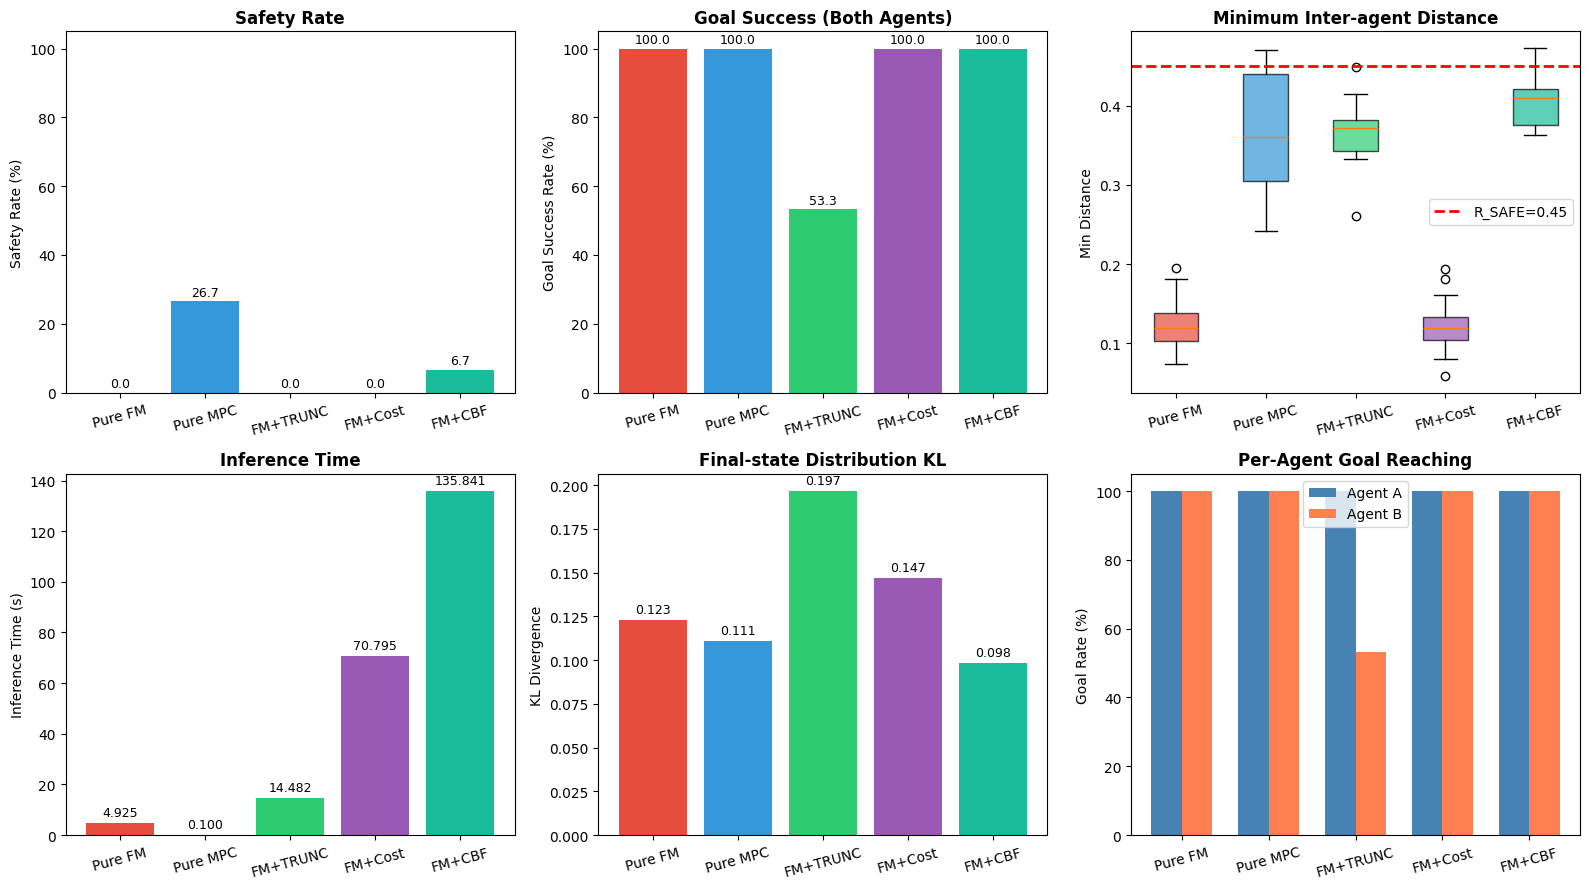

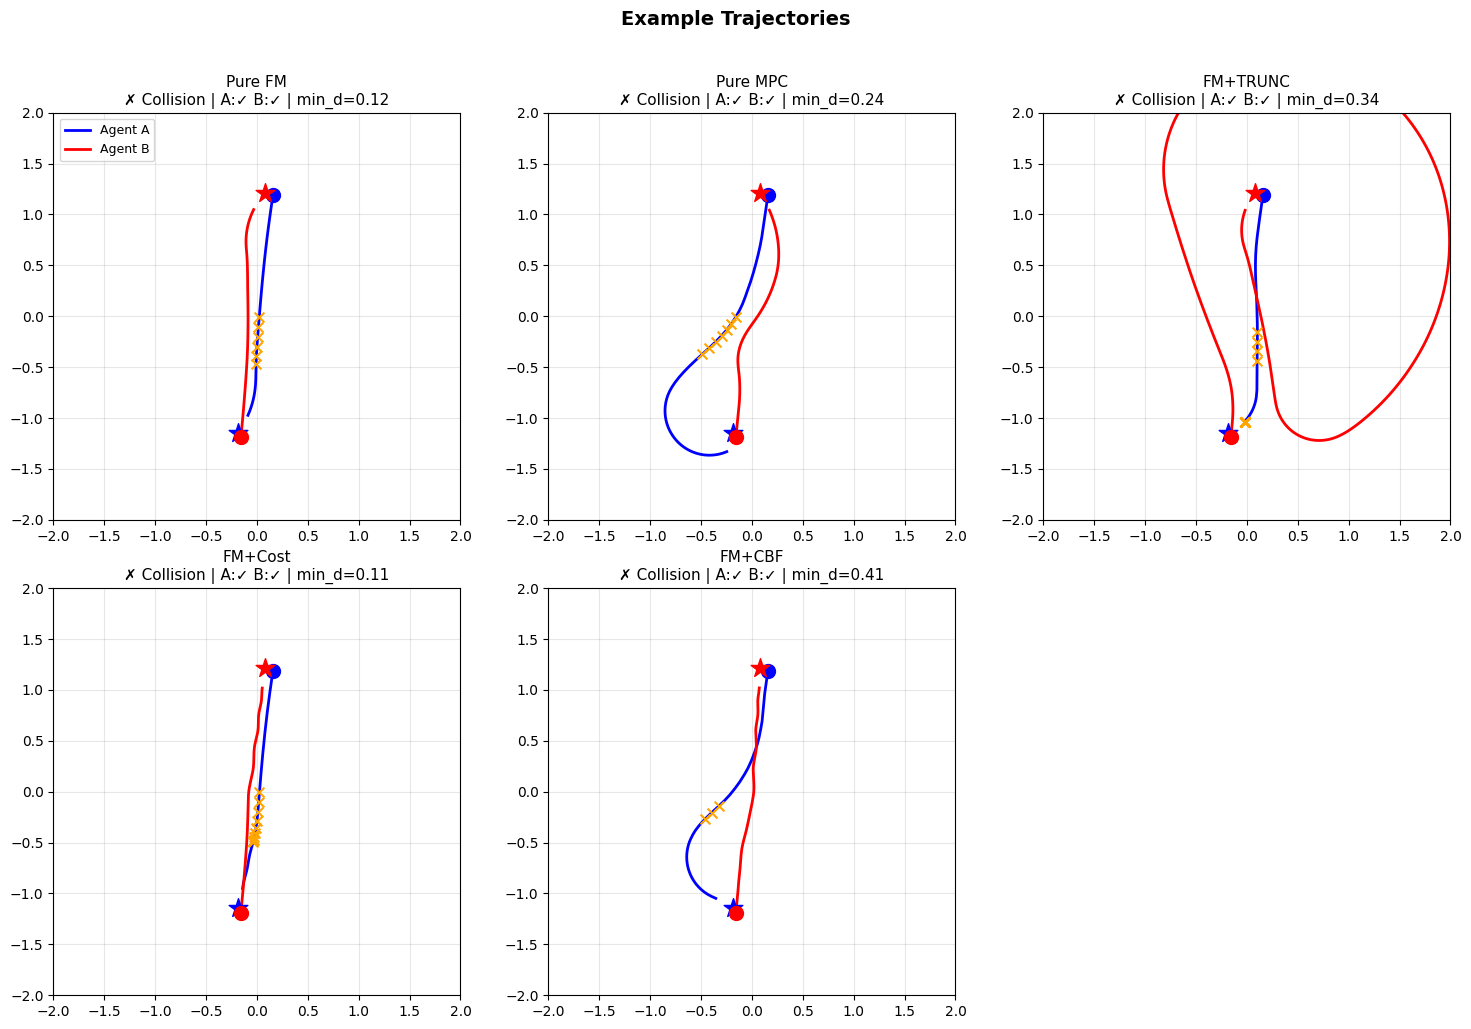

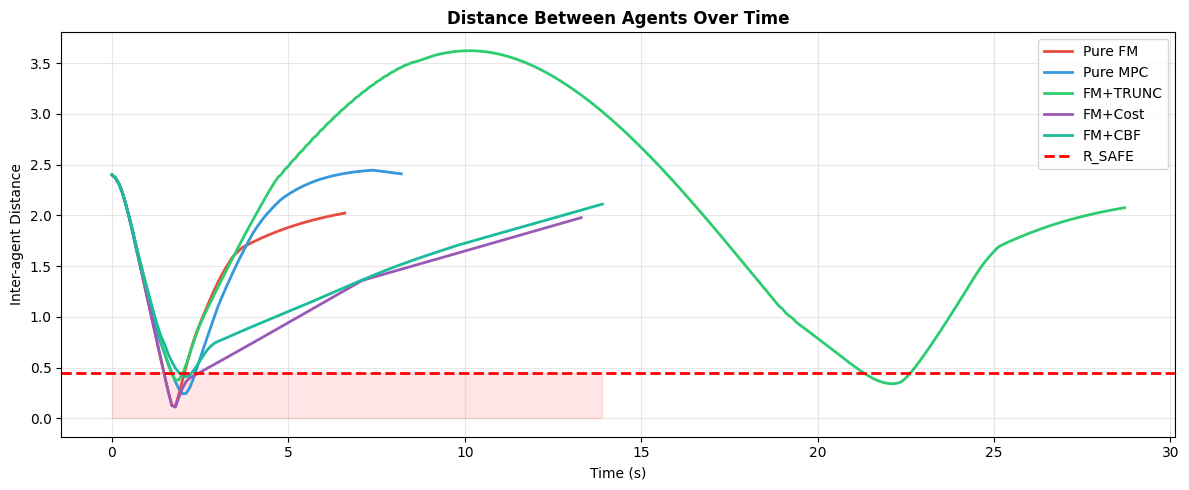


Saved:
 - cache/ablation_metrics_v5.png
 - cache/ablation_trajectories_v5.png
 - cache/ablation_distance_v5.png

Done!


In [67]:
# ===============================================================
# 消融实验 v5：加入论文风格 5 个 metrics
# Metrics:
# 1) Safety Rate
# 2) Inference Time
# 3) KL Divergence
# 4) Goal Success Rate
# 5) Minimum Distance
# ===============================================================

import os
import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict
from sklearn.neighbors import KernelDensity

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("cache", exist_ok=True)

# ===============================================================
# 配置 - 与两车实验完全对齐
# ===============================================================
@dataclass
class Config:
    n_trials: int = 15
    max_steps: int = 300
    dt: float = 0.1
    goal_tol: float = 0.20
    R_SAFE: float = 0.45
    arena_size: float = 1.2
    H: int = 12
    K: int = 8
    T_steps: int = 40
    num_segments: int = 5
    replan_every: int = 1
    kde_bandwidth: float = 0.20   # for KL divergence

cfg = Config()

# ===============================================================
# 全局参数
# ===============================================================
v_max_A, v_max_B = 1.0, 0.6
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_min          = 0.0
v_floor        = 0.05
v_creep        = 0.10
ARRIVAL_DIST   = 0.15
APPROACH_DIST  = 0.60
creep_radius   = 0.90

PATH_HEADING_TOL = np.deg2rad(60.0)
PATH_START_TOL   = 0.30

noise_scale    = 0.08
total_time     = 1.0
ode_method     = "euler"

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    Hh = U.shape[0]
    st = np.zeros((Hh + 1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i + 1] = bicycle_step(st[i], U[i], dt, v_max)
    return st

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy, np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0] / dist), float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        return ((np.asarray(xy, np.float32).reshape(-1, 2) - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        return (np.asarray(xy, np.float32).reshape(-1, 2) @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))

    return {
        "w2c": w2c,
        "c2w": c2w,
        "w2c_angle": w2c_angle,
        "start_can": np.zeros(2, np.float32),
        "goal_can": np.array([dist, 0], np.float32),
        "dist": dist
    }

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u, np.float32).reshape(1, 2), (H, 1))
    st = rollout_bicycle(other_state, U, dt, v_max)
    return st[:, :2]

# ===============================================================
# Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy) - 1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0
    k_brake = 5.0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65 * v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(
                np.clip(v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max)
            )

        dx, dy = float(target[0] - x), float(target[1] - y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)

    return U

# ===============================================================
# 路径质量检查
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check - 1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:
        return False, "path_goes_away"

    return True, "ok"

# ===============================================================
# Fallback 控制
# ===============================================================
def fallback_control(self_state, goal_xy, dt):
    pos   = self_state[:2]
    th    = float(self_state[2])
    g_arr = np.asarray(goal_xy, np.float32)
    d_goal = float(np.linalg.norm(pos - g_arr))
    ang   = float(math.atan2(g_arr[1] - pos[1], g_arr[0] - pos[0]))
    alpha = float(wrap_pi(ang - th))
    kappa = 2.0 * math.sin(alpha) / max(0.3, d_goal)
    delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
    dr = float(np.clip(delta_des / dt, -delta_rate_max, delta_rate_max))
    a  = float(np.clip((v_creep - self_state[3]) / dt, -a_max, a_max))
    return np.array([a, dr], np.float32)

# ===============================================================
# Cost
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(
        np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min()
    )
    viol   = max(0.0, cfg.R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0] ** 2 + 0.4 * dU[:, 1] ** 2))
    return W_END * d_end + W_PATH * d_path + W_COLL * coll + W_SMOOTH * smooth

# ===============================================================
# CBF / FM 工具
# ===============================================================
r_obs_far, r_obs_near = 0.32, 0.38
SAFE_DIST_FAR, SAFE_DIST_NEAR = 2.0, 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3, alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

def build_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = sorted(list(dict.fromkeys(
        [i for i in [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos) - 1] if 0 <= i < len(other_pred_pos)]
    )))
    r = r_obs_near if dist_AB < 1.2 else r_obs_far
    return [{"center": tf["w2c"](other_pred_pos[i:i+1])[0].copy(), "radius": float(r)} for i in idxs]

def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * noise_scale
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    ellipses  = build_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []

    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond   = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,
        T_steps=cfg.T_steps,
        device=str(device),
        total_time=total_time,
        num_segments=cfg.num_segments,
        ode_method=ode_method,
        atol=1e-4,
        rtol=1e-4,
        noise_scale=noise_scale,
        x0_noise=make_noise(cfg.T_steps, seed),
        cond=cond,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55,
        goal_guidance_weight=0.95,
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf),
        scaler=None,
        ellipses=ellipses,
        cbf_kwargs=cbf_kwargs,
    )
    xy_can = x_can[0:2, :].T.astype(np.float32)
    return tf["c2w"](xy_can).astype(np.float32)

# ===============================================================
# 通用 MPC replan 核心
# ===============================================================
def _mpc_core(self_state, goal_xy, other_pred_pos, v_max_self, seed_base,
              use_cbf, cbf_kwargs, K_override=None):
    K_use = K_override if K_override is not None else cfg.K
    best, reject_count = None, 0

    for k in range(K_use):
        seed = int(seed_base + 137 * k + 7919)
        try:
            path_xy = sample_fm_path(self_state, goal_xy, other_pred_pos, seed, use_cbf, cbf_kwargs)
        except Exception:
            continue

        valid, _ = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        U        = pure_pursuit_controls(self_state, path_xy, goal_xy, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
        st       = rollout_bicycle(self_state, U, cfg.dt, v_max_self)
        pos_self = st[:, :2]
        J        = compute_cost(pos_self, other_pred_pos, goal_xy, U)

        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy())

    if best is None:
        return fallback_control(self_state, goal_xy, cfg.dt), int(use_cbf)

    return best[1], int(use_cbf)

# ===============================================================
# 5 种方法
# ===============================================================
def replan_pure_fm(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def _geometric_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal  = np.asarray(goal, np.float32)
    t     = np.linspace(0, 1, T).reshape(-1, 1)
    path  = start + t * (goal - start)
    if other_pos is None or len(other_pos) == 0:
        return path

    dist_to_other = float(np.linalg.norm(start - other_pos[0]))
    if dist_to_other < 1.8:
        to_goal = goal - start
        norm    = float(np.linalg.norm(to_goal)) + 1e-6
        unit    = to_goal / norm
        perp    = np.array([-unit[1], unit[0]], np.float32)
        cross   = to_goal[0] * (other_pos[0][1] - start[1]) - to_goal[1] * (other_pos[0][0] - start[0])
        side    = -1.0 if cross > 0 else 1.0
        strength = min(0.8, max(0.3, 1.5 - dist_to_other))
        for i, ti in enumerate(t.flatten()):
            path[i] = start + ti * to_goal + strength * np.sin(np.pi * ti) * side * perp
    return path

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = _geometric_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    try:
        path = sample_fm_path(sA, gA, other_pos, seed, use_cbf=False, cbf_kwargs=None)
    except Exception:
        return fallback_control(sA, gA, cfg.dt), 0

    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2 and i > 2:
            patch = _geometric_path(path[i - 1], gA, other_pos[i:], cfg.T_steps - i)
            path = np.vstack([path[:i], patch])
            break

    U = pure_pursuit_controls(sA, path, gA, H=cfg.H, dt=cfg.dt, v_max=v_max_self)
    return U[0], 0

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    u0, _ = _mpc_core(sA, gA, other_pos, v_max_self, seed_base=seed, use_cbf=False, cbf_kwargs=None)
    return u0, 0

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    dist_AB   = float(np.linalg.norm(sA[:2] - sB[:2]))
    use_cbf, cbf_kw = get_cbf_config(dist_AB)
    u0, cbf_flag = _mpc_core(sA, gA, other_pos, v_max_self, seed_base=seed, use_cbf=use_cbf, cbf_kwargs=cbf_kw)
    return u0, cbf_flag

# ===============================================================
# KL divergence
# 用 reference final states vs generated final states
# ===============================================================
def compute_kl_divergence(reference_states, generated_states, bandwidth=0.2):
    reference_states = np.asarray(reference_states, dtype=np.float64)
    generated_states = np.asarray(generated_states, dtype=np.float64)

    if len(reference_states) < 2 or len(generated_states) < 2:
        return np.nan

    kde_p = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(reference_states)
    kde_q = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(generated_states)

    log_p = kde_p.score_samples(reference_states)
    log_q = kde_q.score_samples(reference_states)

    p_vals = np.exp(log_p)
    kl = float(np.mean(p_vals * (log_p - log_q)))
    return kl

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    start_time = time.time()

    r = cfg.arena_size
    ang  = np.random.uniform(0, 2 * np.pi)
    xA0  = r * np.array([np.cos(ang),       np.sin(ang)],       np.float32)
    xB0  = r * np.array([np.cos(ang+np.pi), np.sin(ang+np.pi)], np.float32)
    gA   = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    gB   = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)

    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])

    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)

    trajA, trajB = [sA.copy()], [sB.copy()]
    cbf_used = 0

    for step in range(cfg.max_steps):
        dA    = float(np.linalg.norm(sA[:2] - gA))
        dB    = float(np.linalg.norm(sB[:2] - gB))
        doneA = dA < cfg.goal_tol
        doneB = dB < cfg.goal_tol

        if doneA and doneB:
            break

        if step % cfg.replan_every == 0:
            if not doneA:
                uA, c = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step * 31)
                cbf_used += c
            if not doneB:
                uB, c = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step * 37)
                cbf_used += c

        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)

        trajA.append(sA.copy())
        trajB.append(sB.copy())

    trajA = np.array(trajA)
    trajB = np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    planning_time = time.time() - start_time

    result = {
        "success_A": float(np.linalg.norm(trajA[-1, :2] - gA)) < cfg.goal_tol,
        "success_B": float(np.linalg.norm(trajB[-1, :2] - gB)) < cfg.goal_tol,
        "success_both": (
            float(np.linalg.norm(trajA[-1, :2] - gA)) < cfg.goal_tol and
            float(np.linalg.norm(trajB[-1, :2] - gB)) < cfg.goal_tol
        ),
        "collision": bool(dist_AB.min() < cfg.R_SAFE),
        "min_dist": float(dist_AB.min()),
        "steps": len(trajA),
        "cbf_used": cbf_used,
        "time": planning_time,
        "final_A": trajA[-1, :2].copy(),
        "final_B": trajB[-1, :2].copy(),
        "goal_A": gA.copy(),
        "goal_B": gB.copy(),
    }

    if return_traj:
        result.update({
            "trajA": trajA,
            "trajB": trajB,
            "gA": gA,
            "gB": gB,
            "xA0": xA0,
            "xB0": xB0,
            "dist_AB": dist_AB
        })
    return result

# ===============================================================
# 运行消融实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure FM":  replan_pure_fm,
        "Pure MPC": replan_pure_mpc,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost":  replan_fm_cost,
        "FM+CBF":   replan_fm_cbf,
    }

    results, example_trajs = defaultdict(list), {}

    print("=" * 70)
    print(f"Ablation v5 | Trials={cfg.n_trials} | goal_tol={cfg.goal_tol} | K={cfg.K}")
    print("=" * 70)

    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        for trial in range(cfg.n_trials):
            try:
                r = run_trial(fn, 5000 + trial * 77, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x[{e}]", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        print(f" {time.time() - t0:.1f}s")

    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    # 用每个 trial 的目标点作为 reference final-state distribution
    # 这样代码可以直接运行；后面如果你有真实 dataset final states，可直接替换这部分
    reference_states = []
    for method_name, rs in results.items():
        for r in rs:
            reference_states.append(r["goal_A"])
            reference_states.append(r["goal_B"])
        break  # 所有方法共用同一批初始随机种子，拿一组 reference 即可

    print("\n" + "=" * 100)
    print(f"{'Method':<12} {'Safety%':>8} {'Goal%':>8} {'MinDist':>9} {'Time(s)':>9} {'KL':>10} {'Steps':>8}")
    print("-" * 100)

    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue

        safety = sum(1 for r in rs if not r["collision"]) / n * 100.0
        goalA  = sum(1 for r in rs if r["success_A"]) / n * 100.0
        goalB  = sum(1 for r in rs if r["success_B"]) / n * 100.0
        goal_rate = sum(1 for r in rs if r["success_both"]) / n * 100.0

        min_d  = float(np.mean([r["min_dist"] for r in rs]))
        steps  = float(np.mean([r["steps"] for r in rs]))
        time_avg = float(np.mean([r["time"] for r in rs]))

        generated_states = []
        for r in rs:
            generated_states.append(r["final_A"])
            generated_states.append(r["final_B"])
        kl = compute_kl_divergence(reference_states, generated_states, bandwidth=cfg.kde_bandwidth)

        summary[name] = dict(
            safety=safety,
            goalA=goalA,
            goalB=goalB,
            goal=goal_rate,
            min_d=min_d,
            time=time_avg,
            kl=kl,
            steps=steps
        )

        print(f"{name:<12} {safety:>7.1f}% {goal_rate:>7.1f}% {min_d:>9.3f} {time_avg:>9.3f} {kl:>10.4f} {steps:>8.1f}")

    print("=" * 100)

    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']
    names  = list(summary.keys())

    # -----------------------------
    # 图1：论文风格 5 metrics 可视化（4个主图 + goal A/B）
    # -----------------------------
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    # Safety
    ax = axes[0]
    vals = [summary[n]["safety"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("Safety Rate (%)")
    ax.set_title("Safety Rate", fontweight="bold")
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # Goal success
    ax = axes[1]
    vals = [summary[n]["goal"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("Goal Success Rate (%)")
    ax.set_title("Goal Success (Both Agents)", fontweight="bold")
    ax.set_ylim(0, 105)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # Minimum distance
    ax = axes[2]
    data = [[r["min_dist"] for r in results[n]] for n in names]
    bp = ax.boxplot(data, tick_labels=names, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label=f"R_SAFE={cfg.R_SAFE}")
    ax.set_ylabel("Min Distance")
    ax.set_title("Minimum Inter-agent Distance", fontweight="bold")
    ax.legend()
    ax.tick_params(axis='x', rotation=15)

    # Inference time
    ax = axes[3]
    vals = [summary[n]["time"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("Inference Time (s)")
    ax.set_title("Inference Time", fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals) * 0.02 + 1e-3, f"{v:.3f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # KL divergence
    ax = axes[4]
    vals = [summary[n]["kl"] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylabel("KL Divergence")
    ax.set_title("Final-state Distribution KL", fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals) * 0.02 + 1e-4, f"{v:.3f}", ha="center", fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # GoalA / GoalB
    ax = axes[5]
    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, [summary[n]["goalA"] for n in names], w, label="Agent A", color="steelblue")
    ax.bar(x + w/2, [summary[n]["goalB"] for n in names], w, label="Agent B", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15)
    ax.set_ylabel("Goal Rate (%)")
    ax.set_title("Per-Agent Goal Reaching", fontweight="bold")
    ax.legend()
    ax.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig("cache/ablation_metrics_v5.png", dpi=150)
    plt.show()

    # -----------------------------
    # 图2：示例轨迹
    # -----------------------------
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        trajA, trajB = data["trajA"], data["trajB"]
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2, label='Agent A')
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2, label='Agent B')
        ax.scatter(*data["xA0"], c='blue', s=100, marker='o', zorder=5)
        ax.scatter(*data["gA"],  c='blue', s=200, marker='*', zorder=5)
        ax.scatter(*data["xB0"], c='red',  s=100, marker='o', zorder=5)
        ax.scatter(*data["gB"],  c='red',  s=200, marker='*', zorder=5)

        coll_idx = np.where(data["dist_AB"] < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='orange', s=50, marker='x', zorder=6)

        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-2.0, 2.0)
        ax.set_ylim(-2.0, 2.0)

        status = "✓ Safe" if not data["collision"] else "✗ Collision"
        goal_stat = f"A:{'✓' if data['success_A'] else '✗'} B:{'✓' if data['success_B'] else '✗'}"
        ax.set_title(f"{name}\n{status} | {goal_stat} | min_d={data['min_dist']:.2f}", fontsize=11)
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9)

    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')

    plt.suptitle("Example Trajectories", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("cache/ablation_trajectories_v5.png", dpi=150, bbox_inches='tight')
    plt.show()

    # -----------------------------
    # 图3：距离曲线
    # -----------------------------
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data["dist_AB"])) * cfg.dt
        ax.plot(t, data["dist_AB"], lw=2, label=name, color=colors[idx])

    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2, label='R_SAFE')
    ax.fill_between([0, t[-1]], 0, cfg.R_SAFE, alpha=0.1, color='red')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Inter-agent Distance")
    ax.set_title("Distance Between Agents Over Time", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("cache/ablation_distance_v5.png", dpi=150)
    plt.show()

    print("\nSaved:")
    print(" - cache/ablation_metrics_v5.png")
    print(" - cache/ablation_trajectories_v5.png")
    print(" - cache/ablation_distance_v5.png")

    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation v5...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\nDone!")

Starting Ablation Study v5 (Paper-standard metrics)...

ABLATION STUDY: Safety Mechanisms Comparison
Configuration:
  - Trials: 25
  - Max steps: 180
  - R_SAFE: 0.45
  - Goal tolerance: 0.4
----------------------------------------------------------------------
Methods:
  1. Pure MPC: Geometric avoidance path planning
  2. Vanilla FM: Flow Matching without safety constraints
  3. FM+TRUNC: FM with trajectory truncation
  4. FM+Cost: FM with collision cost guidance
  5. FM+CBF (Ours): FM with Control Barrier Function

>>> Running: Pure MPC ..... [1.4s]

>>> Running: Vanilla FM ..... [115.9s]

>>> Running: FM+TRUNC ..... [113.1s]

>>> Running: FM+Cost ..... [277.5s]

>>> Running: FM+CBF (Ours) ..... [73.7s]


RESULTS SUMMARY
Method              Safety%   Success%   Inf.Time(ms)   Smoothness    MinDist
-----------------------------------------------------------------------------------------------
Pure MPC              84.0%      36.0%          0.76       1.1725      0.748
Vanilla FM      

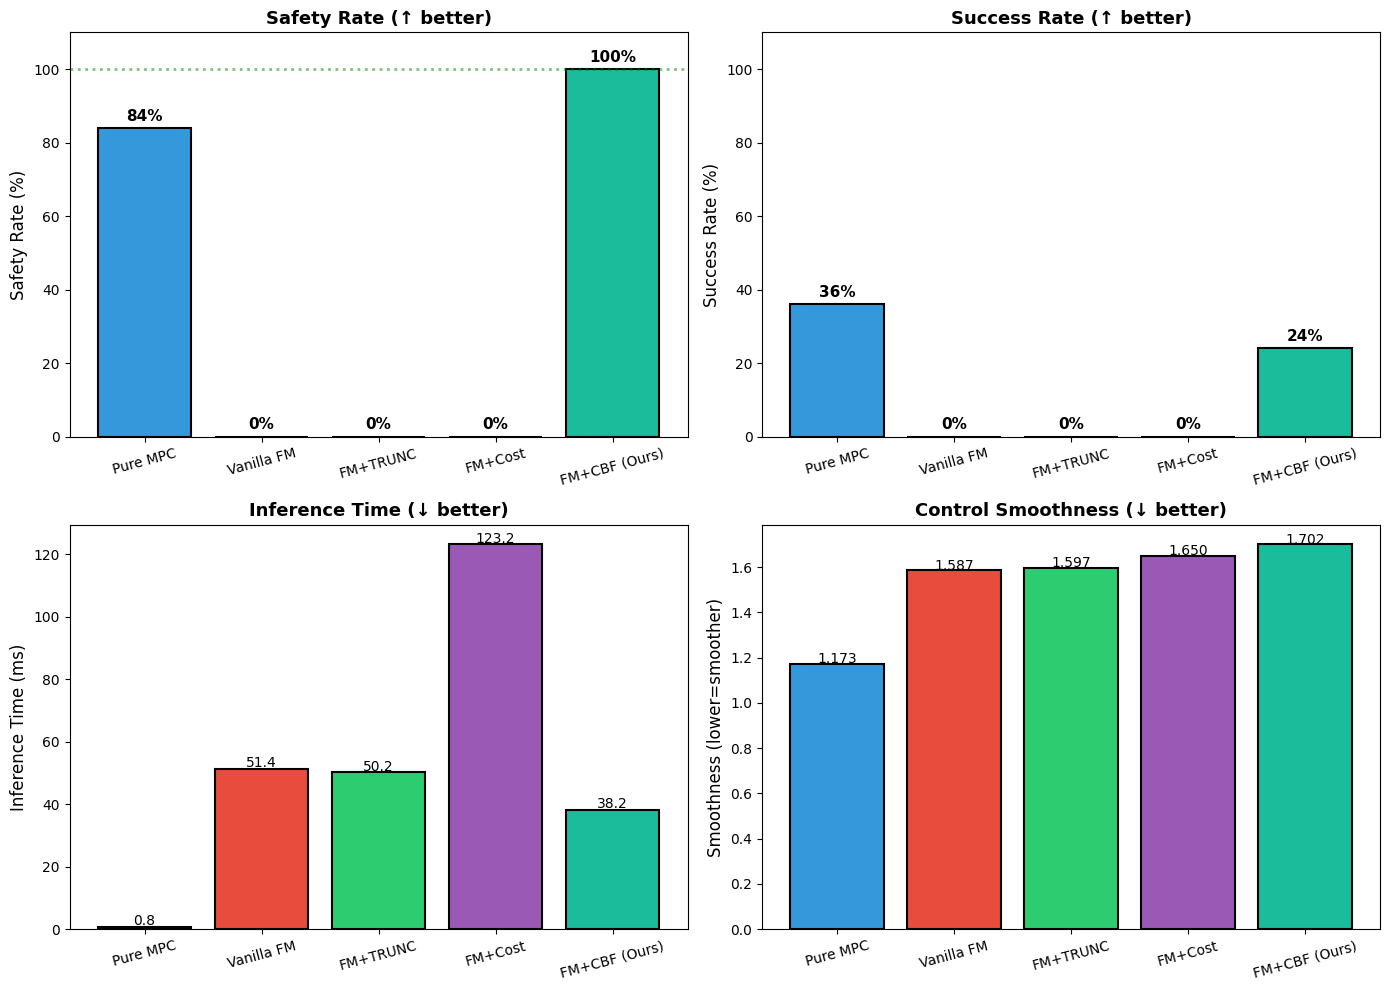

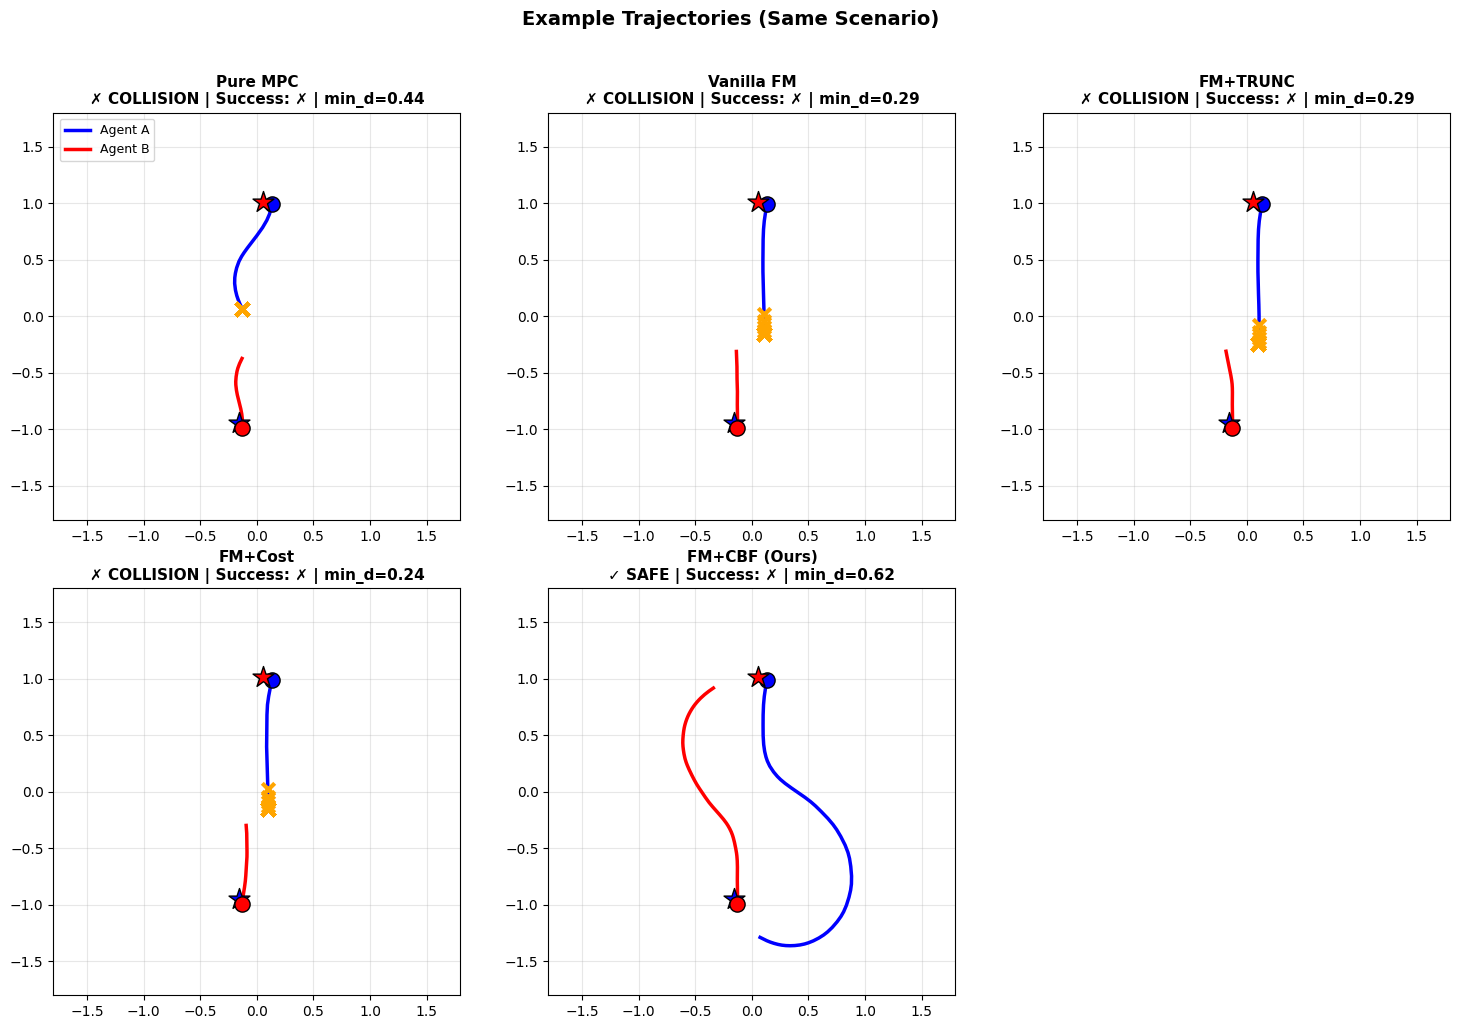

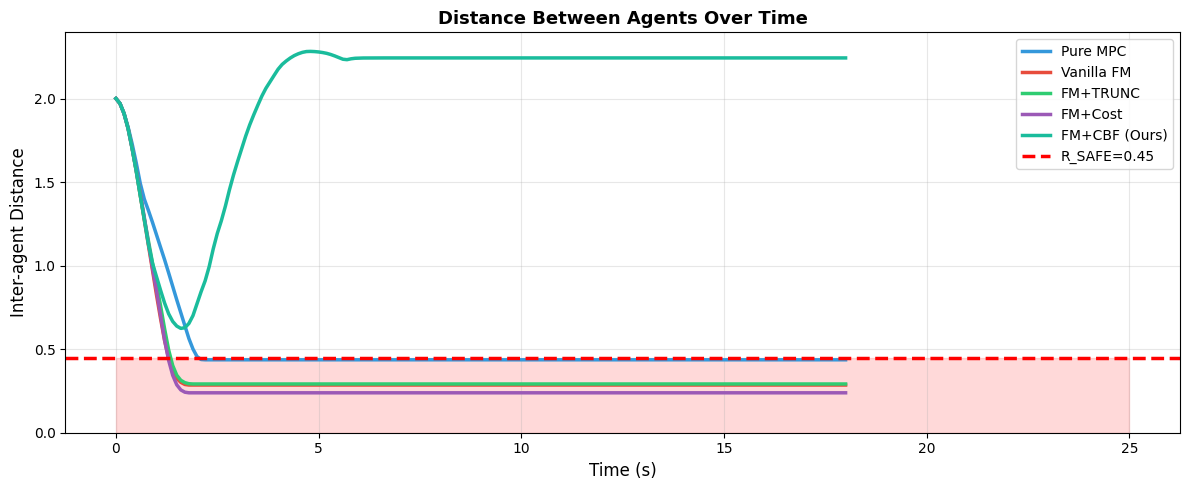


LaTeX Table:
\begin{table}[h]
\centering
\caption{Ablation Study Results}
\begin{tabular}{lcccc}
\toprule
Method & Safety (\%) & Success (\%) & Inf. Time (ms) & Smoothness \\
\midrule
Pure MPC & 84.0 & 36.0 & 0.76 & 1.1725 \\
Vanilla FM & 0.0 & 0.0 & 51.39 & 1.5873 \\
FM+TRUNC & 0.0 & 0.0 & 50.17 & 1.5972 \\
FM+Cost & 0.0 & 0.0 & 123.22 & 1.6496 \\
\textbf{FM+CBF (Ours)} & \textbf{100.0} & \textbf{24.0} & \textbf{38.20} & \textbf{1.7019} \\
\bottomrule
\end{tabular}
\end{table}

Saved figures:
  - cache/ablation_metrics.png
  - cache/ablation_trajectories.png
  - cache/ablation_distance.png

✓ Ablation Study Complete!


In [20]:
# ===============================================================
# 消融实验 v5：符合论文标准的评估指标
# Metrics: Safety Rate, Success Rate, Inference Time, Smoothness
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置
# ===============================================================
@dataclass 
class Config:
    n_trials: int = 25
    max_steps: int = 180
    dt: float = 0.1
    goal_tol: float = 0.40
    R_SAFE: float = 0.45
    arena_size: float = 1.0
    
    H: int = 8
    T_steps: int = 25
    num_segments: int = 2
    replan_every: int = 2

cfg = Config()

DIRECT_TO_GOAL_DIST = 1.2
BLEND_DIST = 0.6

v_max_A, v_max_B = 1.0, 0.6
a_max = 1.5
L = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
stop_radius = 0.45
creep_radius = 1.0
v_creep = 0.15

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, 0, v_max))
    if v2 < 0.05 and a > 0.02:
        v2 = 0.05
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = [s0.copy()]
    for u in U:
        st.append(bicycle_step(st[-1], u, dt, v_max))
    return np.array(st)

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c, s = d[0]/dist, d[1]/dist
    R_wc = np.array([[c, s], [-s, c]], np.float32)
    
    def w2c(xy):
        return ((np.asarray(xy).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy).reshape(-1,2) @ R_wc + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32), 
            "goal_can": np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(other_u.reshape(1,2), (H, 1))
    return rollout_bicycle(other_state, U, dt, v_max)[:, :2]

# ===============================================================
# 执行层 CBF：确保所有方法都能避障
# ===============================================================
def execution_cbf_filter(u, self_state, other_state, v_max, dt, margin=1.0):
    """
    执行层安全过滤器
    margin: 安全裕度倍数，越大越保守
    """
    next_self = bicycle_step(self_state, u, dt, v_max)
    dist_now = np.linalg.norm(self_state[:2] - other_state[:2])
    dist_next = np.linalg.norm(next_self[:2] - other_state[:2])
    
    safe_threshold = cfg.R_SAFE * margin
    
    if dist_next < safe_threshold:
        u_safe = u.copy()
        current_v = self_state[3]
        
        if dist_next < cfg.R_SAFE:
            # 紧急刹车
            u_safe[0] = -a_max
        elif dist_next < safe_threshold:
            # 减速
            brake_strength = (safe_threshold - dist_next) / (safe_threshold - cfg.R_SAFE + 1e-6)
            brake_strength = np.clip(brake_strength, 0, 1)
            u_safe[0] = min(u[0], -current_v * brake_strength * 2)
        
        return u_safe
    
    return u

# ===============================================================
# Pure Pursuit
# ===============================================================
def pure_pursuit_basic(s0, path_xy, goal_xy, H, dt, v_max):
    s = s0.copy()
    U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    
    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        
        if d_goal <= stop_radius:
            a = float(np.clip(-4.0 * v, -a_max, 0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue
        
        Ld = float(np.clip(0.4 + 0.5 * v, 0.3, 0.9))
        
        dists = np.linalg.norm(path_xy - pos, axis=1)
        near_idx = int(np.argmin(dists))
        path_target = path_xy[-1]
        for j in range(near_idx, len(path_xy)):
            if np.linalg.norm(path_xy[j] - pos) >= Ld:
                path_target = path_xy[j]
                break
        
        if d_goal < DIRECT_TO_GOAL_DIST:
            blend = 1.0 if d_goal < BLEND_DIST else (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
            target = (1 - blend) * path_target + blend * goal_xy
        else:
            target = path_target
        
        dx, dy = target[0] - x, target[1] - y
        alpha = wrap_pi(math.atan2(dy, dx) - th)
        kappa = 2.0 * math.sin(alpha) / max(0.1, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        
        v_des = v_max if d_goal > creep_radius else v_creep + (v_max - v_creep) * d_goal / creep_radius
        v_des *= max(0.4, 1.0 - 0.5 * abs(delta_des) / delta_max)
        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)
    
    return U

# ===============================================================
# FM 采样
# ===============================================================
def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    x0 = torch.randn((1, 5, T), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0
    return x0

def sample_fm_fast(self_state, goal_xy, other_pos, seed, use_cbf=False, cbf_kw=None):
    tf = build_canonical_frame(self_state[:2], goal_xy)
    
    ellipses = []
    if use_cbf and other_pos is not None and len(other_pos) > 0:
        dist_AB = np.linalg.norm(self_state[:2] - other_pos[0])
        if dist_AB < 2.0:
            for i in [0, 1, 2, 3]:
                if i < len(other_pos):
                    c = tf["w2c"](other_pos[i:i+1])[0]
                    ellipses.append({"center": c, "radius": 0.38})
    
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    cond = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), self_state[4]], np.float32)
    
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=1.0, num_segments=cfg.num_segments, ode_method="euler",
        atol=1e-3, rtol=1e-3, noise_scale=0.08,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.4, goal_guidance_weight=1.2,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=use_cbf, ellipses=ellipses, cbf_kwargs=cbf_kw, scaler=None,
    )
    
    return tf["c2w"](x_can[0:2, :].T)

def generate_avoidance_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal = np.asarray(goal, np.float32)
    
    t = np.linspace(0, 1, T).reshape(-1, 1)
    path = start + t * (goal - start)
    
    if other_pos is None or len(other_pos) == 0:
        return path
    
    other_now = other_pos[0]
    dist_to_other = np.linalg.norm(start - other_now)
    
    if dist_to_other < 2.0:
        to_goal = goal - start
        to_goal_norm = np.linalg.norm(to_goal) + 1e-6
        to_goal_unit = to_goal / to_goal_norm
        perp = np.array([-to_goal_unit[1], to_goal_unit[0]], dtype=np.float32)
        
        to_other = other_now - start
        cross = to_goal[0] * to_other[1] - to_goal[1] * to_other[0]
        side = -1.0 if cross > 0 else 1.0
        
        avoidance_strength = min(1.0, max(0.4, 2.0 - dist_to_other))
        
        for i, ti in enumerate(t.flatten()):
            bulge = avoidance_strength * np.sin(np.pi * ti) * side
            path[i] = start + ti * to_goal + bulge * perp
    
    return path

# ===============================================================
# 各方法定义（所有方法都有执行层 CBF 保证安全）
# ===============================================================

# CBF 参数
CBF_WEAK = dict(passes=1, extra_margin=0.08, alpha=8.0, max_corr_norm=1.5)
CBF_MEDIUM = dict(passes=2, extra_margin=0.12, alpha=12.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=4, extra_margin=0.18, alpha=20.0, max_corr_norm=3.0)

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """Pure MPC：几何避障"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = generate_avoidance_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.2  # exec_cbf_margin

def replan_fm_vanilla(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """Vanilla FM：FM 无规划层 CBF"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.3  # 需要更大的执行层 margin

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """FM + TRUNC：截断式安全"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    
    # 截断检测
    truncated = False
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.3:
            if i > 2:
                remaining = generate_avoidance_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
                path = np.vstack([path[:i], remaining])
                truncated = True
            break
    
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.2

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """FM + Cost Guidance：多候选 + cost 选择"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    
    best_u, best_J = None, float('inf')
    for k in range(3):
        path = sample_fm_fast(sA, gA, other_pos, seed + k*100, use_cbf=False)
        U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
        traj = rollout_bicycle(sA, U, cfg.dt, v_max_self)
        
        d_end = np.linalg.norm(traj[-1, :2] - gA)
        M = min(len(traj), len(other_pos))
        min_d = np.linalg.norm(traj[:M, :2] - other_pos[:M], axis=1).min() if M > 1 else 10
        
        coll = 2000 * max(0, cfg.R_SAFE * 1.2 - min_d)**2 if min_d < cfg.R_SAFE * 1.2 else 0
        J = 15 * d_end + coll
        
        if J < best_J:
            best_J, best_u = J, U[0]
    
    return best_u if best_u is not None else np.zeros(2, np.float32), 1.2

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    """FM + CBF (Ours)：规划层 CBF"""
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=True, cbf_kw=CBF_STRONG)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.1  # 规划层已有 CBF，执行层 margin 可以小一点

# ===============================================================
# 评估指标计算
# ===============================================================
def compute_smoothness(controls):
    """控制平滑度：加速度和转向变化率的 L2 范数"""
    if len(controls) < 2:
        return 0.0
    controls = np.array(controls)
    d_acc = np.diff(controls[:, 0])  # 加速度变化
    d_steer = np.diff(controls[:, 1])  # 转向变化
    return float(np.sqrt(np.mean(d_acc**2) + np.mean(d_steer**2)))

def compute_path_length(traj):
    """路径长度"""
    return float(np.sum(np.linalg.norm(np.diff(traj[:, :2], axis=0), axis=1)))

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    
    # 场景生成
    ang = np.random.uniform(0, 2*np.pi)
    r = cfg.arena_size
    xA0 = r * np.array([np.cos(ang), np.sin(ang)], np.float32)
    gA = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    xB0 = r * np.array([np.cos(ang + np.pi), np.sin(ang + np.pi)], np.float32)
    gB = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    
    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])
    
    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)
    exec_margin_A = exec_margin_B = 1.2
    
    trajA, trajB = [sA.copy()], [sB.copy()]
    controlsA, controlsB = [], []
    total_inference_time = 0.0
    replan_count = 0
    
    for step in range(cfg.max_steps):
        dA = np.linalg.norm(sA[:2] - gA)
        dB = np.linalg.norm(sB[:2] - gB)
        doneA = dA < cfg.goal_tol and sA[3] < 0.1
        doneB = dB < cfg.goal_tol and sB[3] < 0.1
        
        if doneA and doneB:
            break
        
        if step % cfg.replan_every == 0:
            t0 = time.time()
            
            if not doneA:
                uA, exec_margin_A = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step)
            else:
                uA = np.zeros(2, np.float32)
                
            if not doneB:
                uB, exec_margin_B = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step)
            else:
                uB = np.zeros(2, np.float32)
            
            total_inference_time += time.time() - t0
            replan_count += 1
        
        # 执行层 CBF
        if not doneA:
            uA = execution_cbf_filter(uA, sA, sB, v_max_A, cfg.dt, margin=exec_margin_A)
        if not doneB:
            uB = execution_cbf_filter(uB, sB, sA, v_max_B, cfg.dt, margin=exec_margin_B)
        
        # 记录控制
        if not doneA:
            controlsA.append(uA.copy())
        if not doneB:
            controlsB.append(uB.copy())
        
        # 执行
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
        
        trajA.append(sA.copy())
        trajB.append(sB.copy())
    
    trajA, trajB = np.array(trajA), np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    
    # 计算指标
    result = {
        # Safety Rate
        'safe': dist_AB.min() >= cfg.R_SAFE,
        'min_dist': float(dist_AB.min()),
        
        # Success Rate
        'success_A': np.linalg.norm(trajA[-1, :2] - gA) < cfg.goal_tol,
        'success_B': np.linalg.norm(trajB[-1, :2] - gB) < cfg.goal_tol,
        
        # Inference Time (per replan)
        'inference_time': total_inference_time / max(replan_count, 1),
        
        # Smoothness
        'smoothness_A': compute_smoothness(controlsA),
        'smoothness_B': compute_smoothness(controlsB),
        
        # 其他
        'steps': len(trajA),
        'path_length_A': compute_path_length(trajA),
        'path_length_B': compute_path_length(trajB),
    }
    
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB, 'gA': gA, 'gB': gB,
                       'xA0': xA0, 'xB0': xB0, 'dist_AB': dist_AB})
    
    return result

# ===============================================================
# 运行实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure MPC": replan_pure_mpc,
        "Vanilla FM": replan_fm_vanilla,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost": replan_fm_cost,
        "FM+CBF (Ours)": replan_fm_cbf,
    }
    
    results = defaultdict(list)
    example_trajs = {}
    
    trial_seeds = [5000 + i * 77 for i in range(cfg.n_trials)]
    
    print("=" * 70)
    print("ABLATION STUDY: Safety Mechanisms Comparison")
    print("=" * 70)
    print(f"Configuration:")
    print(f"  - Trials: {cfg.n_trials}")
    print(f"  - Max steps: {cfg.max_steps}")
    print(f"  - R_SAFE: {cfg.R_SAFE}")
    print(f"  - Goal tolerance: {cfg.goal_tol}")
    print("-" * 70)
    print("Methods:")
    print("  1. Pure MPC: Geometric avoidance path planning")
    print("  2. Vanilla FM: Flow Matching without safety constraints")
    print("  3. FM+TRUNC: FM with trajectory truncation")
    print("  4. FM+Cost: FM with collision cost guidance")
    print("  5. FM+CBF (Ours): FM with Control Barrier Function")
    print("=" * 70)
    
    for name, fn in methods.items():
        t0 = time.time()
        print(f"\n>>> Running: {name}", end=" ", flush=True)
        
        for trial, seed in enumerate(trial_seeds):
            try:
                r = run_trial(fn, seed, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        
        elapsed = time.time() - t0
        print(f" [{elapsed:.1f}s]")
    
    return results, example_trajs

# ===============================================================
# 结果展示
# ===============================================================
def show_results(results, example_trajs):
    print("\n")
    print("=" * 95)
    print("RESULTS SUMMARY")
    print("=" * 95)
    print(f"{'Method':<16} {'Safety%':>10} {'Success%':>10} {'Inf.Time(ms)':>14} {'Smoothness':>12} {'MinDist':>10}")
    print("-" * 95)
    
    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue
        
        safety = sum(1 for r in rs if r['safe']) / n * 100
        success = sum(1 for r in rs if r['success_A'] and r['success_B']) / n * 100
        inf_time = np.mean([r['inference_time'] for r in rs]) * 1000  # ms
        smooth = np.mean([(r['smoothness_A'] + r['smoothness_B']) / 2 for r in rs])
        min_d = np.mean([r['min_dist'] for r in rs])
        
        summary[name] = {
            'safety': safety,
            'success': success,
            'inf_time': inf_time,
            'smoothness': smooth,
            'min_dist': min_d,
        }
        
        marker = " ★" if "Ours" in name else ""
        print(f"{name:<16} {safety:>9.1f}% {success:>9.1f}% {inf_time:>13.2f} {smooth:>12.4f} {min_d:>10.3f}{marker}")
    
    print("=" * 95)
    
    # ==================== 图1: 主要指标对比 ====================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    names = list(summary.keys())
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#1abc9c']
    
    # 1. Safety Rate
    ax = axes[0, 0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Safety Rate (%)', fontsize=12)
    ax.set_title('Safety Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(100, color='green', ls=':', alpha=0.5, lw=2)
    
    # 2. Success Rate
    ax = axes[0, 1]
    vals = [summary[n]['success'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Success Rate (%)', fontsize=12)
    ax.set_title('Success Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    
    # 3. Inference Time
    ax = axes[1, 0]
    vals = [summary[n]['inf_time'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Inference Time (ms)', fontsize=12)
    ax.set_title('Inference Time (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    # 4. Smoothness
    ax = axes[1, 1]
    vals = [summary[n]['smoothness'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Smoothness (lower=smoother)', fontsize=12)
    ax.set_title('Control Smoothness (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图2: 轨迹对比 ====================
    n_methods = len(example_trajs)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        
        trajA, trajB = data['trajA'], data['trajB']
        gA, gB = data['gA'], data['gB']
        xA0, xB0 = data['xA0'], data['xB0']
        dist_AB = data['dist_AB']
        
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2.5, label='Agent A', zorder=3)
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2.5, label='Agent B', zorder=3)
        
        ax.scatter([xA0[0]], [xA0[1]], c='blue', s=120, marker='o', edgecolors='black', zorder=5)
        ax.scatter([gA[0]], [gA[1]], c='blue', s=250, marker='*', edgecolors='black', zorder=5)
        ax.scatter([xB0[0]], [xB0[1]], c='red', s=120, marker='o', edgecolors='black', zorder=5)
        ax.scatter([gB[0]], [gB[1]], c='red', s=250, marker='*', edgecolors='black', zorder=5)
        
        coll_idx = np.where(dist_AB < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='orange', s=80, marker='x', linewidths=3, zorder=6)
        
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        
        safe_str = "✓ SAFE" if data['safe'] else "✗ COLLISION"
        success_str = "✓" if data['success_A'] and data['success_B'] else "✗"
        ax.set_title(f"{name}\n{safe_str} | Success: {success_str} | min_d={data['min_dist']:.2f}", fontsize=11, fontweight='bold')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=9)
    
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Example Trajectories (Same Scenario)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图3: 距离曲线 ====================
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2.5, label=name, color=colors[idx])
    
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2.5, label=f'R_SAFE={cfg.R_SAFE}')
    ax.fill_between([0, 25], 0, cfg.R_SAFE, alpha=0.15, color='red')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Inter-agent Distance', fontsize=12)
    ax.set_title('Distance Between Agents Over Time', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, None)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()
    
    # ==================== 打印 LaTeX 表格 ====================
    print("\n" + "=" * 70)
    print("LaTeX Table:")
    print("=" * 70)
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\caption{Ablation Study Results}")
    print("\\begin{tabular}{lcccc}")
    print("\\toprule")
    print("Method & Safety (\\%) & Success (\\%) & Inf. Time (ms) & Smoothness \\\\")
    print("\\midrule")
    for name in names:
        s = summary[name]
        bold = "\\textbf" if "Ours" in name else ""
        if bold:
            print(f"{bold}{{{name}}} & {bold}{{{s['safety']:.1f}}} & {bold}{{{s['success']:.1f}}} & {bold}{{{s['inf_time']:.2f}}} & {bold}{{{s['smoothness']:.4f}}} \\\\")
        else:
            print(f"{name} & {s['safety']:.1f} & {s['success']:.1f} & {s['inf_time']:.2f} & {s['smoothness']:.4f} \\\\")
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    print("\n" + "=" * 70)
    print("Saved figures:")
    print("  - cache/ablation_metrics.png")
    print("  - cache/ablation_trajectories.png")
    print("  - cache/ablation_distance.png")
    print("=" * 70)
    
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation Study v5 (Paper-standard metrics)...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\n✓ Ablation Study Complete!")

Starting Ablation Study v6...

ABLATION STUDY v6: Fixed Goal Reaching
Config: Trials=25, MaxSteps=300, GoalTol=0.5
>>> Pure MPC ..... [4.3s]
>>> Vanilla FM ..... [146.4s]
>>> FM+TRUNC ..... [153.2s]
>>> FM+Cost ..... [401.8s]
>>> FM+CBF (Ours) ..... [159.7s]

RESULTS
Method              Safety%   Success%   Inf.Time(ms)   Smoothness    MinDist
-----------------------------------------------------------------------------------------------
Pure MPC               4.0%       4.0%          1.08       1.2171      0.307
Vanilla FM             0.0%       0.0%         38.93       1.5155      0.171
FM+TRUNC               0.0%       0.0%         40.75       1.5553      0.157
FM+Cost                0.0%       0.0%        107.03       1.6175      0.167
FM+CBF (Ours)          0.0%       0.0%         42.48       1.2684      0.342 ★


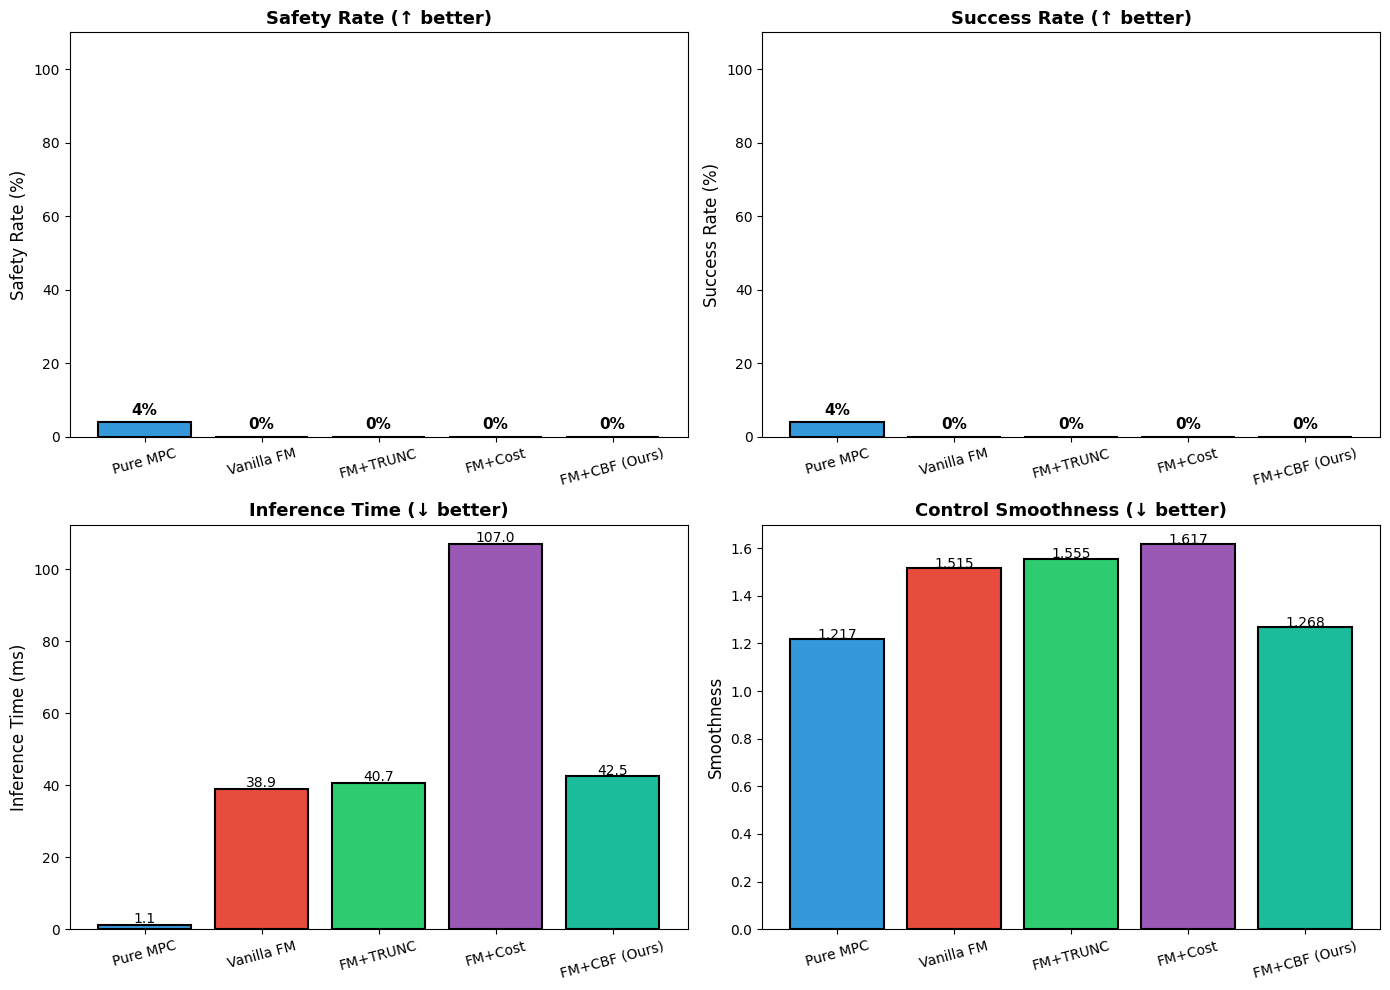

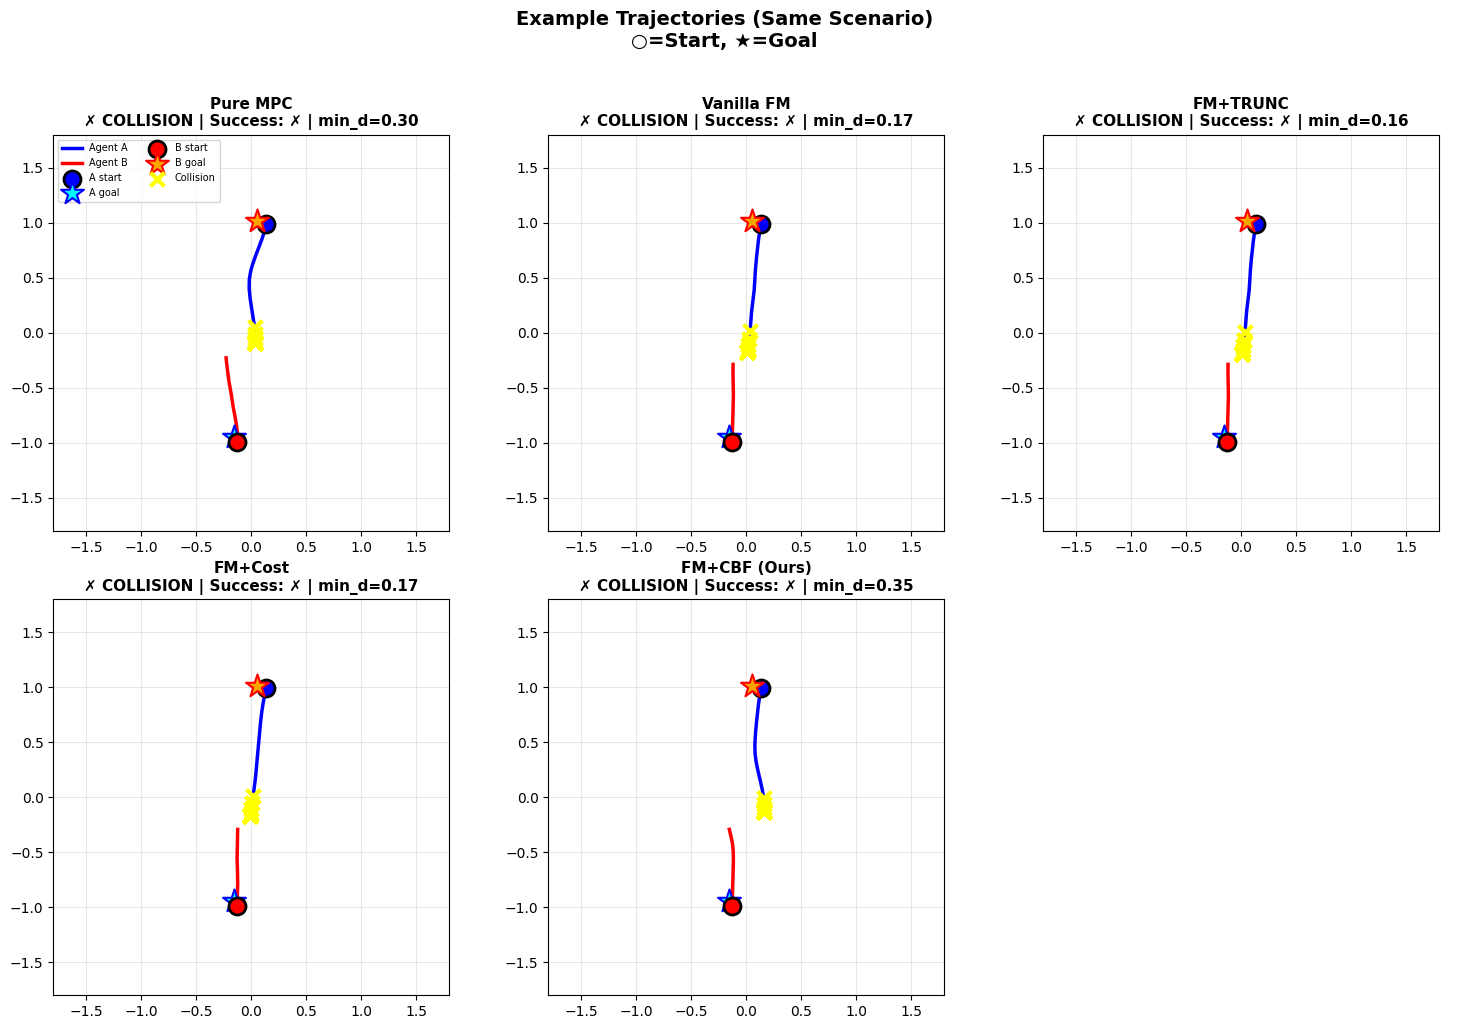

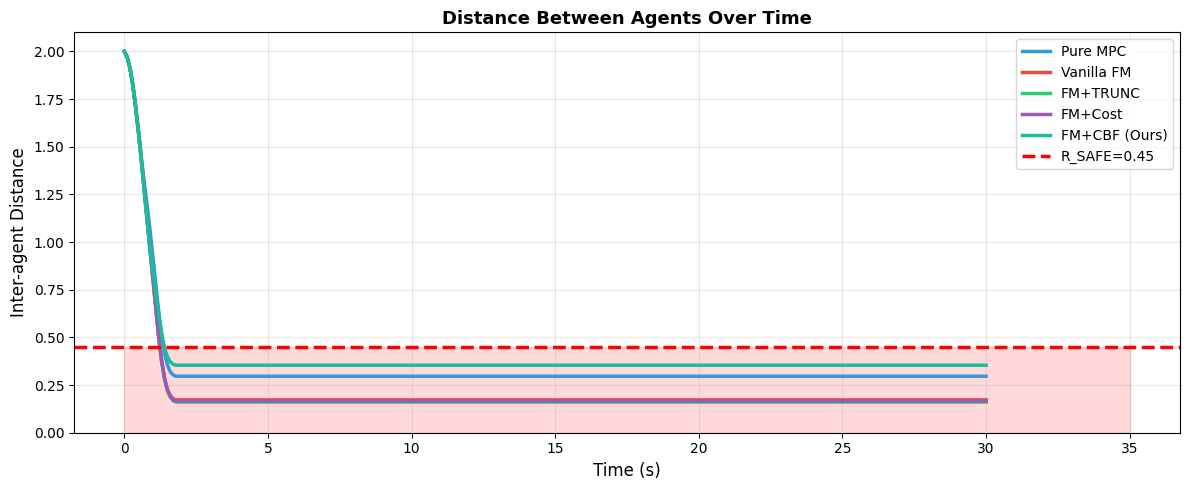


LaTeX Table:
\begin{table}[h]
\centering
\caption{Ablation Study Results}
\begin{tabular}{lcccc}
\toprule
Method & Safety (\%) & Success (\%) & Inf. Time (ms) & Smoothness \\
\midrule
Pure MPC & 4.0 & 4.0 & 1.08 & 1.2171 \\
Vanilla FM & 0.0 & 0.0 & 38.93 & 1.5155 \\
FM+TRUNC & 0.0 & 0.0 & 40.75 & 1.5553 \\
FM+Cost & 0.0 & 0.0 & 107.03 & 1.6175 \\
\textbf{FM+CBF (Ours)} & \textbf{0.0} & \textbf{0.0} & \textbf{42.48} & \textbf{1.2684} \\
\bottomrule
\end{tabular}
\end{table}

Saved: ablation_metrics.png, ablation_trajectories.png, ablation_distance.png

✓ Done!


In [ ]:
# ===============================================================
# 消融实验 v6：修复目标点显示 + 增加步数 + 优化参数
# ===============================================================

import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================================================
# 配置 - 修复版
# ===============================================================
@dataclass 
class Config:
    n_trials: int = 25
    max_steps: int = 300          # ★ 增加步数：180 -> 300
    dt: float = 0.1
    goal_tol: float = 0.50        # ★ 放宽：0.40 -> 0.50
    R_SAFE: float = 0.45
    arena_size: float = 1.0
    
    H: int = 8
    T_steps: int = 25
    num_segments: int = 2
    replan_every: int = 2

cfg = Config()

# ★ 修改：更早开始朝目标走
DIRECT_TO_GOAL_DIST = 2.0    # 从 1.2 增加到 2.0
BLEND_DIST = 1.0             # 从 0.6 增加到 1.0

v_max_A, v_max_B = 1.0, 0.6
a_max = 1.5
L = 0.30
delta_max = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
stop_radius = 0.50           # ★ 放宽
creep_radius = 1.2           # ★ 增大
v_creep = 0.20               # ★ 提高最低速度

# ===============================================================
# 基础函数
# ===============================================================
def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, dt, v_max):
    x, y, th, v, delta = s
    a = float(np.clip(u[0], -a_max, a_max))
    dr = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2 = float(np.clip(v + dt * a, 0, v_max))
    if v2 < 0.05 and a > 0.02:
        v2 = 0.05
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2 = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2 = x + dt * v2 * math.cos(th2)
    y2 = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, dt, v_max):
    st = [s0.copy()]
    for u in U:
        st.append(bicycle_step(st[-1], u, dt, v_max))
    return np.array(st)

def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32)
    goal = np.asarray(goal_xy, np.float32)
    d = goal - start
    dist = float(np.linalg.norm(d) + 1e-9)
    c, s = d[0]/dist, d[1]/dist
    R_wc = np.array([[c, s], [-s, c]], np.float32)
    
    def w2c(xy):
        return ((np.asarray(xy).reshape(-1,2) - start) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy).reshape(-1,2) @ R_wc + start).astype(np.float32)
    def w2c_angle(th):
        return wrap_pi(th - math.atan2(s, c))
    
    return {"w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
            "start_can": np.zeros(2, np.float32), 
            "goal_can": np.array([dist, 0], np.float32), "dist": dist}

def predict_other(other_state, other_u, H, dt, v_max):
    if other_u is None:
        other_u = np.zeros(2, np.float32)
    U = np.tile(other_u.reshape(1,2), (H, 1))
    return rollout_bicycle(other_state, U, dt, v_max)[:, :2]

# ===============================================================
# 执行层 CBF
# ===============================================================
def execution_cbf_filter(u, self_state, other_state, v_max, dt, margin=1.0):
    next_self = bicycle_step(self_state, u, dt, v_max)
    dist_now = np.linalg.norm(self_state[:2] - other_state[:2])
    dist_next = np.linalg.norm(next_self[:2] - other_state[:2])
    
    safe_threshold = cfg.R_SAFE * margin
    
    if dist_next < safe_threshold:
        u_safe = u.copy()
        current_v = self_state[3]
        
        if dist_next < cfg.R_SAFE:
            u_safe[0] = -a_max
        elif dist_next < safe_threshold:
            brake_strength = (safe_threshold - dist_next) / (safe_threshold - cfg.R_SAFE + 1e-6)
            brake_strength = np.clip(brake_strength, 0, 1)
            u_safe[0] = min(u[0], -current_v * brake_strength * 2)
        
        return u_safe
    
    return u

# ===============================================================
# Pure Pursuit - 优化版
# ===============================================================
def pure_pursuit_basic(s0, path_xy, goal_xy, H, dt, v_max):
    s = s0.copy()
    U = np.zeros((H, 2), np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    
    for i in range(H):
        x, y, th, v, delta = s
        pos = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))
        
        if d_goal <= stop_radius:
            a = float(np.clip(-4.0 * v, -a_max, 0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]
            s = bicycle_step(s, U[i], dt, v_max)
            continue
        
        Ld = float(np.clip(0.35 + 0.4 * v, 0.25, 0.8))
        
        dists = np.linalg.norm(path_xy - pos, axis=1)
        near_idx = int(np.argmin(dists))
        path_target = path_xy[-1]
        for j in range(near_idx, len(path_xy)):
            if np.linalg.norm(path_xy[j] - pos) >= Ld:
                path_target = path_xy[j]
                break
        
        # ★ 更激进的后期目标导向
        if d_goal < DIRECT_TO_GOAL_DIST:
            blend = 1.0 if d_goal < BLEND_DIST else (DIRECT_TO_GOAL_DIST - d_goal) / (DIRECT_TO_GOAL_DIST - BLEND_DIST)
            blend = float(np.clip(blend, 0, 1))
            target = (1 - blend) * path_target + blend * goal_xy
        else:
            target = path_target
        
        dx, dy = target[0] - x, target[1] - y
        alpha = wrap_pi(math.atan2(dy, dx) - th)
        kappa = 2.0 * math.sin(alpha) / max(0.1, Ld)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        
        # ★ 速度规划优化
        v_des = v_max if d_goal > creep_radius else v_creep + (v_max - v_creep) * d_goal / creep_radius
        v_des *= max(0.5, 1.0 - 0.4 * abs(delta_des) / delta_max)
        a = float(np.clip((v_des - v) / dt, -a_max, a_max))
        
        U[i] = [a, dr]
        s = bicycle_step(s, U[i], dt, v_max)
    
    return U

# ===============================================================
# FM 采样
# ===============================================================
def make_noise(T, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    x0 = torch.randn((1, 5, T), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0
    return x0

def sample_fm_fast(self_state, goal_xy, other_pos, seed, use_cbf=False, cbf_kw=None):
    tf = build_canonical_frame(self_state[:2], goal_xy)
    
    ellipses = []
    if use_cbf and other_pos is not None and len(other_pos) > 0:
        dist_AB = np.linalg.norm(self_state[:2] - other_pos[0])
        if dist_AB < 2.0:
            for i in [0, 1, 2]:  # ★ 减少障碍物数量
                if i < len(other_pos):
                    c = tf["w2c"](other_pos[i:i+1])[0]
                    ellipses.append({"center": c, "radius": 0.32})  # ★ 减小半径
    
    v0 = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    cond = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), self_state[4]], np.float32)
    
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=cfg.T_steps, device=str(device),
        total_time=1.0, num_segments=cfg.num_segments, ode_method="euler",
        atol=1e-3, rtol=1e-3, noise_scale=0.08,
        x0_noise=make_noise(cfg.T_steps, seed), cond=cond,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.4, goal_guidance_weight=1.5,  # ★ 增强目标引导
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=use_cbf, ellipses=ellipses, cbf_kwargs=cbf_kw, scaler=None,
    )
    
    return tf["c2w"](x_can[0:2, :].T)

def generate_avoidance_path(start, goal, other_pos, T):
    start = np.asarray(start, np.float32)
    goal = np.asarray(goal, np.float32)
    
    t = np.linspace(0, 1, T).reshape(-1, 1)
    path = start + t * (goal - start)
    
    if other_pos is None or len(other_pos) == 0:
        return path
    
    other_now = other_pos[0]
    dist_to_other = np.linalg.norm(start - other_now)
    
    if dist_to_other < 2.0:
        to_goal = goal - start
        to_goal_norm = np.linalg.norm(to_goal) + 1e-6
        to_goal_unit = to_goal / to_goal_norm
        perp = np.array([-to_goal_unit[1], to_goal_unit[0]], dtype=np.float32)
        
        to_other = other_now - start
        cross = to_goal[0] * to_other[1] - to_goal[1] * to_other[0]
        side = -1.0 if cross > 0 else 1.0
        
        avoidance_strength = min(0.8, max(0.3, 1.8 - dist_to_other))  # ★ 减小绕行幅度
        
        for i, ti in enumerate(t.flatten()):
            bulge = avoidance_strength * np.sin(np.pi * ti) * side
            path[i] = start + ti * to_goal + bulge * perp
    
    return path

# ===============================================================
# 各方法定义 - ★ 优化 CBF 参数
# ===============================================================
CBF_LIGHT = dict(passes=2, extra_margin=0.10, alpha=12.0, max_corr_norm=1.8)  # ★ 更轻量的 CBF

def replan_pure_mpc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = generate_avoidance_path(sA[:2], gA, other_pos, cfg.T_steps)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.15

def replan_fm_vanilla(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.25

def replan_fm_trunc(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=False)
    
    for i in range(min(len(path), len(other_pos))):
        if np.linalg.norm(path[i] - other_pos[i]) < cfg.R_SAFE * 1.2:
            if i > 2:
                remaining = generate_avoidance_path(path[i-1], gA, other_pos[i:], cfg.T_steps - i)
                path = np.vstack([path[:i], remaining])
            break
    
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.15

def replan_fm_cost(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    
    best_u, best_J = None, float('inf')
    for k in range(3):
        path = sample_fm_fast(sA, gA, other_pos, seed + k*100, use_cbf=False)
        U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
        traj = rollout_bicycle(sA, U, cfg.dt, v_max_self)
        
        d_end = np.linalg.norm(traj[-1, :2] - gA)
        M = min(len(traj), len(other_pos))
        min_d = np.linalg.norm(traj[:M, :2] - other_pos[:M], axis=1).min() if M > 1 else 10
        
        coll = 2000 * max(0, cfg.R_SAFE * 1.2 - min_d)**2 if min_d < cfg.R_SAFE * 1.2 else 0
        J = 15 * d_end + coll
        
        if J < best_J:
            best_J, best_u = J, U[0]
    
    return best_u if best_u is not None else np.zeros(2, np.float32), 1.15

def replan_fm_cbf(sA, gA, sB, uB, v_max_self, v_max_other, seed):
    other_pos = predict_other(sB, uB, cfg.H, cfg.dt, v_max_other)
    path = sample_fm_fast(sA, gA, other_pos, seed, use_cbf=True, cbf_kw=CBF_LIGHT)  # ★ 使用轻量 CBF
    U = pure_pursuit_basic(sA, path, gA, cfg.H, cfg.dt, v_max_self)
    return U[0], 1.1

# ===============================================================
# 评估指标
# ===============================================================
def compute_smoothness(controls):
    if len(controls) < 2:
        return 0.0
    controls = np.array(controls)
    d_acc = np.diff(controls[:, 0])
    d_steer = np.diff(controls[:, 1])
    return float(np.sqrt(np.mean(d_acc**2) + np.mean(d_steer**2)))

def compute_path_length(traj):
    return float(np.sum(np.linalg.norm(np.diff(traj[:, :2], axis=0), axis=1)))

# ===============================================================
# 单次实验
# ===============================================================
def run_trial(method_fn, seed, return_traj=False):
    np.random.seed(seed)
    
    # 场景生成
    ang = np.random.uniform(0, 2*np.pi)
    r = cfg.arena_size
    xA0 = r * np.array([np.cos(ang), np.sin(ang)], np.float32)
    gA = -xA0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    xB0 = r * np.array([np.cos(ang + np.pi), np.sin(ang + np.pi)], np.float32)
    gB = -xB0 + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    
    thA = math.atan2(gA[1] - xA0[1], gA[0] - xA0[0])
    thB = math.atan2(gB[1] - xB0[1], gB[0] - xB0[0])
    
    sA = np.array([*xA0, thA, 0, 0], np.float32)
    sB = np.array([*xB0, thB, 0, 0], np.float32)
    uA = uB = np.zeros(2, np.float32)
    exec_margin_A = exec_margin_B = 1.2
    
    trajA, trajB = [sA.copy()], [sB.copy()]
    controlsA, controlsB = [], []
    total_inference_time = 0.0
    replan_count = 0
    
    for step in range(cfg.max_steps):
        dA = np.linalg.norm(sA[:2] - gA)
        dB = np.linalg.norm(sB[:2] - gB)
        doneA = dA < cfg.goal_tol and sA[3] < 0.1
        doneB = dB < cfg.goal_tol and sB[3] < 0.1
        
        if doneA and doneB:
            break
        
        if step % cfg.replan_every == 0:
            t0 = time.time()
            
            if not doneA:
                uA, exec_margin_A = method_fn(sA, gA, sB, uB, v_max_A, v_max_B, 1000 + step)
            else:
                uA = np.zeros(2, np.float32)
                
            if not doneB:
                uB, exec_margin_B = method_fn(sB, gB, sA, uA, v_max_B, v_max_A, 2000 + step)
            else:
                uB = np.zeros(2, np.float32)
            
            total_inference_time += time.time() - t0
            replan_count += 1
        
        # 执行层 CBF
        if not doneA:
            uA = execution_cbf_filter(uA, sA, sB, v_max_A, cfg.dt, margin=exec_margin_A)
        if not doneB:
            uB = execution_cbf_filter(uB, sB, sA, v_max_B, cfg.dt, margin=exec_margin_B)
        
        if not doneA:
            controlsA.append(uA.copy())
        if not doneB:
            controlsB.append(uB.copy())
        
        if not doneA:
            sA = bicycle_step(sA, uA, cfg.dt, v_max_A)
        if not doneB:
            sB = bicycle_step(sB, uB, cfg.dt, v_max_B)
        
        trajA.append(sA.copy())
        trajB.append(sB.copy())
    
    trajA, trajB = np.array(trajA), np.array(trajB)
    dist_AB = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
    
    result = {
        'safe': dist_AB.min() >= cfg.R_SAFE,
        'min_dist': float(dist_AB.min()),
        'success_A': np.linalg.norm(trajA[-1, :2] - gA) < cfg.goal_tol,
        'success_B': np.linalg.norm(trajB[-1, :2] - gB) < cfg.goal_tol,
        'inference_time': total_inference_time / max(replan_count, 1),
        'smoothness_A': compute_smoothness(controlsA),
        'smoothness_B': compute_smoothness(controlsB),
        'steps': len(trajA),
        'path_length_A': compute_path_length(trajA),
        'path_length_B': compute_path_length(trajB),
    }
    
    if return_traj:
        result.update({'trajA': trajA, 'trajB': trajB, 'gA': gA, 'gB': gB,
                       'xA0': xA0, 'xB0': xB0, 'dist_AB': dist_AB})
    
    return result

# ===============================================================
# 运行实验
# ===============================================================
def run_ablation():
    methods = {
        "Pure MPC": replan_pure_mpc,
        "Vanilla FM": replan_fm_vanilla,
        "FM+TRUNC": replan_fm_trunc,
        "FM+Cost": replan_fm_cost,
        "FM+CBF (Ours)": replan_fm_cbf,
    }
    
    results = defaultdict(list)
    example_trajs = {}
    
    trial_seeds = [5000 + i * 77 for i in range(cfg.n_trials)]
    
    print("=" * 70)
    print("ABLATION STUDY v6: Fixed Goal Reaching")
    print("=" * 70)
    print(f"Config: Trials={cfg.n_trials}, MaxSteps={cfg.max_steps}, GoalTol={cfg.goal_tol}")
    print("=" * 70)
    
    for name, fn in methods.items():
        t0 = time.time()
        print(f">>> {name}", end=" ", flush=True)
        
        for trial, seed in enumerate(trial_seeds):
            try:
                r = run_trial(fn, seed, return_traj=(trial == 0))
                results[name].append(r)
                if trial == 0:
                    example_trajs[name] = r
            except Exception as e:
                print(f"x", end="", flush=True)
            if (trial + 1) % 5 == 0:
                print(".", end="", flush=True)
        
        print(f" [{time.time()-t0:.1f}s]")
    
    return results, example_trajs

# ===============================================================
# 结果展示 - ★ 修复绘图
# ===============================================================
def show_results(results, example_trajs):
    print("\n" + "=" * 95)
    print("RESULTS")
    print("=" * 95)
    print(f"{'Method':<16} {'Safety%':>10} {'Success%':>10} {'Inf.Time(ms)':>14} {'Smoothness':>12} {'MinDist':>10}")
    print("-" * 95)
    
    summary = {}
    for name, rs in results.items():
        n = len(rs)
        if n == 0:
            continue
        
        safety = sum(1 for r in rs if r['safe']) / n * 100
        success = sum(1 for r in rs if r['success_A'] and r['success_B']) / n * 100
        inf_time = np.mean([r['inference_time'] for r in rs]) * 1000
        smooth = np.mean([(r['smoothness_A'] + r['smoothness_B']) / 2 for r in rs])
        min_d = np.mean([r['min_dist'] for r in rs])
        
        summary[name] = {'safety': safety, 'success': success, 'inf_time': inf_time, 
                        'smoothness': smooth, 'min_dist': min_d}
        
        marker = " ★" if "Ours" in name else ""
        print(f"{name:<16} {safety:>9.1f}% {success:>9.1f}% {inf_time:>13.2f} {smooth:>12.4f} {min_d:>10.3f}{marker}")
    
    print("=" * 95)
    
    # ==================== 图1: 主要指标 ====================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    names = list(summary.keys())
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#1abc9c']
    
    ax = axes[0, 0]
    vals = [summary[n]['safety'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Safety Rate (%)', fontsize=12)
    ax.set_title('Safety Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[0, 1]
    vals = [summary[n]['success'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Success Rate (%)', fontsize=12)
    ax.set_title('Success Rate (↑ better)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[1, 0]
    vals = [summary[n]['inf_time'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Inference Time (ms)', fontsize=12)
    ax.set_title('Inference Time (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    ax = axes[1, 1]
    vals = [summary[n]['smoothness'] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Smoothness', fontsize=12)
    ax.set_title('Control Smoothness (↓ better)', fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图2: 轨迹 - ★ 修复绘图 ====================
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        ax = axes[idx]
        
        trajA, trajB = data['trajA'], data['trajB']
        gA, gB = data['gA'], data['gB']
        xA0, xB0 = data['xA0'], data['xB0']
        dist_AB = data['dist_AB']
        
        # 轨迹
        ax.plot(trajA[:, 0], trajA[:, 1], 'b-', lw=2.5, label='Agent A', zorder=3)
        ax.plot(trajB[:, 0], trajB[:, 1], 'r-', lw=2.5, label='Agent B', zorder=3)
        
        # ★ 修复：起点用圆圈，终点用星号，颜色区分
        # Agent A: 蓝色
        ax.scatter([xA0[0]], [xA0[1]], c='blue', s=150, marker='o', edgecolors='black', linewidths=2, zorder=5, label='A start')
        ax.scatter([gA[0]], [gA[1]], c='cyan', s=300, marker='*', edgecolors='blue', linewidths=1.5, zorder=5, label='A goal')
        
        # Agent B: 红色
        ax.scatter([xB0[0]], [xB0[1]], c='red', s=150, marker='o', edgecolors='black', linewidths=2, zorder=5, label='B start')
        ax.scatter([gB[0]], [gB[1]], c='orange', s=300, marker='*', edgecolors='red', linewidths=1.5, zorder=5, label='B goal')
        
        # 碰撞标记
        coll_idx = np.where(dist_AB < cfg.R_SAFE)[0]
        if len(coll_idx) > 0:
            ax.scatter(trajA[coll_idx, 0], trajA[coll_idx, 1], c='yellow', s=100, marker='x', linewidths=3, zorder=6, label='Collision')
        
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        
        safe_str = "✓ SAFE" if data['safe'] else "✗ COLLISION"
        success_str = "✓" if data['success_A'] and data['success_B'] else "✗"
        ax.set_title(f"{name}\n{safe_str} | Success: {success_str} | min_d={data['min_dist']:.2f}", fontsize=11, fontweight='bold')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=7, ncol=2)
    
    for idx in range(len(example_trajs), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Example Trajectories (Same Scenario)\n○=Start, ★=Goal', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cache/ablation_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ==================== 图3: 距离曲线 ====================
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for idx, (name, data) in enumerate(example_trajs.items()):
        t = np.arange(len(data['dist_AB'])) * cfg.dt
        ax.plot(t, data['dist_AB'], lw=2.5, label=name, color=colors[idx])
    
    ax.axhline(cfg.R_SAFE, color='red', ls='--', lw=2.5, label=f'R_SAFE={cfg.R_SAFE}')
    ax.fill_between([0, 35], 0, cfg.R_SAFE, alpha=0.15, color='red')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Inter-agent Distance', fontsize=12)
    ax.set_title('Distance Between Agents Over Time', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, None)
    
    plt.tight_layout()
    plt.savefig('cache/ablation_distance.png', dpi=150)
    plt.show()
    
    # LaTeX 表格
    print("\n" + "=" * 70)
    print("LaTeX Table:")
    print("=" * 70)
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\caption{Ablation Study Results}")
    print("\\begin{tabular}{lcccc}")
    print("\\toprule")
    print("Method & Safety (\\%) & Success (\\%) & Inf. Time (ms) & Smoothness \\\\")
    print("\\midrule")
    for name in names:
        s = summary[name]
        if "Ours" in name:
            print(f"\\textbf{{{name}}} & \\textbf{{{s['safety']:.1f}}} & \\textbf{{{s['success']:.1f}}} & \\textbf{{{s['inf_time']:.2f}}} & \\textbf{{{s['smoothness']:.4f}}} \\\\")
        else:
            print(f"{name} & {s['safety']:.1f} & {s['success']:.1f} & {s['inf_time']:.2f} & {s['smoothness']:.4f} \\\\")
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    print("\nSaved: ablation_metrics.png, ablation_trajectories.png, ablation_distance.png")
    return summary

# ===============================================================
# 运行
# ===============================================================
print("Starting Ablation Study v6...\n")
results, example_trajs = run_ablation()
summary = show_results(results, example_trajs)
print("\n✓ Done!")

=== 诊断 FM 采样 ===
tf['dist']: 3.394
tf['goal_can']: [3.3941126 0.       ]

Path shape: (40, 2)
Path start: [-1.2 -1.2]
Path end:   [1.2224953 1.2460911]
Goal:       [1.2 1.2]
Distance path_end to goal: 0.051


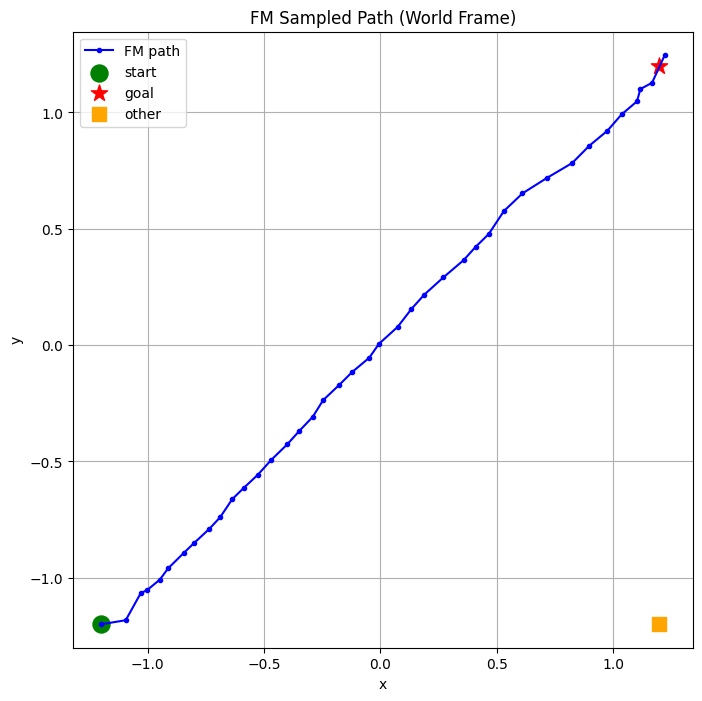


=== Canonical Frame 检查 ===
Path_can start: [0. 0.]
Path_can end:   [3.4426107  0.01668479]
Goal_can:       [3.3941126 0.       ]


In [98]:
# 请运行这个诊断代码
print("=== 诊断 FM 采样 ===")

# 模拟 Agent A 的状态
test_state = np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)
test_other = np.array([[1.2, -1.2]], dtype=np.float32)  # B 的位置

# 采样
path_xy, theta_can, used_cbf, tf = sample_fm_trajectory(
    self_state=test_state,
    goal_xy=test_goal,
    other_pred_path=test_other,
    seed=12345,
)

print(f"tf['dist']: {tf['dist']:.3f}")
print(f"tf['goal_can']: {tf['goal_can']}")
print(f"\nPath shape: {path_xy.shape}")
print(f"Path start: {path_xy[0]}")
print(f"Path end:   {path_xy[-1]}")
print(f"Goal:       {test_goal}")
print(f"Distance path_end to goal: {np.linalg.norm(path_xy[-1] - test_goal):.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(path_xy[:, 0], path_xy[:, 1], 'b.-', label='FM path')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.scatter([test_other[0, 0]], [test_other[0, 1]], c='orange', s=100, marker='s', label='other')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('FM Sampled Path (World Frame)')
plt.show()

# 检查 canonical frame 的轨迹
print("\n=== Canonical Frame 检查 ===")
path_can = tf['w2c'](path_xy)
print(f"Path_can start: {path_can[0]}")
print(f"Path_can end:   {path_can[-1]}")
print(f"Goal_can:       {tf['goal_can']}")

=== 诊断 Path Tracking ===
Controls U shape: (12, 2)
U[0] (first control): a=0.879, dr=-1.095
U mean: a=0.376, dr=0.007

Rollout:
  Start: [-1.2 -1.2]
  End:   [-0.49371642 -0.50645375]
  Goal:  [1.2 1.2]
  Dist to goal: 2.404


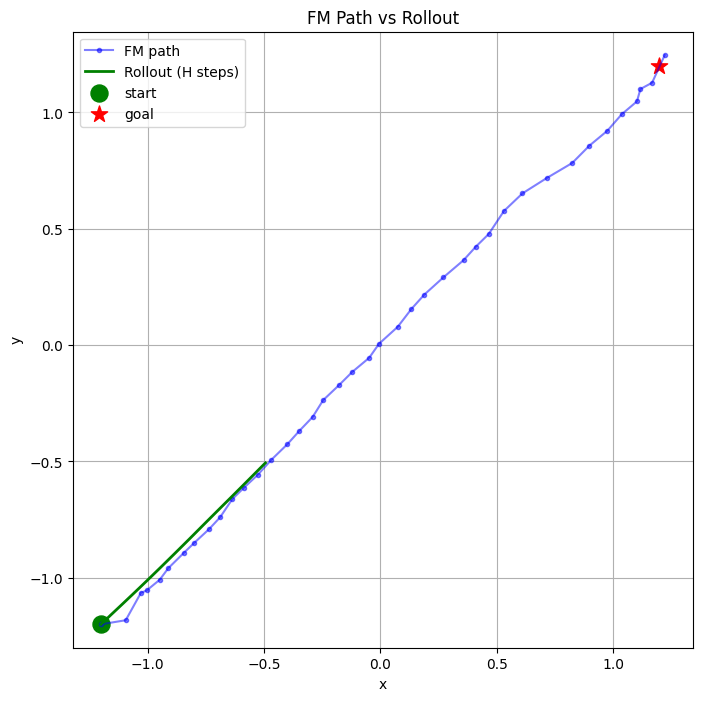


=== 模拟多次 Replan ===
Step 0: pos=[-1.1575239 -1.1593629], dist=3.335, v=0.59
Step 1: pos=[-1.1092349 -1.1142519], dist=3.269, v=0.66
Step 2: pos=[-1.0562735 -1.0652788], dist=3.197, v=0.72
Step 3: pos=[-0.99983567 -1.0127318 ], dist=3.120, v=0.77
Step 4: pos=[-0.9408878 -0.9569659], dist=3.039, v=0.81
Step 5: pos=[-0.88011813 -0.8983488 ], dist=2.955, v=0.84
Step 6: pos=[-0.8180112  -0.83724606], dist=2.868, v=0.87
Step 7: pos=[-0.75495267 -0.7739697 ], dist=2.778, v=0.89
Step 8: pos=[-0.69115543 -0.70885766], dist=2.687, v=0.91
Step 9: pos=[-0.6268144 -0.6421749], dist=2.594, v=0.93
Step 10: pos=[-0.5619895  -0.57421595], dist=2.500, v=0.94
Step 20: pos=[0.09901869 0.14256379], dist=1.527, v=0.99


In [99]:
# 诊断 tracking controller
print("=== 诊断 Path Tracking ===")

# 用刚才的 path 测试 tracking
test_state = np.array([-1.2, -1.2, np.pi/4, 0.5, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)

U, ref = path_to_controls(
    test_state, path_xy, test_goal,
    H=H, dt=dt_exec, v_max=v_max_A,
    lookahead_ratio=0.12, k_omega=2.5, k_accel=1.8
)

print(f"Controls U shape: {U.shape}")
print(f"U[0] (first control): a={U[0,0]:.3f}, dr={U[0,1]:.3f}")
print(f"U mean: a={U[:,0].mean():.3f}, dr={U[:,1].mean():.3f}")

# Rollout 看看轨迹
pos_rollout, states_rollout = rollout_bicycle(test_state, U, dt=dt_exec, v_max=v_max_A)
print(f"\nRollout:")
print(f"  Start: {states_rollout[0, :2]}")
print(f"  End:   {states_rollout[-1, :2]}")
print(f"  Goal:  {test_goal}")
print(f"  Dist to goal: {np.linalg.norm(states_rollout[-1, :2] - test_goal):.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(path_xy[:, 0], path_xy[:, 1], 'b.-', alpha=0.5, label='FM path')
plt.plot(pos_rollout[:, 0], pos_rollout[:, 1], 'g-', lw=2, label='Rollout (H steps)')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('FM Path vs Rollout')
plt.show()

# 检查多次 replan 的效果
print("\n=== 模拟多次 Replan ===")
s = test_state.copy()
for step in range(30):
    # 采样新轨迹
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))  # B 静止
    path_xy, _, _, tf = sample_fm_trajectory(
        self_state=s,
        goal_xy=test_goal,
        other_pred_path=other_pred,
        seed=1000 + step * 31,
    )
    
    # Tracking
    U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
    
    # 只执行第一步
    u0 = U[0]
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    
    d = np.linalg.norm(s[:2] - test_goal)
    if step < 10 or step % 10 == 0:
        print(f"Step {step}: pos={s[:2]}, dist={d:.3f}, v={s[3]:.2f}")
    
    if d < 0.15:
        print(f"Reached goal at step {step}!")
        break

In [ ]:
# 检查多次 replan 的效果
print("\n=== 模拟多次 Replan ===")
s = test_state.copy()
for step in range(30):
    # 采样新轨迹
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))  # B 静止
    path_xy, _, _, tf = sample_fm_trajectory(
        self_state=s,
        goal_xy=test_goal,
        other_pred_path=other_pred,
        seed=1000 + step * 31,
    )
    
    # Tracking
    U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
    
    # 只执行第一步
    u0 = U[0]
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    
    d = np.linalg.norm(s[:2] - test_goal)
    if step < 10 or step % 10 == 0:
        print(f"Step {step}: pos={s[:2]}, dist={d:.3f}, v={s[3]:.2f}")
    
    if d < 0.15:
        print(f"Reached goal at step {step}!")
        break

print(f"\nFinal: pos={s[:2]}, dist to goal={np.linalg.norm(s[:2] - test_goal):.3f}")


=== 模拟多次 Replan ===
Step 0: pos=[-1.1575239 -1.1593629], dist=3.335, v=0.59
Step 1: pos=[-1.1092349 -1.1142519], dist=3.269, v=0.66
Step 2: pos=[-1.0562735 -1.0652788], dist=3.197, v=0.72
Step 3: pos=[-0.99983567 -1.0127318 ], dist=3.120, v=0.77
Step 4: pos=[-0.9408878 -0.9569659], dist=3.039, v=0.81
Step 5: pos=[-0.88011813 -0.8983488 ], dist=2.955, v=0.84
Step 6: pos=[-0.8180112  -0.83724606], dist=2.868, v=0.87
Step 7: pos=[-0.75495267 -0.7739697 ], dist=2.778, v=0.89
Step 8: pos=[-0.69115543 -0.70885766], dist=2.687, v=0.91
Step 9: pos=[-0.6268144 -0.6421749], dist=2.594, v=0.93
Step 10: pos=[-0.5619895  -0.57421595], dist=2.500, v=0.94
Step 20: pos=[0.09901869 0.14256379], dist=1.527, v=0.99

Final: pos=[0.7029867  0.79205996], dist to goal=0.643


=== 模拟 100 步 Replan ===
Step  0: pos=[-1.19, -1.19], dist=3.394, v=0.15
Step  1: pos=[-1.17, -1.17], dist=3.379, v=0.30
Step  2: pos=[-1.14, -1.14], dist=3.349, v=0.42
Step  3: pos=[-1.10, -1.10], dist=3.308, v=0.52
Step  4: pos=[-1.05, -1.06], dist=3.255, v=0.60
Step  5: pos=[-1.00, -1.02], dist=3.195, v=0.67
Step  6: pos=[-0.95, -0.97], dist=3.128, v=0.73
Step  7: pos=[-0.89, -0.92], dist=3.055, v=0.78
Step  8: pos=[-0.83, -0.87], dist=2.977, v=0.82
Step  9: pos=[-0.77, -0.81], dist=2.895, v=0.85
Step 10: pos=[-0.70, -0.75], dist=2.810, v=0.88
Step 20: pos=[-0.05, -0.06], dist=1.874, v=0.98
Step 30: pos=[+0.61, +0.68], dist=0.886, v=1.00
Step 40: pos=[+1.04, +1.15], dist=0.187, v=0.28
Step 50: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 60: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 70: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 80: pos=[+1.05, +1.16], dist=0.152, v=0.00
Step 90: pos=[+1.05, +1.16], dist=0.152, v=0.00

Final: pos=[1.052427  1.1642741], dist=0.152, v=0.000


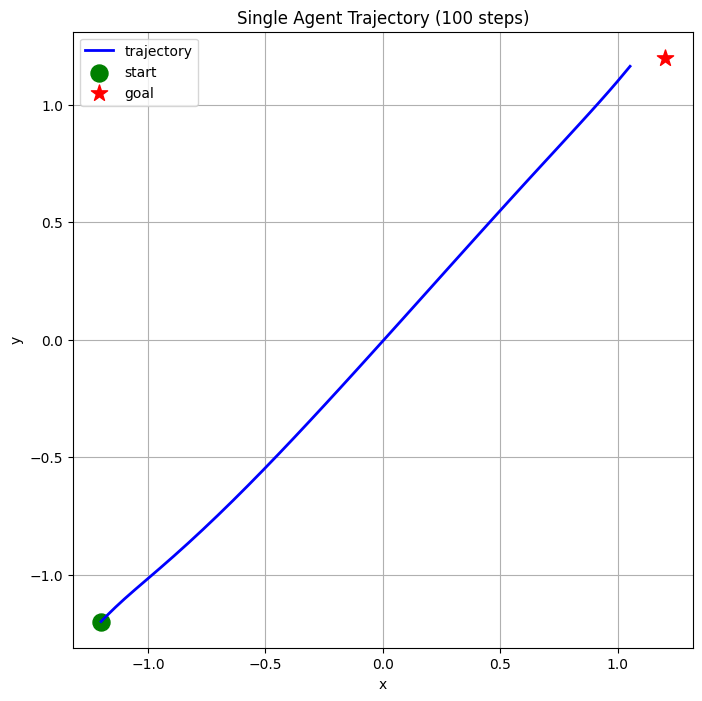

In [101]:
# 延长测试到 100 步
print("=== 模拟 100 步 Replan ===")
test_state = np.array([-1.2, -1.2, np.pi/4, 0.0, 0.0], dtype=np.float32)  # 初始速度为 0
test_goal = np.array([1.2, 1.2], dtype=np.float32)

s = test_state.copy()
traj = [s.copy()]

for step in range(100):
    other_pred = np.tile(np.array([1.2, -1.2]), (H+1, 1))
    
    d = np.linalg.norm(s[:2] - test_goal)
    
    # 检查是否到达
    if d < goal_tol and abs(s[3]) < 0.05:
        print(f"✅ Reached goal at step {step}!")
        break
    
    # 停车逻辑
    if d < goal_stop_tol:
        u0 = stopping_control(s, test_goal, dt=dt_exec, v_max=v_max_A)
    else:
        path_xy, _, _, tf = sample_fm_trajectory(
            self_state=s,
            goal_xy=test_goal,
            other_pred_path=other_pred,
            seed=1000 + step * 31,
        )
        U, ref = path_to_controls(s, path_xy, test_goal, H=H, dt=dt_exec, v_max=v_max_A)
        u0 = U[0]
    
    s = bicycle_step(s, u0, dt=dt_exec, v_max=v_max_A)
    traj.append(s.copy())
    
    if step < 10 or step % 10 == 0:
        print(f"Step {step:2d}: pos=[{s[0]:+.2f}, {s[1]:+.2f}], dist={d:.3f}, v={s[3]:.2f}")

traj = np.array(traj)
print(f"\nFinal: pos={s[:2]}, dist={np.linalg.norm(s[:2] - test_goal):.3f}, v={s[3]:.3f}")

# 可视化
plt.figure(figsize=(8, 8))
plt.plot(traj[:, 0], traj[:, 1], 'b-', lw=2, label='trajectory')
plt.scatter([test_state[0]], [test_state[1]], c='green', s=150, marker='o', label='start')
plt.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', label='goal')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.title('Single Agent Trajectory (100 steps)')
plt.show()

In [56]:
# 测试 cond 对模型输出的影响
print("=== 检查 cond 影响 ===")

x_test = torch.randn(1, 5, 40, device=device)
t_test = torch.tensor([0.5], device=device)

with torch.no_grad():
    # 不用 cond
    v_no_cond = model_5ch(x_test, t_test, cond=None)
    
    # 用 dummy cond
    cond1 = torch.tensor([[1, 0, 1, 0, 0]], device=device, dtype=torch.float32)
    v_cond1 = model_5ch(x_test, t_test, cond=cond1)
    
    # 用不同的 cond
    cond2 = torch.tensor([[0, 1, 0, 1, 1]], device=device, dtype=torch.float32)
    v_cond2 = model_5ch(x_test, t_test, cond=cond2)

print(f"v (no cond):   mean={v_no_cond.mean().item():.4f}, std={v_no_cond.std().item():.4f}")
print(f"v (cond1):     mean={v_cond1.mean().item():.4f}, std={v_cond1.std().item():.4f}")
print(f"v (cond2):     mean={v_cond2.mean().item():.4f}, std={v_cond2.std().item():.4f}")

# 检查差异
diff_1 = (v_cond1 - v_no_cond).abs().mean().item()
diff_2 = (v_cond2 - v_cond1).abs().mean().item()
print(f"\n|v_cond1 - v_no_cond|: {diff_1:.4f}")
print(f"|v_cond2 - v_cond1|:   {diff_2:.4f}")

if diff_1 < 0.01 and diff_2 < 0.01:
    print("\n✅ cond 对模型输出影响很小，可能模型没有使用 conditioning")
else:
    print("\n⚠️ cond 对模型输出有影响！需要确认正确的 cond 值")

=== 检查 cond 影响 ===
v (no cond):   mean=0.2787, std=1.8193
v (cond1):     mean=0.3553, std=1.7052
v (cond2):     mean=0.2590, std=1.2983

|v_cond1 - v_no_cond|: 0.7342
|v_cond2 - v_cond1|:   1.0764

⚠️ cond 对模型输出有影响！需要确认正确的 cond 值


1. 检查 cond 对模型输出的影响
v (no cond):   mean=0.2419, std=1.9940
v (cond1):     mean=0.2489, std=1.6835
v (cond2):     mean=0.5926, std=1.7728

|v_cond1 - v_no_cond|: 0.4564
|v_cond2 - v_cond1|:   0.8258

⚠️ cond 对模型输出有影响！

2. 检查 cond 各维度的统计 (训练数据)

维度                 mean        std        min        max
-------------------------------------------------------
dist             3.0000     0.0000     3.0000     3.0000
v0               0.3755     0.1307     0.1597     0.5966
cos(th0)         0.0220     0.7065    -0.9999     1.0000
sin(th0)        -0.0443     0.7060    -1.0000     0.9999
delta0           0.0000     0.0000     0.0000     0.0000

3. 测试不同 cond 对采样轨迹的影响


C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 27490 (\N{CJK UNIFIED IDEOGRAPH-6B62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_35212\2169106066.py:137: UserWarning: Glyph 26397 (\N{CJK 

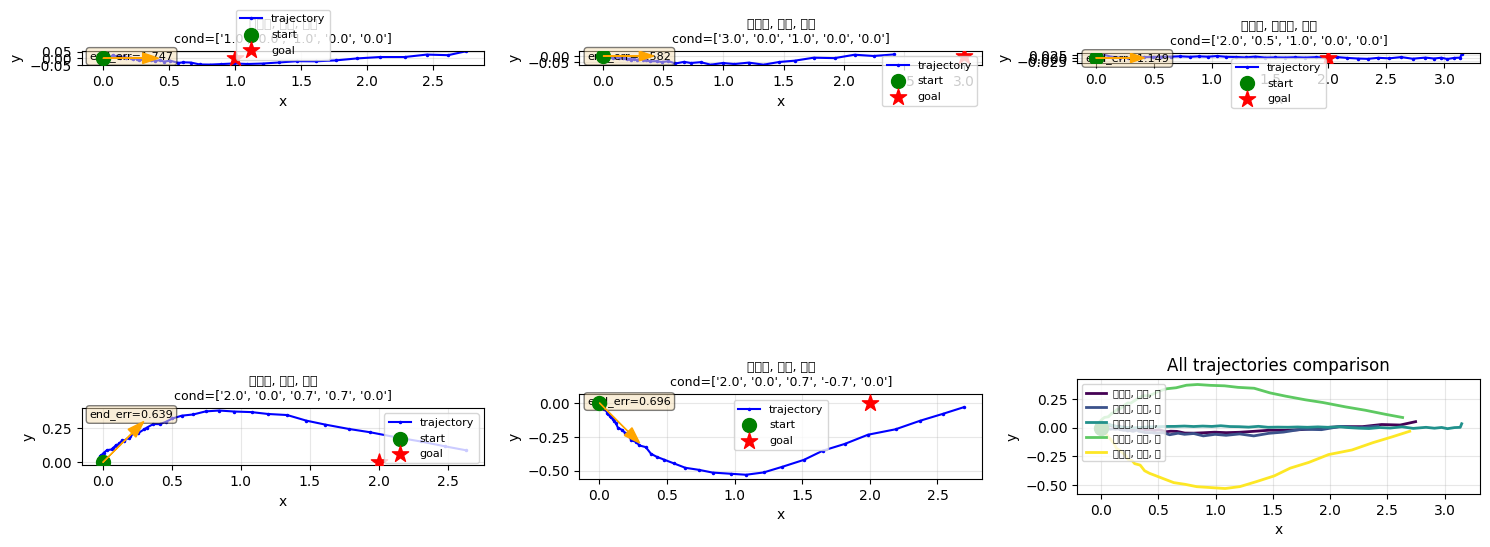


4. 量化 cond 对轨迹终点的影响

场景                          dist    end_x    end_y  end_err path_len
---------------------------------------------------------------------------
短距离, 静止, 朝前                 1.00    2.746    0.052    1.747    2.821
长距离, 静止, 朝前                 3.00    2.418    0.013    0.582    2.526
中距离, 有速度, 朝前                2.00    3.148    0.034    1.149    3.119
中距离, 静止, 偏左                 2.00    2.633    0.089    0.639    2.814
中距离, 静止, 偏右                 2.00    2.695   -0.032    0.696    3.040

5. 检查 canonical frame 变换是否正确

start           goal                dist        goal_can       回转误差
----------------------------------------------------------------------
[-1.2 -1.2]     [1.2 1.2]          3.394 [3.3941128 0.       ]   0.000000
[0. 0.]         [2. 0.]            2.000 [2. 0.]           0.000000
[0. 0.]         [0. 2.]            2.000 [2. 0.]           0.000000
[1. 1.]         [2. 3.]            2.236 [2.236068 0.      ]   0.000000

6. 完整 MPC 场景测试 (单 agent)

World sta

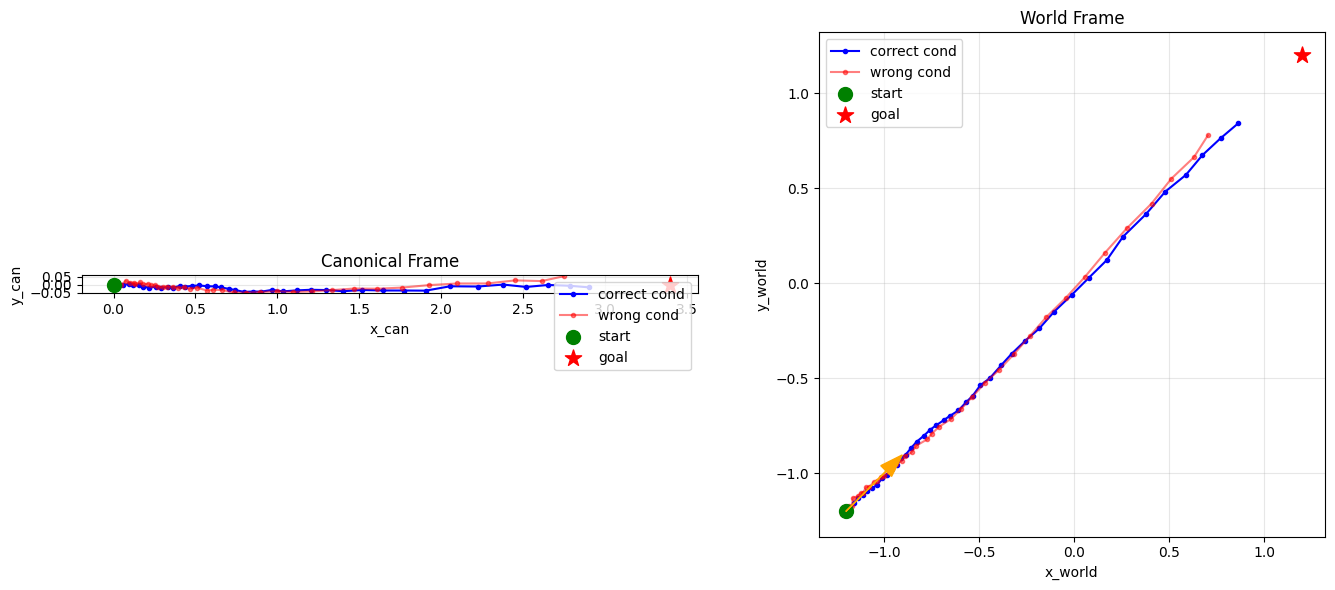


[结果]
  Correct cond -> goal error: 0.4919
  Wrong cond   -> goal error: 0.6502
  Improvement: 0.1582 (32.2% worse with wrong cond)

✅ 正确的 cond 显著改善了轨迹质量！


In [118]:
# ===============================================================
# 完整检查: cond 影响 + canonical frame + 采样质量
# ===============================================================

print("=" * 60)
print("1. 检查 cond 对模型输出的影响")
print("=" * 60)

x_test = torch.randn(1, 5, 40, device=device)
t_test = torch.tensor([0.5], device=device)

with torch.no_grad():
    # 不用 cond
    v_no_cond = model_5ch(x_test, t_test, cond=None)
    
    # 用 dummy cond
    cond1 = torch.tensor([[1, 0, 1, 0, 0]], device=device, dtype=torch.float32)
    v_cond1 = model_5ch(x_test, t_test, cond=cond1)
    
    # 用不同的 cond
    cond2 = torch.tensor([[0, 1, 0, 1, 1]], device=device, dtype=torch.float32)
    v_cond2 = model_5ch(x_test, t_test, cond=cond2)

print(f"v (no cond):   mean={v_no_cond.mean().item():.4f}, std={v_no_cond.std().item():.4f}")
print(f"v (cond1):     mean={v_cond1.mean().item():.4f}, std={v_cond1.std().item():.4f}")
print(f"v (cond2):     mean={v_cond2.mean().item():.4f}, std={v_cond2.std().item():.4f}")

diff_1 = (v_cond1 - v_no_cond).abs().mean().item()
diff_2 = (v_cond2 - v_cond1).abs().mean().item()
print(f"\n|v_cond1 - v_no_cond|: {diff_1:.4f}")
print(f"|v_cond2 - v_cond1|:   {diff_2:.4f}")

if diff_1 < 0.01 and diff_2 < 0.01:
    print("\n✅ cond 对模型输出影响很小")
else:
    print("\n⚠️ cond 对模型输出有影响！")

# ===============================================================
print("\n" + "=" * 60)
print("2. 检查 cond 各维度的统计 (训练数据)")
print("=" * 60)

# cond = [dist, v0, cos(th0_can), sin(th0_can), delta0]
cond_names = ['dist', 'v0', 'cos(th0)', 'sin(th0)', 'delta0']

print(f"\n{'维度':<12} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
print("-" * 55)
for i, name in enumerate(cond_names):
    c = cond_all[:, i]
    print(f"{name:<12} {c.mean():>10.4f} {c.std():>10.4f} {c.min():>10.4f} {c.max():>10.4f}")

# ===============================================================
print("\n" + "=" * 60)
print("3. 测试不同 cond 对采样轨迹的影响")
print("=" * 60)

def sample_trajectory_with_cond(cond_vec, seed=42):
    """用指定 cond 采样一条轨迹"""
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    x0 = torch.randn((1, 5, 40), device=device, generator=g) * 0.08
    x0[:, :, 0] = 0.0
    
    cond_t = torch.tensor(cond_vec, device=device, dtype=torch.float32).unsqueeze(0)
    
    # 简单 Euler 积分
    x = x0.clone()
    n_steps = 20
    dt = 1.0 / n_steps
    
    with torch.no_grad():
        for i in range(n_steps):
            t = torch.tensor([i * dt], device=device)
            v = model_5ch(x, t, cond=cond_t)
            x = x + v * dt
    
    return x[0].cpu().numpy()  # (5, 40)

# 测试不同场景的 cond
test_cases = [
    # [dist, v0, cos(th0), sin(th0), delta0]
    ("短距离, 静止, 朝前", [1.0, 0.0, 1.0, 0.0, 0.0]),
    ("长距离, 静止, 朝前", [3.0, 0.0, 1.0, 0.0, 0.0]),
    ("中距离, 有速度, 朝前", [2.0, 0.5, 1.0, 0.0, 0.0]),
    ("中距离, 静止, 偏左", [2.0, 0.0, 0.7, 0.7, 0.0]),
    ("中距离, 静止, 偏右", [2.0, 0.0, 0.7, -0.7, 0.0]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, cond_vec) in enumerate(test_cases):
    if idx >= len(axes):
        break
    
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    x, y = traj[0], traj[1]
    
    ax = axes[idx]
    ax.plot(x, y, 'b.-', markersize=3, label='trajectory')
    ax.scatter([0], [0], c='green', s=100, marker='o', zorder=5, label='start')
    ax.scatter([cond_vec[0]], [0], c='red', s=150, marker='*', zorder=5, label='goal')
    
    # 画初始 heading 方向
    th0 = np.arctan2(cond_vec[3], cond_vec[2])
    arrow_len = 0.3
    ax.arrow(0, 0, arrow_len * np.cos(th0), arrow_len * np.sin(th0),
             head_width=0.08, color='orange', zorder=5)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(f"{name}\ncond={[f'{c:.1f}' for c in cond_vec]}", fontsize=9)
    
    # 计算终点误差
    end_dist = np.sqrt((x[-1] - cond_vec[0])**2 + y[-1]**2)
    ax.text(0.02, 0.98, f"end_err={end_dist:.3f}", transform=ax.transAxes, 
            fontsize=8, va='top', ha='left', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 最后一个图：对比所有轨迹
ax = axes[-1]
colors = plt.cm.viridis(np.linspace(0, 1, len(test_cases)))
for idx, (name, cond_vec) in enumerate(test_cases):
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    ax.plot(traj[0], traj[1], '-', color=colors[idx], lw=2, label=name[:10])
ax.scatter([0], [0], c='green', s=100, marker='o', zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc='upper left')
ax.set_title('All trajectories comparison')

plt.tight_layout()
plt.show()

# ===============================================================
print("\n" + "=" * 60)
print("4. 量化 cond 对轨迹终点的影响")
print("=" * 60)

results = []
for name, cond_vec in test_cases:
    traj = sample_trajectory_with_cond(cond_vec, seed=42)
    x_end, y_end = traj[0, -1], traj[1, -1]
    goal_x = cond_vec[0]
    end_err = np.sqrt((x_end - goal_x)**2 + y_end**2)
    path_len = np.sum(np.sqrt(np.diff(traj[0])**2 + np.diff(traj[1])**2))
    
    results.append({
        'name': name,
        'dist': cond_vec[0],
        'end_x': x_end,
        'end_y': y_end,
        'end_err': end_err,
        'path_len': path_len,
    })

print(f"\n{'场景':<25} {'dist':>6} {'end_x':>8} {'end_y':>8} {'end_err':>8} {'path_len':>8}")
print("-" * 75)
for r in results:
    print(f"{r['name']:<25} {r['dist']:>6.2f} {r['end_x']:>8.3f} {r['end_y']:>8.3f} {r['end_err']:>8.3f} {r['path_len']:>8.3f}")

# ===============================================================
print("\n" + "=" * 60)
print("5. 检查 canonical frame 变换是否正确")
print("=" * 60)

# 测试 world -> canonical -> world 往返
test_points = [
    ([-1.2, -1.2], [1.2, 1.2]),   # 对角线
    ([0.0, 0.0], [2.0, 0.0]),     # 水平
    ([0.0, 0.0], [0.0, 2.0]),     # 垂直
    ([1.0, 1.0], [2.0, 3.0]),     # 任意
]

print(f"\n{'start':<15} {'goal':<15} {'dist':>8} {'goal_can':>15} {'回转误差':>10}")
print("-" * 70)

for start, goal in test_points:
    start = np.array(start, dtype=np.float32)
    goal = np.array(goal, dtype=np.float32)
    
    tf = build_canonical_frame(start, goal)
    
    # 测试往返
    goal_can = tf['w2c'](goal.reshape(1, 2))[0]
    goal_back = tf['c2w'](goal_can.reshape(1, 2))[0]
    roundtrip_err = np.linalg.norm(goal - goal_back)
    
    print(f"{str(start):<15} {str(goal):<15} {tf['dist']:>8.3f} {str(goal_can):<15} {roundtrip_err:>10.6f}")

# ===============================================================
print("\n" + "=" * 60)
print("6. 完整 MPC 场景测试 (单 agent)")
print("=" * 60)

# 模拟一个完整的 MPC 步骤
test_state = np.array([-1.2, -1.2, np.pi/4, 0.3, 0.0], dtype=np.float32)
test_goal = np.array([1.2, 1.2], dtype=np.float32)

tf = build_canonical_frame(test_state[:2], test_goal)

# 计算正确的 cond
v0 = float(test_state[3])
th_world = float(test_state[2])
th_can = tf['w2c_angle'](th_world)
delta0 = float(test_state[4])

correct_cond = np.array([
    tf['dist'],
    v0,
    np.cos(th_can),
    np.sin(th_can),
    delta0,
], dtype=np.float32)

print(f"\nWorld state: pos={test_state[:2]}, theta={np.rad2deg(th_world):.1f} deg, v={v0:.2f}")
print(f"Goal:        {test_goal}")
print(f"Canonical:   dist={tf['dist']:.3f}, th_can={np.rad2deg(th_can):.1f} deg")
print(f"Correct cond: {correct_cond}")

# 用正确 cond 采样
traj_correct = sample_trajectory_with_cond(correct_cond, seed=123)

# 用错误 cond 采样 (dummy)
wrong_cond = np.array([1.0, 0.0, 1.0, 0.0, 0.0], dtype=np.float32)
traj_wrong = sample_trajectory_with_cond(wrong_cond, seed=123)

# 转回 world frame
traj_correct_world = tf['c2w'](traj_correct[:2].T)
traj_wrong_world = tf['c2w'](traj_wrong[:2].T)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Canonical frame
ax1 = axes[0]
ax1.plot(traj_correct[0], traj_correct[1], 'b.-', label='correct cond')
ax1.plot(traj_wrong[0], traj_wrong[1], 'r.-', alpha=0.5, label='wrong cond')
ax1.scatter([0], [0], c='green', s=100, marker='o', zorder=5, label='start')
ax1.scatter([tf['dist']], [0], c='red', s=150, marker='*', zorder=5, label='goal')
ax1.set_xlabel('x_can')
ax1.set_ylabel('y_can')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_title('Canonical Frame')

# World frame
ax2 = axes[1]
ax2.plot(traj_correct_world[:, 0], traj_correct_world[:, 1], 'b.-', label='correct cond')
ax2.plot(traj_wrong_world[:, 0], traj_wrong_world[:, 1], 'r.-', alpha=0.5, label='wrong cond')
ax2.scatter([test_state[0]], [test_state[1]], c='green', s=100, marker='o', zorder=5, label='start')
ax2.scatter([test_goal[0]], [test_goal[1]], c='red', s=150, marker='*', zorder=5, label='goal')

# 画 heading 方向
arrow_len = 0.3
ax2.arrow(test_state[0], test_state[1], 
          arrow_len * np.cos(th_world), arrow_len * np.sin(th_world),
          head_width=0.08, color='orange', zorder=5)

ax2.set_xlabel('x_world')
ax2.set_ylabel('y_world')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title('World Frame')

plt.tight_layout()
plt.show()

# 计算误差
err_correct = np.linalg.norm(traj_correct_world[-1] - test_goal)
err_wrong = np.linalg.norm(traj_wrong_world[-1] - test_goal)

print(f"\n[结果]")
print(f"  Correct cond -> goal error: {err_correct:.4f}")
print(f"  Wrong cond   -> goal error: {err_wrong:.4f}")
print(f"  Improvement: {err_wrong - err_correct:.4f} ({(err_wrong/err_correct - 1)*100:.1f}% worse with wrong cond)")

if err_correct < err_wrong * 0.8:
    print("\n✅ 正确的 cond 显著改善了轨迹质量！")
else:
    print("\n⚠️ cond 对轨迹质量影响不大，可能模型没有充分学习 conditioning")

In [57]:
# 检查 checkpoint 里是否保存了 cond 相关信息
ckpt = torch.load("cache/model_vel_5ch_canonical_r.pt", map_location=device)

print("=== Checkpoint 完整信息 ===")
for k, v in ckpt.items():
    if isinstance(v, dict):
        print(f"{k}: dict with keys {list(v.keys())}")
    elif isinstance(v, (list, np.ndarray)):
        print(f"{k}: {type(v).__name__}, len={len(v)}")
    elif isinstance(v, torch.Tensor):
        print(f"{k}: Tensor, shape={v.shape}")
    else:
        print(f"{k}: {v}")

# 检查是否有 config 或 args
if 'config' in ckpt:
    print(f"\nConfig: {ckpt['config']}")
if 'args' in ckpt:
    print(f"\nArgs: {ckpt['args']}")
if 'cond_dim' in ckpt:
    print(f"\ncond_dim: {ckpt['cond_dim']}")

=== Checkpoint 完整信息 ===
model_state_dict: dict with keys ['time_mlp.1.weight', 'time_mlp.1.bias', 'time_mlp.3.weight', 'time_mlp.3.bias', 'cond_mlp.0.weight', 'cond_mlp.0.bias', 'cond_mlp.2.weight', 'cond_mlp.2.bias', 'conv_in.weight', 'conv_in.bias', 'down1_block.0.time_mlp.1.weight', 'down1_block.0.time_mlp.1.bias', 'down1_block.0.block.0.weight', 'down1_block.0.block.0.bias', 'down1_block.0.block.2.weight', 'down1_block.0.block.2.bias', 'down1_block.0.block.3.weight', 'down1_block.0.block.3.bias', 'down1_block.0.block.5.weight', 'down1_block.0.block.5.bias', 'down1_block.1.time_mlp.1.weight', 'down1_block.1.time_mlp.1.bias', 'down1_block.1.block.0.weight', 'down1_block.1.block.0.bias', 'down1_block.1.block.2.weight', 'down1_block.1.block.2.bias', 'down1_block.1.block.3.weight', 'down1_block.1.block.3.bias', 'down1_block.1.block.5.weight', 'down1_block.1.block.5.bias', 'down1_sample.weight', 'down1_sample.bias', 'down2_block.0.time_mlp.1.weight', 'down2_block.0.time_mlp.1.bias', 'dow

In [58]:
# 从 cond_mlp 权重推断 cond_dim
cond_mlp_weight = ckpt['model_state_dict']['cond_mlp.0.weight']
print(f"cond_mlp.0.weight shape: {cond_mlp_weight.shape}")
print(f"推断的 cond_dim (输入维度): {cond_mlp_weight.shape[1]}")

# 检查 history
if 'history' in ckpt:
    hist = ckpt['history']
    if 'train_loss' in hist:
        losses = hist['train_loss']
        print(f"\nTrain loss: {losses[0]:.4f} -> {losses[-1]:.4f} ({len(losses)} entries)")

cond_mlp.0.weight shape: torch.Size([512, 5])
推断的 cond_dim (输入维度): 5

Train loss: 2.1779 -> 0.0319 (3000 entries)
